# NB2 — Forecasting (DL) + Hybrid RL: Full Results (14 / 14 markets)

**Complete run — all 14 global markets** across 4 efficiency groups.
Developed: SP500, NASDAQ, FTSE100, Nikkei, DAX, ASX200 · Emerging: Nifty50, Bovespa, KOSPI, MexIPC · Frontier: DSE, Vietnam · Crypto: BTC, ETH.

Self-contained — the three NB2 output CSVs are embedded below, so every table and chart
renders in Colab with **Runtime ▸ Run all** (no upload, no re-training).

**Hypotheses**
- **H1 — forecasting:** does a deep model (LSTM/GRU/CNN-LSTM/Transformer) beat Naive/LR at next-day return direction? (directional accuracy + Diebold–Mariano test)
- **H2 — hybrid RL:** does putting the forecast into the RL state help trading? → **ΔSharpe = Sharpe(Hybrid) − Sharpe(Baseline)**, averaged over 5 seeds and 4 agents.
- **H3 — stability:** 60-day rolling-block Sharpe (in `rl_window_panel.csv`).

**Setup:** 4 RL agents (Q-Learning, SARSA, DQN, PPO) × {Hybrid, Baseline} × 5 seeds × 14 markets, episodes=40; transaction cost 0.1% + slippage 0.05%.


## 0. Embedded data (the three NB2 output CSVs — 14 markets)

In [ ]:
import pandas as pd, numpy as np, io
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

FORECAST_CSV = r"""market,model,RMSE,DirAcc,val_loss,DM_stat,DM_p
SP500,Naive,0.009842687352728904,0.0,,,
SP500,LR,0.009810723557522572,52.17391304347826,,-0.20057328290850698,0.8410322506629571
SP500,ARIMA,0.00988055424174752,56.19967793880838,,1.0682367503480665,0.2854137311792351
SP500,LSTM,0.009811475137840833,56.52173913043478,1.116175889968872,-1.0873324463859164,0.2768899141057022
SP500,GRU,0.009802823959120004,56.84380032206119,1.1156350374221802,-1.2813984477618037,0.20005374910410612
SP500,CNN-LSTM,0.009811556950541794,56.52173913043478,1.1151902675628662,-1.3215836885792855,0.186306817920189
SP500,Transformer,0.009822906768471956,51.85185185185185,1.1216909885406494,-0.39769643821340356,0.6908539632376327
NASDAQ,Naive,0.01331419174279844,0.0,,,
NASDAQ,LR,0.013241045198810749,53.14009661835749,,-0.4092064653386171,0.682388150112593
NASDAQ,ARIMA,0.013324735792564452,57.648953301127214,,0.36289958053437216,0.7166799001048199
NASDAQ,LSTM,0.013244344363408832,57.80998389694042,1.5534178018569946,-1.2871468425751877,0.19804311111184747
NASDAQ,GRU,0.013265240602197076,57.326892109500804,1.552382469177246,-1.1244975293521804,0.2608020180475852
NASDAQ,CNN-LSTM,0.013297747573941053,57.326892109500804,1.549509048461914,-0.7038182888276555,0.48154594269823714
NASDAQ,Transformer,0.013262317742048191,53.62318840579711,1.5561672449111938,-1.4587577737662936,0.14463178848571
FTSE100,Naive,0.007233643853713638,0.0,,,
FTSE100,LR,0.0072248718340607474,51.12179487179487,,-0.38702400135766674,0.698738439405155
FTSE100,ARIMA,0.007226317329756924,55.28846153846154,,-1.2893407817756557,0.19727963896084422
FTSE100,LSTM,0.007233812553244396,47.43589743589743,0.6823349595069885,0.008518079223764503,0.9932036382877947
FTSE100,GRU,0.00724585542076662,48.717948717948715,0.6826768517494202,0.4117590867419024,0.6805160119140836
FTSE100,CNN-LSTM,0.007218385117424148,48.878205128205124,0.6824944615364075,-0.5140641976101906,0.607207107620582
FTSE100,Transformer,0.007392156434258891,45.19230769230769,0.6810257434844971,3.032853958321355,0.0024225280785783454
Nikkei,Naive,0.0170439017639994,0.0,,,
Nikkei,LR,0.01690400277543099,52.81456953642384,,-1.1838407657013919,0.23647610169358235
Nikkei,ARIMA,0.017029447178535374,52.317880794701985,,-0.6916863399577993,0.48913432724931716
Nikkei,LSTM,0.017011943869973747,53.807947019867555,0.7460899949073792,-1.0479427983669316,0.2946649621731896
Nikkei,GRU,0.016999805894350177,53.64238410596026,0.7450413703918457,-0.8287513550764702,0.4072451194837723
Nikkei,CNN-LSTM,0.017033610983406382,52.152317880794705,0.7435760498046875,-0.18005745301804482,0.8571074641946805
Nikkei,Transformer,0.017035269618921708,53.973509933774835,0.7476598024368286,-0.09474620149343585,0.9245164195284932
DAX,Naive,0.01010750279540533,0.0,,,
DAX,LR,0.01010207022429455,52.312599681020735,,-0.21493919470615314,0.8298147260166722
DAX,ARIMA,0.010092357558046378,52.95055821371611,,-1.0839813751119334,0.2783730568985714
DAX,LSTM,0.010087550636378072,52.472089314194584,0.7986907958984375,-1.1560795051365667,0.247648638253529
DAX,GRU,0.010113815250381148,48.644338118022326,0.7981365323066711,0.27892741663724063,0.7803005277645432
DAX,CNN-LSTM,0.010092994203341678,48.484848484848484,0.7978278994560242,-1.3423369354012336,0.17948677264545365
DAX,Transformer,0.010141337553551837,49.601275917065394,0.803391695022583,0.8569566126932247,0.3914688634116543
ASX200,Naive,0.007804019580321232,0.16025641025641024,,,
ASX200,LR,0.007776457649117157,54.64743589743589,,-0.572988913743032,0.5666522003598562
ASX200,ARIMA,0.007823257770847426,51.442307692307686,,1.2875596680577244,0.1978992865274296
ASX200,LSTM,0.007787909798472385,51.92307692307693,0.7270740270614624,-1.1300796219974263,0.2584426755804228
ASX200,GRU,0.0077909898508069005,51.442307692307686,0.7260522246360779,-0.7637855909639408,0.4449950249097008
ASX200,CNN-LSTM,0.007792373129152498,48.878205128205124,0.7243319749832153,-0.6158030561124928,0.5380245101362735
ASX200,Transformer,0.007768295430845301,53.36538461538461,0.7286137342453003,-1.9525382469567212,0.05087433467437319
Nifty50,Naive,0.00863973494659882,0.16474464579901155,,,
Nifty50,LR,0.008645682882607492,53.212520593080725,,0.24609576062513847,0.8056081047145331
Nifty50,ARIMA,0.008642184645488606,52.22405271828665,,0.1429200554991089,0.8863533191747497
Nifty50,LSTM,0.008623970259107834,52.38879736408567,0.6461111903190613,-0.9331580640781352,0.35073836332049924
Nifty50,GRU,0.008637402348901865,52.22405271828665,0.6458215117454529,-0.10562253806058201,0.9158818419901367
Nifty50,CNN-LSTM,0.008635862508305378,52.22405271828665,0.6444018483161926,-0.1736420983959356,0.8621467448320834
Nifty50,Transformer,0.008634613765920438,49.42339373970346,0.645851194858551,-0.13831375980377364,0.8899924512799886
MexIPC,Naive,0.010207816258993087,0.0,,,
MexIPC,LR,0.01023542848784599,51.61290322580645,,0.8777601373411122,0.38007390136551744
MexIPC,ARIMA,0.010206376331299897,51.12903225806451,,-0.20176390543556785,0.84010130047658
MexIPC,LSTM,0.010195712715269908,51.12903225806451,0.948612630367279,-0.8365051631994824,0.402870773306657
MexIPC,GRU,0.010209682597256384,48.064516129032256,0.95024174451828,0.16629698854899233,0.8679232358404552
MexIPC,CNN-LSTM,0.01020486936156627,50.806451612903224,0.9487476348876953,-0.3846740599475554,0.7004789162253293
MexIPC,Transformer,0.010214634837654285,49.83870967741936,0.9505505561828613,0.2515994061594958,0.801350717676925
DSE,Naive,0.009001523900148859,0.0,,,
DSE,LR,0.008774245803851909,54.756871035940804,,-2.6135618459932637,0.008960386493115369
DSE,ARIMA,0.008943165082056215,45.45454545454545,,-0.7856877128846248,0.43205046338898967
DSE,LSTM,0.009020558101675954,54.756871035940804,0.30874815583229065,0.214327686929556,0.8302915286066934
DSE,GRU,0.008997457384953084,54.12262156448203,0.31257134675979614,-0.058510371507112385,0.9533421013813197
DSE,CNN-LSTM,0.009008918156516641,53.48837209302325,0.31484052538871765,0.10485879863126296,0.9164878526000808
DSE,Transformer,0.009023248401752278,51.58562367864693,0.32181990146636963,0.4903896624985819,0.6238581903391105
Bovespa,Naive,0.009687614776901112,0.0,,,
Bovespa,LR,0.009700333332739142,51.060358890701465,,0.3493547995657562,0.7268229627610712
Bovespa,ARIMA,0.009681941256814562,51.386623164763456,,-0.5338104073082196,0.5934727126102277
Bovespa,LSTM,0.009687733012276935,51.549755301794455,0.6149412989616394,0.01012102183542251,0.9919247308033481
Bovespa,GRU,0.009673848811423228,53.344208809135395,0.6127601861953735,-0.9111051628663538,0.3622399664178275
Bovespa,CNN-LSTM,0.009688850215082293,53.996737357259384,0.614319384098053,0.26440309734549267,0.7914693250916829
Bovespa,Transformer,0.009835737322654976,48.939641109298535,0.6234532594680786,2.9472542096503083,0.0032060951742372
KOSPI,Naive,0.021507542552941943,0.0,,,
KOSPI,LR,0.02153772956486736,57.23684210526315,,0.18489633125259086,0.8533103486158875
KOSPI,ARIMA,0.02149183388816553,58.05921052631579,,-1.2514183542026078,0.21078188434065037
KOSPI,LSTM,0.02150727370239146,51.80921052631579,1.02198326587677,-0.008288664919343493,0.9933866779559788
KOSPI,GRU,0.02150220129074806,55.098684210526315,1.0229110717773438,-0.06694720672469207,0.9466237317765345
KOSPI,CNN-LSTM,0.02154693823592605,54.11184210526315,1.0173356533050537,0.4031836888571789,0.6868130981150271
KOSPI,Transformer,0.021531284328998413,48.51973684210527,1.0124647617340088,0.4597981407441722,0.6456611178809928
BTC,Naive,0.023533735045401363,0.0,,,
BTC,LR,0.02369018335254133,51.00463678516228,,1.0802099658741535,0.2800486915055207
BTC,ARIMA,0.023577494059554525,49.1499227202473,,0.7740042954458745,0.4389282511037884
BTC,LSTM,0.02354356874992299,48.53168469860896,0.4345141053199768,0.1375981822965525,0.8905579921812443
BTC,GRU,0.023578403780729913,47.913446676970636,0.43230634927749634,0.8249214274853074,0.4094162003581898
BTC,CNN-LSTM,0.02353529424691405,48.068006182380216,0.43404895067214966,0.02827851007421701,0.9774400202213809
BTC,Transformer,0.02366452345509676,50.38639876352396,0.43319758772850037,1.1578302561448175,0.2469333135895666
ETH,Naive,0.03590335884702,0.0,,,
ETH,LR,0.03628943739573342,47.46835443037975,,1.509222455970919,0.1312419433977534
ETH,ARIMA,0.03594766424918002,50.63291139240506,,0.8904403569583403,0.37322948062667427
ETH,LSTM,0.035903725955432154,48.52320675105485,0.5478862524032593,0.003721525944910945,0.9970306587600382
ETH,GRU,0.03607026228308037,49.36708860759494,0.5480785369873047,1.0978969008904955,0.27224951139535536
ETH,CNN-LSTM,0.03589816472131177,48.52320675105485,0.5476781129837036,-0.09221796158444807,0.9265248675717546
ETH,Transformer,0.03591132745429192,47.67932489451477,0.549637496471405,0.054902787487564275,0.9562159111366404
Vietnam,Naive,0.01605273870974879,1.4469453376205788,,,
Vietnam,LR,0.015950347863299043,50.80385852090033,,-1.3903379154255353,0.16442628951298177
Vietnam,ARIMA,0.01609507927071774,47.10610932475884,,1.2974021461326124,0.19449285448237408
Vietnam,LSTM,0.01604716555241359,49.19614147909968,0.8543714880943298,-0.1878031828265792,0.851030940630618
Vietnam,GRU,0.015950151747356187,54.18006430868167,0.8513876795768738,-1.4095394585009895,0.15867571438007966
Vietnam,CNN-LSTM,0.016011434751019585,50.64308681672026,0.8525569438934326,-0.9362965895745389,0.34912050360856517
Vietnam,Transformer,0.01605035546007643,50.64308681672026,0.8593998551368713,-0.04745760150939256,0.962148521330356"""

RL_CSV = r"""market,agent,state,seed,net_worth,sharpe
SP500,BuyHold,-,-1,15215.113366600925,1.1725707916819386
SP500,Q-Learning,Hybrid,0,13374.17459444591,0.8520719033885429
SP500,Q-Learning,Hybrid,1,13236.978590850078,0.8279565036394797
SP500,Q-Learning,Hybrid,2,13995.743646216519,0.961072868613853
SP500,Q-Learning,Hybrid,3,14729.840420090974,1.1665905707373343
SP500,Q-Learning,Hybrid,4,12809.004354507884,0.7461836106809281
SP500,Q-Learning,Baseline,0,13374.17459444591,0.8520719033885429
SP500,Q-Learning,Baseline,1,13337.898576806809,0.8503734023811785
SP500,Q-Learning,Baseline,2,12760.842971264658,0.7360618541834018
SP500,Q-Learning,Baseline,3,14665.50274842283,1.1579224976576614
SP500,Q-Learning,Baseline,4,12809.004354507884,0.7461836106809281
SP500,SARSA,Hybrid,0,12414.72835632892,0.6872579678658005
SP500,SARSA,Hybrid,1,10627.239344954905,0.24415363585094482
SP500,SARSA,Hybrid,2,11616.426627504406,0.5075032442480268
SP500,SARSA,Hybrid,3,13238.316278111493,0.9325456771244416
SP500,SARSA,Hybrid,4,10771.712533012675,0.2928563511896918
SP500,SARSA,Baseline,0,12081.560264406571,0.6323394495758432
SP500,SARSA,Baseline,1,10915.50592341558,0.3187242781164373
SP500,SARSA,Baseline,2,11390.709222179186,0.448628091717512
SP500,SARSA,Baseline,3,13304.035838678497,0.9374149138644795
SP500,SARSA,Baseline,4,11218.004019716791,0.4317520870426179
SP500,DQN,Hybrid,0,11768.725071737614,0.6280098196651126
SP500,DQN,Hybrid,1,13037.307185749736,0.9096525357555021
SP500,DQN,Hybrid,2,16075.551212317174,1.3888887146077415
SP500,DQN,Hybrid,3,12371.147748203135,0.9534278245390172
SP500,DQN,Hybrid,4,14703.34813750314,1.1628698759579754
SP500,DQN,Baseline,0,17232.59419417425,1.8384703503222568
SP500,DQN,Baseline,1,15399.020825044357,1.2153322574932572
SP500,DQN,Baseline,2,14475.394780454722,1.0655312385712286
SP500,DQN,Baseline,3,13976.313400218149,1.0970662397908626
SP500,DQN,Baseline,4,14310.599952208726,1.1218320641595425
SP500,PPO,Hybrid,0,14827.178112988442,1.127559363253916
SP500,PPO,Hybrid,1,10000.0,0.0
SP500,PPO,Hybrid,2,14675.606309934667,1.4126016642854795
SP500,PPO,Hybrid,3,13433.563655335318,0.9063613296115265
SP500,PPO,Hybrid,4,10000.0,0.0
SP500,PPO,Baseline,0,14467.10007494665,1.0567104716173157
SP500,PPO,Baseline,1,15119.929332203592,1.1523353846769746
SP500,PPO,Baseline,2,14944.5391458485,1.489466965035961
SP500,PPO,Baseline,3,15215.113366600925,1.1686204311167259
SP500,PPO,Baseline,4,15215.113366600925,1.1686204311167259
NASDAQ,BuyHold,-,-1,16428.881859748017,1.0606279630236166
NASDAQ,Q-Learning,Hybrid,0,14749.353964174958,0.9147680117558723
NASDAQ,Q-Learning,Hybrid,1,13899.628007010626,0.7902593199576138
NASDAQ,Q-Learning,Hybrid,2,16600.286948795878,1.133903645200574
NASDAQ,Q-Learning,Hybrid,3,15147.009398655315,0.9734587799622225
NASDAQ,Q-Learning,Hybrid,4,15259.082410744826,1.081095992465793
NASDAQ,Q-Learning,Baseline,0,14138.325028212468,0.8273440393577196
NASDAQ,Q-Learning,Baseline,1,12389.164010742401,0.5424308861964702
NASDAQ,Q-Learning,Baseline,2,15812.703827189682,1.1491960468588653
NASDAQ,Q-Learning,Baseline,3,14855.539285257075,0.9230571074472832
NASDAQ,Q-Learning,Baseline,4,15464.575154504708,1.0879881157162143
NASDAQ,SARSA,Hybrid,0,14260.719787342547,0.8874257260547956
NASDAQ,SARSA,Hybrid,1,13723.88434123182,0.8938492124160112
NASDAQ,SARSA,Hybrid,2,11830.910755129591,0.5246677120502891
NASDAQ,SARSA,Hybrid,3,15073.646160659186,0.9664551688113483
NASDAQ,SARSA,Hybrid,4,13489.479420547337,0.7532897071718595
NASDAQ,SARSA,Baseline,0,14697.627675980548,0.9331818287623532
NASDAQ,SARSA,Baseline,1,12185.425280304964,0.5852388136013081
NASDAQ,SARSA,Baseline,2,11435.820091939382,0.4341661350513515
NASDAQ,SARSA,Baseline,3,14309.455757543374,0.8544571961664288
NASDAQ,SARSA,Baseline,4,13224.614581415239,0.754586135278523
NASDAQ,DQN,Hybrid,0,17410.24421163949,1.3075732470416352
NASDAQ,DQN,Hybrid,1,10662.876007366307,1.0744010730761095
NASDAQ,DQN,Hybrid,2,16919.460785408697,1.1179050044339236
NASDAQ,DQN,Hybrid,3,17255.9801124465,1.2951650218130397
NASDAQ,DQN,Hybrid,4,16770.095395049557,1.1147847438626985
NASDAQ,DQN,Baseline,0,17957.05231365525,1.2946644133195258
NASDAQ,DQN,Baseline,1,15685.709084712109,1.051743495715068
NASDAQ,DQN,Baseline,2,15967.248891950825,1.0483547136223657
NASDAQ,DQN,Baseline,3,14938.991390379944,0.9684053601023414
NASDAQ,DQN,Baseline,4,14313.148890991002,0.8489430717303384
NASDAQ,PPO,Hybrid,0,16600.891662723512,1.0784014131295523
NASDAQ,PPO,Hybrid,1,15251.340531690523,1.4330801129809778
NASDAQ,PPO,Hybrid,2,16347.421375772348,1.3659023343177419
NASDAQ,PPO,Hybrid,3,10000.0,0.0
NASDAQ,PPO,Hybrid,4,10000.0,0.0
NASDAQ,PPO,Baseline,0,15953.012040312015,1.0170787227486924
NASDAQ,PPO,Baseline,1,16428.881859748017,1.0576921502106522
NASDAQ,PPO,Baseline,2,15682.670140841949,0.9861766204551277
NASDAQ,PPO,Baseline,3,16428.881859748017,1.0576921502106522
NASDAQ,PPO,Baseline,4,16428.881859748017,1.0576921502106522
FTSE100,BuyHold,-,-1,13772.227761667,1.1956309456998617
FTSE100,Q-Learning,Hybrid,0,10153.022813994095,0.13153066316851278
FTSE100,Q-Learning,Hybrid,1,10390.066356697129,0.23386487604130934
FTSE100,Q-Learning,Hybrid,2,11540.825744229245,0.9345490031780965
FTSE100,Q-Learning,Hybrid,3,10173.10753248207,0.15206023760588988
FTSE100,Q-Learning,Hybrid,4,10190.39875632719,0.16805193273791458
FTSE100,Q-Learning,Baseline,0,13243.132210118518,1.060785653516011
FTSE100,Q-Learning,Baseline,1,13231.15085885643,1.068113434285224
FTSE100,Q-Learning,Baseline,2,12536.83763155956,0.8852912162091854
FTSE100,Q-Learning,Baseline,3,11300.01900077364,0.6044959035817951
FTSE100,Q-Learning,Baseline,4,11435.94637527469,0.6350933793780412
FTSE100,SARSA,Hybrid,0,10206.144140093144,0.2004364018719182
FTSE100,SARSA,Hybrid,1,10286.95132040488,0.22883044700216806
FTSE100,SARSA,Hybrid,2,10482.067544002497,0.36961096348642675
FTSE100,SARSA,Hybrid,3,10381.618888486171,0.30066655270274867
FTSE100,SARSA,Hybrid,4,9872.484691336977,-0.07837722296947314
FTSE100,SARSA,Baseline,0,9798.49211932961,-0.15635864398483168
FTSE100,SARSA,Baseline,1,10494.892047463369,0.26910523430122657
FTSE100,SARSA,Baseline,2,11413.855823382895,0.7532269359222464
FTSE100,SARSA,Baseline,3,10507.183819590615,0.30180358287139764
FTSE100,SARSA,Baseline,4,12023.498151276806,0.9086950703485926
FTSE100,DQN,Hybrid,0,12617.052834689544,0.9222812650050335
FTSE100,DQN,Hybrid,1,11117.293052774712,0.49162448253767005
FTSE100,DQN,Hybrid,2,13236.50455655473,1.0560304881923497
FTSE100,DQN,Hybrid,3,9894.524855516736,-0.011215660489979445
FTSE100,DQN,Hybrid,4,11190.231691407578,1.1096054700932876
FTSE100,DQN,Baseline,0,13955.337864633693,1.2566879452133737
FTSE100,DQN,Baseline,1,13274.88606223573,1.0903260536296473
FTSE100,DQN,Baseline,2,13642.934870760555,1.1643653674363978
FTSE100,DQN,Baseline,3,11440.924005429863,0.5985943843656304
FTSE100,DQN,Baseline,4,10800.60442175184,0.6887509060735323
FTSE100,PPO,Hybrid,0,10079.213003104496,0.08026127171445019
FTSE100,PPO,Hybrid,1,10761.74949763775,0.4666202161162625
FTSE100,PPO,Hybrid,2,10235.397516841791,0.17330030497155835
FTSE100,PPO,Hybrid,3,11139.58353958458,0.7339959464679797
FTSE100,PPO,Hybrid,4,11129.523176045343,0.704798720577931
FTSE100,PPO,Baseline,0,13684.53187097081,1.6433297500140012
FTSE100,PPO,Baseline,1,13681.859458810093,1.1678477929052324
FTSE100,PPO,Baseline,2,13046.599938314132,1.2636033934596822
FTSE100,PPO,Baseline,3,13284.920359410951,1.4458363193574393
FTSE100,PPO,Baseline,4,11424.517033689819,0.78495865278807
Nikkei,BuyHold,-,-1,17776.988834908192,1.031596226975941
Nikkei,Q-Learning,Hybrid,0,10213.745171148423,0.1503717528024202
Nikkei,Q-Learning,Hybrid,1,14643.016309128334,0.7921325223037524
Nikkei,Q-Learning,Hybrid,2,12477.987983301824,0.4914586502903066
Nikkei,Q-Learning,Hybrid,3,15464.966284810629,0.8680163993246385
Nikkei,Q-Learning,Hybrid,4,15459.812339873872,0.8208383552127825
Nikkei,Q-Learning,Baseline,0,12365.962260507695,0.5000769933581121
Nikkei,Q-Learning,Baseline,1,12848.912819282234,0.5347065808870793
Nikkei,Q-Learning,Baseline,2,12404.047633583004,0.47961011836949813
Nikkei,Q-Learning,Baseline,3,12056.931343827728,0.4323747783417271
Nikkei,Q-Learning,Baseline,4,15636.277213139952,0.836821029269049
Nikkei,SARSA,Hybrid,0,10216.096688893762,0.14545867770900772
Nikkei,SARSA,Hybrid,1,13139.45931781301,0.6308961590383513
Nikkei,SARSA,Hybrid,2,9184.91266618373,-0.03370247558479481
Nikkei,SARSA,Hybrid,3,13026.157104763923,0.675369735945877
Nikkei,SARSA,Hybrid,4,11664.91428999126,0.38833499998748794
Nikkei,SARSA,Baseline,0,10015.104201449205,0.10512438145268091
Nikkei,SARSA,Baseline,1,9895.955381299906,0.10694064113682028
Nikkei,SARSA,Baseline,2,10310.23116564032,0.17566118740952044
Nikkei,SARSA,Baseline,3,10010.563361605971,0.09490817299443136
Nikkei,SARSA,Baseline,4,12218.571561524546,0.46852460662075285
Nikkei,DQN,Hybrid,0,12322.444175444543,0.5190141149582851
Nikkei,DQN,Hybrid,1,14519.757314230897,1.0496346586695906
Nikkei,DQN,Hybrid,2,9246.280455865528,-0.09525360038606213
Nikkei,DQN,Hybrid,3,13201.605762207253,0.7158735154917701
Nikkei,DQN,Hybrid,4,10132.711254340138,0.1256087469422447
Nikkei,DQN,Baseline,0,10058.709417440477,0.11637439740024695
Nikkei,DQN,Baseline,1,11559.894236120716,0.3706718848471722
Nikkei,DQN,Baseline,2,9701.353379831266,0.010748229363827948
Nikkei,DQN,Baseline,3,8280.255281622998,-0.33854625321380216
Nikkei,DQN,Baseline,4,10231.16382821858,0.1453129432374025
Nikkei,PPO,Hybrid,0,14873.877024453885,0.7702078702613764
Nikkei,PPO,Hybrid,1,21305.71962511077,1.6363791126860172
Nikkei,PPO,Hybrid,2,18470.076476063066,1.17303759102041
Nikkei,PPO,Hybrid,3,17194.52832967736,0.9813049857211372
Nikkei,PPO,Hybrid,4,21064.405786648003,1.463906960286626
Nikkei,PPO,Baseline,0,10000.0,0.0
Nikkei,PPO,Baseline,1,17169.72091011845,1.13814612944271
Nikkei,PPO,Baseline,2,18469.84921957241,1.2256377060875667
Nikkei,PPO,Baseline,3,16550.83348016188,0.9239899428796386
Nikkei,PPO,Baseline,4,15663.368342330594,0.8392689859910499
DAX,BuyHold,-,-1,14644.019917344669,1.0424787062809413
DAX,Q-Learning,Hybrid,0,13330.786371157552,0.839005600852409
DAX,Q-Learning,Hybrid,1,13623.329965074283,0.870839386485883
DAX,Q-Learning,Hybrid,2,13318.962434457344,0.8189794450875104
DAX,Q-Learning,Hybrid,3,13685.961691149938,0.889012165938554
DAX,Q-Learning,Hybrid,4,12175.231248795188,0.6198855544056201
DAX,Q-Learning,Baseline,0,14825.72253031321,1.1142589566914882
DAX,Q-Learning,Baseline,1,13864.34264429372,0.9200944321019199
DAX,Q-Learning,Baseline,2,14502.261206973451,1.1152740497227471
DAX,Q-Learning,Baseline,3,13355.717512047842,0.8429117870222929
DAX,Q-Learning,Baseline,4,13067.73910304163,0.7954899927905739
DAX,SARSA,Hybrid,0,10251.384566649873,0.14219410209383593
DAX,SARSA,Hybrid,1,12079.12738492151,0.611238322924196
DAX,SARSA,Hybrid,2,10409.688912049698,0.19569738553125687
DAX,SARSA,Hybrid,3,11834.851063942966,0.5399291099438195
DAX,SARSA,Hybrid,4,9450.840983343951,-0.17118319266290435
DAX,SARSA,Baseline,0,13801.249125566072,1.0750037304589262
DAX,SARSA,Baseline,1,11725.439835042309,0.5398692308900231
DAX,SARSA,Baseline,2,10164.308684936816,0.11488756512649966
DAX,SARSA,Baseline,3,11930.52814405765,0.5636816146136429
DAX,SARSA,Baseline,4,9411.2090468577,-0.18043918026951894
DAX,DQN,Hybrid,0,11577.44773125069,1.3380934467565626
DAX,DQN,Hybrid,1,15856.324407928822,1.2864723592675031
DAX,DQN,Hybrid,2,12028.494012294028,0.77635621335496
DAX,DQN,Hybrid,3,12602.69855164702,0.8279384816849032
DAX,DQN,Hybrid,4,10175.35517517953,0.12318729244955294
DAX,DQN,Baseline,0,10464.402935428381,0.601900926845292
DAX,DQN,Baseline,1,14673.608371015314,1.0768807265741267
DAX,DQN,Baseline,2,12324.899055671429,1.2768380918594058
DAX,DQN,Baseline,3,10606.699672655683,0.28484854724752373
DAX,DQN,Baseline,4,11709.628508210591,0.6029889525351726
DAX,PPO,Hybrid,0,13836.604593710941,0.9057597808596646
DAX,PPO,Hybrid,1,14047.429482535588,0.9820760818319201
DAX,PPO,Hybrid,2,10934.683316922568,0.804601208021077
DAX,PPO,Hybrid,3,14308.481019819255,1.0344181992088268
DAX,PPO,Hybrid,4,10000.0,0.0
DAX,PPO,Baseline,0,14295.849559947786,1.0323883942382621
DAX,PPO,Baseline,1,13719.739849422489,0.9151658616872911
DAX,PPO,Baseline,2,12019.092592658053,0.6608790202504539
DAX,PPO,Baseline,3,13964.400205155145,0.9306132821046045
DAX,PPO,Baseline,4,14696.833701568936,1.0497905537162908
ASX200,BuyHold,-,-1,11568.135236075343,0.5428199537914838
ASX200,Q-Learning,Hybrid,0,9978.267257064088,0.053266463992309616
ASX200,Q-Learning,Hybrid,1,10488.127642053696,0.22089186066765332
ASX200,Q-Learning,Hybrid,2,10676.013506995572,0.2789070674791458
ASX200,Q-Learning,Hybrid,3,10512.687384523384,0.23002860341501746
ASX200,Q-Learning,Hybrid,4,10493.455458222494,0.221710813460386
ASX200,Q-Learning,Baseline,0,10263.949949410036,0.14784390064759395
ASX200,Q-Learning,Baseline,1,9974.789984864079,0.04805269812439483
ASX200,Q-Learning,Baseline,2,11027.227179554813,0.38461512766467376
ASX200,Q-Learning,Baseline,3,9452.266300112835,-0.1347376080473195
ASX200,Q-Learning,Baseline,4,10594.799867705164,0.25235569540104663
ASX200,SARSA,Hybrid,0,9721.48781610126,-0.07532262295246506
ASX200,SARSA,Hybrid,1,10376.762432820657,0.1995182509555709
ASX200,SARSA,Hybrid,2,9421.223995090786,-0.17109913104273128
ASX200,SARSA,Hybrid,3,9739.254347238913,-0.06031700029243032
ASX200,SARSA,Hybrid,4,10915.989945929547,0.41978103847564957
ASX200,SARSA,Baseline,0,10010.486409133406,0.046377429390154615
ASX200,SARSA,Baseline,1,10004.536523252224,0.05010483337040101
ASX200,SARSA,Baseline,2,10906.111283512417,0.35327761714045425
ASX200,SARSA,Baseline,3,9376.453115047114,-0.2723758491314384
ASX200,SARSA,Baseline,4,9412.596766518385,-0.19428318968006647
ASX200,DQN,Hybrid,0,10710.134431514096,0.49585376410465565
ASX200,DQN,Hybrid,1,11935.787702817195,1.1467407632885922
ASX200,DQN,Hybrid,2,10477.691676517596,0.27104312657324187
ASX200,DQN,Hybrid,3,10616.042021922594,0.696594702731767
ASX200,DQN,Hybrid,4,9768.990703146022,-0.05926848386372403
ASX200,DQN,Baseline,0,10394.821842292913,0.24928037548094134
ASX200,DQN,Baseline,1,11160.352850012283,0.42383077770626215
ASX200,DQN,Baseline,2,10668.308980800066,0.7645791856065848
ASX200,DQN,Baseline,3,10570.410753374706,0.7627232219996174
ASX200,DQN,Baseline,4,9909.360788102596,-0.0006599606053908645
ASX200,PPO,Hybrid,0,10587.822823166842,0.27079963731023393
ASX200,PPO,Hybrid,1,10174.026167147986,0.7104971837533811
ASX200,PPO,Hybrid,2,11531.208677541981,0.539536447971104
ASX200,PPO,Hybrid,3,11484.290770877016,0.5174850200841649
ASX200,PPO,Hybrid,4,10884.035611165036,1.219888140131853
ASX200,PPO,Baseline,0,11401.060754237105,0.4912422167305178
ASX200,PPO,Baseline,1,11568.135236075343,0.5381494560675111
ASX200,PPO,Baseline,2,10000.0,0.0
ASX200,PPO,Baseline,3,10000.0,0.0
ASX200,PPO,Baseline,4,10807.326085584898,0.3258642398834688
Nifty50,BuyHold,-,-1,11154.397210907213,0.404830676467071
Nifty50,Q-Learning,Hybrid,0,9639.367149350892,-0.0691018591437994
Nifty50,Q-Learning,Hybrid,1,10159.131632156474,0.11505672636518949
Nifty50,Q-Learning,Hybrid,2,10459.305761423027,0.20674741942211003
Nifty50,Q-Learning,Hybrid,3,11170.86309243507,0.440558453041358
Nifty50,Q-Learning,Hybrid,4,10350.653027153383,0.17774870292688005
Nifty50,Q-Learning,Baseline,0,9418.701747416482,-0.15060110917020536
Nifty50,Q-Learning,Baseline,1,10696.842756633625,0.28664380059100397
Nifty50,Q-Learning,Baseline,2,10464.158355575177,0.20819056175712164
Nifty50,Q-Learning,Baseline,3,11366.503531797105,0.5001171668709423
Nifty50,Q-Learning,Baseline,4,10312.887267753009,0.1658394973319658
Nifty50,SARSA,Hybrid,0,10088.922851623242,0.08793676402363944
Nifty50,SARSA,Hybrid,1,11399.014328074602,0.5025205480716893
Nifty50,SARSA,Hybrid,2,10665.8308251998,0.26898498621713424
Nifty50,SARSA,Hybrid,3,10165.170453952023,0.11732436698102419
Nifty50,SARSA,Hybrid,4,8925.33232979494,-0.38939148396503814
Nifty50,SARSA,Baseline,0,10031.854125721924,0.06463040145339255
Nifty50,SARSA,Baseline,1,10902.838778790929,0.3695066253224602
Nifty50,SARSA,Baseline,2,10665.8308251998,0.26898498621713424
Nifty50,SARSA,Baseline,3,10165.170453952023,0.11732436698102419
Nifty50,SARSA,Baseline,4,8925.33232979494,-0.38939148396503814
Nifty50,DQN,Hybrid,0,11336.080605655368,0.7279353651676137
Nifty50,DQN,Hybrid,1,10516.964423340381,0.22489719867519192
Nifty50,DQN,Hybrid,2,11459.896915235153,0.8031298660797123
Nifty50,DQN,Hybrid,3,10330.616343193527,0.19519310914440707
Nifty50,DQN,Hybrid,4,10000.0,0.0
Nifty50,DQN,Baseline,0,11059.058559684978,0.39898274922931465
Nifty50,DQN,Baseline,1,10712.846124485282,0.27850136546806536
Nifty50,DQN,Baseline,2,10694.200442493731,0.734871874637704
Nifty50,DQN,Baseline,3,10877.497277852915,0.7100800809955493
Nifty50,DQN,Baseline,4,9854.978297463002,-0.1512405342975005
Nifty50,PPO,Hybrid,0,9231.824009988668,-0.22962501905962507
Nifty50,PPO,Hybrid,1,10000.0,0.0
Nifty50,PPO,Hybrid,2,10000.0,0.0
Nifty50,PPO,Hybrid,3,10000.0,0.0
Nifty50,PPO,Hybrid,4,10000.0,0.0
Nifty50,PPO,Baseline,0,11035.8617929106,0.36805752903337385
Nifty50,PPO,Baseline,1,11074.593818804944,0.37857516691001347
Nifty50,PPO,Baseline,2,10834.17680261545,0.3136527935065631
Nifty50,PPO,Baseline,3,11154.397210907213,0.40033518669094453
Nifty50,PPO,Baseline,4,11154.397210907213,0.40033518669094453
MexIPC,BuyHold,-,-1,11702.294679996305,0.48021607430559854
MexIPC,Q-Learning,Hybrid,0,11661.919868014385,0.4889096503246297
MexIPC,Q-Learning,Hybrid,1,10568.806928726804,0.22613325881358334
MexIPC,Q-Learning,Hybrid,2,11021.54377117246,0.3398038860435465
MexIPC,Q-Learning,Hybrid,3,10719.033286311873,0.2694145434766705
MexIPC,Q-Learning,Hybrid,4,12170.62843009171,0.6061559791849574
MexIPC,Q-Learning,Baseline,0,10320.037993428097,0.16051871009089763
MexIPC,Q-Learning,Baseline,1,11436.172141969924,0.4457363032625803
MexIPC,Q-Learning,Baseline,2,12338.465151492539,0.6347469229998856
MexIPC,Q-Learning,Baseline,3,9310.142118719006,-0.11976995618164445
MexIPC,Q-Learning,Baseline,4,11311.015051574645,0.39499165942557113
MexIPC,SARSA,Hybrid,0,11321.635903555672,0.44823715774950745
MexIPC,SARSA,Hybrid,1,10408.9830045423,0.2065648582445111
MexIPC,SARSA,Hybrid,2,11776.486864224933,0.5625347369708918
MexIPC,SARSA,Hybrid,3,9507.318511245281,-0.10944810404500156
MexIPC,SARSA,Hybrid,4,10104.40767802079,0.09657981460707919
MexIPC,SARSA,Baseline,0,9980.606415842807,0.06412619916476323
MexIPC,SARSA,Baseline,1,9673.112124504272,-0.032671318835433664
MexIPC,SARSA,Baseline,2,10423.573626852323,0.19308756650956532
MexIPC,SARSA,Baseline,3,8970.789362306918,-0.27028087549065744
MexIPC,SARSA,Baseline,4,10136.863670672225,0.10842743762869682
MexIPC,DQN,Hybrid,0,9263.36595957952,-0.4091519407330975
MexIPC,DQN,Hybrid,1,9882.693552066077,-0.0028645572400766315
MexIPC,DQN,Hybrid,2,8893.628963066583,-0.303582658328436
MexIPC,DQN,Hybrid,3,10109.593961166409,0.10012540468032109
MexIPC,DQN,Hybrid,4,7798.139064598572,-1.137892549934221
MexIPC,DQN,Baseline,0,9440.4774192066,-0.31887508331435094
MexIPC,DQN,Baseline,1,9581.335585659903,-0.24804122177946966
MexIPC,DQN,Baseline,2,9848.14973287906,-0.022514404745510693
MexIPC,DQN,Baseline,3,11393.944313081432,0.8597485586210015
MexIPC,DQN,Baseline,4,9572.32229528237,-0.12845171379391696
MexIPC,PPO,Hybrid,0,11768.44612377464,0.5025999020159986
MexIPC,PPO,Hybrid,1,9887.242204137738,-0.033671877956529164
MexIPC,PPO,Hybrid,2,12842.61153476343,0.7496694477804777
MexIPC,PPO,Hybrid,3,10722.632976876015,0.34095982181504086
MexIPC,PPO,Hybrid,4,12020.540636570426,0.547470204845746
MexIPC,PPO,Baseline,0,10000.0,0.0
MexIPC,PPO,Baseline,1,11587.618290575027,0.4528675333254028
MexIPC,PPO,Baseline,2,11702.294679996305,0.47647909685176093
MexIPC,PPO,Baseline,3,11645.714757072601,0.4659009200749162
MexIPC,PPO,Baseline,4,11839.978276448326,0.5083252872165
DSE,BuyHold,-,-1,8281.120043844783,-0.6255212675601889
DSE,Q-Learning,Hybrid,0,8325.602114234835,-0.8510370065998292
DSE,Q-Learning,Hybrid,1,7778.924562287412,-1.3053136247031654
DSE,Q-Learning,Hybrid,2,9527.641886615369,-0.18856659953406807
DSE,Q-Learning,Hybrid,3,10179.922921196818,0.14369503274741746
DSE,Q-Learning,Hybrid,4,9215.48130057907,-0.3485756105222705
DSE,Q-Learning,Baseline,0,9365.350615433994,-0.36161213141936305
DSE,Q-Learning,Baseline,1,9788.85880527985,-0.09379170764763022
DSE,Q-Learning,Baseline,2,9620.018467757369,-0.16952547273458324
DSE,Q-Learning,Baseline,3,8990.886125140738,-0.4472729037654996
DSE,Q-Learning,Baseline,4,11238.936462248603,0.6877998956489877
DSE,SARSA,Hybrid,0,10051.533042545794,0.07560779870894237
DSE,SARSA,Hybrid,1,8120.32787043005,-1.395058021013429
DSE,SARSA,Hybrid,2,9543.692394067057,-0.2070654558648227
DSE,SARSA,Hybrid,3,10370.003618019175,0.2503257797747588
DSE,SARSA,Hybrid,4,8742.363041319008,-0.6379076662323924
DSE,SARSA,Baseline,0,9119.932437732266,-0.7194334556867349
DSE,SARSA,Baseline,1,8720.936842579089,-1.4399818873083288
DSE,SARSA,Baseline,2,11163.242756487265,0.9367043026386476
DSE,SARSA,Baseline,3,9811.685536098132,-0.12550017392570642
DSE,SARSA,Baseline,4,10073.554329322405,0.08938135359302672
DSE,DQN,Hybrid,0,9507.672498943843,-0.15060012299990685
DSE,DQN,Hybrid,1,7192.9230899514005,-1.204577556448894
DSE,DQN,Hybrid,2,8246.65117822254,-0.6819797641263848
DSE,DQN,Hybrid,3,10442.025722206394,0.3410856050777164
DSE,DQN,Hybrid,4,8769.241002573572,-0.6126170036269057
DSE,DQN,Baseline,0,11480.747477403682,0.7319143385910609
DSE,DQN,Baseline,1,9731.140203766201,-0.11064491840105364
DSE,DQN,Baseline,2,9905.677697280127,0.008793523229056174
DSE,DQN,Baseline,3,10050.520027758863,0.07400952585128714
DSE,DQN,Baseline,4,10981.097885462714,0.5061375675615568
DSE,PPO,Hybrid,0,10698.374770911501,0.46431518040393754
DSE,PPO,Hybrid,1,9973.510260623381,0.010725086777672702
DSE,PPO,Hybrid,2,10235.660840914143,0.19178900174924374
DSE,PPO,Hybrid,3,11575.457215327337,0.8997198839698022
DSE,PPO,Hybrid,4,10058.392387568743,0.07918837888568754
DSE,PPO,Baseline,0,9025.481455095722,-0.5595993294109839
DSE,PPO,Baseline,1,9639.391571693355,-0.16955709554000503
DSE,PPO,Baseline,2,9575.217263658978,-0.26499197687982623
DSE,PPO,Baseline,3,8025.496612039549,-0.7542698930256063
DSE,PPO,Baseline,4,9194.622798444103,-0.460054074446646
Bovespa,BuyHold,-,-1,13762.551848307936,0.9372425046298968
Bovespa,Q-Learning,Hybrid,0,10710.311454529314,0.27171918751241286
Bovespa,Q-Learning,Hybrid,1,14380.92497738746,1.156650979268152
Bovespa,Q-Learning,Hybrid,2,12272.998501507904,0.6820190107449169
Bovespa,Q-Learning,Hybrid,3,13538.10472576063,0.962771050997008
Bovespa,Q-Learning,Hybrid,4,11257.670635835995,0.43231718276751846
Bovespa,Q-Learning,Baseline,0,11842.752550817368,0.55957504990371
Bovespa,Q-Learning,Baseline,1,13448.885684353241,0.9552044616279315
Bovespa,Q-Learning,Baseline,2,12256.547330877094,0.6351503847815198
Bovespa,Q-Learning,Baseline,3,11702.030482266273,0.542089171833821
Bovespa,Q-Learning,Baseline,4,10250.43668702769,0.1440435495564929
Bovespa,SARSA,Hybrid,0,10511.074790157008,0.23479360740161165
Bovespa,SARSA,Hybrid,1,11789.114287998535,0.6041003021444752
Bovespa,SARSA,Hybrid,2,12572.673389459293,0.834963484753775
Bovespa,SARSA,Hybrid,3,13591.672212193987,1.049014280052899
Bovespa,SARSA,Hybrid,4,10261.655168741301,0.1530885990354299
Bovespa,SARSA,Baseline,0,12215.777257848822,0.7153203902719825
Bovespa,SARSA,Baseline,1,11083.823841306243,0.47881237550854494
Bovespa,SARSA,Baseline,2,13499.189153771644,1.0501081859100037
Bovespa,SARSA,Baseline,3,10466.304397903376,0.26505716873628266
Bovespa,SARSA,Baseline,4,10123.491291686429,0.10193143984954663
Bovespa,DQN,Hybrid,0,9874.30552859024,-0.05953379079243299
Bovespa,DQN,Hybrid,1,10087.55198300908,0.08522034566988468
Bovespa,DQN,Hybrid,2,10471.142427808258,0.7482640587632394
Bovespa,DQN,Hybrid,3,11190.152514448633,0.3946473272103006
Bovespa,DQN,Hybrid,4,11014.124196692082,0.5995543215505825
Bovespa,DQN,Baseline,0,14672.052734574148,1.2560266528203332
Bovespa,DQN,Baseline,1,9684.756052386776,-0.2502475110613996
Bovespa,DQN,Baseline,2,14537.156209772733,1.1956027853753677
Bovespa,DQN,Baseline,3,14411.047806713317,1.1098557150900288
Bovespa,DQN,Baseline,4,13964.47920142668,1.13307609117112
Bovespa,PPO,Hybrid,0,10000.0,0.0
Bovespa,PPO,Hybrid,1,10000.0,0.0
Bovespa,PPO,Hybrid,2,10000.0,0.0
Bovespa,PPO,Hybrid,3,10000.0,0.0
Bovespa,PPO,Hybrid,4,10000.0,0.0
Bovespa,PPO,Baseline,0,14610.945503382396,1.2400354022296067
Bovespa,PPO,Baseline,1,14042.37645695993,1.0267855455984656
Bovespa,PPO,Baseline,2,13975.09333661605,1.0133387117642692
Bovespa,PPO,Baseline,3,10000.0,0.0
Bovespa,PPO,Baseline,4,13990.938364898819,0.9848873592709053
KOSPI,BuyHold,-,-1,28755.089434491572,1.4769247459717552
KOSPI,Q-Learning,Hybrid,0,21597.68025411775,1.2451239894538788
KOSPI,Q-Learning,Hybrid,1,17708.383606850668,0.9038587012099047
KOSPI,Q-Learning,Hybrid,2,11782.154539353309,0.39635844476329857
KOSPI,Q-Learning,Hybrid,3,13340.693509517441,0.5520462264904721
KOSPI,Q-Learning,Hybrid,4,18997.890434713714,1.0276518752782786
KOSPI,Q-Learning,Baseline,0,25219.176427935352,1.3543291123228836
KOSPI,Q-Learning,Baseline,1,15185.474708829259,0.7834263928675601
KOSPI,Q-Learning,Baseline,2,14441.954148383717,0.8618463382275325
KOSPI,Q-Learning,Baseline,3,21064.0784110695,1.180864276953358
KOSPI,Q-Learning,Baseline,4,25824.32815573886,1.5321468360309216
KOSPI,SARSA,Hybrid,0,14760.585739790355,0.7512687254645745
KOSPI,SARSA,Hybrid,1,14191.820554323289,0.6517144131811818
KOSPI,SARSA,Hybrid,2,17313.32350067662,0.9983981254359046
KOSPI,SARSA,Hybrid,3,8625.410195422231,-0.15773851591738666
KOSPI,SARSA,Hybrid,4,15661.646821325254,0.8412476972347441
KOSPI,SARSA,Baseline,0,17232.29313011285,0.9142911682525616
KOSPI,SARSA,Baseline,1,14856.727725728675,0.9274039185268009
KOSPI,SARSA,Baseline,2,17307.60431141953,1.296034942239929
KOSPI,SARSA,Baseline,3,15473.213522905555,0.9914490976240328
KOSPI,SARSA,Baseline,4,14288.51950441176,0.9550279937880043
KOSPI,DQN,Hybrid,0,14658.719211057634,0.7936242513574597
KOSPI,DQN,Hybrid,1,25056.10207116764,1.568264556759915
KOSPI,DQN,Hybrid,2,30739.39880789789,1.8338101407902063
KOSPI,DQN,Hybrid,3,12799.042938640858,0.49643143633646664
KOSPI,DQN,Hybrid,4,20154.634235792346,1.2263220616712238
KOSPI,DQN,Baseline,0,22071.761236462935,1.2252955901185427
KOSPI,DQN,Baseline,1,13641.621988145911,0.6703379239682068
KOSPI,DQN,Baseline,2,20855.129661482806,1.27654341586719
KOSPI,DQN,Baseline,3,12410.77126636279,0.4650058647720017
KOSPI,DQN,Baseline,4,13147.285847934983,0.6067958242933009
KOSPI,PPO,Hybrid,0,27031.320791914368,1.4464908219872845
KOSPI,PPO,Hybrid,1,14400.693360847687,0.8031508263325471
KOSPI,PPO,Hybrid,2,26272.363858156557,1.410369676485879
KOSPI,PPO,Hybrid,3,23673.40694224532,1.3086392488030743
KOSPI,PPO,Hybrid,4,28755.089434491572,1.4750895298627955
KOSPI,PPO,Baseline,0,14725.844087614709,0.6963970990913948
KOSPI,PPO,Baseline,1,27871.67095833982,1.4373279454568642
KOSPI,PPO,Baseline,2,26744.240851179788,1.388091916220046
KOSPI,PPO,Baseline,3,27145.36508598412,1.4581767942466264
KOSPI,PPO,Baseline,4,17082.702785313802,0.900333363334164
BTC,BuyHold,-,-1,9687.69640275373,0.15526906079785854
BTC,Q-Learning,Hybrid,0,8104.4113170743785,-0.07296930913449595
BTC,Q-Learning,Hybrid,1,10053.788258699806,0.17038645962676238
BTC,Q-Learning,Hybrid,2,9186.283179589647,0.06881919160796178
BTC,Q-Learning,Hybrid,3,7357.141496542302,-0.2359586129367699
BTC,Q-Learning,Hybrid,4,5383.123385347371,-0.6800228834804668
BTC,Q-Learning,Baseline,0,8714.55231145043,0.016165441400153125
BTC,Q-Learning,Baseline,1,8526.680542649972,0.002184935649998017
BTC,Q-Learning,Baseline,2,9907.58852120724,0.14887082704518906
BTC,Q-Learning,Baseline,3,8323.221423419727,-0.0595609500091638
BTC,Q-Learning,Baseline,4,8947.104285029542,0.04189864609262977
BTC,SARSA,Hybrid,0,12316.197444710428,0.41433935636569874
BTC,SARSA,Hybrid,1,6415.630756584169,-0.3655719401541495
BTC,SARSA,Hybrid,2,8860.773671222289,-0.020796316314510364
BTC,SARSA,Hybrid,3,6006.158818427693,-0.5295724360905144
BTC,SARSA,Hybrid,4,6988.342211052073,-0.42628576398217266
BTC,SARSA,Baseline,0,6655.938167398825,-0.37341944601093824
BTC,SARSA,Baseline,1,8992.204551975403,0.03991984393535988
BTC,SARSA,Baseline,2,6576.742793323272,-0.5367626597829912
BTC,SARSA,Baseline,3,4151.243453523548,-1.039737537891191
BTC,SARSA,Baseline,4,8052.412785496383,-0.09775603647785784
BTC,DQN,Hybrid,0,10128.798939100612,0.1477350082449619
BTC,DQN,Hybrid,1,9284.90550708337,0.0019843195973668773
BTC,DQN,Hybrid,2,8511.751685908159,-0.0733011325137319
BTC,DQN,Hybrid,3,9234.49010830593,0.008094131611477044
BTC,DQN,Hybrid,4,8674.565372651781,-0.1339944463780199
BTC,DQN,Baseline,0,7556.424704439463,-0.2806993993530447
BTC,DQN,Baseline,1,9485.81893920406,0.0820662404558416
BTC,DQN,Baseline,2,7225.542551527158,-0.32576783481219107
BTC,DQN,Baseline,3,7539.976322920751,-0.2532960527980748
BTC,DQN,Baseline,4,11453.960946282632,0.3628751176360916
BTC,PPO,Hybrid,0,10563.247909359856,0.22432474266105681
BTC,PPO,Hybrid,1,10160.749406078894,0.18745890632900555
BTC,PPO,Hybrid,2,9687.69640275373,0.15369803675643878
BTC,PPO,Hybrid,3,11532.957322671664,0.3336425933150402
BTC,PPO,Hybrid,4,9687.69640275373,0.15369803675643878
BTC,PPO,Baseline,0,9687.69640275373,0.15369803675643878
BTC,PPO,Baseline,1,13065.820374033143,0.5479803961504158
BTC,PPO,Baseline,2,8486.533443879853,-0.1687813493937219
BTC,PPO,Baseline,3,11220.329363092427,0.3105315420918975
BTC,PPO,Baseline,4,9489.847687613836,0.10979275479474283
ETH,BuyHold,-,-1,11887.204096348063,0.44540644919617844
ETH,Q-Learning,Hybrid,0,12606.411063712681,0.4940758248902994
ETH,Q-Learning,Hybrid,1,7936.525744513575,0.013669300733896928
ETH,Q-Learning,Hybrid,2,11940.901947836837,0.43144263879568606
ETH,Q-Learning,Hybrid,3,12444.676070566442,0.486007279296582
ETH,Q-Learning,Hybrid,4,15447.825840763922,0.7044043181857326
ETH,Q-Learning,Baseline,0,20359.59776941298,1.0083633807145764
ETH,Q-Learning,Baseline,1,9517.226918328119,0.22858651570465105
ETH,Q-Learning,Baseline,2,10055.096055644502,0.2564663243702412
ETH,Q-Learning,Baseline,3,10061.168831172297,0.2502945047628018
ETH,Q-Learning,Baseline,4,13389.697641864403,0.55814214692592
ETH,SARSA,Hybrid,0,11201.641636303133,0.3779404237622287
ETH,SARSA,Hybrid,1,8652.077796299687,0.009703692073997678
ETH,SARSA,Hybrid,2,14860.137391461953,0.694394529492789
ETH,SARSA,Hybrid,3,8816.88249082714,-0.08667044761804418
ETH,SARSA,Hybrid,4,15801.48750297629,0.9250437536071314
ETH,SARSA,Baseline,0,13067.75216260721,0.5316128482023242
ETH,SARSA,Baseline,1,8285.201520275563,-0.08313801632214896
ETH,SARSA,Baseline,2,15259.675573725131,0.7062066318647927
ETH,SARSA,Baseline,3,15005.867203102549,0.7800261360500507
ETH,SARSA,Baseline,4,11548.777469790415,0.41104497395701023
ETH,DQN,Hybrid,0,9344.933219963432,0.1012884951425535
ETH,DQN,Hybrid,1,8808.922974582429,-0.05070731423015081
ETH,DQN,Hybrid,2,15667.982644639502,0.7802193752276855
ETH,DQN,Hybrid,3,11186.156948129446,0.3504482045142447
ETH,DQN,Hybrid,4,9612.648457892941,0.12891435172656518
ETH,DQN,Baseline,0,10279.92912411865,0.25569328681306447
ETH,DQN,Baseline,1,9531.05795066579,0.1514508182274376
ETH,DQN,Baseline,2,16325.929659189256,0.7727999210023767
ETH,DQN,Baseline,3,6072.142344493396,-0.32644409455041196
ETH,DQN,Baseline,4,8817.07088440001,0.03379132467346706
ETH,PPO,Hybrid,0,9835.773694748988,0.15710348319832124
ETH,PPO,Hybrid,1,10665.538121428435,0.33580499070242203
ETH,PPO,Hybrid,2,10322.952091841293,0.23010529608023414
ETH,PPO,Hybrid,3,11072.124237706043,0.32933798224151134
ETH,PPO,Hybrid,4,8584.02852088422,-0.13369647969096082
ETH,PPO,Baseline,0,10448.84881542326,0.3157722063512347
ETH,PPO,Baseline,1,12384.640495502423,0.47297051257308215
ETH,PPO,Baseline,2,14003.838529155215,0.8063822963618255
ETH,PPO,Baseline,3,12644.797479789597,0.498981595333361
ETH,PPO,Baseline,4,8757.44235921064,0.03928346727376302
Vietnam,BuyHold,-,-1,12882.142429960308,0.5329231202808673
Vietnam,Q-Learning,Hybrid,0,13016.837627983294,0.6754389893605321
Vietnam,Q-Learning,Hybrid,1,11943.680843490223,0.448462165704301
Vietnam,Q-Learning,Hybrid,2,9167.418082147415,-0.028324236497837038
Vietnam,Q-Learning,Hybrid,3,11090.908620462795,0.2964923865227476
Vietnam,Q-Learning,Hybrid,4,10837.097385705041,0.2582232587092169
Vietnam,Q-Learning,Baseline,0,12398.707419736584,0.503706665476801
Vietnam,Q-Learning,Baseline,1,12111.671354559561,0.43825396631798197
Vietnam,Q-Learning,Baseline,2,13281.211330839245,0.6331445241735568
Vietnam,Q-Learning,Baseline,3,10700.699691953441,0.23487381842573124
Vietnam,Q-Learning,Baseline,4,11559.899503160408,0.37828591302376424
Vietnam,SARSA,Hybrid,0,14376.256677340563,1.002927427110848
Vietnam,SARSA,Hybrid,1,10694.293478719423,0.2369442336813652
Vietnam,SARSA,Hybrid,2,9772.155322580693,0.03617454004014547
Vietnam,SARSA,Hybrid,3,11758.796763565371,0.4121619336113652
Vietnam,SARSA,Hybrid,4,14672.751800843409,1.0556824773450295
Vietnam,SARSA,Baseline,0,13062.450810853245,0.8238727162808341
Vietnam,SARSA,Baseline,1,10867.403691442867,0.2916149799431042
Vietnam,SARSA,Baseline,2,9107.406091678251,-0.19678468848177252
Vietnam,SARSA,Baseline,3,9236.628541473718,-0.037682320475649275
Vietnam,SARSA,Baseline,4,9339.78316308432,-0.051589682542285374
Vietnam,DQN,Hybrid,0,10246.06842639947,0.1477948489449179
Vietnam,DQN,Hybrid,1,13489.364488696765,0.7223302523027764
Vietnam,DQN,Hybrid,2,13462.1459768027,0.6900608517656861
Vietnam,DQN,Hybrid,3,11609.281702204258,0.3897309876595553
Vietnam,DQN,Hybrid,4,11107.014489090216,0.3032387499417524
Vietnam,DQN,Baseline,0,9506.018375635187,-0.269161476014512
Vietnam,DQN,Baseline,1,9708.993021094744,0.058720659460541606
Vietnam,DQN,Baseline,2,10771.747692373961,0.246053050130007
Vietnam,DQN,Baseline,3,8386.505443491007,-0.18094865877268215
Vietnam,DQN,Baseline,4,8653.219421764687,-0.20835371992440008
Vietnam,PPO,Hybrid,0,15076.683904402724,1.1616924150531045
Vietnam,PPO,Hybrid,1,12307.926579068886,0.8051206685288436
Vietnam,PPO,Hybrid,2,16463.21434118796,1.504215392518121
Vietnam,PPO,Hybrid,3,17299.32088161794,1.3604547875878261
Vietnam,PPO,Hybrid,4,12700.642986687471,0.6425794845184452
Vietnam,PPO,Baseline,0,14032.045613499547,0.7212915934007321
Vietnam,PPO,Baseline,1,12872.19491771862,0.5298423198070757
Vietnam,PPO,Baseline,2,10000.0,0.0
Vietnam,PPO,Baseline,3,10000.0,0.0
Vietnam,PPO,Baseline,4,9980.88218622667,0.03819992765147102"""

WIN_CSV = r"""market,agent,state,seed,block_start,block_end,sharpe
SP500,Q-Learning,Hybrid,0,2024-01-25,2024-04-19,0.8356329941717991
SP500,Q-Learning,Hybrid,0,2024-04-22,2024-07-17,4.52341305920004
SP500,Q-Learning,Hybrid,0,2024-07-18,2024-10-10,0.9942049353112712
SP500,Q-Learning,Hybrid,0,2024-10-11,2025-01-07,0.2079318050997345
SP500,Q-Learning,Hybrid,0,2025-01-08,2025-04-04,-3.144738558666411
SP500,Q-Learning,Hybrid,0,2025-04-07,2025-07-02,2.485037555533106
SP500,Q-Learning,Hybrid,0,2025-07-03,2025-09-26,2.799349542949132
SP500,Q-Learning,Hybrid,0,2025-09-29,2025-12-22,1.265854089413551
SP500,Q-Learning,Hybrid,0,2025-12-23,2026-03-20,-1.6164205600477668
SP500,Q-Learning,Hybrid,0,2026-03-23,2026-06-16,3.022717488187343
SP500,Q-Learning,Hybrid,1,2024-01-25,2024-04-19,0.8356329941717991
SP500,Q-Learning,Hybrid,1,2024-04-22,2024-07-17,4.52341305920004
SP500,Q-Learning,Hybrid,1,2024-07-18,2024-10-10,1.2003291779249434
SP500,Q-Learning,Hybrid,1,2024-10-11,2025-01-07,0.40245155263814747
SP500,Q-Learning,Hybrid,1,2025-01-08,2025-04-04,-3.774671701404656
SP500,Q-Learning,Hybrid,1,2025-04-07,2025-07-02,2.303804390385605
SP500,Q-Learning,Hybrid,1,2025-07-03,2025-09-26,2.9169676739964636
SP500,Q-Learning,Hybrid,1,2025-09-29,2025-12-22,1.265854089413552
SP500,Q-Learning,Hybrid,1,2025-12-23,2026-03-20,-1.7918229598141697
SP500,Q-Learning,Hybrid,1,2026-03-23,2026-06-16,3.383606855117979
SP500,Q-Learning,Hybrid,2,2024-01-25,2024-04-19,0.8356329941717991
SP500,Q-Learning,Hybrid,2,2024-04-22,2024-07-17,4.279538532122689
SP500,Q-Learning,Hybrid,2,2024-07-18,2024-10-10,1.3224166189551816
SP500,Q-Learning,Hybrid,2,2024-10-11,2025-01-07,0.2079318050997354
SP500,Q-Learning,Hybrid,2,2025-01-08,2025-04-04,-3.532590349891966
SP500,Q-Learning,Hybrid,2,2025-04-07,2025-07-02,3.4530387110579848
SP500,Q-Learning,Hybrid,2,2025-07-03,2025-09-26,2.1138389839311342
SP500,Q-Learning,Hybrid,2,2025-09-29,2025-12-22,1.265854089413553
SP500,Q-Learning,Hybrid,2,2025-12-23,2026-03-20,-1.6164205600477706
SP500,Q-Learning,Hybrid,2,2026-03-23,2026-06-16,3.3836068551179728
SP500,Q-Learning,Hybrid,3,2024-01-25,2024-04-19,0.8356329941717991
SP500,Q-Learning,Hybrid,3,2024-04-22,2024-07-17,4.52341305920004
SP500,Q-Learning,Hybrid,3,2024-07-18,2024-10-10,1.130127607016557
SP500,Q-Learning,Hybrid,3,2024-10-11,2025-01-07,0.2079318050997409
SP500,Q-Learning,Hybrid,3,2025-01-08,2025-04-04,-2.461740385544061
SP500,Q-Learning,Hybrid,3,2025-04-07,2025-07-02,3.5607629451566436
SP500,Q-Learning,Hybrid,3,2025-07-03,2025-09-26,3.2649102575901394
SP500,Q-Learning,Hybrid,3,2025-09-29,2025-12-22,1.2658540894135548
SP500,Q-Learning,Hybrid,3,2025-12-23,2026-03-20,-1.616420560047769
SP500,Q-Learning,Hybrid,3,2026-03-23,2026-06-16,2.6054355205942867
SP500,Q-Learning,Hybrid,4,2024-01-25,2024-04-19,1.2500985953866257
SP500,Q-Learning,Hybrid,4,2024-04-22,2024-07-17,4.8847797409213936
SP500,Q-Learning,Hybrid,4,2024-07-18,2024-10-10,0.9526618436856609
SP500,Q-Learning,Hybrid,4,2024-10-11,2025-01-07,0.20793180509973133
SP500,Q-Learning,Hybrid,4,2025-01-08,2025-04-04,-3.1887662531239425
SP500,Q-Learning,Hybrid,4,2025-04-07,2025-07-02,2.2838588229526646
SP500,Q-Learning,Hybrid,4,2025-07-03,2025-09-26,2.215237234410577
SP500,Q-Learning,Hybrid,4,2025-09-29,2025-12-22,1.2658540894135497
SP500,Q-Learning,Hybrid,4,2025-12-23,2026-03-20,-1.3522487478372238
SP500,Q-Learning,Hybrid,4,2026-03-23,2026-06-16,2.2778930841050027
SP500,Q-Learning,Baseline,0,2024-01-25,2024-04-19,0.8356329941717991
SP500,Q-Learning,Baseline,0,2024-04-22,2024-07-17,4.52341305920004
SP500,Q-Learning,Baseline,0,2024-07-18,2024-10-10,0.9942049353112712
SP500,Q-Learning,Baseline,0,2024-10-11,2025-01-07,0.2079318050997345
SP500,Q-Learning,Baseline,0,2025-01-08,2025-04-04,-3.144738558666411
SP500,Q-Learning,Baseline,0,2025-04-07,2025-07-02,2.485037555533106
SP500,Q-Learning,Baseline,0,2025-07-03,2025-09-26,2.799349542949132
SP500,Q-Learning,Baseline,0,2025-09-29,2025-12-22,1.265854089413551
SP500,Q-Learning,Baseline,0,2025-12-23,2026-03-20,-1.6164205600477668
SP500,Q-Learning,Baseline,0,2026-03-23,2026-06-16,3.022717488187343
SP500,Q-Learning,Baseline,1,2024-01-25,2024-04-19,0.8356329941717991
SP500,Q-Learning,Baseline,1,2024-04-22,2024-07-17,4.52341305920004
SP500,Q-Learning,Baseline,1,2024-07-18,2024-10-10,1.2003291779249434
SP500,Q-Learning,Baseline,1,2024-10-11,2025-01-07,0.40245155263814747
SP500,Q-Learning,Baseline,1,2025-01-08,2025-04-04,-3.774671701404656
SP500,Q-Learning,Baseline,1,2025-04-07,2025-07-02,2.46128721059395
SP500,Q-Learning,Baseline,1,2025-07-03,2025-09-26,2.9169676739964743
SP500,Q-Learning,Baseline,1,2025-09-29,2025-12-22,1.2658540894135506
SP500,Q-Learning,Baseline,1,2025-12-23,2026-03-20,-1.7918229598141704
SP500,Q-Learning,Baseline,1,2026-03-23,2026-06-16,3.3836068551179745
SP500,Q-Learning,Baseline,2,2024-01-25,2024-04-19,0.8356329941717991
SP500,Q-Learning,Baseline,2,2024-04-22,2024-07-17,4.279538532122689
SP500,Q-Learning,Baseline,2,2024-07-18,2024-10-10,1.440041033710043
SP500,Q-Learning,Baseline,2,2024-10-11,2025-01-07,0.1437418796278384
SP500,Q-Learning,Baseline,2,2025-01-08,2025-04-04,-4.079683373384653
SP500,Q-Learning,Baseline,2,2025-04-07,2025-07-02,2.8164574539748513
SP500,Q-Learning,Baseline,2,2025-07-03,2025-09-26,1.3171778037983655
SP500,Q-Learning,Baseline,2,2025-09-29,2025-12-22,1.2658540894135493
SP500,Q-Learning,Baseline,2,2025-12-23,2026-03-20,-2.6161063050887714
SP500,Q-Learning,Baseline,2,2026-03-23,2026-06-16,3.3836068551179803
SP500,Q-Learning,Baseline,3,2024-01-25,2024-04-19,0.8356329941717991
SP500,Q-Learning,Baseline,3,2024-04-22,2024-07-17,4.1404166433616245
SP500,Q-Learning,Baseline,3,2024-07-18,2024-10-10,1.130127607016566
SP500,Q-Learning,Baseline,3,2024-10-11,2025-01-07,0.3037928307790396
SP500,Q-Learning,Baseline,3,2025-01-08,2025-04-04,-2.2850452719573946
SP500,Q-Learning,Baseline,3,2025-04-07,2025-07-02,3.5607629451566476
SP500,Q-Learning,Baseline,3,2025-07-03,2025-09-26,3.2649102575901447
SP500,Q-Learning,Baseline,3,2025-09-29,2025-12-22,1.2658540894135542
SP500,Q-Learning,Baseline,3,2025-12-23,2026-03-20,-1.6164205600477686
SP500,Q-Learning,Baseline,3,2026-03-23,2026-06-16,2.4071481865662863
SP500,Q-Learning,Baseline,4,2024-01-25,2024-04-19,1.2500985953866257
SP500,Q-Learning,Baseline,4,2024-04-22,2024-07-17,4.8847797409213936
SP500,Q-Learning,Baseline,4,2024-07-18,2024-10-10,0.9526618436856609
SP500,Q-Learning,Baseline,4,2024-10-11,2025-01-07,0.20793180509973133
SP500,Q-Learning,Baseline,4,2025-01-08,2025-04-04,-3.1887662531239425
SP500,Q-Learning,Baseline,4,2025-04-07,2025-07-02,2.2838588229526646
SP500,Q-Learning,Baseline,4,2025-07-03,2025-09-26,2.215237234410577
SP500,Q-Learning,Baseline,4,2025-09-29,2025-12-22,1.2658540894135497
SP500,Q-Learning,Baseline,4,2025-12-23,2026-03-20,-1.3522487478372238
SP500,Q-Learning,Baseline,4,2026-03-23,2026-06-16,2.2778930841050027
SP500,SARSA,Hybrid,0,2024-01-25,2024-04-19,0.11278047684173563
SP500,SARSA,Hybrid,0,2024-04-22,2024-07-17,4.488087591182716
SP500,SARSA,Hybrid,0,2024-07-18,2024-10-10,1.896065469340367
SP500,SARSA,Hybrid,0,2024-10-11,2025-01-07,0.3539099427792674
SP500,SARSA,Hybrid,0,2025-01-08,2025-04-04,-3.1653129637950452
SP500,SARSA,Hybrid,0,2025-04-07,2025-07-02,2.645660027580525
SP500,SARSA,Hybrid,0,2025-07-03,2025-09-26,1.649088379581476
SP500,SARSA,Hybrid,0,2025-09-29,2025-12-22,2.872269006954113
SP500,SARSA,Hybrid,0,2025-12-23,2026-03-20,-2.426769817877361
SP500,SARSA,Hybrid,0,2026-03-23,2026-06-16,1.5541728392339085
SP500,SARSA,Hybrid,1,2024-01-25,2024-04-19,0.8356329941717991
SP500,SARSA,Hybrid,1,2024-04-22,2024-07-17,3.0899529183629753
SP500,SARSA,Hybrid,1,2024-07-18,2024-10-10,1.4488540544384148
SP500,SARSA,Hybrid,1,2024-10-11,2025-01-07,-0.8152074884118481
SP500,SARSA,Hybrid,1,2025-01-08,2025-04-04,-3.7671109326897825
SP500,SARSA,Hybrid,1,2025-04-07,2025-07-02,2.500457610304376
SP500,SARSA,Hybrid,1,2025-07-03,2025-09-26,0.9819502014404344
SP500,SARSA,Hybrid,1,2025-09-29,2025-12-22,1.2658540894135506
SP500,SARSA,Hybrid,1,2025-12-23,2026-03-20,-2.5598604454787046
SP500,SARSA,Hybrid,1,2026-03-23,2026-06-16,0.25461837802700904
SP500,SARSA,Hybrid,2,2024-01-25,2024-04-19,0.2838389551352164
SP500,SARSA,Hybrid,2,2024-04-22,2024-07-17,4.035718596062838
SP500,SARSA,Hybrid,2,2024-07-18,2024-10-10,1.494736892365722
SP500,SARSA,Hybrid,2,2024-10-11,2025-01-07,0.20746056240035746
SP500,SARSA,Hybrid,2,2025-01-08,2025-04-04,-4.127775268031494
SP500,SARSA,Hybrid,2,2025-04-07,2025-07-02,1.1171708228489647
SP500,SARSA,Hybrid,2,2025-07-03,2025-09-26,2.173243382026815
SP500,SARSA,Hybrid,2,2025-09-29,2025-12-22,0.20125491328413475
SP500,SARSA,Hybrid,2,2025-12-23,2026-03-20,-1.57290673975421
SP500,SARSA,Hybrid,2,2026-03-23,2026-06-16,4.155575874354179
SP500,SARSA,Hybrid,3,2024-01-25,2024-04-19,-3.264773110505636
SP500,SARSA,Hybrid,3,2024-04-22,2024-07-17,3.8236263635248515
SP500,SARSA,Hybrid,3,2024-07-18,2024-10-10,1.7052895412429285
SP500,SARSA,Hybrid,3,2024-10-11,2025-01-07,-0.13380065051214157
SP500,SARSA,Hybrid,3,2025-01-08,2025-04-04,-2.285045271957403
SP500,SARSA,Hybrid,3,2025-04-07,2025-07-02,3.2308132312054427
SP500,SARSA,Hybrid,3,2025-07-03,2025-09-26,2.890704568836089
SP500,SARSA,Hybrid,3,2025-09-29,2025-12-22,1.7179620366950594
SP500,SARSA,Hybrid,3,2025-12-23,2026-03-20,-1.6164205600477692
SP500,SARSA,Hybrid,3,2026-03-23,2026-06-16,2.4071481865662845
SP500,SARSA,Hybrid,4,2024-01-25,2024-04-19,-0.727553181798717
SP500,SARSA,Hybrid,4,2024-04-22,2024-07-17,3.5416369373080885
SP500,SARSA,Hybrid,4,2024-07-18,2024-10-10,1.2618657145180272
SP500,SARSA,Hybrid,4,2024-10-11,2025-01-07,-1.5976412690703439
SP500,SARSA,Hybrid,4,2025-01-08,2025-04-04,-3.0095700778741197
SP500,SARSA,Hybrid,4,2025-04-07,2025-07-02,2.263071450389799
SP500,SARSA,Hybrid,4,2025-07-03,2025-09-26,1.030425129632939
SP500,SARSA,Hybrid,4,2025-09-29,2025-12-22,1.0090237795228356
SP500,SARSA,Hybrid,4,2025-12-23,2026-03-20,-1.6514589889751015
SP500,SARSA,Hybrid,4,2026-03-23,2026-06-16,2.0690268964258207
SP500,SARSA,Baseline,0,2024-01-25,2024-04-19,0.2980912870886326
SP500,SARSA,Baseline,0,2024-04-22,2024-07-17,4.041937283537631
SP500,SARSA,Baseline,0,2024-07-18,2024-10-10,2.649395219618679
SP500,SARSA,Baseline,0,2024-10-11,2025-01-07,0.3671272388901397
SP500,SARSA,Baseline,0,2025-01-08,2025-04-04,-3.765413256479524
SP500,SARSA,Baseline,0,2025-04-07,2025-07-02,2.6456600275805218
SP500,SARSA,Baseline,0,2025-07-03,2025-09-26,1.6490883795814741
SP500,SARSA,Baseline,0,2025-09-29,2025-12-22,2.8722690069540966
SP500,SARSA,Baseline,0,2025-12-23,2026-03-20,-2.8015482917610424
SP500,SARSA,Baseline,0,2026-03-23,2026-06-16,1.481089440960323
SP500,SARSA,Baseline,1,2024-01-25,2024-04-19,0.8356329941717991
SP500,SARSA,Baseline,1,2024-04-22,2024-07-17,4.52341305920004
SP500,SARSA,Baseline,1,2024-07-18,2024-10-10,1.4488540544384103
SP500,SARSA,Baseline,1,2024-10-11,2025-01-07,-0.9389756350094621
SP500,SARSA,Baseline,1,2025-01-08,2025-04-04,-3.70496101271662
SP500,SARSA,Baseline,1,2025-04-07,2025-07-02,2.2895441705393833
SP500,SARSA,Baseline,1,2025-07-03,2025-09-26,0.9819502014404111
SP500,SARSA,Baseline,1,2025-09-29,2025-12-22,1.2658540894135548
SP500,SARSA,Baseline,1,2025-12-23,2026-03-20,-2.5598604454787166
SP500,SARSA,Baseline,1,2026-03-23,2026-06-16,0.25461837802700854
SP500,SARSA,Baseline,2,2024-01-25,2024-04-19,0.2838389551352164
SP500,SARSA,Baseline,2,2024-04-22,2024-07-17,4.035718596062838
SP500,SARSA,Baseline,2,2024-07-18,2024-10-10,1.494736892365722
SP500,SARSA,Baseline,2,2024-10-11,2025-01-07,0.20746056240035746
SP500,SARSA,Baseline,2,2025-01-08,2025-04-04,-4.467714155006552
SP500,SARSA,Baseline,2,2025-04-07,2025-07-02,1.1171708228489665
SP500,SARSA,Baseline,2,2025-07-03,2025-09-26,2.17324338202681
SP500,SARSA,Baseline,2,2025-09-29,2025-12-22,0.2012549132841498
SP500,SARSA,Baseline,2,2025-12-23,2026-03-20,-1.5729067397542003
SP500,SARSA,Baseline,2,2026-03-23,2026-06-16,4.1555758743541595
SP500,SARSA,Baseline,3,2024-01-25,2024-04-19,-3.264773110505636
SP500,SARSA,Baseline,3,2024-04-22,2024-07-17,3.8236263635248515
SP500,SARSA,Baseline,3,2024-07-18,2024-10-10,1.7052895412429285
SP500,SARSA,Baseline,3,2024-10-11,2025-01-07,0.08572822834708664
SP500,SARSA,Baseline,3,2025-01-08,2025-04-04,-2.2850452719573897
SP500,SARSA,Baseline,3,2025-04-07,2025-07-02,3.230813231205441
SP500,SARSA,Baseline,3,2025-07-03,2025-09-26,2.890704568836079
SP500,SARSA,Baseline,3,2025-09-29,2025-12-22,1.7179620366950563
SP500,SARSA,Baseline,3,2025-12-23,2026-03-20,-1.6164205600477723
SP500,SARSA,Baseline,3,2026-03-23,2026-06-16,2.407148186566293
SP500,SARSA,Baseline,4,2024-01-25,2024-04-19,-0.727553181798717
SP500,SARSA,Baseline,4,2024-04-22,2024-07-17,2.0487850543304273
SP500,SARSA,Baseline,4,2024-07-18,2024-10-10,1.2618657145180256
SP500,SARSA,Baseline,4,2024-10-11,2025-01-07,-0.7512582263283051
SP500,SARSA,Baseline,4,2025-01-08,2025-04-04,-2.45717666194762
SP500,SARSA,Baseline,4,2025-04-07,2025-07-02,2.263071450389798
SP500,SARSA,Baseline,4,2025-07-03,2025-09-26,1.0304251296329523
SP500,SARSA,Baseline,4,2025-09-29,2025-12-22,2.257938807160871
SP500,SARSA,Baseline,4,2025-12-23,2026-03-20,-2.014966143319059
SP500,SARSA,Baseline,4,2026-03-23,2026-06-16,2.06902689642583
SP500,DQN,Hybrid,0,2024-01-25,2024-04-19,-1.3469111033956656
SP500,DQN,Hybrid,0,2024-04-22,2024-07-17,0.028468653114595805
SP500,DQN,Hybrid,0,2024-07-18,2024-10-10,1.3019972652202383
SP500,DQN,Hybrid,0,2024-10-11,2025-01-07,-0.7004180969060507
SP500,DQN,Hybrid,0,2025-01-08,2025-04-04,-2.8382421871409043
SP500,DQN,Hybrid,0,2025-04-07,2025-07-02,4.882354095212502
SP500,DQN,Hybrid,0,2025-07-03,2025-09-26,-0.8187299332194807
SP500,DQN,Hybrid,0,2025-09-29,2025-12-22,2.487310900705705
SP500,DQN,Hybrid,0,2025-12-23,2026-03-20,-1.5201877157394201
SP500,DQN,Hybrid,0,2026-03-23,2026-06-16,0.32878132859459475
SP500,DQN,Hybrid,1,2024-01-25,2024-04-19,0.8016587721598593
SP500,DQN,Hybrid,1,2024-04-22,2024-07-17,4.486616066377685
SP500,DQN,Hybrid,1,2024-07-18,2024-10-10,-1.104565415709383
SP500,DQN,Hybrid,1,2024-10-11,2025-01-07,0.46880129702233003
SP500,DQN,Hybrid,1,2025-01-08,2025-04-04,-1.7080518078163298
SP500,DQN,Hybrid,1,2025-04-07,2025-07-02,3.1263620918503396
SP500,DQN,Hybrid,1,2025-07-03,2025-09-26,2.8930694681251987
SP500,DQN,Hybrid,1,2025-09-29,2025-12-22,-0.0736057148267449
SP500,DQN,Hybrid,1,2025-12-23,2026-03-20,-2.1032765741764314
SP500,DQN,Hybrid,1,2026-03-23,2026-06-16,0.9882582341387423
SP500,DQN,Hybrid,2,2024-01-25,2024-04-19,0.8356329941717991
SP500,DQN,Hybrid,2,2024-04-22,2024-07-17,4.52341305920004
SP500,DQN,Hybrid,2,2024-07-18,2024-10-10,0.9756950313517926
SP500,DQN,Hybrid,2,2024-10-11,2025-01-07,0.6893758359830255
SP500,DQN,Hybrid,2,2025-01-08,2025-04-04,-2.2192274514689783
SP500,DQN,Hybrid,2,2025-04-07,2025-07-02,4.609297925649963
SP500,DQN,Hybrid,2,2025-07-03,2025-09-26,2.8930694681251836
SP500,DQN,Hybrid,2,2025-09-29,2025-12-22,1.5959973976603512
SP500,DQN,Hybrid,2,2025-12-23,2026-03-20,-1.7778584334932683
SP500,DQN,Hybrid,2,2026-03-23,2026-06-16,3.0568123513384693
SP500,DQN,Hybrid,3,2024-01-25,2024-04-19,-0.23023712959953047
SP500,DQN,Hybrid,3,2024-04-22,2024-07-17,1.789803792781237
SP500,DQN,Hybrid,3,2024-07-18,2024-10-10,0.4019657043487343
SP500,DQN,Hybrid,3,2024-10-11,2025-01-07,2.9154766823189022
SP500,DQN,Hybrid,3,2025-01-08,2025-04-04,-2.843586996798693
SP500,DQN,Hybrid,3,2025-04-07,2025-07-02,3.8845094999665544
SP500,DQN,Hybrid,3,2025-07-03,2025-09-26,0.0
SP500,DQN,Hybrid,3,2025-09-29,2025-12-22,3.3109457395123356
SP500,DQN,Hybrid,3,2025-12-23,2026-03-20,-0.8364075548723865
SP500,DQN,Hybrid,3,2026-03-23,2026-06-16,1.512299770211506
SP500,DQN,Hybrid,4,2024-01-25,2024-04-19,0.0
SP500,DQN,Hybrid,4,2024-04-22,2024-07-17,0.0
SP500,DQN,Hybrid,4,2024-07-18,2024-10-10,4.01759285682593
SP500,DQN,Hybrid,4,2024-10-11,2025-01-07,0.645949782597586
SP500,DQN,Hybrid,4,2025-01-08,2025-04-04,-2.8406543370403616
SP500,DQN,Hybrid,4,2025-04-07,2025-07-02,4.192164385251656
SP500,DQN,Hybrid,4,2025-07-03,2025-09-26,2.8930694681251796
SP500,DQN,Hybrid,4,2025-09-29,2025-12-22,1.2658540894135588
SP500,DQN,Hybrid,4,2025-12-23,2026-03-20,-1.616420560047772
SP500,DQN,Hybrid,4,2026-03-23,2026-06-16,3.3836068551179848
SP500,DQN,Baseline,0,2024-01-25,2024-04-19,2.0666848892456944
SP500,DQN,Baseline,0,2024-04-22,2024-07-17,4.523413059200038
SP500,DQN,Baseline,0,2024-07-18,2024-10-10,1.3224166189551827
SP500,DQN,Baseline,0,2024-10-11,2025-01-07,0.9391577278887977
SP500,DQN,Baseline,0,2025-01-08,2025-04-04,-1.2641883724779623
SP500,DQN,Baseline,0,2025-04-07,2025-07-02,4.797455499009896
SP500,DQN,Baseline,0,2025-07-03,2025-09-26,2.893069468125176
SP500,DQN,Baseline,0,2025-09-29,2025-12-22,1.2658540894135542
SP500,DQN,Baseline,0,2025-12-23,2026-03-20,-0.5376144394276541
SP500,DQN,Baseline,0,2026-03-23,2026-06-16,3.4247120142034393
SP500,DQN,Baseline,1,2024-01-25,2024-04-19,0.8356329941717991
SP500,DQN,Baseline,1,2024-04-22,2024-07-17,4.52341305920004
SP500,DQN,Baseline,1,2024-07-18,2024-10-10,1.322416618955179
SP500,DQN,Baseline,1,2024-10-11,2025-01-07,0.9299776151838213
SP500,DQN,Baseline,1,2025-01-08,2025-04-04,-2.856594337903671
SP500,DQN,Baseline,1,2025-04-07,2025-07-02,3.9348117328491896
SP500,DQN,Baseline,1,2025-07-03,2025-09-26,2.8930694681251947
SP500,DQN,Baseline,1,2025-09-29,2025-12-22,1.265854089413556
SP500,DQN,Baseline,1,2025-12-23,2026-03-20,-1.6164205600477697
SP500,DQN,Baseline,1,2026-03-23,2026-06-16,3.383606855117974
SP500,DQN,Baseline,2,2024-01-25,2024-04-19,0.8356329941717991
SP500,DQN,Baseline,2,2024-04-22,2024-07-17,4.52341305920004
SP500,DQN,Baseline,2,2024-07-18,2024-10-10,1.322416618955179
SP500,DQN,Baseline,2,2024-10-11,2025-01-07,0.06057368613910656
SP500,DQN,Baseline,2,2025-01-08,2025-04-04,-3.338735376712626
SP500,DQN,Baseline,2,2025-04-07,2025-07-02,4.524987339024095
SP500,DQN,Baseline,2,2025-07-03,2025-09-26,2.8930694681251863
SP500,DQN,Baseline,2,2025-09-29,2025-12-22,1.265854089413554
SP500,DQN,Baseline,2,2025-12-23,2026-03-20,-1.6164205600477735
SP500,DQN,Baseline,2,2026-03-23,2026-06-16,2.6796533560153115
SP500,DQN,Baseline,3,2024-01-25,2024-04-19,0.9570811337096169
SP500,DQN,Baseline,3,2024-04-22,2024-07-17,3.8940123680585454
SP500,DQN,Baseline,3,2024-07-18,2024-10-10,2.97660335995623
SP500,DQN,Baseline,3,2024-10-11,2025-01-07,1.9459597828175579
SP500,DQN,Baseline,3,2025-01-08,2025-04-04,-3.1808413734003653
SP500,DQN,Baseline,3,2025-04-07,2025-07-02,4.8285995598287785
SP500,DQN,Baseline,3,2025-07-03,2025-09-26,1.9920288773422699
SP500,DQN,Baseline,3,2025-09-29,2025-12-22,-0.9108984164930067
SP500,DQN,Baseline,3,2025-12-23,2026-03-20,-3.3202211066501945
SP500,DQN,Baseline,3,2026-03-23,2026-06-16,2.5532896076789138
SP500,DQN,Baseline,4,2024-01-25,2024-04-19,0.464815931645684
SP500,DQN,Baseline,4,2024-04-22,2024-07-17,4.523413059200032
SP500,DQN,Baseline,4,2024-07-18,2024-10-10,0.9795468548712964
SP500,DQN,Baseline,4,2024-10-11,2025-01-07,0.6459497825975817
SP500,DQN,Baseline,4,2025-01-08,2025-04-04,-2.840654337040362
SP500,DQN,Baseline,4,2025-04-07,2025-07-02,6.23060602264543
SP500,DQN,Baseline,4,2025-07-03,2025-09-26,2.8930694681251916
SP500,DQN,Baseline,4,2025-09-29,2025-12-22,1.2658540894135542
SP500,DQN,Baseline,4,2025-12-23,2026-03-20,-1.6164205600477692
SP500,DQN,Baseline,4,2026-03-23,2026-06-16,3.043514826581706
SP500,PPO,Hybrid,0,2024-01-25,2024-04-19,-0.5925352864355815
SP500,PPO,Hybrid,0,2024-04-22,2024-07-17,4.5234130592000446
SP500,PPO,Hybrid,0,2024-07-18,2024-10-10,1.3224166189551783
SP500,PPO,Hybrid,0,2024-10-11,2025-01-07,0.6459497825975832
SP500,PPO,Hybrid,0,2025-01-08,2025-04-04,-2.8565943379036716
SP500,PPO,Hybrid,0,2025-04-07,2025-07-02,3.637628114654367
SP500,PPO,Hybrid,0,2025-07-03,2025-09-26,2.8930694681251863
SP500,PPO,Hybrid,0,2025-09-29,2025-12-22,1.2658540894135555
SP500,PPO,Hybrid,0,2025-12-23,2026-03-20,-1.6164205600477701
SP500,PPO,Hybrid,0,2026-03-23,2026-06-16,3.383606855117981
SP500,PPO,Hybrid,1,2024-01-25,2024-04-19,0.0
SP500,PPO,Hybrid,1,2024-04-22,2024-07-17,0.0
SP500,PPO,Hybrid,1,2024-07-18,2024-10-10,0.0
SP500,PPO,Hybrid,1,2024-10-11,2025-01-07,0.0
SP500,PPO,Hybrid,1,2025-01-08,2025-04-04,0.0
SP500,PPO,Hybrid,1,2025-04-07,2025-07-02,0.0
SP500,PPO,Hybrid,1,2025-07-03,2025-09-26,0.0
SP500,PPO,Hybrid,1,2025-09-29,2025-12-22,0.0
SP500,PPO,Hybrid,1,2025-12-23,2026-03-20,0.0
SP500,PPO,Hybrid,1,2026-03-23,2026-06-16,0.0
SP500,PPO,Hybrid,2,2024-01-25,2024-04-19,0.0
SP500,PPO,Hybrid,2,2024-04-22,2024-07-17,0.0
SP500,PPO,Hybrid,2,2024-07-18,2024-10-10,0.0
SP500,PPO,Hybrid,2,2024-10-11,2025-01-07,0.0
SP500,PPO,Hybrid,2,2025-01-08,2025-04-04,-2.066684887261786
SP500,PPO,Hybrid,2,2025-04-07,2025-07-02,3.6376281146543588
SP500,PPO,Hybrid,2,2025-07-03,2025-09-26,2.8930694681251823
SP500,PPO,Hybrid,2,2025-09-29,2025-12-22,1.265854089413555
SP500,PPO,Hybrid,2,2025-12-23,2026-03-20,-1.6164205600477681
SP500,PPO,Hybrid,2,2026-03-23,2026-06-16,3.383606855117978
SP500,PPO,Hybrid,3,2024-01-25,2024-04-19,0.0
SP500,PPO,Hybrid,3,2024-04-22,2024-07-17,0.0
SP500,PPO,Hybrid,3,2024-07-18,2024-10-10,2.0092884836091134
SP500,PPO,Hybrid,3,2024-10-11,2025-01-07,0.6459497825975824
SP500,PPO,Hybrid,3,2025-01-08,2025-04-04,-2.856594337903673
SP500,PPO,Hybrid,3,2025-04-07,2025-07-02,3.637628114654362
SP500,PPO,Hybrid,3,2025-07-03,2025-09-26,2.8930694681251894
SP500,PPO,Hybrid,3,2025-09-29,2025-12-22,1.2658540894135548
SP500,PPO,Hybrid,3,2025-12-23,2026-03-20,-1.6164205600477703
SP500,PPO,Hybrid,3,2026-03-23,2026-06-16,3.3836068551179808
SP500,PPO,Hybrid,4,2024-01-25,2024-04-19,0.0
SP500,PPO,Hybrid,4,2024-04-22,2024-07-17,0.0
SP500,PPO,Hybrid,4,2024-07-18,2024-10-10,0.0
SP500,PPO,Hybrid,4,2024-10-11,2025-01-07,0.0
SP500,PPO,Hybrid,4,2025-01-08,2025-04-04,0.0
SP500,PPO,Hybrid,4,2025-04-07,2025-07-02,0.0
SP500,PPO,Hybrid,4,2025-07-03,2025-09-26,0.0
SP500,PPO,Hybrid,4,2025-09-29,2025-12-22,0.0
SP500,PPO,Hybrid,4,2025-12-23,2026-03-20,0.0
SP500,PPO,Hybrid,4,2026-03-23,2026-06-16,0.0
SP500,PPO,Baseline,0,2024-01-25,2024-04-19,-2.05789762845732
SP500,PPO,Baseline,0,2024-04-22,2024-07-17,4.52341305920004
SP500,PPO,Baseline,0,2024-07-18,2024-10-10,1.3224166189551831
SP500,PPO,Baseline,0,2024-10-11,2025-01-07,0.645949782597583
SP500,PPO,Baseline,0,2025-01-08,2025-04-04,-2.8565943379036725
SP500,PPO,Baseline,0,2025-04-07,2025-07-02,3.637628114654356
SP500,PPO,Baseline,0,2025-07-03,2025-09-26,2.89306946812519
SP500,PPO,Baseline,0,2025-09-29,2025-12-22,1.2658540894135526
SP500,PPO,Baseline,0,2025-12-23,2026-03-20,-1.6164205600477692
SP500,PPO,Baseline,0,2026-03-23,2026-06-16,3.3836068551179794
SP500,PPO,Baseline,1,2024-01-25,2024-04-19,0.6149779062920878
SP500,PPO,Baseline,1,2024-04-22,2024-07-17,4.523413059200048
SP500,PPO,Baseline,1,2024-07-18,2024-10-10,1.322416618955183
SP500,PPO,Baseline,1,2024-10-11,2025-01-07,0.6459497825975815
SP500,PPO,Baseline,1,2025-01-08,2025-04-04,-2.8565943379036725
SP500,PPO,Baseline,1,2025-04-07,2025-07-02,3.6376281146543588
SP500,PPO,Baseline,1,2025-07-03,2025-09-26,2.8930694681251956
SP500,PPO,Baseline,1,2025-09-29,2025-12-22,1.2658540894135575
SP500,PPO,Baseline,1,2025-12-23,2026-03-20,-1.6164205600477701
SP500,PPO,Baseline,1,2026-03-23,2026-06-16,3.38360685511798
SP500,PPO,Baseline,2,2024-01-25,2024-04-19,0.0
SP500,PPO,Baseline,2,2024-04-22,2024-07-17,0.0
SP500,PPO,Baseline,2,2024-07-18,2024-10-10,0.0
SP500,PPO,Baseline,2,2024-10-11,2025-01-07,0.0
SP500,PPO,Baseline,2,2025-01-08,2025-04-04,0.0
SP500,PPO,Baseline,2,2025-04-07,2025-07-02,3.950015710232422
SP500,PPO,Baseline,2,2025-07-03,2025-09-26,2.8930694681251983
SP500,PPO,Baseline,2,2025-09-29,2025-12-22,1.265854089413556
SP500,PPO,Baseline,2,2025-12-23,2026-03-20,-1.616420560047773
SP500,PPO,Baseline,2,2026-03-23,2026-06-16,3.3836068551179745
SP500,PPO,Baseline,3,2024-01-25,2024-04-19,0.8356329941717991
SP500,PPO,Baseline,3,2024-04-22,2024-07-17,4.52341305920004
SP500,PPO,Baseline,3,2024-07-18,2024-10-10,1.322416618955179
SP500,PPO,Baseline,3,2024-10-11,2025-01-07,0.6459497825975843
SP500,PPO,Baseline,3,2025-01-08,2025-04-04,-2.8565943379036742
SP500,PPO,Baseline,3,2025-04-07,2025-07-02,3.6376281146543645
SP500,PPO,Baseline,3,2025-07-03,2025-09-26,2.893069468125187
SP500,PPO,Baseline,3,2025-09-29,2025-12-22,1.2658540894135515
SP500,PPO,Baseline,3,2025-12-23,2026-03-20,-1.6164205600477677
SP500,PPO,Baseline,3,2026-03-23,2026-06-16,3.3836068551179785
SP500,PPO,Baseline,4,2024-01-25,2024-04-19,0.8356329941717991
SP500,PPO,Baseline,4,2024-04-22,2024-07-17,4.52341305920004
SP500,PPO,Baseline,4,2024-07-18,2024-10-10,1.322416618955179
SP500,PPO,Baseline,4,2024-10-11,2025-01-07,0.6459497825975843
SP500,PPO,Baseline,4,2025-01-08,2025-04-04,-2.8565943379036742
SP500,PPO,Baseline,4,2025-04-07,2025-07-02,3.6376281146543645
SP500,PPO,Baseline,4,2025-07-03,2025-09-26,2.893069468125187
SP500,PPO,Baseline,4,2025-09-29,2025-12-22,1.2658540894135515
SP500,PPO,Baseline,4,2025-12-23,2026-03-20,-1.6164205600477677
SP500,PPO,Baseline,4,2026-03-23,2026-06-16,3.3836068551179785
NASDAQ,Q-Learning,Hybrid,0,2024-01-25,2024-04-19,-0.36733524520397093
NASDAQ,Q-Learning,Hybrid,0,2024-04-22,2024-07-17,4.063789058857954
NASDAQ,Q-Learning,Hybrid,0,2024-07-18,2024-10-10,1.3040181693862496
NASDAQ,Q-Learning,Hybrid,0,2024-10-11,2025-01-07,1.5162126555249749
NASDAQ,Q-Learning,Hybrid,0,2025-01-08,2025-04-04,-3.280432222996122
NASDAQ,Q-Learning,Hybrid,0,2025-04-07,2025-07-02,3.4748493319748888
NASDAQ,Q-Learning,Hybrid,0,2025-07-03,2025-09-26,3.3787836887987748
NASDAQ,Q-Learning,Hybrid,0,2025-09-29,2025-12-22,0.45332937091137343
NASDAQ,Q-Learning,Hybrid,0,2025-12-23,2026-03-20,-2.7077593157147666
NASDAQ,Q-Learning,Hybrid,0,2026-03-23,2026-06-16,2.3827977885938267
NASDAQ,Q-Learning,Hybrid,1,2024-01-25,2024-04-19,0.06562963857927932
NASDAQ,Q-Learning,Hybrid,1,2024-04-22,2024-07-17,4.143167232012763
NASDAQ,Q-Learning,Hybrid,1,2024-07-18,2024-10-10,0.3002407178522486
NASDAQ,Q-Learning,Hybrid,1,2024-10-11,2025-01-07,1.5162126555249693
NASDAQ,Q-Learning,Hybrid,1,2025-01-08,2025-04-04,-2.882735084762036
NASDAQ,Q-Learning,Hybrid,1,2025-04-07,2025-07-02,3.0436624199770854
NASDAQ,Q-Learning,Hybrid,1,2025-07-03,2025-09-26,3.3081085755142046
NASDAQ,Q-Learning,Hybrid,1,2025-09-29,2025-12-22,1.3523478081797606
NASDAQ,Q-Learning,Hybrid,1,2025-12-23,2026-03-20,-1.3630928470967165
NASDAQ,Q-Learning,Hybrid,1,2026-03-23,2026-06-16,0.9081680721753683
NASDAQ,Q-Learning,Hybrid,2,2024-01-25,2024-04-19,-0.04926228773486143
NASDAQ,Q-Learning,Hybrid,2,2024-04-22,2024-07-17,4.222789156489701
NASDAQ,Q-Learning,Hybrid,2,2024-07-18,2024-10-10,0.88447788682268
NASDAQ,Q-Learning,Hybrid,2,2024-10-11,2025-01-07,1.5162126555249753
NASDAQ,Q-Learning,Hybrid,2,2025-01-08,2025-04-04,-3.1276425672442936
NASDAQ,Q-Learning,Hybrid,2,2025-04-07,2025-07-02,3.071277561075205
NASDAQ,Q-Learning,Hybrid,2,2025-07-03,2025-09-26,3.3787836887987823
NASDAQ,Q-Learning,Hybrid,2,2025-09-29,2025-12-22,0.9237757682301184
NASDAQ,Q-Learning,Hybrid,2,2025-12-23,2026-03-20,-1.5783691193846137
NASDAQ,Q-Learning,Hybrid,2,2026-03-23,2026-06-16,3.924081571043331
NASDAQ,Q-Learning,Hybrid,3,2024-01-25,2024-04-19,-0.24198444677443026
NASDAQ,Q-Learning,Hybrid,3,2024-04-22,2024-07-17,4.222789156489697
NASDAQ,Q-Learning,Hybrid,3,2024-07-18,2024-10-10,1.024481833082558
NASDAQ,Q-Learning,Hybrid,3,2024-10-11,2025-01-07,1.0847532179666903
NASDAQ,Q-Learning,Hybrid,3,2025-01-08,2025-04-04,-2.7125004563556323
NASDAQ,Q-Learning,Hybrid,3,2025-04-07,2025-07-02,3.0306426425718085
NASDAQ,Q-Learning,Hybrid,3,2025-07-03,2025-09-26,3.378783688798781
NASDAQ,Q-Learning,Hybrid,3,2025-09-29,2025-12-22,0.9237757682301281
NASDAQ,Q-Learning,Hybrid,3,2025-12-23,2026-03-20,-1.242642904485996
NASDAQ,Q-Learning,Hybrid,3,2026-03-23,2026-06-16,2.185514943972309
NASDAQ,Q-Learning,Hybrid,4,2024-01-25,2024-04-19,-0.04926228773486143
NASDAQ,Q-Learning,Hybrid,4,2024-04-22,2024-07-17,4.222789156489701
NASDAQ,Q-Learning,Hybrid,4,2024-07-18,2024-10-10,0.34104137662482026
NASDAQ,Q-Learning,Hybrid,4,2024-10-11,2025-01-07,1.5162126555249702
NASDAQ,Q-Learning,Hybrid,4,2025-01-08,2025-04-04,-1.3857265140400052
NASDAQ,Q-Learning,Hybrid,4,2025-04-07,2025-07-02,4.982668535181011
NASDAQ,Q-Learning,Hybrid,4,2025-07-03,2025-09-26,3.378783688798774
NASDAQ,Q-Learning,Hybrid,4,2025-09-29,2025-12-22,0.92377576823013
NASDAQ,Q-Learning,Hybrid,4,2025-12-23,2026-03-20,-1.5240570215210274
NASDAQ,Q-Learning,Hybrid,4,2026-03-23,2026-06-16,2.1089278887931497
NASDAQ,Q-Learning,Baseline,0,2024-01-25,2024-04-19,-0.36733524520397093
NASDAQ,Q-Learning,Baseline,0,2024-04-22,2024-07-17,4.063789058857954
NASDAQ,Q-Learning,Baseline,0,2024-07-18,2024-10-10,1.3040181693862496
NASDAQ,Q-Learning,Baseline,0,2024-10-11,2025-01-07,1.5162126555249749
NASDAQ,Q-Learning,Baseline,0,2025-01-08,2025-04-04,-2.987306569773437
NASDAQ,Q-Learning,Baseline,0,2025-04-07,2025-07-02,2.7766586565492313
NASDAQ,Q-Learning,Baseline,0,2025-07-03,2025-09-26,3.378783688798779
NASDAQ,Q-Learning,Baseline,0,2025-09-29,2025-12-22,0.453329370911369
NASDAQ,Q-Learning,Baseline,0,2025-12-23,2026-03-20,-2.0210004633442162
NASDAQ,Q-Learning,Baseline,0,2026-03-23,2026-06-16,1.9955172348775672
NASDAQ,Q-Learning,Baseline,1,2024-01-25,2024-04-19,0.06562963857927932
NASDAQ,Q-Learning,Baseline,1,2024-04-22,2024-07-17,4.143167232012763
NASDAQ,Q-Learning,Baseline,1,2024-07-18,2024-10-10,0.3002407178522486
NASDAQ,Q-Learning,Baseline,1,2024-10-11,2025-01-07,1.0847532179666894
NASDAQ,Q-Learning,Baseline,1,2025-01-08,2025-04-04,-2.8827350847620345
NASDAQ,Q-Learning,Baseline,1,2025-04-07,2025-07-02,2.0495450890337765
NASDAQ,Q-Learning,Baseline,1,2025-07-03,2025-09-26,3.308108575514199
NASDAQ,Q-Learning,Baseline,1,2025-09-29,2025-12-22,0.7171409101159775
NASDAQ,Q-Learning,Baseline,1,2025-12-23,2026-03-20,-1.9667133732070008
NASDAQ,Q-Learning,Baseline,1,2026-03-23,2026-06-16,0.9081680721753678
NASDAQ,Q-Learning,Baseline,2,2024-01-25,2024-04-19,-0.04926228773486143
NASDAQ,Q-Learning,Baseline,2,2024-04-22,2024-07-17,4.222789156489701
NASDAQ,Q-Learning,Baseline,2,2024-07-18,2024-10-10,-0.15202122995726555
NASDAQ,Q-Learning,Baseline,2,2024-10-11,2025-01-07,1.5162126555249718
NASDAQ,Q-Learning,Baseline,2,2025-01-08,2025-04-04,-1.4335046732215795
NASDAQ,Q-Learning,Baseline,2,2025-04-07,2025-07-02,2.3362256377359225
NASDAQ,Q-Learning,Baseline,2,2025-07-03,2025-09-26,3.378783688798782
NASDAQ,Q-Learning,Baseline,2,2025-09-29,2025-12-22,0.9237757682301261
NASDAQ,Q-Learning,Baseline,2,2025-12-23,2026-03-20,-1.578369119384614
NASDAQ,Q-Learning,Baseline,2,2026-03-23,2026-06-16,3.9240815710433288
NASDAQ,Q-Learning,Baseline,3,2024-01-25,2024-04-19,0.5374219561994941
NASDAQ,Q-Learning,Baseline,3,2024-04-22,2024-07-17,4.2227891564897
NASDAQ,Q-Learning,Baseline,3,2024-07-18,2024-10-10,1.2223736612842808
NASDAQ,Q-Learning,Baseline,3,2024-10-11,2025-01-07,1.0219259528165334
NASDAQ,Q-Learning,Baseline,3,2025-01-08,2025-04-04,-3.288976489724938
NASDAQ,Q-Learning,Baseline,3,2025-04-07,2025-07-02,2.3050695003031363
NASDAQ,Q-Learning,Baseline,3,2025-07-03,2025-09-26,3.3787836887987805
NASDAQ,Q-Learning,Baseline,3,2025-09-29,2025-12-22,0.9237757682301249
NASDAQ,Q-Learning,Baseline,3,2025-12-23,2026-03-20,-1.2426429044859912
NASDAQ,Q-Learning,Baseline,3,2026-03-23,2026-06-16,2.176282363177886
NASDAQ,Q-Learning,Baseline,4,2024-01-25,2024-04-19,-0.04926228773486143
NASDAQ,Q-Learning,Baseline,4,2024-04-22,2024-07-17,4.222789156489701
NASDAQ,Q-Learning,Baseline,4,2024-07-18,2024-10-10,0.1613746377783332
NASDAQ,Q-Learning,Baseline,4,2024-10-11,2025-01-07,1.5162126555249749
NASDAQ,Q-Learning,Baseline,4,2025-01-08,2025-04-04,-1.385726514040008
NASDAQ,Q-Learning,Baseline,4,2025-04-07,2025-07-02,2.475129316261909
NASDAQ,Q-Learning,Baseline,4,2025-07-03,2025-09-26,3.3787836887987805
NASDAQ,Q-Learning,Baseline,4,2025-09-29,2025-12-22,0.9237757682301303
NASDAQ,Q-Learning,Baseline,4,2025-12-23,2026-03-20,-1.5240570215210327
NASDAQ,Q-Learning,Baseline,4,2026-03-23,2026-06-16,3.635923979985014
NASDAQ,SARSA,Hybrid,0,2024-01-25,2024-04-19,-0.3720749769458671
NASDAQ,SARSA,Hybrid,0,2024-04-22,2024-07-17,3.826212078809852
NASDAQ,SARSA,Hybrid,0,2024-07-18,2024-10-10,1.2972890342814065
NASDAQ,SARSA,Hybrid,0,2024-10-11,2025-01-07,2.0440001053333567
NASDAQ,SARSA,Hybrid,0,2025-01-08,2025-04-04,-3.206720580638568
NASDAQ,SARSA,Hybrid,0,2025-04-07,2025-07-02,3.1487728070287218
NASDAQ,SARSA,Hybrid,0,2025-07-03,2025-09-26,3.3787836887987854
NASDAQ,SARSA,Hybrid,0,2025-09-29,2025-12-22,1.2530827231017039
NASDAQ,SARSA,Hybrid,0,2025-12-23,2026-03-20,-2.8573088648531515
NASDAQ,SARSA,Hybrid,0,2026-03-23,2026-06-16,2.0213754414326903
NASDAQ,SARSA,Hybrid,1,2024-01-25,2024-04-19,-0.24198444677443026
NASDAQ,SARSA,Hybrid,1,2024-04-22,2024-07-17,3.865294101256868
NASDAQ,SARSA,Hybrid,1,2024-07-18,2024-10-10,0.7280208988292098
NASDAQ,SARSA,Hybrid,1,2024-10-11,2025-01-07,1.9274801628021092
NASDAQ,SARSA,Hybrid,1,2025-01-08,2025-04-04,-1.4981865199618531
NASDAQ,SARSA,Hybrid,1,2025-04-07,2025-07-02,3.1863489698098024
NASDAQ,SARSA,Hybrid,1,2025-07-03,2025-09-26,3.3809707477627304
NASDAQ,SARSA,Hybrid,1,2025-09-29,2025-12-22,1.006866890608914
NASDAQ,SARSA,Hybrid,1,2025-12-23,2026-03-20,-1.7319121408468925
NASDAQ,SARSA,Hybrid,1,2026-03-23,2026-06-16,1.7730050346422739
NASDAQ,SARSA,Hybrid,2,2024-01-25,2024-04-19,0.01233536335933859
NASDAQ,SARSA,Hybrid,2,2024-04-22,2024-07-17,2.979150293064996
NASDAQ,SARSA,Hybrid,2,2024-07-18,2024-10-10,0.543224692879308
NASDAQ,SARSA,Hybrid,2,2024-10-11,2025-01-07,1.073394621013733
NASDAQ,SARSA,Hybrid,2,2025-01-08,2025-04-04,-2.6225416472079193
NASDAQ,SARSA,Hybrid,2,2025-04-07,2025-07-02,2.6865213029409762
NASDAQ,SARSA,Hybrid,2,2025-07-03,2025-09-26,3.380970747762724
NASDAQ,SARSA,Hybrid,2,2025-09-29,2025-12-22,1.1959952849359532
NASDAQ,SARSA,Hybrid,2,2025-12-23,2026-03-20,-2.4209085536863637
NASDAQ,SARSA,Hybrid,2,2026-03-23,2026-06-16,0.6910148305102812
NASDAQ,SARSA,Hybrid,3,2024-01-25,2024-04-19,0.5374219561994941
NASDAQ,SARSA,Hybrid,3,2024-04-22,2024-07-17,4.2227891564897
NASDAQ,SARSA,Hybrid,3,2024-07-18,2024-10-10,0.46818827629983706
NASDAQ,SARSA,Hybrid,3,2024-10-11,2025-01-07,1.5162126555249713
NASDAQ,SARSA,Hybrid,3,2025-01-08,2025-04-04,-4.227483434537626
NASDAQ,SARSA,Hybrid,3,2025-04-07,2025-07-02,3.8146031450313793
NASDAQ,SARSA,Hybrid,3,2025-07-03,2025-09-26,3.3787836887987823
NASDAQ,SARSA,Hybrid,3,2025-09-29,2025-12-22,1.7630665306920004
NASDAQ,SARSA,Hybrid,3,2025-12-23,2026-03-20,-1.8344906524266513
NASDAQ,SARSA,Hybrid,3,2026-03-23,2026-06-16,1.446345237195878
NASDAQ,SARSA,Hybrid,4,2024-01-25,2024-04-19,-0.1454835663843393
NASDAQ,SARSA,Hybrid,4,2024-04-22,2024-07-17,3.865294101256868
NASDAQ,SARSA,Hybrid,4,2024-07-18,2024-10-10,1.0275257463974803
NASDAQ,SARSA,Hybrid,4,2024-10-11,2025-01-07,2.00822906549203
NASDAQ,SARSA,Hybrid,4,2025-01-08,2025-04-04,-3.052172617119323
NASDAQ,SARSA,Hybrid,4,2025-04-07,2025-07-02,1.1981905227549294
NASDAQ,SARSA,Hybrid,4,2025-07-03,2025-09-26,3.7162426473220393
NASDAQ,SARSA,Hybrid,4,2025-09-29,2025-12-22,1.8027495264663056
NASDAQ,SARSA,Hybrid,4,2025-12-23,2026-03-20,-1.29169682875091
NASDAQ,SARSA,Hybrid,4,2026-03-23,2026-06-16,2.135778117125669
NASDAQ,SARSA,Baseline,0,2024-01-25,2024-04-19,-0.3720749769458671
NASDAQ,SARSA,Baseline,0,2024-04-22,2024-07-17,3.69766678509986
NASDAQ,SARSA,Baseline,0,2024-07-18,2024-10-10,1.3040181693862534
NASDAQ,SARSA,Baseline,0,2024-10-11,2025-01-07,1.5162126555249722
NASDAQ,SARSA,Baseline,0,2025-01-08,2025-04-04,-2.953094454087129
NASDAQ,SARSA,Baseline,0,2025-04-07,2025-07-02,2.6687535902285675
NASDAQ,SARSA,Baseline,0,2025-07-03,2025-09-26,3.37878368879878
NASDAQ,SARSA,Baseline,0,2025-09-29,2025-12-22,1.2530827231017063
NASDAQ,SARSA,Baseline,0,2025-12-23,2026-03-20,-2.8573088648531533
NASDAQ,SARSA,Baseline,0,2026-03-23,2026-06-16,3.1422518475167323
NASDAQ,SARSA,Baseline,1,2024-01-25,2024-04-19,-0.24198444677443026
NASDAQ,SARSA,Baseline,1,2024-04-22,2024-07-17,3.865294101256868
NASDAQ,SARSA,Baseline,1,2024-07-18,2024-10-10,0.7280208988292098
NASDAQ,SARSA,Baseline,1,2024-10-11,2025-01-07,1.9274801628021092
NASDAQ,SARSA,Baseline,1,2025-01-08,2025-04-04,-2.1543637763234273
NASDAQ,SARSA,Baseline,1,2025-04-07,2025-07-02,0.8343503856776515
NASDAQ,SARSA,Baseline,1,2025-07-03,2025-09-26,3.380970747762736
NASDAQ,SARSA,Baseline,1,2025-09-29,2025-12-22,1.0068668906089002
NASDAQ,SARSA,Baseline,1,2025-12-23,2026-03-20,-1.7319121408468836
NASDAQ,SARSA,Baseline,1,2026-03-23,2026-06-16,0.9551993522301996
NASDAQ,SARSA,Baseline,2,2024-01-25,2024-04-19,0.01233536335933859
NASDAQ,SARSA,Baseline,2,2024-04-22,2024-07-17,2.979150293064996
NASDAQ,SARSA,Baseline,2,2024-07-18,2024-10-10,0.48671966509969317
NASDAQ,SARSA,Baseline,2,2024-10-11,2025-01-07,0.7771735779047925
NASDAQ,SARSA,Baseline,2,2025-01-08,2025-04-04,-2.622541647207919
NASDAQ,SARSA,Baseline,2,2025-04-07,2025-07-02,1.222229179872294
NASDAQ,SARSA,Baseline,2,2025-07-03,2025-09-26,3.3809707477627375
NASDAQ,SARSA,Baseline,2,2025-09-29,2025-12-22,1.1959952849359643
NASDAQ,SARSA,Baseline,2,2025-12-23,2026-03-20,-2.420908553686388
NASDAQ,SARSA,Baseline,2,2026-03-23,2026-06-16,0.6910148305103041
NASDAQ,SARSA,Baseline,3,2024-01-25,2024-04-19,0.5374219561994941
NASDAQ,SARSA,Baseline,3,2024-04-22,2024-07-17,4.2227891564897
NASDAQ,SARSA,Baseline,3,2024-07-18,2024-10-10,0.46818827629983706
NASDAQ,SARSA,Baseline,3,2024-10-11,2025-01-07,1.0847532179666903
NASDAQ,SARSA,Baseline,3,2025-01-08,2025-04-04,-3.8436840054983588
NASDAQ,SARSA,Baseline,3,2025-04-07,2025-07-02,2.6363598133568127
NASDAQ,SARSA,Baseline,3,2025-07-03,2025-09-26,3.3787836887987828
NASDAQ,SARSA,Baseline,3,2025-09-29,2025-12-22,1.7630665306920155
NASDAQ,SARSA,Baseline,3,2025-12-23,2026-03-20,-1.8344906524266418
NASDAQ,SARSA,Baseline,3,2026-03-23,2026-06-16,2.176282363177881
NASDAQ,SARSA,Baseline,4,2024-01-25,2024-04-19,1.1970110083876213
NASDAQ,SARSA,Baseline,4,2024-04-22,2024-07-17,3.374123443826562
NASDAQ,SARSA,Baseline,4,2024-07-18,2024-10-10,1.320503726170377
NASDAQ,SARSA,Baseline,4,2024-10-11,2025-01-07,0.40097348273898775
NASDAQ,SARSA,Baseline,4,2025-01-08,2025-04-04,-2.973603138551753
NASDAQ,SARSA,Baseline,4,2025-04-07,2025-07-02,1.198190522754931
NASDAQ,SARSA,Baseline,4,2025-07-03,2025-09-26,3.4164547546546657
NASDAQ,SARSA,Baseline,4,2025-09-29,2025-12-22,0.45291456178463424
NASDAQ,SARSA,Baseline,4,2025-12-23,2026-03-20,-2.749126046319041
NASDAQ,SARSA,Baseline,4,2026-03-23,2026-06-16,4.177927120577916
NASDAQ,DQN,Hybrid,0,2024-01-25,2024-04-19,2.0666848897935695
NASDAQ,DQN,Hybrid,0,2024-04-22,2024-07-17,4.222789156489708
NASDAQ,DQN,Hybrid,0,2024-07-18,2024-10-10,1.2328643191134263
NASDAQ,DQN,Hybrid,0,2024-10-11,2025-01-07,1.5162126555249742
NASDAQ,DQN,Hybrid,0,2025-01-08,2025-04-04,-1.5472164915717237
NASDAQ,DQN,Hybrid,0,2025-04-07,2025-07-02,3.550523855127082
NASDAQ,DQN,Hybrid,0,2025-07-03,2025-09-26,3.3787836887987903
NASDAQ,DQN,Hybrid,0,2025-09-29,2025-12-22,1.0514184105972406
NASDAQ,DQN,Hybrid,0,2025-12-23,2026-03-20,-1.8029703877681957
NASDAQ,DQN,Hybrid,0,2026-03-23,2026-06-16,2.1001172001253208
NASDAQ,DQN,Hybrid,1,2024-01-25,2024-04-19,0.0
NASDAQ,DQN,Hybrid,1,2024-04-22,2024-07-17,0.0
NASDAQ,DQN,Hybrid,1,2024-07-18,2024-10-10,0.0
NASDAQ,DQN,Hybrid,1,2024-10-11,2025-01-07,0.0
NASDAQ,DQN,Hybrid,1,2025-01-08,2025-04-04,0.0
NASDAQ,DQN,Hybrid,1,2025-04-07,2025-07-02,3.5299999741790153
NASDAQ,DQN,Hybrid,1,2025-07-03,2025-09-26,0.0
NASDAQ,DQN,Hybrid,1,2025-09-29,2025-12-22,0.0
NASDAQ,DQN,Hybrid,1,2025-12-23,2026-03-20,0.0
NASDAQ,DQN,Hybrid,1,2026-03-23,2026-06-16,0.0
NASDAQ,DQN,Hybrid,2,2024-01-25,2024-04-19,-0.04926228773486143
NASDAQ,DQN,Hybrid,2,2024-04-22,2024-07-17,4.222789156489701
NASDAQ,DQN,Hybrid,2,2024-07-18,2024-10-10,0.5948614717401888
NASDAQ,DQN,Hybrid,2,2024-10-11,2025-01-07,1.516212655524975
NASDAQ,DQN,Hybrid,2,2025-01-08,2025-04-04,-3.1796994032449577
NASDAQ,DQN,Hybrid,2,2025-04-07,2025-07-02,4.190774570871407
NASDAQ,DQN,Hybrid,2,2025-07-03,2025-09-26,3.378783688798782
NASDAQ,DQN,Hybrid,2,2025-09-29,2025-12-22,1.0514184105972404
NASDAQ,DQN,Hybrid,2,2025-12-23,2026-03-20,-1.802970387768202
NASDAQ,DQN,Hybrid,2,2026-03-23,2026-06-16,3.3920354905168564
NASDAQ,DQN,Hybrid,3,2024-01-25,2024-04-19,-0.04926228773486143
NASDAQ,DQN,Hybrid,3,2024-04-22,2024-07-17,4.337319177700486
NASDAQ,DQN,Hybrid,3,2024-07-18,2024-10-10,3.2090028740826737
NASDAQ,DQN,Hybrid,3,2024-10-11,2025-01-07,0.4547855961675008
NASDAQ,DQN,Hybrid,3,2025-01-08,2025-04-04,-2.6689229628546656
NASDAQ,DQN,Hybrid,3,2025-04-07,2025-07-02,4.4853899471115515
NASDAQ,DQN,Hybrid,3,2025-07-03,2025-09-26,3.3787836887987743
NASDAQ,DQN,Hybrid,3,2025-09-29,2025-12-22,0.5969990784854775
NASDAQ,DQN,Hybrid,3,2025-12-23,2026-03-20,-1.4393768304799865
NASDAQ,DQN,Hybrid,3,2026-03-23,2026-06-16,2.7320522694045244
NASDAQ,DQN,Hybrid,4,2024-01-25,2024-04-19,-0.04926228773486143
NASDAQ,DQN,Hybrid,4,2024-04-22,2024-07-17,4.222789156489701
NASDAQ,DQN,Hybrid,4,2024-07-18,2024-10-10,0.3463246428346277
NASDAQ,DQN,Hybrid,4,2024-10-11,2025-01-07,1.5162126555249724
NASDAQ,DQN,Hybrid,4,2025-01-08,2025-04-04,-2.9823976166042985
NASDAQ,DQN,Hybrid,4,2025-04-07,2025-07-02,4.720470892836183
NASDAQ,DQN,Hybrid,4,2025-07-03,2025-09-26,3.378783688798778
NASDAQ,DQN,Hybrid,4,2025-09-29,2025-12-22,1.0514184105972397
NASDAQ,DQN,Hybrid,4,2025-12-23,2026-03-20,-1.8029703877681995
NASDAQ,DQN,Hybrid,4,2026-03-23,2026-06-16,2.774064681995614
NASDAQ,DQN,Baseline,0,2024-01-25,2024-04-19,0.5374219561994941
NASDAQ,DQN,Baseline,0,2024-04-22,2024-07-17,4.368646365549467
NASDAQ,DQN,Baseline,0,2024-07-18,2024-10-10,1.7001595310790858
NASDAQ,DQN,Baseline,0,2024-10-11,2025-01-07,1.1855560372507166
NASDAQ,DQN,Baseline,0,2025-01-08,2025-04-04,-2.998729399768405
NASDAQ,DQN,Baseline,0,2025-04-07,2025-07-02,4.294363865144852
NASDAQ,DQN,Baseline,0,2025-07-03,2025-09-26,3.378783688798775
NASDAQ,DQN,Baseline,0,2025-09-29,2025-12-22,-0.08753440231096654
NASDAQ,DQN,Baseline,0,2025-12-23,2026-03-20,-1.946104101609046
NASDAQ,DQN,Baseline,0,2026-03-23,2026-06-16,4.13125416195371
NASDAQ,DQN,Baseline,1,2024-01-25,2024-04-19,0.01205337165488464
NASDAQ,DQN,Baseline,1,2024-04-22,2024-07-17,4.149127382682608
NASDAQ,DQN,Baseline,1,2024-07-18,2024-10-10,1.8706205847978883
NASDAQ,DQN,Baseline,1,2024-10-11,2025-01-07,0.03591462980202351
NASDAQ,DQN,Baseline,1,2025-01-08,2025-04-04,-3.913890176436958
NASDAQ,DQN,Baseline,1,2025-04-07,2025-07-02,4.682758210594013
NASDAQ,DQN,Baseline,1,2025-07-03,2025-09-26,2.943522139186916
NASDAQ,DQN,Baseline,1,2025-09-29,2025-12-22,1.1741703118607454
NASDAQ,DQN,Baseline,1,2025-12-23,2026-03-20,-1.6363530555119252
NASDAQ,DQN,Baseline,1,2026-03-23,2026-06-16,2.8682476032823745
NASDAQ,DQN,Baseline,2,2024-01-25,2024-04-19,-0.04926228773486143
NASDAQ,DQN,Baseline,2,2024-04-22,2024-07-17,3.781418310497849
NASDAQ,DQN,Baseline,2,2024-07-18,2024-10-10,1.2698800152102383
NASDAQ,DQN,Baseline,2,2024-10-11,2025-01-07,1.1855560372507177
NASDAQ,DQN,Baseline,2,2025-01-08,2025-04-04,-3.109681345469722
NASDAQ,DQN,Baseline,2,2025-04-07,2025-07-02,3.7111091054598155
NASDAQ,DQN,Baseline,2,2025-07-03,2025-09-26,3.319399128071577
NASDAQ,DQN,Baseline,2,2025-09-29,2025-12-22,1.2347320032912636
NASDAQ,DQN,Baseline,2,2025-12-23,2026-03-20,-1.5684157038159656
NASDAQ,DQN,Baseline,2,2026-03-23,2026-06-16,3.2292368798518942
NASDAQ,DQN,Baseline,3,2024-01-25,2024-04-19,-0.2596207630470935
NASDAQ,DQN,Baseline,3,2024-04-22,2024-07-17,4.3686463655494725
NASDAQ,DQN,Baseline,3,2024-07-18,2024-10-10,2.261649626363144
NASDAQ,DQN,Baseline,3,2024-10-11,2025-01-07,0.6879131209494304
NASDAQ,DQN,Baseline,3,2025-01-08,2025-04-04,-4.232527230156731
NASDAQ,DQN,Baseline,3,2025-04-07,2025-07-02,3.583023377946402
NASDAQ,DQN,Baseline,3,2025-07-03,2025-09-26,2.777994660703373
NASDAQ,DQN,Baseline,3,2025-09-29,2025-12-22,-0.8643620228851802
NASDAQ,DQN,Baseline,3,2025-12-23,2026-03-20,-1.4353432938367297
NASDAQ,DQN,Baseline,3,2026-03-23,2026-06-16,3.352552767865007
NASDAQ,DQN,Baseline,4,2024-01-25,2024-04-19,-0.5247563930876031
NASDAQ,DQN,Baseline,4,2024-04-22,2024-07-17,4.337319177700498
NASDAQ,DQN,Baseline,4,2024-07-18,2024-10-10,0.7230107705178378
NASDAQ,DQN,Baseline,4,2024-10-11,2025-01-07,1.0389862894442243
NASDAQ,DQN,Baseline,4,2025-01-08,2025-04-04,-3.3469047425801173
NASDAQ,DQN,Baseline,4,2025-04-07,2025-07-02,3.9158029488347266
NASDAQ,DQN,Baseline,4,2025-07-03,2025-09-26,3.3787836887987828
NASDAQ,DQN,Baseline,4,2025-09-29,2025-12-22,0.22902090586688748
NASDAQ,DQN,Baseline,4,2025-12-23,2026-03-20,-1.9342849305919247
NASDAQ,DQN,Baseline,4,2026-03-23,2026-06-16,3.151896650713096
NASDAQ,PPO,Hybrid,0,2024-01-25,2024-04-19,-0.04926228773486143
NASDAQ,PPO,Hybrid,0,2024-04-22,2024-07-17,4.222789156489701
NASDAQ,PPO,Hybrid,0,2024-07-18,2024-10-10,0.5948614717401888
NASDAQ,PPO,Hybrid,0,2024-10-11,2025-01-07,1.516212655524975
NASDAQ,PPO,Hybrid,0,2025-01-08,2025-04-04,-3.1796994032449577
NASDAQ,PPO,Hybrid,0,2025-04-07,2025-07-02,3.876393047474304
NASDAQ,PPO,Hybrid,0,2025-07-03,2025-09-26,3.3787836887987717
NASDAQ,PPO,Hybrid,0,2025-09-29,2025-12-22,1.0514184105972388
NASDAQ,PPO,Hybrid,0,2025-12-23,2026-03-20,-1.8029703877681977
NASDAQ,PPO,Hybrid,0,2026-03-23,2026-06-16,3.3920354905168506
NASDAQ,PPO,Hybrid,1,2024-01-25,2024-04-19,0.0
NASDAQ,PPO,Hybrid,1,2024-04-22,2024-07-17,0.0
NASDAQ,PPO,Hybrid,1,2024-07-18,2024-10-10,0.0
NASDAQ,PPO,Hybrid,1,2024-10-11,2025-01-07,0.0
NASDAQ,PPO,Hybrid,1,2025-01-08,2025-04-04,0.0
NASDAQ,PPO,Hybrid,1,2025-04-07,2025-07-02,5.74423911776085
NASDAQ,PPO,Hybrid,1,2025-07-03,2025-09-26,3.3787836887987783
NASDAQ,PPO,Hybrid,1,2025-09-29,2025-12-22,1.0514184105972417
NASDAQ,PPO,Hybrid,1,2025-12-23,2026-03-20,-1.802970387768201
NASDAQ,PPO,Hybrid,1,2026-03-23,2026-06-16,3.3920354905168506
NASDAQ,PPO,Hybrid,2,2024-01-25,2024-04-19,0.0
NASDAQ,PPO,Hybrid,2,2024-04-22,2024-07-17,0.0
NASDAQ,PPO,Hybrid,2,2024-07-18,2024-10-10,0.0
NASDAQ,PPO,Hybrid,2,2024-10-11,2025-01-07,0.0
NASDAQ,PPO,Hybrid,2,2025-01-08,2025-04-04,-2.066684859628468
NASDAQ,PPO,Hybrid,2,2025-04-07,2025-07-02,3.723793355403984
NASDAQ,PPO,Hybrid,2,2025-07-03,2025-09-26,3.3787836887987845
NASDAQ,PPO,Hybrid,2,2025-09-29,2025-12-22,1.0514184105972388
NASDAQ,PPO,Hybrid,2,2025-12-23,2026-03-20,-1.8029703877681984
NASDAQ,PPO,Hybrid,2,2026-03-23,2026-06-16,3.392035490516846
NASDAQ,PPO,Hybrid,3,2024-01-25,2024-04-19,0.0
NASDAQ,PPO,Hybrid,3,2024-04-22,2024-07-17,0.0
NASDAQ,PPO,Hybrid,3,2024-07-18,2024-10-10,0.0
NASDAQ,PPO,Hybrid,3,2024-10-11,2025-01-07,0.0
NASDAQ,PPO,Hybrid,3,2025-01-08,2025-04-04,0.0
NASDAQ,PPO,Hybrid,3,2025-04-07,2025-07-02,0.0
NASDAQ,PPO,Hybrid,3,2025-07-03,2025-09-26,0.0
NASDAQ,PPO,Hybrid,3,2025-09-29,2025-12-22,0.0
NASDAQ,PPO,Hybrid,3,2025-12-23,2026-03-20,0.0
NASDAQ,PPO,Hybrid,3,2026-03-23,2026-06-16,0.0
NASDAQ,PPO,Hybrid,4,2024-01-25,2024-04-19,0.0
NASDAQ,PPO,Hybrid,4,2024-04-22,2024-07-17,0.0
NASDAQ,PPO,Hybrid,4,2024-07-18,2024-10-10,0.0
NASDAQ,PPO,Hybrid,4,2024-10-11,2025-01-07,0.0
NASDAQ,PPO,Hybrid,4,2025-01-08,2025-04-04,0.0
NASDAQ,PPO,Hybrid,4,2025-04-07,2025-07-02,0.0
NASDAQ,PPO,Hybrid,4,2025-07-03,2025-09-26,0.0
NASDAQ,PPO,Hybrid,4,2025-09-29,2025-12-22,0.0
NASDAQ,PPO,Hybrid,4,2025-12-23,2026-03-20,0.0
NASDAQ,PPO,Hybrid,4,2026-03-23,2026-06-16,0.0
NASDAQ,PPO,Baseline,0,2024-01-25,2024-04-19,-1.4151412713637317
NASDAQ,PPO,Baseline,0,2024-04-22,2024-07-17,4.222789156489705
NASDAQ,PPO,Baseline,0,2024-07-18,2024-10-10,0.5948614717401866
NASDAQ,PPO,Baseline,0,2024-10-11,2025-01-07,1.5162126555249729
NASDAQ,PPO,Baseline,0,2025-01-08,2025-04-04,-3.17969940324496
NASDAQ,PPO,Baseline,0,2025-04-07,2025-07-02,3.7237933554039864
NASDAQ,PPO,Baseline,0,2025-07-03,2025-09-26,3.3787836887987774
NASDAQ,PPO,Baseline,0,2025-09-29,2025-12-22,1.0514184105972406
NASDAQ,PPO,Baseline,0,2025-12-23,2026-03-20,-1.8029703877681995
NASDAQ,PPO,Baseline,0,2026-03-23,2026-06-16,3.39203549051685
NASDAQ,PPO,Baseline,1,2024-01-25,2024-04-19,-0.04926228773486143
NASDAQ,PPO,Baseline,1,2024-04-22,2024-07-17,4.222789156489701
NASDAQ,PPO,Baseline,1,2024-07-18,2024-10-10,0.5948614717401888
NASDAQ,PPO,Baseline,1,2024-10-11,2025-01-07,1.516212655524975
NASDAQ,PPO,Baseline,1,2025-01-08,2025-04-04,-3.1796994032449577
NASDAQ,PPO,Baseline,1,2025-04-07,2025-07-02,3.723793355403987
NASDAQ,PPO,Baseline,1,2025-07-03,2025-09-26,3.378783688798774
NASDAQ,PPO,Baseline,1,2025-09-29,2025-12-22,1.0514184105972417
NASDAQ,PPO,Baseline,1,2025-12-23,2026-03-20,-1.8029703877681984
NASDAQ,PPO,Baseline,1,2026-03-23,2026-06-16,3.3920354905168457
NASDAQ,PPO,Baseline,2,2024-01-25,2024-04-19,-2.604564898108063
NASDAQ,PPO,Baseline,2,2024-04-22,2024-07-17,4.222789156489699
NASDAQ,PPO,Baseline,2,2024-07-18,2024-10-10,0.5948614717401877
NASDAQ,PPO,Baseline,2,2024-10-11,2025-01-07,1.5162126555249718
NASDAQ,PPO,Baseline,2,2025-01-08,2025-04-04,-3.1796994032449613
NASDAQ,PPO,Baseline,2,2025-04-07,2025-07-02,3.723793355403987
NASDAQ,PPO,Baseline,2,2025-07-03,2025-09-26,3.3787836887987788
NASDAQ,PPO,Baseline,2,2025-09-29,2025-12-22,1.051418410597241
NASDAQ,PPO,Baseline,2,2025-12-23,2026-03-20,-1.802970387768199
NASDAQ,PPO,Baseline,2,2026-03-23,2026-06-16,3.392035490516852
NASDAQ,PPO,Baseline,3,2024-01-25,2024-04-19,-0.04926228773486143
NASDAQ,PPO,Baseline,3,2024-04-22,2024-07-17,4.222789156489701
NASDAQ,PPO,Baseline,3,2024-07-18,2024-10-10,0.5948614717401888
NASDAQ,PPO,Baseline,3,2024-10-11,2025-01-07,1.516212655524975
NASDAQ,PPO,Baseline,3,2025-01-08,2025-04-04,-3.1796994032449577
NASDAQ,PPO,Baseline,3,2025-04-07,2025-07-02,3.723793355403987
NASDAQ,PPO,Baseline,3,2025-07-03,2025-09-26,3.378783688798774
NASDAQ,PPO,Baseline,3,2025-09-29,2025-12-22,1.0514184105972417
NASDAQ,PPO,Baseline,3,2025-12-23,2026-03-20,-1.8029703877681984
NASDAQ,PPO,Baseline,3,2026-03-23,2026-06-16,3.3920354905168457
NASDAQ,PPO,Baseline,4,2024-01-25,2024-04-19,-0.04926228773486143
NASDAQ,PPO,Baseline,4,2024-04-22,2024-07-17,4.222789156489701
NASDAQ,PPO,Baseline,4,2024-07-18,2024-10-10,0.5948614717401888
NASDAQ,PPO,Baseline,4,2024-10-11,2025-01-07,1.516212655524975
NASDAQ,PPO,Baseline,4,2025-01-08,2025-04-04,-3.1796994032449577
NASDAQ,PPO,Baseline,4,2025-04-07,2025-07-02,3.723793355403987
NASDAQ,PPO,Baseline,4,2025-07-03,2025-09-26,3.378783688798774
NASDAQ,PPO,Baseline,4,2025-09-29,2025-12-22,1.0514184105972417
NASDAQ,PPO,Baseline,4,2025-12-23,2026-03-20,-1.8029703877681984
NASDAQ,PPO,Baseline,4,2026-03-23,2026-06-16,3.3920354905168457
FTSE100,Q-Learning,Hybrid,0,2024-01-31,2024-04-25,-2.4205355752478543
FTSE100,Q-Learning,Hybrid,0,2024-04-26,2024-07-22,2.351703704203471
FTSE100,Q-Learning,Hybrid,0,2024-07-23,2024-10-15,-0.6238280866647223
FTSE100,Q-Learning,Hybrid,0,2024-10-16,2025-01-10,-0.5736273495212034
FTSE100,Q-Learning,Hybrid,0,2025-01-13,2025-04-04,2.2426660130653366
FTSE100,Q-Learning,Hybrid,0,2025-04-07,2025-07-03,2.1023571063298
FTSE100,Q-Learning,Hybrid,0,2025-07-04,2025-09-26,0.0
FTSE100,Q-Learning,Hybrid,0,2025-09-29,2025-12-19,2.517905408589272
FTSE100,Q-Learning,Hybrid,0,2025-12-22,2026-03-18,-1.7091836574029837
FTSE100,Q-Learning,Hybrid,0,2026-03-19,2026-06-16,-0.04010094972151544
FTSE100,Q-Learning,Hybrid,1,2024-01-31,2024-04-25,1.254888511544487
FTSE100,Q-Learning,Hybrid,1,2024-04-26,2024-07-22,-1.7090465329123747
FTSE100,Q-Learning,Hybrid,1,2024-07-23,2024-10-15,-2.400628701790558
FTSE100,Q-Learning,Hybrid,1,2024-10-16,2025-01-10,-3.33438903586403
FTSE100,Q-Learning,Hybrid,1,2025-01-13,2025-04-04,1.1055499054976117
FTSE100,Q-Learning,Hybrid,1,2025-04-07,2025-07-03,1.2711545815644385
FTSE100,Q-Learning,Hybrid,1,2025-07-04,2025-09-26,1.7609232574714508
FTSE100,Q-Learning,Hybrid,1,2025-09-29,2025-12-19,1.3120141045642482
FTSE100,Q-Learning,Hybrid,1,2025-12-22,2026-03-18,1.5790346753795224
FTSE100,Q-Learning,Hybrid,1,2026-03-19,2026-06-16,0.5617926471831833
FTSE100,Q-Learning,Hybrid,2,2024-01-31,2024-04-25,3.1213974762014827
FTSE100,Q-Learning,Hybrid,2,2024-04-26,2024-07-22,2.7173790892083156
FTSE100,Q-Learning,Hybrid,2,2024-07-23,2024-10-15,-0.6238280866647365
FTSE100,Q-Learning,Hybrid,2,2024-10-16,2025-01-10,1.1898703331747662
FTSE100,Q-Learning,Hybrid,2,2025-01-13,2025-04-04,-2.354124809516585
FTSE100,Q-Learning,Hybrid,2,2025-04-07,2025-07-03,3.669944837712539
FTSE100,Q-Learning,Hybrid,2,2025-07-04,2025-09-26,0.0
FTSE100,Q-Learning,Hybrid,2,2025-09-29,2025-12-19,3.4863456352996023
FTSE100,Q-Learning,Hybrid,2,2025-12-22,2026-03-18,-1.4618039002028318
FTSE100,Q-Learning,Hybrid,2,2026-03-19,2026-06-16,1.21501150152373
FTSE100,Q-Learning,Hybrid,3,2024-01-31,2024-04-25,0.0
FTSE100,Q-Learning,Hybrid,3,2024-04-26,2024-07-22,2.4116482391625285
FTSE100,Q-Learning,Hybrid,3,2024-07-23,2024-10-15,-0.4689813764068727
FTSE100,Q-Learning,Hybrid,3,2024-10-16,2025-01-10,1.189870333174789
FTSE100,Q-Learning,Hybrid,3,2025-01-13,2025-04-04,0.0
FTSE100,Q-Learning,Hybrid,3,2025-04-07,2025-07-03,-0.10173577863938224
FTSE100,Q-Learning,Hybrid,3,2025-07-04,2025-09-26,0.0
FTSE100,Q-Learning,Hybrid,3,2025-09-29,2025-12-19,0.011891757631961342
FTSE100,Q-Learning,Hybrid,3,2025-12-22,2026-03-18,-3.1951815775570678
FTSE100,Q-Learning,Hybrid,3,2026-03-19,2026-06-16,0.7393141560727707
FTSE100,Q-Learning,Hybrid,4,2024-01-31,2024-04-25,0.0
FTSE100,Q-Learning,Hybrid,4,2024-04-26,2024-07-22,-0.24628029142394686
FTSE100,Q-Learning,Hybrid,4,2024-07-23,2024-10-15,-0.6990577649356147
FTSE100,Q-Learning,Hybrid,4,2024-10-16,2025-01-10,-0.45066295475329154
FTSE100,Q-Learning,Hybrid,4,2025-01-13,2025-04-04,0.0
FTSE100,Q-Learning,Hybrid,4,2025-04-07,2025-07-03,2.102357106329797
FTSE100,Q-Learning,Hybrid,4,2025-07-04,2025-09-26,0.0
FTSE100,Q-Learning,Hybrid,4,2025-09-29,2025-12-19,1.8194569496677866
FTSE100,Q-Learning,Hybrid,4,2025-12-22,2026-03-18,-1.8438579206402126
FTSE100,Q-Learning,Hybrid,4,2026-03-19,2026-06-16,0.8771342632399612
FTSE100,Q-Learning,Baseline,0,2024-01-31,2024-04-25,2.6509403756324272
FTSE100,Q-Learning,Baseline,0,2024-04-26,2024-07-22,0.21903451767431675
FTSE100,Q-Learning,Baseline,0,2024-07-23,2024-10-15,0.5851514154053227
FTSE100,Q-Learning,Baseline,0,2024-10-16,2025-01-10,-0.5735117570025821
FTSE100,Q-Learning,Baseline,0,2025-01-13,2025-04-04,-1.556241722944509
FTSE100,Q-Learning,Baseline,0,2025-04-07,2025-07-03,3.813633920036905
FTSE100,Q-Learning,Baseline,0,2025-07-04,2025-09-26,3.1441983138658847
FTSE100,Q-Learning,Baseline,0,2025-09-29,2025-12-19,2.7659077411084056
FTSE100,Q-Learning,Baseline,0,2025-12-22,2026-03-18,0.710497885974629
FTSE100,Q-Learning,Baseline,0,2026-03-19,2026-06-16,1.3335716561133764
FTSE100,Q-Learning,Baseline,1,2024-01-31,2024-04-25,2.5409672033726904
FTSE100,Q-Learning,Baseline,1,2024-04-26,2024-07-22,0.21903451767432394
FTSE100,Q-Learning,Baseline,1,2024-07-23,2024-10-15,0.807930855200817
FTSE100,Q-Learning,Baseline,1,2024-10-16,2025-01-10,-0.5735117570025857
FTSE100,Q-Learning,Baseline,1,2025-01-13,2025-04-04,-1.556241722944509
FTSE100,Q-Learning,Baseline,1,2025-04-07,2025-07-03,3.463253711003048
FTSE100,Q-Learning,Baseline,1,2025-07-04,2025-09-26,3.1441983138658847
FTSE100,Q-Learning,Baseline,1,2025-09-29,2025-12-19,2.7659077411083954
FTSE100,Q-Learning,Baseline,1,2025-12-22,2026-03-18,0.7104978859746319
FTSE100,Q-Learning,Baseline,1,2026-03-19,2026-06-16,1.5353629079733528
FTSE100,Q-Learning,Baseline,2,2024-01-31,2024-04-25,1.6552770717569378
FTSE100,Q-Learning,Baseline,2,2024-04-26,2024-07-22,0.21903451767432178
FTSE100,Q-Learning,Baseline,2,2024-07-23,2024-10-15,0.8079308552008151
FTSE100,Q-Learning,Baseline,2,2024-10-16,2025-01-10,-0.5735117570025843
FTSE100,Q-Learning,Baseline,2,2025-01-13,2025-04-04,-1.5562417229445074
FTSE100,Q-Learning,Baseline,2,2025-04-07,2025-07-03,3.617450508958288
FTSE100,Q-Learning,Baseline,2,2025-07-04,2025-09-26,3.1441983138658633
FTSE100,Q-Learning,Baseline,2,2025-09-29,2025-12-19,2.765907741108405
FTSE100,Q-Learning,Baseline,2,2025-12-22,2026-03-18,0.7104978859746262
FTSE100,Q-Learning,Baseline,2,2026-03-19,2026-06-16,0.6469806013568832
FTSE100,Q-Learning,Baseline,3,2024-01-31,2024-04-25,3.483449825804832
FTSE100,Q-Learning,Baseline,3,2024-04-26,2024-07-22,1.6265907225390621
FTSE100,Q-Learning,Baseline,3,2024-07-23,2024-10-15,1.140149026110026
FTSE100,Q-Learning,Baseline,3,2024-10-16,2025-01-10,1.2463834811308077
FTSE100,Q-Learning,Baseline,3,2025-01-13,2025-04-04,-1.251633504338154
FTSE100,Q-Learning,Baseline,3,2025-04-07,2025-07-03,3.745744275137339
FTSE100,Q-Learning,Baseline,3,2025-07-04,2025-09-26,-3.6104146097821395
FTSE100,Q-Learning,Baseline,3,2025-09-29,2025-12-19,-0.8654050113995523
FTSE100,Q-Learning,Baseline,3,2025-12-22,2026-03-18,-2.4474360107097763
FTSE100,Q-Learning,Baseline,3,2026-03-19,2026-06-16,1.5551428202986803
FTSE100,Q-Learning,Baseline,4,2024-01-31,2024-04-25,4.414928682510923
FTSE100,Q-Learning,Baseline,4,2024-04-26,2024-07-22,1.1663826825947143
FTSE100,Q-Learning,Baseline,4,2024-07-23,2024-10-15,2.5617960111512685
FTSE100,Q-Learning,Baseline,4,2024-10-16,2025-01-10,-0.8926020487856918
FTSE100,Q-Learning,Baseline,4,2025-01-13,2025-04-04,-2.8921179531540813
FTSE100,Q-Learning,Baseline,4,2025-04-07,2025-07-03,4.070867447742048
FTSE100,Q-Learning,Baseline,4,2025-07-04,2025-09-26,1.1524654414504505
FTSE100,Q-Learning,Baseline,4,2025-09-29,2025-12-19,1.04550823069943
FTSE100,Q-Learning,Baseline,4,2025-12-22,2026-03-18,-2.2416515731926303
FTSE100,Q-Learning,Baseline,4,2026-03-19,2026-06-16,1.1964428030877825
FTSE100,SARSA,Hybrid,0,2024-01-31,2024-04-25,-1.8667711202939241
FTSE100,SARSA,Hybrid,0,2024-04-26,2024-07-22,-0.4314679236441737
FTSE100,SARSA,Hybrid,0,2024-07-23,2024-10-15,-1.3393068745600893
FTSE100,SARSA,Hybrid,0,2024-10-16,2025-01-10,0.8710322499936446
FTSE100,SARSA,Hybrid,0,2025-01-13,2025-04-04,-2.3541248095165925
FTSE100,SARSA,Hybrid,0,2025-04-07,2025-07-03,-1.47359474745228
FTSE100,SARSA,Hybrid,0,2025-07-04,2025-09-26,0.0
FTSE100,SARSA,Hybrid,0,2025-09-29,2025-12-19,2.3305969889241807
FTSE100,SARSA,Hybrid,0,2025-12-22,2026-03-18,0.9404331980127696
FTSE100,SARSA,Hybrid,0,2026-03-19,2026-06-16,0.7304218518818787
FTSE100,SARSA,Hybrid,1,2024-01-31,2024-04-25,0.0
FTSE100,SARSA,Hybrid,1,2024-04-26,2024-07-22,-0.5635912226754408
FTSE100,SARSA,Hybrid,1,2024-07-23,2024-10-15,-1.240060218606891
FTSE100,SARSA,Hybrid,1,2024-10-16,2025-01-10,-0.0766478654433097
FTSE100,SARSA,Hybrid,1,2025-01-13,2025-04-04,3.6122835782466205
FTSE100,SARSA,Hybrid,1,2025-04-07,2025-07-03,1.636133429532856
FTSE100,SARSA,Hybrid,1,2025-07-04,2025-09-26,0.0
FTSE100,SARSA,Hybrid,1,2025-09-29,2025-12-19,1.439389141243894
FTSE100,SARSA,Hybrid,1,2025-12-22,2026-03-18,-2.764148552936366
FTSE100,SARSA,Hybrid,1,2026-03-19,2026-06-16,0.7262603706790424
FTSE100,SARSA,Hybrid,2,2024-01-31,2024-04-25,0.5418818605842546
FTSE100,SARSA,Hybrid,2,2024-04-26,2024-07-22,-0.2462802914239442
FTSE100,SARSA,Hybrid,2,2024-07-23,2024-10-15,-1.3393068745600878
FTSE100,SARSA,Hybrid,2,2024-10-16,2025-01-10,-0.3555523245490766
FTSE100,SARSA,Hybrid,2,2025-01-13,2025-04-04,0.0
FTSE100,SARSA,Hybrid,2,2025-04-07,2025-07-03,2.883222191983793
FTSE100,SARSA,Hybrid,2,2025-07-04,2025-09-26,0.0
FTSE100,SARSA,Hybrid,2,2025-09-29,2025-12-19,2.2029419670342856
FTSE100,SARSA,Hybrid,2,2025-12-22,2026-03-18,-1.8438579206402135
FTSE100,SARSA,Hybrid,2,2026-03-19,2026-06-16,1.7645175065206893
FTSE100,SARSA,Hybrid,3,2024-01-31,2024-04-25,0.0
FTSE100,SARSA,Hybrid,3,2024-04-26,2024-07-22,3.1135687371740897
FTSE100,SARSA,Hybrid,3,2024-07-23,2024-10-15,-1.240060218606864
FTSE100,SARSA,Hybrid,3,2024-10-16,2025-01-10,-0.5913375771311334
FTSE100,SARSA,Hybrid,3,2025-01-13,2025-04-04,3.6122835782466196
FTSE100,SARSA,Hybrid,3,2025-04-07,2025-07-03,1.0036215633469454
FTSE100,SARSA,Hybrid,3,2025-07-04,2025-09-26,0.0
FTSE100,SARSA,Hybrid,3,2025-09-29,2025-12-19,0.36258715036379013
FTSE100,SARSA,Hybrid,3,2025-12-22,2026-03-18,-2.4129620518631314
FTSE100,SARSA,Hybrid,3,2026-03-19,2026-06-16,0.4944572428466014
FTSE100,SARSA,Hybrid,4,2024-01-31,2024-04-25,0.0
FTSE100,SARSA,Hybrid,4,2024-04-26,2024-07-22,-0.24628029142394686
FTSE100,SARSA,Hybrid,4,2024-07-23,2024-10-15,-2.9424736324408274
FTSE100,SARSA,Hybrid,4,2024-10-16,2025-01-10,-0.45066295475330115
FTSE100,SARSA,Hybrid,4,2025-01-13,2025-04-04,0.0
FTSE100,SARSA,Hybrid,4,2025-04-07,2025-07-03,-1.4735947474522768
FTSE100,SARSA,Hybrid,4,2025-07-04,2025-09-26,0.0
FTSE100,SARSA,Hybrid,4,2025-09-29,2025-12-19,0.0
FTSE100,SARSA,Hybrid,4,2025-12-22,2026-03-18,-1.8438579206402101
FTSE100,SARSA,Hybrid,4,2026-03-19,2026-06-16,1.1827611072104034
FTSE100,SARSA,Baseline,0,2024-01-31,2024-04-25,1.4815612162771967
FTSE100,SARSA,Baseline,0,2024-04-26,2024-07-22,-0.524820803339244
FTSE100,SARSA,Baseline,0,2024-07-23,2024-10-15,-1.690575044417596
FTSE100,SARSA,Baseline,0,2024-10-16,2025-01-10,-4.354126957307845
FTSE100,SARSA,Baseline,0,2025-01-13,2025-04-04,-0.9796607520804725
FTSE100,SARSA,Baseline,0,2025-04-07,2025-07-03,1.6847030963538132
FTSE100,SARSA,Baseline,0,2025-07-04,2025-09-26,-3.6104146097821594
FTSE100,SARSA,Baseline,0,2025-09-29,2025-12-19,1.0813166412186523
FTSE100,SARSA,Baseline,0,2025-12-22,2026-03-18,-2.559034642753451
FTSE100,SARSA,Baseline,0,2026-03-19,2026-06-16,1.7023026856641388
FTSE100,SARSA,Baseline,1,2024-01-31,2024-04-25,0.0
FTSE100,SARSA,Baseline,1,2024-04-26,2024-07-22,-0.5772171570788192
FTSE100,SARSA,Baseline,1,2024-07-23,2024-10-15,0.8330593038261321
FTSE100,SARSA,Baseline,1,2024-10-16,2025-01-10,-0.573511757002582
FTSE100,SARSA,Baseline,1,2025-01-13,2025-04-04,-1.1495845039865213
FTSE100,SARSA,Baseline,1,2025-04-07,2025-07-03,2.7591305707723732
FTSE100,SARSA,Baseline,1,2025-07-04,2025-09-26,0.0
FTSE100,SARSA,Baseline,1,2025-09-29,2025-12-19,1.2315475650454615
FTSE100,SARSA,Baseline,1,2025-12-22,2026-03-18,-2.2416515731926188
FTSE100,SARSA,Baseline,1,2026-03-19,2026-06-16,2.7679728582621097
FTSE100,SARSA,Baseline,2,2024-01-31,2024-04-25,4.252082876104144
FTSE100,SARSA,Baseline,2,2024-04-26,2024-07-22,0.3975682709849365
FTSE100,SARSA,Baseline,2,2024-07-23,2024-10-15,1.8034667724239397
FTSE100,SARSA,Baseline,2,2024-10-16,2025-01-10,-0.3704688446108921
FTSE100,SARSA,Baseline,2,2025-01-13,2025-04-04,-2.224700619694409
FTSE100,SARSA,Baseline,2,2025-04-07,2025-07-03,3.799840908514103
FTSE100,SARSA,Baseline,2,2025-07-04,2025-09-26,-3.417667723750596
FTSE100,SARSA,Baseline,2,2025-09-29,2025-12-19,1.2610822563501043
FTSE100,SARSA,Baseline,2,2025-12-22,2026-03-18,-2.241651573192625
FTSE100,SARSA,Baseline,2,2026-03-19,2026-06-16,1.7195160477989921
FTSE100,SARSA,Baseline,3,2024-01-31,2024-04-25,1.7887431109148928
FTSE100,SARSA,Baseline,3,2024-04-26,2024-07-22,-0.5248208033392323
FTSE100,SARSA,Baseline,3,2024-07-23,2024-10-15,-0.706277722576272
FTSE100,SARSA,Baseline,3,2024-10-16,2025-01-10,-4.354126957307798
FTSE100,SARSA,Baseline,3,2025-01-13,2025-04-04,-2.2850737821613896
FTSE100,SARSA,Baseline,3,2025-04-07,2025-07-03,3.5352139206165685
FTSE100,SARSA,Baseline,3,2025-07-04,2025-09-26,-1.7099135286134435
FTSE100,SARSA,Baseline,3,2025-09-29,2025-12-19,1.772178723424914
FTSE100,SARSA,Baseline,3,2025-12-22,2026-03-18,-2.5313033934525726
FTSE100,SARSA,Baseline,3,2026-03-19,2026-06-16,1.7183476937725508
FTSE100,SARSA,Baseline,4,2024-01-31,2024-04-25,4.252082876104144
FTSE100,SARSA,Baseline,4,2024-04-26,2024-07-22,1.7539242884166426
FTSE100,SARSA,Baseline,4,2024-07-23,2024-10-15,0.8079308552008165
FTSE100,SARSA,Baseline,4,2024-10-16,2025-01-10,-0.5735117570025879
FTSE100,SARSA,Baseline,4,2025-01-13,2025-04-04,-0.32087760368397805
FTSE100,SARSA,Baseline,4,2025-04-07,2025-07-03,3.7457442751373438
FTSE100,SARSA,Baseline,4,2025-07-04,2025-09-26,0.0
FTSE100,SARSA,Baseline,4,2025-09-29,2025-12-19,0.9329145163537194
FTSE100,SARSA,Baseline,4,2025-12-22,2026-03-18,-2.0586924902453467
FTSE100,SARSA,Baseline,4,2026-03-19,2026-06-16,1.0069018342232232
FTSE100,DQN,Hybrid,0,2024-01-31,2024-04-25,2.799336304092618
FTSE100,DQN,Hybrid,0,2024-04-26,2024-07-22,0.2190345176743257
FTSE100,DQN,Hybrid,0,2024-07-23,2024-10-15,0.37540447690105305
FTSE100,DQN,Hybrid,0,2024-10-16,2025-01-10,-1.1712506440285573
FTSE100,DQN,Hybrid,0,2025-01-13,2025-04-04,-1.2580224984310098
FTSE100,DQN,Hybrid,0,2025-04-07,2025-07-03,2.290268924978074
FTSE100,DQN,Hybrid,0,2025-07-04,2025-09-26,2.558871233880623
FTSE100,DQN,Hybrid,0,2025-09-29,2025-12-19,2.765907741108389
FTSE100,DQN,Hybrid,0,2025-12-22,2026-03-18,0.7290336051963672
FTSE100,DQN,Hybrid,0,2026-03-19,2026-06-16,1.3335716561133744
FTSE100,DQN,Hybrid,1,2024-01-31,2024-04-25,4.400624181125381
FTSE100,DQN,Hybrid,1,2024-04-26,2024-07-22,0.21903451767431997
FTSE100,DQN,Hybrid,1,2024-07-23,2024-10-15,2.240863240380617
FTSE100,DQN,Hybrid,1,2024-10-16,2025-01-10,-0.5735117570025915
FTSE100,DQN,Hybrid,1,2025-01-13,2025-04-04,-1.5396010120716614
FTSE100,DQN,Hybrid,1,2025-04-07,2025-07-03,2.2897864381992155
FTSE100,DQN,Hybrid,1,2025-07-04,2025-09-26,0.0
FTSE100,DQN,Hybrid,1,2025-09-29,2025-12-19,2.325906685707657
FTSE100,DQN,Hybrid,1,2025-12-22,2026-03-18,-2.2416515731926183
FTSE100,DQN,Hybrid,1,2026-03-19,2026-06-16,1.333571656113373
FTSE100,DQN,Hybrid,2,2024-01-31,2024-04-25,2.799336304092618
FTSE100,DQN,Hybrid,2,2024-04-26,2024-07-22,0.2190345176743257
FTSE100,DQN,Hybrid,2,2024-07-23,2024-10-15,0.8079308552008176
FTSE100,DQN,Hybrid,2,2024-10-16,2025-01-10,-0.5735117570025868
FTSE100,DQN,Hybrid,2,2025-01-13,2025-04-04,-1.556241722944507
FTSE100,DQN,Hybrid,2,2025-04-07,2025-07-03,3.301902749431502
FTSE100,DQN,Hybrid,2,2025-07-04,2025-09-26,3.1441983138658727
FTSE100,DQN,Hybrid,2,2025-09-29,2025-12-19,2.765907741108405
FTSE100,DQN,Hybrid,2,2025-12-22,2026-03-18,0.7104978859746269
FTSE100,DQN,Hybrid,2,2026-03-19,2026-06-16,1.3592135120482447
FTSE100,DQN,Hybrid,3,2024-01-31,2024-04-25,0.0
FTSE100,DQN,Hybrid,3,2024-04-26,2024-07-22,-0.1914820481197966
FTSE100,DQN,Hybrid,3,2024-07-23,2024-10-15,0.8079308552008174
FTSE100,DQN,Hybrid,3,2024-10-16,2025-01-10,-0.573511757002592
FTSE100,DQN,Hybrid,3,2025-01-13,2025-04-04,-0.5842452967387898
FTSE100,DQN,Hybrid,3,2025-04-07,2025-07-03,1.1013225768105248
FTSE100,DQN,Hybrid,3,2025-07-04,2025-09-26,0.0
FTSE100,DQN,Hybrid,3,2025-09-29,2025-12-19,0.0
FTSE100,DQN,Hybrid,3,2025-12-22,2026-03-18,-2.5313033934525766
FTSE100,DQN,Hybrid,3,2026-03-19,2026-06-16,0.7697857630979275
FTSE100,DQN,Hybrid,4,2024-01-31,2024-04-25,0.0
FTSE100,DQN,Hybrid,4,2024-04-26,2024-07-22,0.0
FTSE100,DQN,Hybrid,4,2024-07-23,2024-10-15,0.0
FTSE100,DQN,Hybrid,4,2024-10-16,2025-01-10,0.0
FTSE100,DQN,Hybrid,4,2025-01-13,2025-04-04,0.0
FTSE100,DQN,Hybrid,4,2025-04-07,2025-07-03,4.231828124053319
FTSE100,DQN,Hybrid,4,2025-07-04,2025-09-26,0.0
FTSE100,DQN,Hybrid,4,2025-09-29,2025-12-19,0.0
FTSE100,DQN,Hybrid,4,2025-12-22,2026-03-18,-1.5744431711215296
FTSE100,DQN,Hybrid,4,2026-03-19,2026-06-16,2.298087414191449
FTSE100,DQN,Baseline,0,2024-01-31,2024-04-25,2.799336304092618
FTSE100,DQN,Baseline,0,2024-04-26,2024-07-22,0.2190345176743257
FTSE100,DQN,Baseline,0,2024-07-23,2024-10-15,0.8079308552008176
FTSE100,DQN,Baseline,0,2024-10-16,2025-01-10,-0.5735117570025868
FTSE100,DQN,Baseline,0,2025-01-13,2025-04-04,-1.556241722944507
FTSE100,DQN,Baseline,0,2025-04-07,2025-07-03,6.38122421995735
FTSE100,DQN,Baseline,0,2025-07-04,2025-09-26,3.1441983138658838
FTSE100,DQN,Baseline,0,2025-09-29,2025-12-19,2.765907741108399
FTSE100,DQN,Baseline,0,2025-12-22,2026-03-18,0.7104978859746319
FTSE100,DQN,Baseline,0,2026-03-19,2026-06-16,0.9529250227041004
FTSE100,DQN,Baseline,1,2024-01-31,2024-04-25,3.140366832619016
FTSE100,DQN,Baseline,1,2024-04-26,2024-07-22,-0.7126664739086847
FTSE100,DQN,Baseline,1,2024-07-23,2024-10-15,0.8079308552008145
FTSE100,DQN,Baseline,1,2024-10-16,2025-01-10,-0.5735117570025874
FTSE100,DQN,Baseline,1,2025-01-13,2025-04-04,-1.5562417229445074
FTSE100,DQN,Baseline,1,2025-04-07,2025-07-03,3.8320293493117266
FTSE100,DQN,Baseline,1,2025-07-04,2025-09-26,3.1441983138658807
FTSE100,DQN,Baseline,1,2025-09-29,2025-12-19,2.7659077411083954
FTSE100,DQN,Baseline,1,2025-12-22,2026-03-18,0.9111617416369523
FTSE100,DQN,Baseline,1,2026-03-19,2026-06-16,1.3335716561133737
FTSE100,DQN,Baseline,2,2024-01-31,2024-04-25,3.7231597243577204
FTSE100,DQN,Baseline,2,2024-04-26,2024-07-22,0.21903451767431661
FTSE100,DQN,Baseline,2,2024-07-23,2024-10-15,0.8079308552008181
FTSE100,DQN,Baseline,2,2024-10-16,2025-01-10,-0.5735117570025838
FTSE100,DQN,Baseline,2,2025-01-13,2025-04-04,-1.7778762301834383
FTSE100,DQN,Baseline,2,2025-04-07,2025-07-03,3.952266105118482
FTSE100,DQN,Baseline,2,2025-07-04,2025-09-26,3.144198313865867
FTSE100,DQN,Baseline,2,2025-09-29,2025-12-19,2.765907741108407
FTSE100,DQN,Baseline,2,2025-12-22,2026-03-18,0.9313334867092026
FTSE100,DQN,Baseline,2,2026-03-19,2026-06-16,1.208380940563194
FTSE100,DQN,Baseline,3,2024-01-31,2024-04-25,3.033928581919058
FTSE100,DQN,Baseline,3,2024-04-26,2024-07-22,0.21903451767432242
FTSE100,DQN,Baseline,3,2024-07-23,2024-10-15,1.125492555722779
FTSE100,DQN,Baseline,3,2024-10-16,2025-01-10,0.33864877766155893
FTSE100,DQN,Baseline,3,2025-01-13,2025-04-04,-3.394092433131028
FTSE100,DQN,Baseline,3,2025-04-07,2025-07-03,3.589205456812202
FTSE100,DQN,Baseline,3,2025-07-04,2025-09-26,3.144198313865875
FTSE100,DQN,Baseline,3,2025-09-29,2025-12-19,2.1350069783850687
FTSE100,DQN,Baseline,3,2025-12-22,2026-03-18,-2.2416515731926285
FTSE100,DQN,Baseline,3,2026-03-19,2026-06-16,0.5443199262020385
FTSE100,DQN,Baseline,4,2024-01-31,2024-04-25,0.0
FTSE100,DQN,Baseline,4,2024-04-26,2024-07-22,0.0
FTSE100,DQN,Baseline,4,2024-07-23,2024-10-15,0.0
FTSE100,DQN,Baseline,4,2024-10-16,2025-01-10,0.0
FTSE100,DQN,Baseline,4,2025-01-13,2025-04-04,0.0
FTSE100,DQN,Baseline,4,2025-04-07,2025-07-03,2.6088525794597626
FTSE100,DQN,Baseline,4,2025-07-04,2025-09-26,0.0
FTSE100,DQN,Baseline,4,2025-09-29,2025-12-19,0.0
FTSE100,DQN,Baseline,4,2025-12-22,2026-03-18,-1.2440281929502761
FTSE100,DQN,Baseline,4,2026-03-19,2026-06-16,1.6540375975887776
FTSE100,PPO,Hybrid,0,2024-01-31,2024-04-25,0.0
FTSE100,PPO,Hybrid,0,2024-04-26,2024-07-22,0.0
FTSE100,PPO,Hybrid,0,2024-07-23,2024-10-15,0.0
FTSE100,PPO,Hybrid,0,2024-10-16,2025-01-10,1.4334337855719617
FTSE100,PPO,Hybrid,0,2025-01-13,2025-04-04,-1.5562417229445058
FTSE100,PPO,Hybrid,0,2025-04-07,2025-07-03,1.0980537176677172
FTSE100,PPO,Hybrid,0,2025-07-04,2025-09-26,0.0
FTSE100,PPO,Hybrid,0,2025-09-29,2025-12-19,0.0
FTSE100,PPO,Hybrid,0,2025-12-22,2026-03-18,-1.2440281929502832
FTSE100,PPO,Hybrid,0,2026-03-19,2026-06-16,1.3335716561133732
FTSE100,PPO,Hybrid,1,2024-01-31,2024-04-25,0.0
FTSE100,PPO,Hybrid,1,2024-04-26,2024-07-22,0.42326064039745104
FTSE100,PPO,Hybrid,1,2024-07-23,2024-10-15,0.0
FTSE100,PPO,Hybrid,1,2024-10-16,2025-01-10,2.9936022227375205
FTSE100,PPO,Hybrid,1,2025-01-13,2025-04-04,-2.0666848911247
FTSE100,PPO,Hybrid,1,2025-04-07,2025-07-03,1.352183905358997
FTSE100,PPO,Hybrid,1,2025-07-04,2025-09-26,0.0
FTSE100,PPO,Hybrid,1,2025-09-29,2025-12-19,3.065713848446498
FTSE100,PPO,Hybrid,1,2025-12-22,2026-03-18,-1.4166158573017353
FTSE100,PPO,Hybrid,1,2026-03-19,2026-06-16,1.749971500695182
FTSE100,PPO,Hybrid,2,2024-01-31,2024-04-25,0.0
FTSE100,PPO,Hybrid,2,2024-04-26,2024-07-22,0.0
FTSE100,PPO,Hybrid,2,2024-07-23,2024-10-15,0.0
FTSE100,PPO,Hybrid,2,2024-10-16,2025-01-10,1.5622294452540488
FTSE100,PPO,Hybrid,2,2025-01-13,2025-04-04,-2.0666848911247007
FTSE100,PPO,Hybrid,2,2025-04-07,2025-07-03,0.9852918525287979
FTSE100,PPO,Hybrid,2,2025-07-04,2025-09-26,0.0
FTSE100,PPO,Hybrid,2,2025-09-29,2025-12-19,0.0
FTSE100,PPO,Hybrid,2,2025-12-22,2026-03-18,-1.4166158573017291
FTSE100,PPO,Hybrid,2,2026-03-19,2026-06-16,1.8471982312305666
FTSE100,PPO,Hybrid,3,2024-01-31,2024-04-25,0.0
FTSE100,PPO,Hybrid,3,2024-04-26,2024-07-22,-1.4748473912015672
FTSE100,PPO,Hybrid,3,2024-07-23,2024-10-15,0.0
FTSE100,PPO,Hybrid,3,2024-10-16,2025-01-10,0.6353954869758516
FTSE100,PPO,Hybrid,3,2025-01-13,2025-04-04,4.383773232939252
FTSE100,PPO,Hybrid,3,2025-04-07,2025-07-03,1.8077799425025578
FTSE100,PPO,Hybrid,3,2025-07-04,2025-09-26,0.0
FTSE100,PPO,Hybrid,3,2025-09-29,2025-12-19,0.0
FTSE100,PPO,Hybrid,3,2025-12-22,2026-03-18,-1.8438579206402177
FTSE100,PPO,Hybrid,3,2026-03-19,2026-06-16,1.3335716561133766
FTSE100,PPO,Hybrid,4,2024-01-31,2024-04-25,0.0
FTSE100,PPO,Hybrid,4,2024-04-26,2024-07-22,0.0
FTSE100,PPO,Hybrid,4,2024-07-23,2024-10-15,0.0
FTSE100,PPO,Hybrid,4,2024-10-16,2025-01-10,0.5113950485640305
FTSE100,PPO,Hybrid,4,2025-01-13,2025-04-04,3.435906720596812
FTSE100,PPO,Hybrid,4,2025-04-07,2025-07-03,1.3102111403655992
FTSE100,PPO,Hybrid,4,2025-07-04,2025-09-26,0.0
FTSE100,PPO,Hybrid,4,2025-09-29,2025-12-19,0.0
FTSE100,PPO,Hybrid,4,2025-12-22,2026-03-18,-1.2440281929502803
FTSE100,PPO,Hybrid,4,2026-03-19,2026-06-16,1.8471982312305735
FTSE100,PPO,Baseline,0,2024-01-31,2024-04-25,0.0
FTSE100,PPO,Baseline,0,2024-04-26,2024-07-22,0.0
FTSE100,PPO,Baseline,0,2024-07-23,2024-10-15,0.0
FTSE100,PPO,Baseline,0,2024-10-16,2025-01-10,0.0
FTSE100,PPO,Baseline,0,2025-01-13,2025-04-04,0.0
FTSE100,PPO,Baseline,0,2025-04-07,2025-07-03,6.092196352628749
FTSE100,PPO,Baseline,0,2025-07-04,2025-09-26,3.144198313865875
FTSE100,PPO,Baseline,0,2025-09-29,2025-12-19,2.765907741108401
FTSE100,PPO,Baseline,0,2025-12-22,2026-03-18,0.7104978859746311
FTSE100,PPO,Baseline,0,2026-03-19,2026-06-16,1.3335716561133724
FTSE100,PPO,Baseline,1,2024-01-31,2024-04-25,2.5409672033726904
FTSE100,PPO,Baseline,1,2024-04-26,2024-07-22,0.21903451767432394
FTSE100,PPO,Baseline,1,2024-07-23,2024-10-15,0.807930855200817
FTSE100,PPO,Baseline,1,2024-10-16,2025-01-10,-0.5735117570025857
FTSE100,PPO,Baseline,1,2025-01-13,2025-04-04,-1.556241722944509
FTSE100,PPO,Baseline,1,2025-04-07,2025-07-03,4.555137919101911
FTSE100,PPO,Baseline,1,2025-07-04,2025-09-26,3.1441983138658753
FTSE100,PPO,Baseline,1,2025-09-29,2025-12-19,2.7659077411084003
FTSE100,PPO,Baseline,1,2025-12-22,2026-03-18,0.7104978859746292
FTSE100,PPO,Baseline,1,2026-03-19,2026-06-16,1.333571656113378
FTSE100,PPO,Baseline,2,2024-01-31,2024-04-25,0.0
FTSE100,PPO,Baseline,2,2024-04-26,2024-07-22,0.0
FTSE100,PPO,Baseline,2,2024-07-23,2024-10-15,0.0
FTSE100,PPO,Baseline,2,2024-10-16,2025-01-10,0.0
FTSE100,PPO,Baseline,2,2025-01-13,2025-04-04,-2.0666848911247007
FTSE100,PPO,Baseline,2,2025-04-07,2025-07-03,4.555137919101903
FTSE100,PPO,Baseline,2,2025-07-04,2025-09-26,3.1441983138658753
FTSE100,PPO,Baseline,2,2025-09-29,2025-12-19,2.7659077411084017
FTSE100,PPO,Baseline,2,2025-12-22,2026-03-18,0.7104978859746286
FTSE100,PPO,Baseline,2,2026-03-19,2026-06-16,1.3335716561133768
FTSE100,PPO,Baseline,3,2024-01-31,2024-04-25,0.0
FTSE100,PPO,Baseline,3,2024-04-26,2024-07-22,0.0
FTSE100,PPO,Baseline,3,2024-07-23,2024-10-15,0.0
FTSE100,PPO,Baseline,3,2024-10-16,2025-01-10,0.0
FTSE100,PPO,Baseline,3,2025-01-13,2025-04-04,0.0
FTSE100,PPO,Baseline,3,2025-04-07,2025-07-03,3.8897815786122365
FTSE100,PPO,Baseline,3,2025-07-04,2025-09-26,3.1441983138658824
FTSE100,PPO,Baseline,3,2025-09-29,2025-12-19,2.7659077411084017
FTSE100,PPO,Baseline,3,2025-12-22,2026-03-18,0.7104978859746258
FTSE100,PPO,Baseline,3,2026-03-19,2026-06-16,1.3335716561133757
FTSE100,PPO,Baseline,4,2024-01-31,2024-04-25,0.0
FTSE100,PPO,Baseline,4,2024-04-26,2024-07-22,0.0
FTSE100,PPO,Baseline,4,2024-07-23,2024-10-15,0.0
FTSE100,PPO,Baseline,4,2024-10-16,2025-01-10,1.4757226645700479
FTSE100,PPO,Baseline,4,2025-01-13,2025-04-04,-0.5291973115589241
FTSE100,PPO,Baseline,4,2025-04-07,2025-07-03,3.1544803011399107
FTSE100,PPO,Baseline,4,2025-07-04,2025-09-26,0.0
FTSE100,PPO,Baseline,4,2025-09-29,2025-12-19,0.0
FTSE100,PPO,Baseline,4,2025-12-22,2026-03-18,-1.2440281929502828
FTSE100,PPO,Baseline,4,2026-03-19,2026-06-16,2.081908113638849
Nikkei,Q-Learning,Hybrid,0,2024-01-29,2024-04-24,1.1526634003689784
Nikkei,Q-Learning,Hybrid,0,2024-04-25,2024-07-23,0.17472523089204578
Nikkei,Q-Learning,Hybrid,0,2024-07-24,2024-10-21,-0.49332083415415034
Nikkei,Q-Learning,Hybrid,0,2024-10-22,2025-01-21,0.5833397914732444
Nikkei,Q-Learning,Hybrid,0,2025-01-22,2025-04-18,-4.527204967004777
Nikkei,Q-Learning,Hybrid,0,2025-04-21,2025-07-16,3.7304287895137334
Nikkei,Q-Learning,Hybrid,0,2025-07-17,2025-10-15,3.9330239205281483
Nikkei,Q-Learning,Hybrid,0,2025-10-16,2026-01-15,-0.004033087213467778
Nikkei,Q-Learning,Hybrid,0,2026-01-16,2026-04-14,-0.03465973839250941
Nikkei,Q-Learning,Hybrid,0,2026-04-15,2026-07-13,0.8189934332484219
Nikkei,Q-Learning,Hybrid,1,2024-01-29,2024-04-24,0.7145643980388415
Nikkei,Q-Learning,Hybrid,1,2024-04-25,2024-07-23,1.5428349209645469
Nikkei,Q-Learning,Hybrid,1,2024-07-24,2024-10-21,0.06919530498647367
Nikkei,Q-Learning,Hybrid,1,2024-10-22,2025-01-21,2.0028224919048743
Nikkei,Q-Learning,Hybrid,1,2025-01-22,2025-04-18,-1.1528540683517199
Nikkei,Q-Learning,Hybrid,1,2025-04-21,2025-07-16,3.782702176853283
Nikkei,Q-Learning,Hybrid,1,2025-07-17,2025-10-15,4.080345108981276
Nikkei,Q-Learning,Hybrid,1,2025-10-16,2026-01-15,-0.058250009841517375
Nikkei,Q-Learning,Hybrid,1,2026-01-16,2026-04-14,1.0423061913070457
Nikkei,Q-Learning,Hybrid,1,2026-04-15,2026-07-13,1.1711447432308848
Nikkei,Q-Learning,Hybrid,2,2024-01-29,2024-04-24,1.1828674504343077
Nikkei,Q-Learning,Hybrid,2,2024-04-25,2024-07-23,0.6044837422897069
Nikkei,Q-Learning,Hybrid,2,2024-07-24,2024-10-21,-1.492331344258904
Nikkei,Q-Learning,Hybrid,2,2024-10-22,2025-01-21,0.7939547744005042
Nikkei,Q-Learning,Hybrid,2,2025-01-22,2025-04-18,-1.6763932877766368
Nikkei,Q-Learning,Hybrid,2,2025-04-21,2025-07-16,4.3796182523693945
Nikkei,Q-Learning,Hybrid,2,2025-07-17,2025-10-15,3.91065578953059
Nikkei,Q-Learning,Hybrid,2,2025-10-16,2026-01-15,1.3848933541881951
Nikkei,Q-Learning,Hybrid,2,2026-01-16,2026-04-14,1.1301337848248538
Nikkei,Q-Learning,Hybrid,2,2026-04-15,2026-07-13,0.8189934332484223
Nikkei,Q-Learning,Hybrid,3,2024-01-29,2024-04-24,0.6189840809643747
Nikkei,Q-Learning,Hybrid,3,2024-04-25,2024-07-23,-0.5921260043458467
Nikkei,Q-Learning,Hybrid,3,2024-07-24,2024-10-21,0.47439635573151345
Nikkei,Q-Learning,Hybrid,3,2024-10-22,2025-01-21,0.1699679274198718
Nikkei,Q-Learning,Hybrid,3,2025-01-22,2025-04-18,-0.6929584213245542
Nikkei,Q-Learning,Hybrid,3,2025-04-21,2025-07-16,1.938335068989378
Nikkei,Q-Learning,Hybrid,3,2025-07-17,2025-10-15,4.194928858837019
Nikkei,Q-Learning,Hybrid,3,2025-10-16,2026-01-15,2.171732218222443
Nikkei,Q-Learning,Hybrid,3,2026-01-16,2026-04-14,1.0423061913070457
Nikkei,Q-Learning,Hybrid,3,2026-04-15,2026-07-13,1.7826088333109296
Nikkei,Q-Learning,Hybrid,4,2024-01-29,2024-04-24,1.9188637983576162
Nikkei,Q-Learning,Hybrid,4,2024-04-25,2024-07-23,0.5667184742515247
Nikkei,Q-Learning,Hybrid,4,2024-07-24,2024-10-21,-0.19525896477231502
Nikkei,Q-Learning,Hybrid,4,2024-10-22,2025-01-21,0.7939547744005009
Nikkei,Q-Learning,Hybrid,4,2025-01-22,2025-04-18,-1.5512012719668755
Nikkei,Q-Learning,Hybrid,4,2025-04-21,2025-07-16,4.518218051642043
Nikkei,Q-Learning,Hybrid,4,2025-07-17,2025-10-15,3.868106685448587
Nikkei,Q-Learning,Hybrid,4,2025-10-16,2026-01-15,2.082432583202782
Nikkei,Q-Learning,Hybrid,4,2026-01-16,2026-04-14,1.1301337848248534
Nikkei,Q-Learning,Hybrid,4,2026-04-15,2026-07-13,1.0888631122109178
Nikkei,Q-Learning,Baseline,0,2024-01-29,2024-04-24,1.3197760164412329
Nikkei,Q-Learning,Baseline,0,2024-04-25,2024-07-23,-0.35450768523606113
Nikkei,Q-Learning,Baseline,0,2024-07-24,2024-10-21,-1.697797458458324
Nikkei,Q-Learning,Baseline,0,2024-10-22,2025-01-21,0.40807639732158035
Nikkei,Q-Learning,Baseline,0,2025-01-22,2025-04-18,0.8534863568548513
Nikkei,Q-Learning,Baseline,0,2025-04-21,2025-07-16,3.5484296794875547
Nikkei,Q-Learning,Baseline,0,2025-07-17,2025-10-15,3.7813598556966097
Nikkei,Q-Learning,Baseline,0,2025-10-16,2026-01-15,0.9384847795934977
Nikkei,Q-Learning,Baseline,0,2026-01-16,2026-04-14,0.19374529974117288
Nikkei,Q-Learning,Baseline,0,2026-04-15,2026-07-13,0.38245645559360897
Nikkei,Q-Learning,Baseline,1,2024-01-29,2024-04-24,1.0084483731628087
Nikkei,Q-Learning,Baseline,1,2024-04-25,2024-07-23,1.4951116026037394
Nikkei,Q-Learning,Baseline,1,2024-07-24,2024-10-21,-0.1706406988058501
Nikkei,Q-Learning,Baseline,1,2024-10-22,2025-01-21,0.3636924656509064
Nikkei,Q-Learning,Baseline,1,2025-01-22,2025-04-18,-1.7606488032385643
Nikkei,Q-Learning,Baseline,1,2025-04-21,2025-07-16,4.518218051642038
Nikkei,Q-Learning,Baseline,1,2025-07-17,2025-10-15,1.785409398710946
Nikkei,Q-Learning,Baseline,1,2025-10-16,2026-01-15,1.3152147541507222
Nikkei,Q-Learning,Baseline,1,2026-01-16,2026-04-14,1.2102790782912074
Nikkei,Q-Learning,Baseline,1,2026-04-15,2026-07-13,1.0484952796684575
Nikkei,Q-Learning,Baseline,2,2024-01-29,2024-04-24,3.0007727938491473
Nikkei,Q-Learning,Baseline,2,2024-04-25,2024-07-23,1.0704338949627326
Nikkei,Q-Learning,Baseline,2,2024-07-24,2024-10-21,-0.7280129194593222
Nikkei,Q-Learning,Baseline,2,2024-10-22,2025-01-21,0.6808178731988329
Nikkei,Q-Learning,Baseline,2,2025-01-22,2025-04-18,-2.312028804880107
Nikkei,Q-Learning,Baseline,2,2025-04-21,2025-07-16,4.379618252369404
Nikkei,Q-Learning,Baseline,2,2025-07-17,2025-10-15,2.7779801962167
Nikkei,Q-Learning,Baseline,2,2025-10-16,2026-01-15,0.7949852425164802
Nikkei,Q-Learning,Baseline,2,2026-01-16,2026-04-14,0.774454995075902
Nikkei,Q-Learning,Baseline,2,2026-04-15,2026-07-13,1.3421563692798506
Nikkei,Q-Learning,Baseline,3,2024-01-29,2024-04-24,0.0717576399302694
Nikkei,Q-Learning,Baseline,3,2024-04-25,2024-07-23,0.5687032338176384
Nikkei,Q-Learning,Baseline,3,2024-07-24,2024-10-21,-0.33317710691067165
Nikkei,Q-Learning,Baseline,3,2024-10-22,2025-01-21,0.1211290146246904
Nikkei,Q-Learning,Baseline,3,2025-01-22,2025-04-18,-1.8878449927744059
Nikkei,Q-Learning,Baseline,3,2025-04-21,2025-07-16,2.2848953938292325
Nikkei,Q-Learning,Baseline,3,2025-07-17,2025-10-15,2.5781514638935543
Nikkei,Q-Learning,Baseline,3,2025-10-16,2026-01-15,1.757130991109445
Nikkei,Q-Learning,Baseline,3,2026-01-16,2026-04-14,1.2625289919119191
Nikkei,Q-Learning,Baseline,3,2026-04-15,2026-07-13,1.7826088333109245
Nikkei,Q-Learning,Baseline,4,2024-01-29,2024-04-24,1.3180323396987603
Nikkei,Q-Learning,Baseline,4,2024-04-25,2024-07-23,1.1901722252231808
Nikkei,Q-Learning,Baseline,4,2024-07-24,2024-10-21,-0.7589639367724371
Nikkei,Q-Learning,Baseline,4,2024-10-22,2025-01-21,0.9046149982937051
Nikkei,Q-Learning,Baseline,4,2025-01-22,2025-04-18,-1.4502774861734775
Nikkei,Q-Learning,Baseline,4,2025-04-21,2025-07-16,4.574448955950368
Nikkei,Q-Learning,Baseline,4,2025-07-17,2025-10-15,3.568426504657417
Nikkei,Q-Learning,Baseline,4,2025-10-16,2026-01-15,1.9739166497455045
Nikkei,Q-Learning,Baseline,4,2026-01-16,2026-04-14,0.8584423186932606
Nikkei,Q-Learning,Baseline,4,2026-04-15,2026-07-13,2.3934553043388527
Nikkei,SARSA,Hybrid,0,2024-01-29,2024-04-24,2.0246583132759426
Nikkei,SARSA,Hybrid,0,2024-04-25,2024-07-23,0.630592765088209
Nikkei,SARSA,Hybrid,0,2024-07-24,2024-10-21,0.5211236149612877
Nikkei,SARSA,Hybrid,0,2024-10-22,2025-01-21,0.21964506654997232
Nikkei,SARSA,Hybrid,0,2025-01-22,2025-04-18,-4.588119613625211
Nikkei,SARSA,Hybrid,0,2025-04-21,2025-07-16,-2.9495934362879455
Nikkei,SARSA,Hybrid,0,2025-07-17,2025-10-15,3.9517847093393326
Nikkei,SARSA,Hybrid,0,2025-10-16,2026-01-15,0.5289562796835109
Nikkei,SARSA,Hybrid,0,2026-01-16,2026-04-14,0.2729195595252976
Nikkei,SARSA,Hybrid,0,2026-04-15,2026-07-13,1.2811576126962907
Nikkei,SARSA,Hybrid,1,2024-01-29,2024-04-24,-0.6528924892255348
Nikkei,SARSA,Hybrid,1,2024-04-25,2024-07-23,1.3350311971298716
Nikkei,SARSA,Hybrid,1,2024-07-24,2024-10-21,-1.0451400100720747
Nikkei,SARSA,Hybrid,1,2024-10-22,2025-01-21,0.6658538685233333
Nikkei,SARSA,Hybrid,1,2025-01-22,2025-04-18,0.4577442086154303
Nikkei,SARSA,Hybrid,1,2025-04-21,2025-07-16,4.400235155344179
Nikkei,SARSA,Hybrid,1,2025-07-17,2025-10-15,1.8401921371450354
Nikkei,SARSA,Hybrid,1,2025-10-16,2026-01-15,1.3637866114802868
Nikkei,SARSA,Hybrid,1,2026-01-16,2026-04-14,0.7148042230539308
Nikkei,SARSA,Hybrid,1,2026-04-15,2026-07-13,1.2372746819781677
Nikkei,SARSA,Hybrid,2,2024-01-29,2024-04-24,1.3091125319759371
Nikkei,SARSA,Hybrid,2,2024-04-25,2024-07-23,-0.1628736982128884
Nikkei,SARSA,Hybrid,2,2024-07-24,2024-10-21,-1.9628670420866874
Nikkei,SARSA,Hybrid,2,2024-10-22,2025-01-21,-0.027101839199544533
Nikkei,SARSA,Hybrid,2,2025-01-22,2025-04-18,-1.1306344067885428
Nikkei,SARSA,Hybrid,2,2025-04-21,2025-07-16,-3.8796969714886447
Nikkei,SARSA,Hybrid,2,2025-07-17,2025-10-15,2.171966381785829
Nikkei,SARSA,Hybrid,2,2025-10-16,2026-01-15,0.5541197394143071
Nikkei,SARSA,Hybrid,2,2026-01-16,2026-04-14,0.8871322152062822
Nikkei,SARSA,Hybrid,2,2026-04-15,2026-07-13,1.876119882414692
Nikkei,SARSA,Hybrid,3,2024-01-29,2024-04-24,0.0030433838546910495
Nikkei,SARSA,Hybrid,3,2024-04-25,2024-07-23,-1.0327534479783556
Nikkei,SARSA,Hybrid,3,2024-07-24,2024-10-21,2.217122708314484
Nikkei,SARSA,Hybrid,3,2024-10-22,2025-01-21,1.2436606363389304
Nikkei,SARSA,Hybrid,3,2025-01-22,2025-04-18,0.6786821478774159
Nikkei,SARSA,Hybrid,3,2025-04-21,2025-07-16,2.8300285557219227
Nikkei,SARSA,Hybrid,3,2025-07-17,2025-10-15,3.151688603657215
Nikkei,SARSA,Hybrid,3,2025-10-16,2026-01-15,-0.4909591253693479
Nikkei,SARSA,Hybrid,3,2026-01-16,2026-04-14,0.8383254071926411
Nikkei,SARSA,Hybrid,3,2026-04-15,2026-07-13,-0.7314589699714193
Nikkei,SARSA,Hybrid,4,2024-01-29,2024-04-24,2.138650874207355
Nikkei,SARSA,Hybrid,4,2024-04-25,2024-07-23,0.16923266260508946
Nikkei,SARSA,Hybrid,4,2024-07-24,2024-10-21,-1.496917394851116
Nikkei,SARSA,Hybrid,4,2024-10-22,2025-01-21,1.1079616836026693
Nikkei,SARSA,Hybrid,4,2025-01-22,2025-04-18,-1.1242332900746697
Nikkei,SARSA,Hybrid,4,2025-04-21,2025-07-16,4.125949687782313
Nikkei,SARSA,Hybrid,4,2025-07-17,2025-10-15,2.8790743932490783
Nikkei,SARSA,Hybrid,4,2025-10-16,2026-01-15,0.7099326405229547
Nikkei,SARSA,Hybrid,4,2026-01-16,2026-04-14,0.7505521254922262
Nikkei,SARSA,Hybrid,4,2026-04-15,2026-07-13,1.1749458985030687
Nikkei,SARSA,Baseline,0,2024-01-29,2024-04-24,2.1291732843393434
Nikkei,SARSA,Baseline,0,2024-04-25,2024-07-23,0.31686400251273344
Nikkei,SARSA,Baseline,0,2024-07-24,2024-10-21,-1.843082086207102
Nikkei,SARSA,Baseline,0,2024-10-22,2025-01-21,0.7410411262637411
Nikkei,SARSA,Baseline,0,2025-01-22,2025-04-18,1.479853791517704
Nikkei,SARSA,Baseline,0,2025-04-21,2025-07-16,-5.228379710762672
Nikkei,SARSA,Baseline,0,2025-07-17,2025-10-15,2.439010305019638
Nikkei,SARSA,Baseline,0,2025-10-16,2026-01-15,1.1064522864781745
Nikkei,SARSA,Baseline,0,2026-01-16,2026-04-14,-0.17846605609058522
Nikkei,SARSA,Baseline,0,2026-04-15,2026-07-13,0.8566947081483809
Nikkei,SARSA,Baseline,1,2024-01-29,2024-04-24,-0.4030540808939171
Nikkei,SARSA,Baseline,1,2024-04-25,2024-07-23,-0.2204505716534566
Nikkei,SARSA,Baseline,1,2024-07-24,2024-10-21,-0.17064069880585264
Nikkei,SARSA,Baseline,1,2024-10-22,2025-01-21,-1.0446165747216636
Nikkei,SARSA,Baseline,1,2025-01-22,2025-04-18,-1.8105067869172353
Nikkei,SARSA,Baseline,1,2025-04-21,2025-07-16,0.8403812945615382
Nikkei,SARSA,Baseline,1,2025-07-17,2025-10-15,2.436520544250798
Nikkei,SARSA,Baseline,1,2025-10-16,2026-01-15,1.9151745030828136
Nikkei,SARSA,Baseline,1,2026-01-16,2026-04-14,1.2102790782912105
Nikkei,SARSA,Baseline,1,2026-04-15,2026-07-13,0.3786299022861141
Nikkei,SARSA,Baseline,2,2024-01-29,2024-04-24,1.870884732195668
Nikkei,SARSA,Baseline,2,2024-04-25,2024-07-23,0.29554908752534353
Nikkei,SARSA,Baseline,2,2024-07-24,2024-10-21,-1.0916255242310182
Nikkei,SARSA,Baseline,2,2024-10-22,2025-01-21,1.191442304718869
Nikkei,SARSA,Baseline,2,2025-01-22,2025-04-18,-1.8950687047546078
Nikkei,SARSA,Baseline,2,2025-04-21,2025-07-16,2.970366293771907
Nikkei,SARSA,Baseline,2,2025-07-17,2025-10-15,2.7346654061239044
Nikkei,SARSA,Baseline,2,2025-10-16,2026-01-15,0.8130428136008427
Nikkei,SARSA,Baseline,2,2026-01-16,2026-04-14,0.6622121611486474
Nikkei,SARSA,Baseline,2,2026-04-15,2026-07-13,0.9568489809829454
Nikkei,SARSA,Baseline,3,2024-01-29,2024-04-24,2.755273479672915
Nikkei,SARSA,Baseline,3,2024-04-25,2024-07-23,0.00563814544551848
Nikkei,SARSA,Baseline,3,2024-07-24,2024-10-21,-1.326620383381504
Nikkei,SARSA,Baseline,3,2024-10-22,2025-01-21,0.6548334584742944
Nikkei,SARSA,Baseline,3,2025-01-22,2025-04-18,-0.9870174560328565
Nikkei,SARSA,Baseline,3,2025-04-21,2025-07-16,0.9862875368131089
Nikkei,SARSA,Baseline,3,2025-07-17,2025-10-15,2.343062326389213
Nikkei,SARSA,Baseline,3,2025-10-16,2026-01-15,0.15191703652000665
Nikkei,SARSA,Baseline,3,2026-01-16,2026-04-14,0.9155681684145601
Nikkei,SARSA,Baseline,3,2026-04-15,2026-07-13,-0.9070743805627428
Nikkei,SARSA,Baseline,4,2024-01-29,2024-04-24,0.006947632348571051
Nikkei,SARSA,Baseline,4,2024-04-25,2024-07-23,-0.9761391381185075
Nikkei,SARSA,Baseline,4,2024-07-24,2024-10-21,-0.6415237601228747
Nikkei,SARSA,Baseline,4,2024-10-22,2025-01-21,1.6854133422256694
Nikkei,SARSA,Baseline,4,2025-01-22,2025-04-18,-0.8649264132881385
Nikkei,SARSA,Baseline,4,2025-04-21,2025-07-16,-2.835838951018348
Nikkei,SARSA,Baseline,4,2025-07-17,2025-10-15,4.899879706907732
Nikkei,SARSA,Baseline,4,2025-10-16,2026-01-15,3.026640003077599
Nikkei,SARSA,Baseline,4,2026-01-16,2026-04-14,0.9202904049008499
Nikkei,SARSA,Baseline,4,2026-04-15,2026-07-13,1.2014842104456205
Nikkei,DQN,Hybrid,0,2024-01-29,2024-04-24,-0.3784526736464896
Nikkei,DQN,Hybrid,0,2024-04-25,2024-07-23,-1.0488137898035879
Nikkei,DQN,Hybrid,0,2024-07-24,2024-10-21,0.2386689499460832
Nikkei,DQN,Hybrid,0,2024-10-22,2025-01-21,1.0251701229498846
Nikkei,DQN,Hybrid,0,2025-01-22,2025-04-18,-0.328350629429323
Nikkei,DQN,Hybrid,0,2025-04-21,2025-07-16,-0.5151796892667431
Nikkei,DQN,Hybrid,0,2025-07-17,2025-10-15,3.2144071314034157
Nikkei,DQN,Hybrid,0,2025-10-16,2026-01-15,1.2021400651691239
Nikkei,DQN,Hybrid,0,2026-01-16,2026-04-14,1.0470623964778427
Nikkei,DQN,Hybrid,0,2026-04-15,2026-07-13,0.8031792687541333
Nikkei,DQN,Hybrid,1,2024-01-29,2024-04-24,-1.1989490563258796
Nikkei,DQN,Hybrid,1,2024-04-25,2024-07-23,0.6801003086470803
Nikkei,DQN,Hybrid,1,2024-07-24,2024-10-21,0.47932820450302294
Nikkei,DQN,Hybrid,1,2024-10-22,2025-01-21,0.7089619821805387
Nikkei,DQN,Hybrid,1,2025-01-22,2025-04-18,1.2678457046335918
Nikkei,DQN,Hybrid,1,2025-04-21,2025-07-16,0.0
Nikkei,DQN,Hybrid,1,2025-07-17,2025-10-15,3.4348803328710207
Nikkei,DQN,Hybrid,1,2025-10-16,2026-01-15,2.286346823962335
Nikkei,DQN,Hybrid,1,2026-01-16,2026-04-14,0.3717864953546149
Nikkei,DQN,Hybrid,1,2026-04-15,2026-07-13,1.790105173362081
Nikkei,DQN,Hybrid,2,2024-01-29,2024-04-24,-0.3999715300677277
Nikkei,DQN,Hybrid,2,2024-04-25,2024-07-23,1.0691821060470605
Nikkei,DQN,Hybrid,2,2024-07-24,2024-10-21,0.4564682998742688
Nikkei,DQN,Hybrid,2,2024-10-22,2025-01-21,2.894877993669789
Nikkei,DQN,Hybrid,2,2025-01-22,2025-04-18,-1.4427384745299183
Nikkei,DQN,Hybrid,2,2025-04-21,2025-07-16,3.751669041980586
Nikkei,DQN,Hybrid,2,2025-07-17,2025-10-15,2.3295374201158165
Nikkei,DQN,Hybrid,2,2025-10-16,2026-01-15,-1.8922351051141404
Nikkei,DQN,Hybrid,2,2026-01-16,2026-04-14,-1.149996160355958
Nikkei,DQN,Hybrid,2,2026-04-15,2026-07-13,-0.2919882093275983
Nikkei,DQN,Hybrid,3,2024-01-29,2024-04-24,0.0
Nikkei,DQN,Hybrid,3,2024-04-25,2024-07-23,0.0
Nikkei,DQN,Hybrid,3,2024-07-24,2024-10-21,0.10213702722632621
Nikkei,DQN,Hybrid,3,2024-10-22,2025-01-21,0.046280250161248676
Nikkei,DQN,Hybrid,3,2025-01-22,2025-04-18,2.3778570367511564
Nikkei,DQN,Hybrid,3,2025-04-21,2025-07-16,2.63828365646242
Nikkei,DQN,Hybrid,3,2025-07-17,2025-10-15,2.5853966829399626
Nikkei,DQN,Hybrid,3,2025-10-16,2026-01-15,-0.3562647560165947
Nikkei,DQN,Hybrid,3,2026-01-16,2026-04-14,0.6373638095189842
Nikkei,DQN,Hybrid,3,2026-04-15,2026-07-13,1.7936851754388043
Nikkei,DQN,Hybrid,4,2024-01-29,2024-04-24,-0.15494669658117596
Nikkei,DQN,Hybrid,4,2024-04-25,2024-07-23,0.9150989013923629
Nikkei,DQN,Hybrid,4,2024-07-24,2024-10-21,-1.4969165848969388
Nikkei,DQN,Hybrid,4,2024-10-22,2025-01-21,0.4720254122301307
Nikkei,DQN,Hybrid,4,2025-01-22,2025-04-18,-0.37518824489907704
Nikkei,DQN,Hybrid,4,2025-04-21,2025-07-16,0.8379797949558837
Nikkei,DQN,Hybrid,4,2025-07-17,2025-10-15,2.185048667794153
Nikkei,DQN,Hybrid,4,2025-10-16,2026-01-15,-0.9865723925630382
Nikkei,DQN,Hybrid,4,2026-01-16,2026-04-14,1.75116393600126
Nikkei,DQN,Hybrid,4,2026-04-15,2026-07-13,3.985758261247665
Nikkei,DQN,Baseline,0,2024-01-29,2024-04-24,0.0
Nikkei,DQN,Baseline,0,2024-04-25,2024-07-23,0.0
Nikkei,DQN,Baseline,0,2024-07-24,2024-10-21,0.36260614174880906
Nikkei,DQN,Baseline,0,2024-10-22,2025-01-21,0.9046149982937051
Nikkei,DQN,Baseline,0,2025-01-22,2025-04-18,-1.4243497486710386
Nikkei,DQN,Baseline,0,2025-04-21,2025-07-16,2.9135704632080075
Nikkei,DQN,Baseline,0,2025-07-17,2025-10-15,3.2499948319379297
Nikkei,DQN,Baseline,0,2025-10-16,2026-01-15,0.31007055025930147
Nikkei,DQN,Baseline,0,2026-01-16,2026-04-14,-0.923548103778404
Nikkei,DQN,Baseline,0,2026-04-15,2026-07-13,0.601195199332681
Nikkei,DQN,Baseline,1,2024-01-29,2024-04-24,-0.8592529911029284
Nikkei,DQN,Baseline,1,2024-04-25,2024-07-23,-0.013107972111827126
Nikkei,DQN,Baseline,1,2024-07-24,2024-10-21,-0.5269392502356479
Nikkei,DQN,Baseline,1,2024-10-22,2025-01-21,1.119686344507878
Nikkei,DQN,Baseline,1,2025-01-22,2025-04-18,-1.6179045850507316
Nikkei,DQN,Baseline,1,2025-04-21,2025-07-16,2.6236066096981903
Nikkei,DQN,Baseline,1,2025-07-17,2025-10-15,3.659409767292963
Nikkei,DQN,Baseline,1,2025-10-16,2026-01-15,0.7020093097542794
Nikkei,DQN,Baseline,1,2026-01-16,2026-04-14,0.8756432801629009
Nikkei,DQN,Baseline,1,2026-04-15,2026-07-13,1.5848167611392494
Nikkei,DQN,Baseline,2,2024-01-29,2024-04-24,-1.1565114189688355
Nikkei,DQN,Baseline,2,2024-04-25,2024-07-23,0.14052861440720463
Nikkei,DQN,Baseline,2,2024-07-24,2024-10-21,-0.5701027531880344
Nikkei,DQN,Baseline,2,2024-10-22,2025-01-21,-0.8074533999868951
Nikkei,DQN,Baseline,2,2025-01-22,2025-04-18,-0.2980340202968555
Nikkei,DQN,Baseline,2,2025-04-21,2025-07-16,-0.07664222144811027
Nikkei,DQN,Baseline,2,2025-07-17,2025-10-15,2.932450642847109
Nikkei,DQN,Baseline,2,2025-10-16,2026-01-15,0.6883683342062302
Nikkei,DQN,Baseline,2,2026-01-16,2026-04-14,1.0572485137149348
Nikkei,DQN,Baseline,2,2026-04-15,2026-07-13,-0.2710482421820689
Nikkei,DQN,Baseline,3,2024-01-29,2024-04-24,-0.981177483313449
Nikkei,DQN,Baseline,3,2024-04-25,2024-07-23,2.653467353370134
Nikkei,DQN,Baseline,3,2024-07-24,2024-10-21,-0.9878493515865939
Nikkei,DQN,Baseline,3,2024-10-22,2025-01-21,-2.9739086449842698
Nikkei,DQN,Baseline,3,2025-01-22,2025-04-18,0.3235238914114502
Nikkei,DQN,Baseline,3,2025-04-21,2025-07-16,-2.0666848807191376
Nikkei,DQN,Baseline,3,2025-07-17,2025-10-15,0.7255332952785891
Nikkei,DQN,Baseline,3,2025-10-16,2026-01-15,-0.07676707132573977
Nikkei,DQN,Baseline,3,2026-01-16,2026-04-14,-0.6015793003139724
Nikkei,DQN,Baseline,3,2026-04-15,2026-07-13,0.6917790664739045
Nikkei,DQN,Baseline,4,2024-01-29,2024-04-24,1.1848815535602943
Nikkei,DQN,Baseline,4,2024-04-25,2024-07-23,-2.0666848807191376
Nikkei,DQN,Baseline,4,2024-07-24,2024-10-21,-1.0636842606265462
Nikkei,DQN,Baseline,4,2024-10-22,2025-01-21,2.58138419251046
Nikkei,DQN,Baseline,4,2025-01-22,2025-04-18,-0.34088905580523515
Nikkei,DQN,Baseline,4,2025-04-21,2025-07-16,0.9177125796372947
Nikkei,DQN,Baseline,4,2025-07-17,2025-10-15,2.7490763338276074
Nikkei,DQN,Baseline,4,2025-10-16,2026-01-15,2.0897885025640117
Nikkei,DQN,Baseline,4,2026-01-16,2026-04-14,2.232481325262172
Nikkei,DQN,Baseline,4,2026-04-15,2026-07-13,-0.5665349584900958
Nikkei,PPO,Hybrid,0,2024-01-29,2024-04-24,-0.5217210979810053
Nikkei,PPO,Hybrid,0,2024-04-25,2024-07-23,1.1901722252231826
Nikkei,PPO,Hybrid,0,2024-07-24,2024-10-21,-1.2424474441331435
Nikkei,PPO,Hybrid,0,2024-10-22,2025-01-21,0.9046149982937058
Nikkei,PPO,Hybrid,0,2025-01-22,2025-04-18,-1.586114031011489
Nikkei,PPO,Hybrid,0,2025-04-21,2025-07-16,5.016905496108305
Nikkei,PPO,Hybrid,0,2025-07-17,2025-10-15,4.133328987227856
Nikkei,PPO,Hybrid,0,2025-10-16,2026-01-15,2.11129716901803
Nikkei,PPO,Hybrid,0,2026-01-16,2026-04-14,1.1301337848248534
Nikkei,PPO,Hybrid,0,2026-04-15,2026-07-13,2.2104666723122257
Nikkei,PPO,Hybrid,1,2024-01-29,2024-04-24,0.0
Nikkei,PPO,Hybrid,1,2024-04-25,2024-07-23,0.0
Nikkei,PPO,Hybrid,1,2024-07-24,2024-10-21,1.8913866623931712
Nikkei,PPO,Hybrid,1,2024-10-22,2025-01-21,0.0
Nikkei,PPO,Hybrid,1,2025-01-22,2025-04-18,0.7948055276995271
Nikkei,PPO,Hybrid,1,2025-04-21,2025-07-16,5.016905496108293
Nikkei,PPO,Hybrid,1,2025-07-17,2025-10-15,4.133328987227858
Nikkei,PPO,Hybrid,1,2025-10-16,2026-01-15,2.1112971690180293
Nikkei,PPO,Hybrid,1,2026-01-16,2026-04-14,1.1301337848248552
Nikkei,PPO,Hybrid,1,2026-04-15,2026-07-13,2.2104666723122266
Nikkei,PPO,Hybrid,2,2024-01-29,2024-04-24,0.0
Nikkei,PPO,Hybrid,2,2024-04-25,2024-07-23,0.0
Nikkei,PPO,Hybrid,2,2024-07-24,2024-10-21,0.23200543904100165
Nikkei,PPO,Hybrid,2,2024-10-22,2025-01-21,0.0
Nikkei,PPO,Hybrid,2,2025-01-22,2025-04-18,-0.05174897706198251
Nikkei,PPO,Hybrid,2,2025-04-21,2025-07-16,5.016905496108288
Nikkei,PPO,Hybrid,2,2025-07-17,2025-10-15,4.133328987227856
Nikkei,PPO,Hybrid,2,2025-10-16,2026-01-15,2.111297169018031
Nikkei,PPO,Hybrid,2,2026-01-16,2026-04-14,1.1301337848248532
Nikkei,PPO,Hybrid,2,2026-04-15,2026-07-13,2.2104666723122253
Nikkei,PPO,Hybrid,3,2024-01-29,2024-04-24,-0.17007845880954503
Nikkei,PPO,Hybrid,3,2024-04-25,2024-07-23,1.1901722252231801
Nikkei,PPO,Hybrid,3,2024-07-24,2024-10-21,0.22097723386065352
Nikkei,PPO,Hybrid,3,2024-10-22,2025-01-21,0.9046149982937067
Nikkei,PPO,Hybrid,3,2025-01-22,2025-04-18,-1.586114031011491
Nikkei,PPO,Hybrid,3,2025-04-21,2025-07-16,5.016905496108294
Nikkei,PPO,Hybrid,3,2025-07-17,2025-10-15,4.133328987227854
Nikkei,PPO,Hybrid,3,2025-10-16,2026-01-15,2.1112971690180307
Nikkei,PPO,Hybrid,3,2026-01-16,2026-04-14,1.1301337848248545
Nikkei,PPO,Hybrid,3,2026-04-15,2026-07-13,2.210466672312221
Nikkei,PPO,Hybrid,4,2024-01-29,2024-04-24,0.0
Nikkei,PPO,Hybrid,4,2024-04-25,2024-07-23,0.0
Nikkei,PPO,Hybrid,4,2024-07-24,2024-10-21,0.642499896404742
Nikkei,PPO,Hybrid,4,2024-10-22,2025-01-21,0.0
Nikkei,PPO,Hybrid,4,2025-01-22,2025-04-18,1.695306627092242
Nikkei,PPO,Hybrid,4,2025-04-21,2025-07-16,5.0169054961082855
Nikkei,PPO,Hybrid,4,2025-07-17,2025-10-15,4.133328987227859
Nikkei,PPO,Hybrid,4,2025-10-16,2026-01-15,2.1112971690180293
Nikkei,PPO,Hybrid,4,2026-01-16,2026-04-14,1.130133784824852
Nikkei,PPO,Hybrid,4,2026-04-15,2026-07-13,2.2104666723122226
Nikkei,PPO,Baseline,0,2024-01-29,2024-04-24,0.0
Nikkei,PPO,Baseline,0,2024-04-25,2024-07-23,0.0
Nikkei,PPO,Baseline,0,2024-07-24,2024-10-21,0.0
Nikkei,PPO,Baseline,0,2024-10-22,2025-01-21,0.0
Nikkei,PPO,Baseline,0,2025-01-22,2025-04-18,0.0
Nikkei,PPO,Baseline,0,2025-04-21,2025-07-16,0.0
Nikkei,PPO,Baseline,0,2025-07-17,2025-10-15,0.0
Nikkei,PPO,Baseline,0,2025-10-16,2026-01-15,0.0
Nikkei,PPO,Baseline,0,2026-01-16,2026-04-14,0.0
Nikkei,PPO,Baseline,0,2026-04-15,2026-07-13,0.0
Nikkei,PPO,Baseline,1,2024-01-29,2024-04-24,1.038056481854046
Nikkei,PPO,Baseline,1,2024-04-25,2024-07-23,1.1901722252231797
Nikkei,PPO,Baseline,1,2024-07-24,2024-10-21,-0.3383799916375065
Nikkei,PPO,Baseline,1,2024-10-22,2025-01-21,0.9046149982937068
Nikkei,PPO,Baseline,1,2025-01-22,2025-04-18,-2.9501272318039113
Nikkei,PPO,Baseline,1,2025-04-21,2025-07-16,5.016905496108289
Nikkei,PPO,Baseline,1,2025-07-17,2025-10-15,4.13332898722786
Nikkei,PPO,Baseline,1,2025-10-16,2026-01-15,2.111297169018029
Nikkei,PPO,Baseline,1,2026-01-16,2026-04-14,0.4974662340335293
Nikkei,PPO,Baseline,1,2026-04-15,2026-07-13,2.210466672312224
Nikkei,PPO,Baseline,2,2024-01-29,2024-04-24,0.0
Nikkei,PPO,Baseline,2,2024-04-25,2024-07-23,0.0
Nikkei,PPO,Baseline,2,2024-07-24,2024-10-21,1.8843198770344292
Nikkei,PPO,Baseline,2,2024-10-22,2025-01-21,0.9046149982937081
Nikkei,PPO,Baseline,2,2025-01-22,2025-04-18,-1.5861140310114916
Nikkei,PPO,Baseline,2,2025-04-21,2025-07-16,5.016905496108288
Nikkei,PPO,Baseline,2,2025-07-17,2025-10-15,4.133328987227853
Nikkei,PPO,Baseline,2,2025-10-16,2026-01-15,2.1112971690180333
Nikkei,PPO,Baseline,2,2026-01-16,2026-04-14,1.130133784824855
Nikkei,PPO,Baseline,2,2026-04-15,2026-07-13,2.2104666723122253
Nikkei,PPO,Baseline,3,2024-01-29,2024-04-24,-0.7734440718909587
Nikkei,PPO,Baseline,3,2024-04-25,2024-07-23,1.1901722252231774
Nikkei,PPO,Baseline,3,2024-07-24,2024-10-21,0.039328321049067624
Nikkei,PPO,Baseline,3,2024-10-22,2025-01-21,0.90461499829371
Nikkei,PPO,Baseline,3,2025-01-22,2025-04-18,-1.586114031011489
Nikkei,PPO,Baseline,3,2025-04-21,2025-07-16,5.016905496108294
Nikkei,PPO,Baseline,3,2025-07-17,2025-10-15,4.133328987227853
Nikkei,PPO,Baseline,3,2025-10-16,2026-01-15,2.11129716901803
Nikkei,PPO,Baseline,3,2026-01-16,2026-04-14,1.1301337848248536
Nikkei,PPO,Baseline,3,2026-04-15,2026-07-13,2.2104666723122253
Nikkei,PPO,Baseline,4,2024-01-29,2024-04-24,-2.7303911739032043
Nikkei,PPO,Baseline,4,2024-04-25,2024-07-23,1.1901722252231812
Nikkei,PPO,Baseline,4,2024-07-24,2024-10-21,0.03932832104906661
Nikkei,PPO,Baseline,4,2024-10-22,2025-01-21,0.9046149982937065
Nikkei,PPO,Baseline,4,2025-01-22,2025-04-18,-1.5861140310114885
Nikkei,PPO,Baseline,4,2025-04-21,2025-07-16,5.016905496108293
Nikkei,PPO,Baseline,4,2025-07-17,2025-10-15,4.133328987227857
Nikkei,PPO,Baseline,4,2025-10-16,2026-01-15,2.111297169018033
Nikkei,PPO,Baseline,4,2026-01-16,2026-04-14,1.1301337848248532
Nikkei,PPO,Baseline,4,2026-04-15,2026-07-13,2.2104666723122244
DAX,Q-Learning,Hybrid,0,2024-01-29,2024-04-23,2.84870265124707
DAX,Q-Learning,Hybrid,0,2024-04-24,2024-07-17,0.9052883162182982
DAX,Q-Learning,Hybrid,0,2024-07-18,2024-10-09,1.4096629482140999
DAX,Q-Learning,Hybrid,0,2024-10-10,2025-01-08,2.698010614263463
DAX,Q-Learning,Hybrid,0,2025-01-09,2025-04-02,2.3341458882794366
DAX,Q-Learning,Hybrid,0,2025-04-03,2025-06-30,0.24382142722019218
DAX,Q-Learning,Hybrid,0,2025-07-01,2025-09-22,-0.5923944930042843
DAX,Q-Learning,Hybrid,0,2025-09-23,2025-12-15,0.7101914333060345
DAX,Q-Learning,Hybrid,0,2025-12-16,2026-03-16,-1.290201684191049
DAX,Q-Learning,Hybrid,0,2026-03-17,2026-06-11,0.8969328669365997
DAX,Q-Learning,Hybrid,1,2024-01-29,2024-04-23,2.5525337468904596
DAX,Q-Learning,Hybrid,1,2024-04-24,2024-07-17,0.4977815793763889
DAX,Q-Learning,Hybrid,1,2024-07-18,2024-10-09,0.5449766391661879
DAX,Q-Learning,Hybrid,1,2024-10-10,2025-01-08,2.4515815237415644
DAX,Q-Learning,Hybrid,1,2025-01-09,2025-04-02,1.4972635823481681
DAX,Q-Learning,Hybrid,1,2025-04-03,2025-06-30,1.4373195733890587
DAX,Q-Learning,Hybrid,1,2025-07-01,2025-09-22,-0.019948424975775633
DAX,Q-Learning,Hybrid,1,2025-09-23,2025-12-15,0.7101914333060334
DAX,Q-Learning,Hybrid,1,2025-12-16,2026-03-16,-0.30423986421488447
DAX,Q-Learning,Hybrid,1,2026-03-17,2026-06-11,1.0073069998109627
DAX,Q-Learning,Hybrid,2,2024-01-29,2024-04-23,2.9541996394340466
DAX,Q-Learning,Hybrid,2,2024-04-24,2024-07-17,0.2705145435286522
DAX,Q-Learning,Hybrid,2,2024-07-18,2024-10-09,1.4096629482140937
DAX,Q-Learning,Hybrid,2,2024-10-10,2025-01-08,2.6980106142634592
DAX,Q-Learning,Hybrid,2,2025-01-09,2025-04-02,1.575114064064149
DAX,Q-Learning,Hybrid,2,2025-04-03,2025-06-30,0.361530741479332
DAX,Q-Learning,Hybrid,2,2025-07-01,2025-09-22,-0.5923944930042818
DAX,Q-Learning,Hybrid,2,2025-09-23,2025-12-15,1.535945458257155
DAX,Q-Learning,Hybrid,2,2025-12-16,2026-03-16,-0.9020810368601709
DAX,Q-Learning,Hybrid,2,2026-03-17,2026-06-11,0.7322164248428403
DAX,Q-Learning,Hybrid,3,2024-01-29,2024-04-23,1.825406719045877
DAX,Q-Learning,Hybrid,3,2024-04-24,2024-07-17,1.1736565979623803
DAX,Q-Learning,Hybrid,3,2024-07-18,2024-10-09,1.1041087721403782
DAX,Q-Learning,Hybrid,3,2024-10-10,2025-01-08,2.4440535676125066
DAX,Q-Learning,Hybrid,3,2025-01-09,2025-04-02,0.6917612943785935
DAX,Q-Learning,Hybrid,3,2025-04-03,2025-06-30,0.9912479555719291
DAX,Q-Learning,Hybrid,3,2025-07-01,2025-09-22,-0.019948424975776997
DAX,Q-Learning,Hybrid,3,2025-09-23,2025-12-15,0.7101914333060307
DAX,Q-Learning,Hybrid,3,2025-12-16,2026-03-16,0.32687501208617675
DAX,Q-Learning,Hybrid,3,2026-03-17,2026-06-11,0.8427509585589599
DAX,Q-Learning,Hybrid,4,2024-01-29,2024-04-23,2.9541996394340466
DAX,Q-Learning,Hybrid,4,2024-04-24,2024-07-17,0.9052883162183021
DAX,Q-Learning,Hybrid,4,2024-07-18,2024-10-09,0.5637279990765299
DAX,Q-Learning,Hybrid,4,2024-10-10,2025-01-08,2.069949469194623
DAX,Q-Learning,Hybrid,4,2025-01-09,2025-04-02,1.781454293853268
DAX,Q-Learning,Hybrid,4,2025-04-03,2025-06-30,0.012997808254321416
DAX,Q-Learning,Hybrid,4,2025-07-01,2025-09-22,-0.9926042593124002
DAX,Q-Learning,Hybrid,4,2025-09-23,2025-12-15,0.7101914333060294
DAX,Q-Learning,Hybrid,4,2025-12-16,2026-03-16,-0.43883140017684824
DAX,Q-Learning,Hybrid,4,2026-03-17,2026-06-11,0.10138426288921061
DAX,Q-Learning,Baseline,0,2024-01-29,2024-04-23,2.84870265124707
DAX,Q-Learning,Baseline,0,2024-04-24,2024-07-17,0.6671841472824966
DAX,Q-Learning,Baseline,0,2024-07-18,2024-10-09,1.4096629482140943
DAX,Q-Learning,Baseline,0,2024-10-10,2025-01-08,1.7443610360180504
DAX,Q-Learning,Baseline,0,2025-01-09,2025-04-02,3.158404014663704
DAX,Q-Learning,Baseline,0,2025-04-03,2025-06-30,0.243821427220195
DAX,Q-Learning,Baseline,0,2025-07-01,2025-09-22,-0.01994842497577848
DAX,Q-Learning,Baseline,0,2025-09-23,2025-12-15,0.7101914333060313
DAX,Q-Learning,Baseline,0,2025-12-16,2026-03-16,-0.2820054750164282
DAX,Q-Learning,Baseline,0,2026-03-17,2026-06-11,1.0953108975317178
DAX,Q-Learning,Baseline,1,2024-01-29,2024-04-23,2.6490846646707427
DAX,Q-Learning,Baseline,1,2024-04-24,2024-07-17,0.5737821739788903
DAX,Q-Learning,Baseline,1,2024-07-18,2024-10-09,1.165511929103879
DAX,Q-Learning,Baseline,1,2024-10-10,2025-01-08,2.0178770566780138
DAX,Q-Learning,Baseline,1,2025-01-09,2025-04-02,1.4972635823481688
DAX,Q-Learning,Baseline,1,2025-04-03,2025-06-30,1.4113112969912054
DAX,Q-Learning,Baseline,1,2025-07-01,2025-09-22,-0.01994842497577755
DAX,Q-Learning,Baseline,1,2025-09-23,2025-12-15,0.71019143330603
DAX,Q-Learning,Baseline,1,2025-12-16,2026-03-16,-0.6684919326136212
DAX,Q-Learning,Baseline,1,2026-03-17,2026-06-11,0.9855133922746031
DAX,Q-Learning,Baseline,2,2024-01-29,2024-04-23,2.9972909864965764
DAX,Q-Learning,Baseline,2,2024-04-24,2024-07-17,0.5737821739788904
DAX,Q-Learning,Baseline,2,2024-07-18,2024-10-09,1.4096629482140952
DAX,Q-Learning,Baseline,2,2024-10-10,2025-01-08,2.017877056678017
DAX,Q-Learning,Baseline,2,2025-01-09,2025-04-02,2.2126851581388083
DAX,Q-Learning,Baseline,2,2025-04-03,2025-06-30,2.7308482061961583
DAX,Q-Learning,Baseline,2,2025-07-01,2025-09-22,-0.019948424975776737
DAX,Q-Learning,Baseline,2,2025-09-23,2025-12-15,0.7101914333060348
DAX,Q-Learning,Baseline,2,2025-12-16,2026-03-16,-0.30423986421488525
DAX,Q-Learning,Baseline,2,2026-03-17,2026-06-11,0.07445942615754667
DAX,Q-Learning,Baseline,3,2024-01-29,2024-04-23,2.9541996394340466
DAX,Q-Learning,Baseline,3,2024-04-24,2024-07-17,0.759325508317967
DAX,Q-Learning,Baseline,3,2024-07-18,2024-10-09,1.4096629482140977
DAX,Q-Learning,Baseline,3,2024-10-10,2025-01-08,1.667270938004163
DAX,Q-Learning,Baseline,3,2025-01-09,2025-04-02,1.0465857974663184
DAX,Q-Learning,Baseline,3,2025-04-03,2025-06-30,2.0935463194687167
DAX,Q-Learning,Baseline,3,2025-07-01,2025-09-22,-0.6556329100241538
DAX,Q-Learning,Baseline,3,2025-09-23,2025-12-15,-0.3446695057456047
DAX,Q-Learning,Baseline,3,2025-12-16,2026-03-16,-0.304239864214885
DAX,Q-Learning,Baseline,3,2026-03-17,2026-06-11,0.2211886148095437
DAX,Q-Learning,Baseline,4,2024-01-29,2024-04-23,2.9541996394340466
DAX,Q-Learning,Baseline,4,2024-04-24,2024-07-17,0.573782173978891
DAX,Q-Learning,Baseline,4,2024-07-18,2024-10-09,1.4096629482140932
DAX,Q-Learning,Baseline,4,2024-10-10,2025-01-08,2.0178770566780195
DAX,Q-Learning,Baseline,4,2025-01-09,2025-04-02,2.0822998989639236
DAX,Q-Learning,Baseline,4,2025-04-03,2025-06-30,0.3207749766312144
DAX,Q-Learning,Baseline,4,2025-07-01,2025-09-22,-0.019948424975777337
DAX,Q-Learning,Baseline,4,2025-09-23,2025-12-15,0.7101914333060315
DAX,Q-Learning,Baseline,4,2025-12-16,2026-03-16,-0.30423986421488425
DAX,Q-Learning,Baseline,4,2026-03-17,2026-06-11,-0.9551794837306049
DAX,SARSA,Hybrid,0,2024-01-29,2024-04-23,-0.6047814966371905
DAX,SARSA,Hybrid,0,2024-04-24,2024-07-17,2.0260675189234263
DAX,SARSA,Hybrid,0,2024-07-18,2024-10-09,5.814421725699467
DAX,SARSA,Hybrid,0,2024-10-10,2025-01-08,0.07329047655012069
DAX,SARSA,Hybrid,0,2025-01-09,2025-04-02,-0.9248407965367391
DAX,SARSA,Hybrid,0,2025-04-03,2025-06-30,-0.44290685278872194
DAX,SARSA,Hybrid,0,2025-07-01,2025-09-22,-0.07161322340436
DAX,SARSA,Hybrid,0,2025-09-23,2025-12-15,0.01073905681058083
DAX,SARSA,Hybrid,0,2025-12-16,2026-03-16,-1.1413123288677007
DAX,SARSA,Hybrid,0,2026-03-17,2026-06-11,1.186850884163878
DAX,SARSA,Hybrid,1,2024-01-29,2024-04-23,2.6490846646707427
DAX,SARSA,Hybrid,1,2024-04-24,2024-07-17,-1.8799933537944136
DAX,SARSA,Hybrid,1,2024-07-18,2024-10-09,3.108976215444736
DAX,SARSA,Hybrid,1,2024-10-10,2025-01-08,0.4730015508000013
DAX,SARSA,Hybrid,1,2025-01-09,2025-04-02,0.9943765781150745
DAX,SARSA,Hybrid,1,2025-04-03,2025-06-30,0.8203604813455384
DAX,SARSA,Hybrid,1,2025-07-01,2025-09-22,0.511190092781751
DAX,SARSA,Hybrid,1,2025-09-23,2025-12-15,0.3972319198092912
DAX,SARSA,Hybrid,1,2025-12-16,2026-03-16,-0.4889414016334833
DAX,SARSA,Hybrid,1,2026-03-17,2026-06-11,0.792259724812075
DAX,SARSA,Hybrid,2,2024-01-29,2024-04-23,-1.9870721442798915
DAX,SARSA,Hybrid,2,2024-04-24,2024-07-17,-0.3459334591199293
DAX,SARSA,Hybrid,2,2024-07-18,2024-10-09,4.711341306125841
DAX,SARSA,Hybrid,2,2024-10-10,2025-01-08,0.4651369768226101
DAX,SARSA,Hybrid,2,2025-01-09,2025-04-02,0.26301086062977486
DAX,SARSA,Hybrid,2,2025-04-03,2025-06-30,-0.08645259086950995
DAX,SARSA,Hybrid,2,2025-07-01,2025-09-22,-1.1834566240632807
DAX,SARSA,Hybrid,2,2025-09-23,2025-12-15,-0.03330836423879611
DAX,SARSA,Hybrid,2,2025-12-16,2026-03-16,1.2357723617226464
DAX,SARSA,Hybrid,2,2026-03-17,2026-06-11,-0.15380778026415537
DAX,SARSA,Hybrid,3,2024-01-29,2024-04-23,-0.20642475258456042
DAX,SARSA,Hybrid,3,2024-04-24,2024-07-17,0.17946441492720036
DAX,SARSA,Hybrid,3,2024-07-18,2024-10-09,1.1041087721403737
DAX,SARSA,Hybrid,3,2024-10-10,2025-01-08,0.5365838598530545
DAX,SARSA,Hybrid,3,2025-01-09,2025-04-02,0.4283325643086009
DAX,SARSA,Hybrid,3,2025-04-03,2025-06-30,2.509799502508399
DAX,SARSA,Hybrid,3,2025-07-01,2025-09-22,-0.4484505248935071
DAX,SARSA,Hybrid,3,2025-09-23,2025-12-15,-1.1807308088713333
DAX,SARSA,Hybrid,3,2025-12-16,2026-03-16,0.013067874359523632
DAX,SARSA,Hybrid,3,2026-03-17,2026-06-11,0.7232460340801232
DAX,SARSA,Hybrid,4,2024-01-29,2024-04-23,-3.0885360711635985
DAX,SARSA,Hybrid,4,2024-04-24,2024-07-17,-0.533280055487078
DAX,SARSA,Hybrid,4,2024-07-18,2024-10-09,-0.0378528693180105
DAX,SARSA,Hybrid,4,2024-10-10,2025-01-08,-0.771165286294539
DAX,SARSA,Hybrid,4,2025-01-09,2025-04-02,-1.0331216819854152
DAX,SARSA,Hybrid,4,2025-04-03,2025-06-30,0.07498423655597086
DAX,SARSA,Hybrid,4,2025-07-01,2025-09-22,1.1027221194032475
DAX,SARSA,Hybrid,4,2025-09-23,2025-12-15,-4.628893558226285
DAX,SARSA,Hybrid,4,2025-12-16,2026-03-16,2.0358020266505026
DAX,SARSA,Hybrid,4,2026-03-17,2026-06-11,0.3958581090040732
DAX,SARSA,Baseline,0,2024-01-29,2024-04-23,-0.6047814966371905
DAX,SARSA,Baseline,0,2024-04-24,2024-07-17,0.4416815022346345
DAX,SARSA,Baseline,0,2024-07-18,2024-10-09,6.625655980493709
DAX,SARSA,Baseline,0,2024-10-10,2025-01-08,1.5719019321903533
DAX,SARSA,Baseline,0,2025-01-09,2025-04-02,1.318682291513645
DAX,SARSA,Baseline,0,2025-04-03,2025-06-30,0.4490351597849416
DAX,SARSA,Baseline,0,2025-07-01,2025-09-22,1.2210331552344653
DAX,SARSA,Baseline,0,2025-09-23,2025-12-15,0.22417432907251328
DAX,SARSA,Baseline,0,2025-12-16,2026-03-16,0.7908487130106038
DAX,SARSA,Baseline,0,2026-03-17,2026-06-11,1.5353206801107186
DAX,SARSA,Baseline,1,2024-01-29,2024-04-23,2.6490846646707427
DAX,SARSA,Baseline,1,2024-04-24,2024-07-17,0.759325508317962
DAX,SARSA,Baseline,1,2024-07-18,2024-10-09,0.7974945976553651
DAX,SARSA,Baseline,1,2024-10-10,2025-01-08,0.8549375211562535
DAX,SARSA,Baseline,1,2025-01-09,2025-04-02,1.8701081665628452
DAX,SARSA,Baseline,1,2025-04-03,2025-06-30,0.7764795507845601
DAX,SARSA,Baseline,1,2025-07-01,2025-09-22,0.5600634651611391
DAX,SARSA,Baseline,1,2025-09-23,2025-12-15,-0.9816647644388177
DAX,SARSA,Baseline,1,2025-12-16,2026-03-16,-0.6684919326136242
DAX,SARSA,Baseline,1,2026-03-17,2026-06-11,-0.2190221408085918
DAX,SARSA,Baseline,2,2024-01-29,2024-04-23,1.0999694442497228
DAX,SARSA,Baseline,2,2024-04-24,2024-07-17,0.29172253863294606
DAX,SARSA,Baseline,2,2024-07-18,2024-10-09,4.938221657029732
DAX,SARSA,Baseline,2,2024-10-10,2025-01-08,-0.05464646312683192
DAX,SARSA,Baseline,2,2025-01-09,2025-04-02,0.07725994560898913
DAX,SARSA,Baseline,2,2025-04-03,2025-06-30,-0.12188752919674277
DAX,SARSA,Baseline,2,2025-07-01,2025-09-22,-2.3695401791514303
DAX,SARSA,Baseline,2,2025-09-23,2025-12-15,-2.2923034208343522
DAX,SARSA,Baseline,2,2025-12-16,2026-03-16,2.41356363647897
DAX,SARSA,Baseline,2,2026-03-17,2026-06-11,0.9467799707159511
DAX,SARSA,Baseline,3,2024-01-29,2024-04-23,-1.3981177455556815
DAX,SARSA,Baseline,3,2024-04-24,2024-07-17,0.2904426548927144
DAX,SARSA,Baseline,3,2024-07-18,2024-10-09,0.14331385319269138
DAX,SARSA,Baseline,3,2024-10-10,2025-01-08,1.1592563856214144
DAX,SARSA,Baseline,3,2025-01-09,2025-04-02,1.13123842341391
DAX,SARSA,Baseline,3,2025-04-03,2025-06-30,2.66493560873155
DAX,SARSA,Baseline,3,2025-07-01,2025-09-22,-0.4707779075639154
DAX,SARSA,Baseline,3,2025-09-23,2025-12-15,-0.09714073973599097
DAX,SARSA,Baseline,3,2025-12-16,2026-03-16,-0.3491535389727393
DAX,SARSA,Baseline,3,2026-03-17,2026-06-11,0.27590112775774306
DAX,SARSA,Baseline,4,2024-01-29,2024-04-23,-1.54359359021595
DAX,SARSA,Baseline,4,2024-04-24,2024-07-17,-0.5848286475921218
DAX,SARSA,Baseline,4,2024-07-18,2024-10-09,-0.5911978048163826
DAX,SARSA,Baseline,4,2024-10-10,2025-01-08,0.23475383346137135
DAX,SARSA,Baseline,4,2025-01-09,2025-04-02,-0.9418003163708512
DAX,SARSA,Baseline,4,2025-04-03,2025-06-30,0.9035679507502398
DAX,SARSA,Baseline,4,2025-07-01,2025-09-22,-1.6942199972635879
DAX,SARSA,Baseline,4,2025-09-23,2025-12-15,-0.010176034055449144
DAX,SARSA,Baseline,4,2025-12-16,2026-03-16,1.6916309315225
DAX,SARSA,Baseline,4,2026-03-17,2026-06-11,-0.43629766645604096
DAX,DQN,Hybrid,0,2024-01-29,2024-04-23,0.0
DAX,DQN,Hybrid,0,2024-04-24,2024-07-17,0.0
DAX,DQN,Hybrid,0,2024-07-18,2024-10-09,0.0
DAX,DQN,Hybrid,0,2024-10-10,2025-01-08,0.0
DAX,DQN,Hybrid,0,2025-01-09,2025-04-02,0.0
DAX,DQN,Hybrid,0,2025-04-03,2025-06-30,5.194840223106876
DAX,DQN,Hybrid,0,2025-07-01,2025-09-22,0.0
DAX,DQN,Hybrid,0,2025-09-23,2025-12-15,0.0
DAX,DQN,Hybrid,0,2025-12-16,2026-03-16,0.0
DAX,DQN,Hybrid,0,2026-03-17,2026-06-11,0.5336084457488576
DAX,DQN,Hybrid,1,2024-01-29,2024-04-23,2.84870265124707
DAX,DQN,Hybrid,1,2024-04-24,2024-07-17,0.5737821739788833
DAX,DQN,Hybrid,1,2024-07-18,2024-10-09,1.4096629482140997
DAX,DQN,Hybrid,1,2024-10-10,2025-01-08,2.0178770566780173
DAX,DQN,Hybrid,1,2025-01-09,2025-04-02,2.7513796521903617
DAX,DQN,Hybrid,1,2025-04-03,2025-06-30,2.562545059538896
DAX,DQN,Hybrid,1,2025-07-01,2025-09-22,-0.019948424975775234
DAX,DQN,Hybrid,1,2025-09-23,2025-12-15,0.7101914333060316
DAX,DQN,Hybrid,1,2025-12-16,2026-03-16,-0.3042398642148865
DAX,DQN,Hybrid,1,2026-03-17,2026-06-11,0.8677277925621999
DAX,DQN,Hybrid,2,2024-01-29,2024-04-23,0.0
DAX,DQN,Hybrid,2,2024-04-24,2024-07-17,-0.1467882336508402
DAX,DQN,Hybrid,2,2024-07-18,2024-10-09,-1.827046318550812
DAX,DQN,Hybrid,2,2024-10-10,2025-01-08,2.5745785944176958
DAX,DQN,Hybrid,2,2025-01-09,2025-04-02,3.489466620379287
DAX,DQN,Hybrid,2,2025-04-03,2025-06-30,1.44191357715011
DAX,DQN,Hybrid,2,2025-07-01,2025-09-22,-0.28100462629868594
DAX,DQN,Hybrid,2,2025-09-23,2025-12-15,0.0
DAX,DQN,Hybrid,2,2025-12-16,2026-03-16,0.0
DAX,DQN,Hybrid,2,2026-03-17,2026-06-11,1.0069150764075667
DAX,DQN,Hybrid,3,2024-01-29,2024-04-23,0.0
DAX,DQN,Hybrid,3,2024-04-24,2024-07-17,0.0
DAX,DQN,Hybrid,3,2024-07-18,2024-10-09,3.987655310834467
DAX,DQN,Hybrid,3,2024-10-10,2025-01-08,2.017877056678021
DAX,DQN,Hybrid,3,2025-01-09,2025-04-02,1.125542676936736
DAX,DQN,Hybrid,3,2025-04-03,2025-06-30,0.27772639181421194
DAX,DQN,Hybrid,3,2025-07-01,2025-09-22,-0.019948424975776848
DAX,DQN,Hybrid,3,2025-09-23,2025-12-15,0.17717882097405133
DAX,DQN,Hybrid,3,2025-12-16,2026-03-16,-0.8061191638089065
DAX,DQN,Hybrid,3,2026-03-17,2026-06-11,1.0486986478283506
DAX,DQN,Hybrid,4,2024-01-29,2024-04-23,0.0
DAX,DQN,Hybrid,4,2024-04-24,2024-07-17,0.0
DAX,DQN,Hybrid,4,2024-07-18,2024-10-09,3.416161791024414
DAX,DQN,Hybrid,4,2024-10-10,2025-01-08,0.0
DAX,DQN,Hybrid,4,2025-01-09,2025-04-02,-0.46704271691787125
DAX,DQN,Hybrid,4,2025-04-03,2025-06-30,-1.2431241290531112
DAX,DQN,Hybrid,4,2025-07-01,2025-09-22,2.1507202654291504
DAX,DQN,Hybrid,4,2025-09-23,2025-12-15,-3.1054836028364226
DAX,DQN,Hybrid,4,2025-12-16,2026-03-16,0.5592023382361073
DAX,DQN,Hybrid,4,2026-03-17,2026-06-11,1.1498086070401863
DAX,DQN,Baseline,0,2024-01-29,2024-04-23,0.0
DAX,DQN,Baseline,0,2024-04-24,2024-07-17,0.0
DAX,DQN,Baseline,0,2024-07-18,2024-10-09,0.0
DAX,DQN,Baseline,0,2024-10-10,2025-01-08,0.0
DAX,DQN,Baseline,0,2025-01-09,2025-04-02,-2.5928685071182165
DAX,DQN,Baseline,0,2025-04-03,2025-06-30,3.452907238931458
DAX,DQN,Baseline,0,2025-07-01,2025-09-22,0.0
DAX,DQN,Baseline,0,2025-09-23,2025-12-15,0.0
DAX,DQN,Baseline,0,2025-12-16,2026-03-16,0.0
DAX,DQN,Baseline,0,2026-03-17,2026-06-11,0.0
DAX,DQN,Baseline,1,2024-01-29,2024-04-23,2.9541996394340466
DAX,DQN,Baseline,1,2024-04-24,2024-07-17,0.573782173978891
DAX,DQN,Baseline,1,2024-07-18,2024-10-09,1.4096629482140932
DAX,DQN,Baseline,1,2024-10-10,2025-01-08,2.0178770566780195
DAX,DQN,Baseline,1,2025-01-09,2025-04-02,1.5412528053013346
DAX,DQN,Baseline,1,2025-04-03,2025-06-30,1.8209519865046542
DAX,DQN,Baseline,1,2025-07-01,2025-09-22,-0.01994842497577624
DAX,DQN,Baseline,1,2025-09-23,2025-12-15,0.7101914333060325
DAX,DQN,Baseline,1,2025-12-16,2026-03-16,-0.3042398642148846
DAX,DQN,Baseline,1,2026-03-17,2026-06-11,0.9324198346614595
DAX,DQN,Baseline,2,2024-01-29,2024-04-23,0.0
DAX,DQN,Baseline,2,2024-04-24,2024-07-17,0.0
DAX,DQN,Baseline,2,2024-07-18,2024-10-09,0.0
DAX,DQN,Baseline,2,2024-10-10,2025-01-08,0.0
DAX,DQN,Baseline,2,2025-01-09,2025-04-02,0.8840530102749564
DAX,DQN,Baseline,2,2025-04-03,2025-06-30,4.278157438678954
DAX,DQN,Baseline,2,2025-07-01,2025-09-22,0.0
DAX,DQN,Baseline,2,2025-09-23,2025-12-15,0.0
DAX,DQN,Baseline,2,2025-12-16,2026-03-16,0.0
DAX,DQN,Baseline,2,2026-03-17,2026-06-11,1.2205077670798286
DAX,DQN,Baseline,3,2024-01-29,2024-04-23,2.0131842102034327
DAX,DQN,Baseline,3,2024-04-24,2024-07-17,1.7102980838026625
DAX,DQN,Baseline,3,2024-07-18,2024-10-09,0.96065511093701
DAX,DQN,Baseline,3,2024-10-10,2025-01-08,0.0
DAX,DQN,Baseline,3,2025-01-09,2025-04-02,0.02795849878727423
DAX,DQN,Baseline,3,2025-04-03,2025-06-30,0.21076038063375116
DAX,DQN,Baseline,3,2025-07-01,2025-09-22,0.9437118010189475
DAX,DQN,Baseline,3,2025-09-23,2025-12-15,0.32646913765602126
DAX,DQN,Baseline,3,2025-12-16,2026-03-16,-0.1699185991135766
DAX,DQN,Baseline,3,2026-03-17,2026-06-11,0.3029165195336943
DAX,DQN,Baseline,4,2024-01-29,2024-04-23,0.0
DAX,DQN,Baseline,4,2024-04-24,2024-07-17,0.0
DAX,DQN,Baseline,4,2024-07-18,2024-10-09,2.5385112592956656
DAX,DQN,Baseline,4,2024-10-10,2025-01-08,2.0178770566780155
DAX,DQN,Baseline,4,2025-01-09,2025-04-02,1.4972635823481713
DAX,DQN,Baseline,4,2025-04-03,2025-06-30,-2.559103443718083
DAX,DQN,Baseline,4,2025-07-01,2025-09-22,0.0
DAX,DQN,Baseline,4,2025-09-23,2025-12-15,0.0
DAX,DQN,Baseline,4,2025-12-16,2026-03-16,0.8118280555815213
DAX,DQN,Baseline,4,2026-03-17,2026-06-11,0.8427509585589607
DAX,PPO,Hybrid,0,2024-01-29,2024-04-23,0.653684083718934
DAX,PPO,Hybrid,0,2024-04-24,2024-07-17,0.5737821739788886
DAX,PPO,Hybrid,0,2024-07-18,2024-10-09,1.4096629482140963
DAX,PPO,Hybrid,0,2024-10-10,2025-01-08,2.017877056678019
DAX,PPO,Hybrid,0,2025-01-09,2025-04-02,1.4972635823481657
DAX,PPO,Hybrid,0,2025-04-03,2025-06-30,1.6487285538048622
DAX,PPO,Hybrid,0,2025-07-01,2025-09-22,-0.019948424975778256
DAX,PPO,Hybrid,0,2025-09-23,2025-12-15,0.7101914333060322
DAX,PPO,Hybrid,0,2025-12-16,2026-03-16,-0.30423986421488286
DAX,PPO,Hybrid,0,2026-03-17,2026-06-11,0.8427509585589581
DAX,PPO,Hybrid,1,2024-01-29,2024-04-23,0.0
DAX,PPO,Hybrid,1,2024-04-24,2024-07-17,0.0
DAX,PPO,Hybrid,1,2024-07-18,2024-10-09,3.043519571846913
DAX,PPO,Hybrid,1,2024-10-10,2025-01-08,2.0178770566780178
DAX,PPO,Hybrid,1,2025-01-09,2025-04-02,1.4972635823481684
DAX,PPO,Hybrid,1,2025-04-03,2025-06-30,1.64872855380486
DAX,PPO,Hybrid,1,2025-07-01,2025-09-22,-0.019948424975774218
DAX,PPO,Hybrid,1,2025-09-23,2025-12-15,0.7101914333060322
DAX,PPO,Hybrid,1,2025-12-16,2026-03-16,-0.3042398642148854
DAX,PPO,Hybrid,1,2026-03-17,2026-06-11,0.8427509585589588
DAX,PPO,Hybrid,2,2024-01-29,2024-04-23,0.0
DAX,PPO,Hybrid,2,2024-04-24,2024-07-17,0.0
DAX,PPO,Hybrid,2,2024-07-18,2024-10-09,0.0
DAX,PPO,Hybrid,2,2024-10-10,2025-01-08,0.0
DAX,PPO,Hybrid,2,2025-01-09,2025-04-02,0.0
DAX,PPO,Hybrid,2,2025-04-03,2025-06-30,2.630991180660179
DAX,PPO,Hybrid,2,2025-07-01,2025-09-22,0.0
DAX,PPO,Hybrid,2,2025-09-23,2025-12-15,0.0
DAX,PPO,Hybrid,2,2025-12-16,2026-03-16,0.0
DAX,PPO,Hybrid,2,2026-03-17,2026-06-11,0.0
DAX,PPO,Hybrid,3,2024-01-29,2024-04-23,0.0
DAX,PPO,Hybrid,3,2024-04-24,2024-07-17,0.0
DAX,PPO,Hybrid,3,2024-07-18,2024-10-09,3.987655310834467
DAX,PPO,Hybrid,3,2024-10-10,2025-01-08,2.017877056678021
DAX,PPO,Hybrid,3,2025-01-09,2025-04-02,1.4972635823481713
DAX,PPO,Hybrid,3,2025-04-03,2025-06-30,1.6487285538048584
DAX,PPO,Hybrid,3,2025-07-01,2025-09-22,-0.019948424975777562
DAX,PPO,Hybrid,3,2025-09-23,2025-12-15,0.7101914333060306
DAX,PPO,Hybrid,3,2025-12-16,2026-03-16,-0.30423986421488575
DAX,PPO,Hybrid,3,2026-03-17,2026-06-11,0.8427509585589607
DAX,PPO,Hybrid,4,2024-01-29,2024-04-23,0.0
DAX,PPO,Hybrid,4,2024-04-24,2024-07-17,0.0
DAX,PPO,Hybrid,4,2024-07-18,2024-10-09,0.0
DAX,PPO,Hybrid,4,2024-10-10,2025-01-08,0.0
DAX,PPO,Hybrid,4,2025-01-09,2025-04-02,0.0
DAX,PPO,Hybrid,4,2025-04-03,2025-06-30,0.0
DAX,PPO,Hybrid,4,2025-07-01,2025-09-22,0.0
DAX,PPO,Hybrid,4,2025-09-23,2025-12-15,0.0
DAX,PPO,Hybrid,4,2025-12-16,2026-03-16,0.0
DAX,PPO,Hybrid,4,2026-03-17,2026-06-11,0.0
DAX,PPO,Baseline,0,2024-01-29,2024-04-23,0.0
DAX,PPO,Baseline,0,2024-04-24,2024-07-17,0.0
DAX,PPO,Baseline,0,2024-07-18,2024-10-09,3.9817577995855618
DAX,PPO,Baseline,0,2024-10-10,2025-01-08,2.017877056678013
DAX,PPO,Baseline,0,2025-01-09,2025-04-02,1.4972635823481701
DAX,PPO,Baseline,0,2025-04-03,2025-06-30,1.6487285538048575
DAX,PPO,Baseline,0,2025-07-01,2025-09-22,-0.01994842497577508
DAX,PPO,Baseline,0,2025-09-23,2025-12-15,0.7101914333060297
DAX,PPO,Baseline,0,2025-12-16,2026-03-16,-0.30423986421488286
DAX,PPO,Baseline,0,2026-03-17,2026-06-11,0.8427509585589573
DAX,PPO,Baseline,1,2024-01-29,2024-04-23,0.0
DAX,PPO,Baseline,1,2024-04-24,2024-07-17,0.0
DAX,PPO,Baseline,1,2024-07-18,2024-10-09,2.017092178679697
DAX,PPO,Baseline,1,2024-10-10,2025-01-08,2.0178770566780178
DAX,PPO,Baseline,1,2025-01-09,2025-04-02,1.4972635823481657
DAX,PPO,Baseline,1,2025-04-03,2025-06-30,1.648728553804859
DAX,PPO,Baseline,1,2025-07-01,2025-09-22,-0.019948424975776178
DAX,PPO,Baseline,1,2025-09-23,2025-12-15,0.7101914333060347
DAX,PPO,Baseline,1,2025-12-16,2026-03-16,-0.3042398642148834
DAX,PPO,Baseline,1,2026-03-17,2026-06-11,0.8427509585589605
DAX,PPO,Baseline,2,2024-01-29,2024-04-23,0.0
DAX,PPO,Baseline,2,2024-04-24,2024-07-17,0.0
DAX,PPO,Baseline,2,2024-07-18,2024-10-09,0.0
DAX,PPO,Baseline,2,2024-10-10,2025-01-08,0.0
DAX,PPO,Baseline,2,2025-01-09,2025-04-02,0.0
DAX,PPO,Baseline,2,2025-04-03,2025-06-30,2.776870452142585
DAX,PPO,Baseline,2,2025-07-01,2025-09-22,-0.019948424975777194
DAX,PPO,Baseline,2,2025-09-23,2025-12-15,0.7101914333060325
DAX,PPO,Baseline,2,2025-12-16,2026-03-16,-0.304239864214886
DAX,PPO,Baseline,2,2026-03-17,2026-06-11,0.8427509585589609
DAX,PPO,Baseline,3,2024-01-29,2024-04-23,1.8547683319326396
DAX,PPO,Baseline,3,2024-04-24,2024-07-17,0.5737821739788876
DAX,PPO,Baseline,3,2024-07-18,2024-10-09,1.4096629482140997
DAX,PPO,Baseline,3,2024-10-10,2025-01-08,2.017877056678015
DAX,PPO,Baseline,3,2025-01-09,2025-04-02,1.4972635823481668
DAX,PPO,Baseline,3,2025-04-03,2025-06-30,1.64872855380486
DAX,PPO,Baseline,3,2025-07-01,2025-09-22,-0.019948424975776983
DAX,PPO,Baseline,3,2025-09-23,2025-12-15,0.7101914333060337
DAX,PPO,Baseline,3,2025-12-16,2026-03-16,-0.30423986421488564
DAX,PPO,Baseline,3,2026-03-17,2026-06-11,0.8427509585589597
DAX,PPO,Baseline,4,2024-01-29,2024-04-23,3.2223182241656065
DAX,PPO,Baseline,4,2024-04-24,2024-07-17,0.5737821739788906
DAX,PPO,Baseline,4,2024-07-18,2024-10-09,1.4096629482140972
DAX,PPO,Baseline,4,2024-10-10,2025-01-08,2.0178770566780138
DAX,PPO,Baseline,4,2025-01-09,2025-04-02,1.4972635823481693
DAX,PPO,Baseline,4,2025-04-03,2025-06-30,1.6487285538048584
DAX,PPO,Baseline,4,2025-07-01,2025-09-22,-0.01994842497577544
DAX,PPO,Baseline,4,2025-09-23,2025-12-15,0.7101914333060314
DAX,PPO,Baseline,4,2025-12-16,2026-03-16,-0.3042398642148833
DAX,PPO,Baseline,4,2026-03-17,2026-06-11,0.842750958558961
ASX200,Q-Learning,Hybrid,0,2024-02-01,2024-04-29,-0.19758837639525137
ASX200,Q-Learning,Hybrid,0,2024-04-30,2024-07-23,1.4972983652045777
ASX200,Q-Learning,Hybrid,0,2024-07-24,2024-10-15,0.15000523684863593
ASX200,Q-Learning,Hybrid,0,2024-10-16,2025-01-10,-0.32336398333819655
ASX200,Q-Learning,Hybrid,0,2025-01-13,2025-04-07,-2.7827060324717645
ASX200,Q-Learning,Hybrid,0,2025-04-08,2025-07-04,2.8160206723859704
ASX200,Q-Learning,Hybrid,0,2025-07-07,2025-09-26,0.7501242523239003
ASX200,Q-Learning,Hybrid,0,2025-09-29,2025-12-19,-0.6950396119001626
ASX200,Q-Learning,Hybrid,0,2025-12-22,2026-03-19,-1.0846607358305362
ASX200,Q-Learning,Hybrid,0,2026-03-20,2026-06-16,1.8459590726665356
ASX200,Q-Learning,Hybrid,1,2024-02-01,2024-04-29,0.11929685667176444
ASX200,Q-Learning,Hybrid,1,2024-04-30,2024-07-23,1.4972983652045764
ASX200,Q-Learning,Hybrid,1,2024-07-24,2024-10-15,-0.029265452174886214
ASX200,Q-Learning,Hybrid,1,2024-10-16,2025-01-10,-0.8522633484304805
ASX200,Q-Learning,Hybrid,1,2025-01-13,2025-04-07,-2.17111046476447
ASX200,Q-Learning,Hybrid,1,2025-04-08,2025-07-04,3.242166690804405
ASX200,Q-Learning,Hybrid,1,2025-07-07,2025-09-26,1.385175303084339
ASX200,Q-Learning,Hybrid,1,2025-09-29,2025-12-19,-0.6950396119001565
ASX200,Q-Learning,Hybrid,1,2025-12-22,2026-03-19,-0.8670860927609877
ASX200,Q-Learning,Hybrid,1,2026-03-20,2026-06-16,1.8459590726665365
ASX200,Q-Learning,Hybrid,2,2024-02-01,2024-04-29,0.19649627710199788
ASX200,Q-Learning,Hybrid,2,2024-04-30,2024-07-23,1.497298365204575
ASX200,Q-Learning,Hybrid,2,2024-07-24,2024-10-15,0.07277157036915735
ASX200,Q-Learning,Hybrid,2,2024-10-16,2025-01-10,-0.7471618925123896
ASX200,Q-Learning,Hybrid,2,2025-01-13,2025-04-07,-2.787949912886834
ASX200,Q-Learning,Hybrid,2,2025-04-08,2025-07-04,4.227138672776828
ASX200,Q-Learning,Hybrid,2,2025-07-07,2025-09-26,1.6401866237118732
ASX200,Q-Learning,Hybrid,2,2025-09-29,2025-12-19,-1.0007275311547663
ASX200,Q-Learning,Hybrid,2,2025-12-22,2026-03-19,-1.0846607358305422
ASX200,Q-Learning,Hybrid,2,2026-03-20,2026-06-16,2.2304057480261665
ASX200,Q-Learning,Hybrid,3,2024-02-01,2024-04-29,0.38928770620947734
ASX200,Q-Learning,Hybrid,3,2024-04-30,2024-07-23,1.4972983652045773
ASX200,Q-Learning,Hybrid,3,2024-07-24,2024-10-15,-0.0622980009192255
ASX200,Q-Learning,Hybrid,3,2024-10-16,2025-01-10,-0.023088689725121247
ASX200,Q-Learning,Hybrid,3,2025-01-13,2025-04-07,-3.6576746153263984
ASX200,Q-Learning,Hybrid,3,2025-04-08,2025-07-04,4.162214341716963
ASX200,Q-Learning,Hybrid,3,2025-07-07,2025-09-26,1.6401866237118827
ASX200,Q-Learning,Hybrid,3,2025-09-29,2025-12-19,-1.4168558522508898
ASX200,Q-Learning,Hybrid,3,2025-12-22,2026-03-19,-0.7568709305204601
ASX200,Q-Learning,Hybrid,3,2026-03-20,2026-06-16,2.230405748026156
ASX200,Q-Learning,Hybrid,4,2024-02-01,2024-04-29,0.322661470798317
ASX200,Q-Learning,Hybrid,4,2024-04-30,2024-07-23,1.4972983652045795
ASX200,Q-Learning,Hybrid,4,2024-07-24,2024-10-15,-0.06229800091922838
ASX200,Q-Learning,Hybrid,4,2024-10-16,2025-01-10,-0.02308868972511802
ASX200,Q-Learning,Hybrid,4,2025-01-13,2025-04-07,-2.290829617978523
ASX200,Q-Learning,Hybrid,4,2025-04-08,2025-07-04,2.9583617562637503
ASX200,Q-Learning,Hybrid,4,2025-07-07,2025-09-26,1.3851753030843372
ASX200,Q-Learning,Hybrid,4,2025-09-29,2025-12-19,-0.6795488232276098
ASX200,Q-Learning,Hybrid,4,2025-12-22,2026-03-19,-1.084660735830542
ASX200,Q-Learning,Hybrid,4,2026-03-20,2026-06-16,1.8459590726665362
ASX200,Q-Learning,Baseline,0,2024-02-01,2024-04-29,0.38928770620947734
ASX200,Q-Learning,Baseline,0,2024-04-30,2024-07-23,1.4972983652045773
ASX200,Q-Learning,Baseline,0,2024-07-24,2024-10-15,-0.2949846615012613
ASX200,Q-Learning,Baseline,0,2024-10-16,2025-01-10,-0.3937380992743787
ASX200,Q-Learning,Baseline,0,2025-01-13,2025-04-07,-2.2216997117685846
ASX200,Q-Learning,Baseline,0,2025-04-08,2025-07-04,1.2796947070027656
ASX200,Q-Learning,Baseline,0,2025-07-07,2025-09-26,1.3851753030843323
ASX200,Q-Learning,Baseline,0,2025-09-29,2025-12-19,0.845031490956301
ASX200,Q-Learning,Baseline,0,2025-12-22,2026-03-19,-0.8670860927609901
ASX200,Q-Learning,Baseline,0,2026-03-20,2026-06-16,1.8683161469457903
ASX200,Q-Learning,Baseline,1,2024-02-01,2024-04-29,-1.06289560168694
ASX200,Q-Learning,Baseline,1,2024-04-30,2024-07-23,1.4972983652045753
ASX200,Q-Learning,Baseline,1,2024-07-24,2024-10-15,0.3741225028148711
ASX200,Q-Learning,Baseline,1,2024-10-16,2025-01-10,-0.017654592281370896
ASX200,Q-Learning,Baseline,1,2025-01-13,2025-04-07,-2.221699711768587
ASX200,Q-Learning,Baseline,1,2025-04-08,2025-07-04,1.4765890961815855
ASX200,Q-Learning,Baseline,1,2025-07-07,2025-09-26,0.6609649328165994
ASX200,Q-Learning,Baseline,1,2025-09-29,2025-12-19,-1.4094076644733011
ASX200,Q-Learning,Baseline,1,2025-12-22,2026-03-19,-0.5943284680910087
ASX200,Q-Learning,Baseline,1,2026-03-20,2026-06-16,2.620761149427322
ASX200,Q-Learning,Baseline,2,2024-02-01,2024-04-29,0.38928770620947734
ASX200,Q-Learning,Baseline,2,2024-04-30,2024-07-23,1.4628693208165662
ASX200,Q-Learning,Baseline,2,2024-07-24,2024-10-15,0.9183052969504742
ASX200,Q-Learning,Baseline,2,2024-10-16,2025-01-10,-0.39373809927437325
ASX200,Q-Learning,Baseline,2,2025-01-13,2025-04-07,-2.4072138636295906
ASX200,Q-Learning,Baseline,2,2025-04-08,2025-07-04,3.5239567968105625
ASX200,Q-Learning,Baseline,2,2025-07-07,2025-09-26,1.6401866237118765
ASX200,Q-Learning,Baseline,2,2025-09-29,2025-12-19,-1.0007275311547723
ASX200,Q-Learning,Baseline,2,2025-12-22,2026-03-19,-0.8670860927609835
ASX200,Q-Learning,Baseline,2,2026-03-20,2026-06-16,2.230405748026159
ASX200,Q-Learning,Baseline,3,2024-02-01,2024-04-29,0.38928770620947734
ASX200,Q-Learning,Baseline,3,2024-04-30,2024-07-23,1.4972983652045773
ASX200,Q-Learning,Baseline,3,2024-07-24,2024-10-15,0.7006124411564545
ASX200,Q-Learning,Baseline,3,2024-10-16,2025-01-10,-0.3937380992743839
ASX200,Q-Learning,Baseline,3,2025-01-13,2025-04-07,-3.0158542423420416
ASX200,Q-Learning,Baseline,3,2025-04-08,2025-07-04,0.4552853645732857
ASX200,Q-Learning,Baseline,3,2025-07-07,2025-09-26,1.3851753030843426
ASX200,Q-Learning,Baseline,3,2025-09-29,2025-12-19,-0.6950396119001635
ASX200,Q-Learning,Baseline,3,2025-12-22,2026-03-19,-1.2985638597719398
ASX200,Q-Learning,Baseline,3,2026-03-20,2026-06-16,1.8459590726665402
ASX200,Q-Learning,Baseline,4,2024-02-01,2024-04-29,0.38928770620947734
ASX200,Q-Learning,Baseline,4,2024-04-30,2024-07-23,1.4972983652045773
ASX200,Q-Learning,Baseline,4,2024-07-24,2024-10-15,0.6896879756154541
ASX200,Q-Learning,Baseline,4,2024-10-16,2025-01-10,-0.3937380992743754
ASX200,Q-Learning,Baseline,4,2025-01-13,2025-04-07,-2.562597267615079
ASX200,Q-Learning,Baseline,4,2025-04-08,2025-07-04,3.1660848321501156
ASX200,Q-Learning,Baseline,4,2025-07-07,2025-09-26,1.3851753030843446
ASX200,Q-Learning,Baseline,4,2025-09-29,2025-12-19,-1.0604509190426674
ASX200,Q-Learning,Baseline,4,2025-12-22,2026-03-19,-0.8670860927609935
ASX200,Q-Learning,Baseline,4,2026-03-20,2026-06-16,1.8459590726665356
ASX200,SARSA,Hybrid,0,2024-02-01,2024-04-29,1.2652568520623646
ASX200,SARSA,Hybrid,0,2024-04-30,2024-07-23,2.2063935813149294
ASX200,SARSA,Hybrid,0,2024-07-24,2024-10-15,-0.997925188253944
ASX200,SARSA,Hybrid,0,2024-10-16,2025-01-10,0.2234268365765141
ASX200,SARSA,Hybrid,0,2025-01-13,2025-04-07,-2.4465792228163843
ASX200,SARSA,Hybrid,0,2025-04-08,2025-07-04,1.5942272026917608
ASX200,SARSA,Hybrid,0,2025-07-07,2025-09-26,-1.6931599977643277
ASX200,SARSA,Hybrid,0,2025-09-29,2025-12-19,-0.7507012756825429
ASX200,SARSA,Hybrid,0,2025-12-22,2026-03-19,-0.30953179681920395
ASX200,SARSA,Hybrid,0,2026-03-20,2026-06-16,1.0785840513794553
ASX200,SARSA,Hybrid,1,2024-02-01,2024-04-29,-0.1678792138273762
ASX200,SARSA,Hybrid,1,2024-04-30,2024-07-23,1.5042753061996275
ASX200,SARSA,Hybrid,1,2024-07-24,2024-10-15,2.0291795190747175
ASX200,SARSA,Hybrid,1,2024-10-16,2025-01-10,0.7359873147285725
ASX200,SARSA,Hybrid,1,2025-01-13,2025-04-07,-2.0649617884124853
ASX200,SARSA,Hybrid,1,2025-04-08,2025-07-04,2.6705674510534
ASX200,SARSA,Hybrid,1,2025-07-07,2025-09-26,-0.6987026546130041
ASX200,SARSA,Hybrid,1,2025-09-29,2025-12-19,-1.993653138963103
ASX200,SARSA,Hybrid,1,2025-12-22,2026-03-19,-0.6854471378100734
ASX200,SARSA,Hybrid,1,2026-03-20,2026-06-16,1.6632255346650202
ASX200,SARSA,Hybrid,2,2024-02-01,2024-04-29,1.8361807373411894
ASX200,SARSA,Hybrid,2,2024-04-30,2024-07-23,1.6055166129483003
ASX200,SARSA,Hybrid,2,2024-07-24,2024-10-15,-0.5145617997202805
ASX200,SARSA,Hybrid,2,2024-10-16,2025-01-10,-1.9916384719205684
ASX200,SARSA,Hybrid,2,2025-01-13,2025-04-07,-2.8891462336649583
ASX200,SARSA,Hybrid,2,2025-04-08,2025-07-04,2.8435911464024697
ASX200,SARSA,Hybrid,2,2025-07-07,2025-09-26,-0.6874292524670992
ASX200,SARSA,Hybrid,2,2025-09-29,2025-12-19,-1.4168558522508847
ASX200,SARSA,Hybrid,2,2025-12-22,2026-03-19,-2.142518973524623
ASX200,SARSA,Hybrid,2,2026-03-20,2026-06-16,3.1584742475206777
ASX200,SARSA,Hybrid,3,2024-02-01,2024-04-29,-0.6321934094892967
ASX200,SARSA,Hybrid,3,2024-04-30,2024-07-23,0.22773196802672777
ASX200,SARSA,Hybrid,3,2024-07-24,2024-10-15,-0.8464734750442178
ASX200,SARSA,Hybrid,3,2024-10-16,2025-01-10,1.058728433465868
ASX200,SARSA,Hybrid,3,2025-01-13,2025-04-07,-2.6014383421505136
ASX200,SARSA,Hybrid,3,2025-04-08,2025-07-04,4.162214341716987
ASX200,SARSA,Hybrid,3,2025-07-07,2025-09-26,1.7003737557070848
ASX200,SARSA,Hybrid,3,2025-09-29,2025-12-19,-1.1183617130316934
ASX200,SARSA,Hybrid,3,2025-12-22,2026-03-19,-3.036219135880178
ASX200,SARSA,Hybrid,3,2026-03-20,2026-06-16,1.5514931025037535
ASX200,SARSA,Hybrid,4,2024-02-01,2024-04-29,1.2775252263015462
ASX200,SARSA,Hybrid,4,2024-04-30,2024-07-23,1.681126332526407
ASX200,SARSA,Hybrid,4,2024-07-24,2024-10-15,3.3425027702188554
ASX200,SARSA,Hybrid,4,2024-10-16,2025-01-10,-0.3981422652049926
ASX200,SARSA,Hybrid,4,2025-01-13,2025-04-07,-1.78857543609244
ASX200,SARSA,Hybrid,4,2025-04-08,2025-07-04,3.880153039381319
ASX200,SARSA,Hybrid,4,2025-07-07,2025-09-26,2.218001812114761
ASX200,SARSA,Hybrid,4,2025-09-29,2025-12-19,-2.2036654757043603
ASX200,SARSA,Hybrid,4,2025-12-22,2026-03-19,-3.2103065863611477
ASX200,SARSA,Hybrid,4,2026-03-20,2026-06-16,1.5622105601391734
ASX200,SARSA,Baseline,0,2024-02-01,2024-04-29,-0.4481422086079164
ASX200,SARSA,Baseline,0,2024-04-30,2024-07-23,-0.005979803134298199
ASX200,SARSA,Baseline,0,2024-07-24,2024-10-15,0.49985512325217724
ASX200,SARSA,Baseline,0,2024-10-16,2025-01-10,-0.18572492434746832
ASX200,SARSA,Baseline,0,2025-01-13,2025-04-07,0.3532291916167156
ASX200,SARSA,Baseline,0,2025-04-08,2025-07-04,0.7323756242560903
ASX200,SARSA,Baseline,0,2025-07-07,2025-09-26,0.9483562912553352
ASX200,SARSA,Baseline,0,2025-09-29,2025-12-19,-1.4201553152581023
ASX200,SARSA,Baseline,0,2025-12-22,2026-03-19,-0.6034956787983445
ASX200,SARSA,Baseline,0,2026-03-20,2026-06-16,0.913305696779496
ASX200,SARSA,Baseline,1,2024-02-01,2024-04-29,-0.44654216608748737
ASX200,SARSA,Baseline,1,2024-04-30,2024-07-23,1.497298365204573
ASX200,SARSA,Baseline,1,2024-07-24,2024-10-15,0.4770642706422304
ASX200,SARSA,Baseline,1,2024-10-16,2025-01-10,1.6058026390953435
ASX200,SARSA,Baseline,1,2025-01-13,2025-04-07,-2.71402689747989
ASX200,SARSA,Baseline,1,2025-04-08,2025-07-04,1.2982340727509496
ASX200,SARSA,Baseline,1,2025-07-07,2025-09-26,0.020647292594995845
ASX200,SARSA,Baseline,1,2025-09-29,2025-12-19,-3.252094439563749
ASX200,SARSA,Baseline,1,2025-12-22,2026-03-19,-1.9497193452146475
ASX200,SARSA,Baseline,1,2026-03-20,2026-06-16,2.9116249082319157
ASX200,SARSA,Baseline,2,2024-02-01,2024-04-29,-0.19758837639525137
ASX200,SARSA,Baseline,2,2024-04-30,2024-07-23,1.1342497896530965
ASX200,SARSA,Baseline,2,2024-07-24,2024-10-15,0.5477416975218498
ASX200,SARSA,Baseline,2,2024-10-16,2025-01-10,-0.3937380992743787
ASX200,SARSA,Baseline,2,2025-01-13,2025-04-07,-2.038004202202512
ASX200,SARSA,Baseline,2,2025-04-08,2025-07-04,3.3456852050387025
ASX200,SARSA,Baseline,2,2025-07-07,2025-09-26,1.3215584221707304
ASX200,SARSA,Baseline,2,2025-09-29,2025-12-19,-0.8212271052103357
ASX200,SARSA,Baseline,2,2025-12-22,2026-03-19,-0.867086092760994
ASX200,SARSA,Baseline,2,2026-03-20,2026-06-16,2.9863405537547236
ASX200,SARSA,Baseline,3,2024-02-01,2024-04-29,0.0
ASX200,SARSA,Baseline,3,2024-04-30,2024-07-23,0.0
ASX200,SARSA,Baseline,3,2024-07-24,2024-10-15,3.131845798186196
ASX200,SARSA,Baseline,3,2024-10-16,2025-01-10,1.1232920098736492
ASX200,SARSA,Baseline,3,2025-01-13,2025-04-07,-3.015854242342053
ASX200,SARSA,Baseline,3,2025-04-08,2025-07-04,-1.1174051943893972
ASX200,SARSA,Baseline,3,2025-07-07,2025-09-26,1.385175303084337
ASX200,SARSA,Baseline,3,2025-09-29,2025-12-19,-0.0013547343120820362
ASX200,SARSA,Baseline,3,2025-12-22,2026-03-19,-2.3041312902726783
ASX200,SARSA,Baseline,3,2026-03-20,2026-06-16,2.0359152123830895
ASX200,SARSA,Baseline,4,2024-02-01,2024-04-29,0.38928770620947734
ASX200,SARSA,Baseline,4,2024-04-30,2024-07-23,1.4972983652045773
ASX200,SARSA,Baseline,4,2024-07-24,2024-10-15,-0.15598191962863964
ASX200,SARSA,Baseline,4,2024-10-16,2025-01-10,1.455750563931395
ASX200,SARSA,Baseline,4,2025-01-13,2025-04-07,-3.087440038121551
ASX200,SARSA,Baseline,4,2025-04-08,2025-07-04,1.5814595388523427
ASX200,SARSA,Baseline,4,2025-07-07,2025-09-26,0.0
ASX200,SARSA,Baseline,4,2025-09-29,2025-12-19,-0.6665635137324936
ASX200,SARSA,Baseline,4,2025-12-22,2026-03-19,-1.8020305095626181
ASX200,SARSA,Baseline,4,2026-03-20,2026-06-16,2.0359152123830855
ASX200,DQN,Hybrid,0,2024-02-01,2024-04-29,0.0
ASX200,DQN,Hybrid,0,2024-04-30,2024-07-23,0.0
ASX200,DQN,Hybrid,0,2024-07-24,2024-10-15,0.0
ASX200,DQN,Hybrid,0,2024-10-16,2025-01-10,0.0
ASX200,DQN,Hybrid,0,2025-01-13,2025-04-07,2.066684890718921
ASX200,DQN,Hybrid,0,2025-04-08,2025-07-04,0.6791899994388295
ASX200,DQN,Hybrid,0,2025-07-07,2025-09-26,0.0
ASX200,DQN,Hybrid,0,2025-09-29,2025-12-19,0.0
ASX200,DQN,Hybrid,0,2025-12-22,2026-03-19,-2.0666848898090016
ASX200,DQN,Hybrid,0,2026-03-20,2026-06-16,1.8459590726665358
ASX200,DQN,Hybrid,1,2024-02-01,2024-04-29,1.2033947698554102
ASX200,DQN,Hybrid,1,2024-04-30,2024-07-23,2.4515642717851462
ASX200,DQN,Hybrid,1,2024-07-24,2024-10-15,2.9882967309643798
ASX200,DQN,Hybrid,1,2024-10-16,2025-01-10,1.0908712105432259
ASX200,DQN,Hybrid,1,2025-01-13,2025-04-07,2.401628287041414
ASX200,DQN,Hybrid,1,2025-04-08,2025-07-04,1.0335977524173736
ASX200,DQN,Hybrid,1,2025-07-07,2025-09-26,0.0
ASX200,DQN,Hybrid,1,2025-09-29,2025-12-19,2.974352966954666
ASX200,DQN,Hybrid,1,2025-12-22,2026-03-19,-1.4921049144377287
ASX200,DQN,Hybrid,1,2026-03-20,2026-06-16,2.635348426023369
ASX200,DQN,Hybrid,2,2024-02-01,2024-04-29,-0.43873679450226705
ASX200,DQN,Hybrid,2,2024-04-30,2024-07-23,1.504158776038981
ASX200,DQN,Hybrid,2,2024-07-24,2024-10-15,2.6525730808199044
ASX200,DQN,Hybrid,2,2024-10-16,2025-01-10,-0.39373809927437814
ASX200,DQN,Hybrid,2,2025-01-13,2025-04-07,-2.774757011061073
ASX200,DQN,Hybrid,2,2025-04-08,2025-07-04,3.168041906376503
ASX200,DQN,Hybrid,2,2025-07-07,2025-09-26,0.0
ASX200,DQN,Hybrid,2,2025-09-29,2025-12-19,-0.13762352373018588
ASX200,DQN,Hybrid,2,2025-12-22,2026-03-19,-2.0666848898090016
ASX200,DQN,Hybrid,2,2026-03-20,2026-06-16,0.8056411821195997
ASX200,DQN,Hybrid,3,2024-02-01,2024-04-29,0.0
ASX200,DQN,Hybrid,3,2024-04-30,2024-07-23,0.0
ASX200,DQN,Hybrid,3,2024-07-24,2024-10-15,0.0
ASX200,DQN,Hybrid,3,2024-10-16,2025-01-10,0.0
ASX200,DQN,Hybrid,3,2025-01-13,2025-04-07,2.066684890718921
ASX200,DQN,Hybrid,3,2025-04-08,2025-07-04,1.5937926544949266
ASX200,DQN,Hybrid,3,2025-07-07,2025-09-26,0.0
ASX200,DQN,Hybrid,3,2025-09-29,2025-12-19,0.0
ASX200,DQN,Hybrid,3,2025-12-22,2026-03-19,0.0
ASX200,DQN,Hybrid,3,2026-03-20,2026-06-16,0.0
ASX200,DQN,Hybrid,4,2024-02-01,2024-04-29,0.0
ASX200,DQN,Hybrid,4,2024-04-30,2024-07-23,0.0
ASX200,DQN,Hybrid,4,2024-07-24,2024-10-15,3.261321323195124
ASX200,DQN,Hybrid,4,2024-10-16,2025-01-10,-0.3937380992743797
ASX200,DQN,Hybrid,4,2025-01-13,2025-04-07,-2.462657341009758
ASX200,DQN,Hybrid,4,2025-04-08,2025-07-04,1.6692227363479102
ASX200,DQN,Hybrid,4,2025-07-07,2025-09-26,0.0
ASX200,DQN,Hybrid,4,2025-09-29,2025-12-19,0.0
ASX200,DQN,Hybrid,4,2025-12-22,2026-03-19,-3.195568433537148
ASX200,DQN,Hybrid,4,2026-03-20,2026-06-16,1.8459590726665422
ASX200,DQN,Baseline,0,2024-02-01,2024-04-29,0.0
ASX200,DQN,Baseline,0,2024-04-30,2024-07-23,0.0
ASX200,DQN,Baseline,0,2024-07-24,2024-10-15,0.0
ASX200,DQN,Baseline,0,2024-10-16,2025-01-10,0.0
ASX200,DQN,Baseline,0,2025-01-13,2025-04-07,0.0
ASX200,DQN,Baseline,0,2025-04-08,2025-07-04,1.2039294627327548
ASX200,DQN,Baseline,0,2025-07-07,2025-09-26,0.0
ASX200,DQN,Baseline,0,2025-09-29,2025-12-19,0.6814841332150864
ASX200,DQN,Baseline,0,2025-12-22,2026-03-19,-1.035253423174543
ASX200,DQN,Baseline,0,2026-03-20,2026-06-16,1.8459590726665378
ASX200,DQN,Baseline,1,2024-02-01,2024-04-29,0.38928770620947734
ASX200,DQN,Baseline,1,2024-04-30,2024-07-23,1.0187990086407805
ASX200,DQN,Baseline,1,2024-07-24,2024-10-15,1.0452283481697724
ASX200,DQN,Baseline,1,2024-10-16,2025-01-10,-0.39373809927437764
ASX200,DQN,Baseline,1,2025-01-13,2025-04-07,-2.2216997117685837
ASX200,DQN,Baseline,1,2025-04-08,2025-07-04,3.9265083438259976
ASX200,DQN,Baseline,1,2025-07-07,2025-09-26,1.1905133134632604
ASX200,DQN,Baseline,1,2025-09-29,2025-12-19,-0.6950396119001604
ASX200,DQN,Baseline,1,2025-12-22,2026-03-19,-0.8670860927609922
ASX200,DQN,Baseline,1,2026-03-20,2026-06-16,2.3739238435887327
ASX200,DQN,Baseline,2,2024-02-01,2024-04-29,0.0
ASX200,DQN,Baseline,2,2024-04-30,2024-07-23,0.0
ASX200,DQN,Baseline,2,2024-07-24,2024-10-15,0.0
ASX200,DQN,Baseline,2,2024-10-16,2025-01-10,0.0
ASX200,DQN,Baseline,2,2025-01-13,2025-04-07,2.066684890718921
ASX200,DQN,Baseline,2,2025-04-08,2025-07-04,1.8246802675502398
ASX200,DQN,Baseline,2,2025-07-07,2025-09-26,0.0
ASX200,DQN,Baseline,2,2025-09-29,2025-12-19,0.0
ASX200,DQN,Baseline,2,2025-12-22,2026-03-19,0.0
ASX200,DQN,Baseline,2,2026-03-20,2026-06-16,0.0
ASX200,DQN,Baseline,3,2024-02-01,2024-04-29,0.0
ASX200,DQN,Baseline,3,2024-04-30,2024-07-23,0.0
ASX200,DQN,Baseline,3,2024-07-24,2024-10-15,0.0
ASX200,DQN,Baseline,3,2024-10-16,2025-01-10,0.0
ASX200,DQN,Baseline,3,2025-01-13,2025-04-07,0.0
ASX200,DQN,Baseline,3,2025-04-08,2025-07-04,2.4847964481947487
ASX200,DQN,Baseline,3,2025-07-07,2025-09-26,0.0
ASX200,DQN,Baseline,3,2025-09-29,2025-12-19,0.0
ASX200,DQN,Baseline,3,2025-12-22,2026-03-19,0.0
ASX200,DQN,Baseline,3,2026-03-20,2026-06-16,0.0
ASX200,DQN,Baseline,4,2024-02-01,2024-04-29,1.2033947698554102
ASX200,DQN,Baseline,4,2024-04-30,2024-07-23,0.5425200256315889
ASX200,DQN,Baseline,4,2024-07-24,2024-10-15,2.9104589645609766
ASX200,DQN,Baseline,4,2024-10-16,2025-01-10,-0.3937380992743779
ASX200,DQN,Baseline,4,2025-01-13,2025-04-07,-2.2216997117685895
ASX200,DQN,Baseline,4,2025-04-08,2025-07-04,-0.035824140864012484
ASX200,DQN,Baseline,4,2025-07-07,2025-09-26,0.0
ASX200,DQN,Baseline,4,2025-09-29,2025-12-19,2.97435296695463
ASX200,DQN,Baseline,4,2025-12-22,2026-03-19,-1.6842336087871699
ASX200,DQN,Baseline,4,2026-03-20,2026-06-16,0.6375639127332744
ASX200,PPO,Hybrid,0,2024-02-01,2024-04-29,0.1455140329033148
ASX200,PPO,Hybrid,0,2024-04-30,2024-07-23,1.4972983652045715
ASX200,PPO,Hybrid,0,2024-07-24,2024-10-15,0.28654246175821263
ASX200,PPO,Hybrid,0,2024-10-16,2025-01-10,-0.4783632613786396
ASX200,PPO,Hybrid,0,2025-01-13,2025-04-07,-2.221699711768588
ASX200,PPO,Hybrid,0,2025-04-08,2025-07-04,2.7309745195301622
ASX200,PPO,Hybrid,0,2025-07-07,2025-09-26,0.0
ASX200,PPO,Hybrid,0,2025-09-29,2025-12-19,-0.43445249520190327
ASX200,PPO,Hybrid,0,2025-12-22,2026-03-19,-0.8670860927609895
ASX200,PPO,Hybrid,0,2026-03-20,2026-06-16,2.8641541170612714
ASX200,PPO,Hybrid,1,2024-02-01,2024-04-29,0.0
ASX200,PPO,Hybrid,1,2024-04-30,2024-07-23,0.0
ASX200,PPO,Hybrid,1,2024-07-24,2024-10-15,0.0
ASX200,PPO,Hybrid,1,2024-10-16,2025-01-10,0.0
ASX200,PPO,Hybrid,1,2025-01-13,2025-04-07,0.0
ASX200,PPO,Hybrid,1,2025-04-08,2025-07-04,2.311273056911043
ASX200,PPO,Hybrid,1,2025-07-07,2025-09-26,0.0
ASX200,PPO,Hybrid,1,2025-09-29,2025-12-19,0.0
ASX200,PPO,Hybrid,1,2025-12-22,2026-03-19,0.0
ASX200,PPO,Hybrid,1,2026-03-20,2026-06-16,0.0
ASX200,PPO,Hybrid,2,2024-02-01,2024-04-29,0.4900235616506801
ASX200,PPO,Hybrid,2,2024-04-30,2024-07-23,1.4972983652045753
ASX200,PPO,Hybrid,2,2024-07-24,2024-10-15,1.3439501005011558
ASX200,PPO,Hybrid,2,2024-10-16,2025-01-10,-0.3937380992743852
ASX200,PPO,Hybrid,2,2025-01-13,2025-04-07,-2.221699711768588
ASX200,PPO,Hybrid,2,2025-04-08,2025-07-04,4.635296560895179
ASX200,PPO,Hybrid,2,2025-07-07,2025-09-26,1.385175303084342
ASX200,PPO,Hybrid,2,2025-09-29,2025-12-19,-0.695039611900165
ASX200,PPO,Hybrid,2,2025-12-22,2026-03-19,-0.8670860927609906
ASX200,PPO,Hybrid,2,2026-03-20,2026-06-16,1.845959072666535
ASX200,PPO,Hybrid,3,2024-02-01,2024-04-29,0.09996255625318629
ASX200,PPO,Hybrid,3,2024-04-30,2024-07-23,1.497298365204572
ASX200,PPO,Hybrid,3,2024-07-24,2024-10-15,1.3439501005011578
ASX200,PPO,Hybrid,3,2024-10-16,2025-01-10,-0.3937380992743783
ASX200,PPO,Hybrid,3,2025-01-13,2025-04-07,-2.221699711768587
ASX200,PPO,Hybrid,3,2025-04-08,2025-07-04,4.63529656089518
ASX200,PPO,Hybrid,3,2025-07-07,2025-09-26,1.3851753030843406
ASX200,PPO,Hybrid,3,2025-09-29,2025-12-19,-0.6950396119001667
ASX200,PPO,Hybrid,3,2025-12-22,2026-03-19,-0.8670860927609875
ASX200,PPO,Hybrid,3,2026-03-20,2026-06-16,1.8459590726665365
ASX200,PPO,Hybrid,4,2024-02-01,2024-04-29,0.0
ASX200,PPO,Hybrid,4,2024-04-30,2024-07-23,0.0
ASX200,PPO,Hybrid,4,2024-07-24,2024-10-15,1.6188153794032554
ASX200,PPO,Hybrid,4,2024-10-16,2025-01-10,0.0
ASX200,PPO,Hybrid,4,2025-01-13,2025-04-07,0.0
ASX200,PPO,Hybrid,4,2025-04-08,2025-07-04,3.956968390912956
ASX200,PPO,Hybrid,4,2025-07-07,2025-09-26,0.0
ASX200,PPO,Hybrid,4,2025-09-29,2025-12-19,0.0
ASX200,PPO,Hybrid,4,2025-12-22,2026-03-19,0.0
ASX200,PPO,Hybrid,4,2026-03-20,2026-06-16,2.4383723940568314
ASX200,PPO,Baseline,0,2024-02-01,2024-04-29,-0.19758837639525137
ASX200,PPO,Baseline,0,2024-04-30,2024-07-23,1.4972983652045777
ASX200,PPO,Baseline,0,2024-07-24,2024-10-15,1.3439501005011543
ASX200,PPO,Baseline,0,2024-10-16,2025-01-10,-0.3937380992743763
ASX200,PPO,Baseline,0,2025-01-13,2025-04-07,-2.2216997117685873
ASX200,PPO,Baseline,0,2025-04-08,2025-07-04,4.635296560895184
ASX200,PPO,Baseline,0,2025-07-07,2025-09-26,1.3851753030843403
ASX200,PPO,Baseline,0,2025-09-29,2025-12-19,-0.695039611900157
ASX200,PPO,Baseline,0,2025-12-22,2026-03-19,-0.8670860927609898
ASX200,PPO,Baseline,0,2026-03-20,2026-06-16,1.8459590726665351
ASX200,PPO,Baseline,1,2024-02-01,2024-04-29,0.38928770620947734
ASX200,PPO,Baseline,1,2024-04-30,2024-07-23,1.4972983652045773
ASX200,PPO,Baseline,1,2024-07-24,2024-10-15,1.343950100501155
ASX200,PPO,Baseline,1,2024-10-16,2025-01-10,-0.3937380992743824
ASX200,PPO,Baseline,1,2025-01-13,2025-04-07,-2.2216997117685824
ASX200,PPO,Baseline,1,2025-04-08,2025-07-04,4.635296560895195
ASX200,PPO,Baseline,1,2025-07-07,2025-09-26,1.3851753030843323
ASX200,PPO,Baseline,1,2025-09-29,2025-12-19,-0.6950396119001603
ASX200,PPO,Baseline,1,2025-12-22,2026-03-19,-0.8670860927609929
ASX200,PPO,Baseline,1,2026-03-20,2026-06-16,1.845959072666536
ASX200,PPO,Baseline,2,2024-02-01,2024-04-29,0.0
ASX200,PPO,Baseline,2,2024-04-30,2024-07-23,0.0
ASX200,PPO,Baseline,2,2024-07-24,2024-10-15,0.0
ASX200,PPO,Baseline,2,2024-10-16,2025-01-10,0.0
ASX200,PPO,Baseline,2,2025-01-13,2025-04-07,0.0
ASX200,PPO,Baseline,2,2025-04-08,2025-07-04,0.0
ASX200,PPO,Baseline,2,2025-07-07,2025-09-26,0.0
ASX200,PPO,Baseline,2,2025-09-29,2025-12-19,0.0
ASX200,PPO,Baseline,2,2025-12-22,2026-03-19,0.0
ASX200,PPO,Baseline,2,2026-03-20,2026-06-16,0.0
ASX200,PPO,Baseline,3,2024-02-01,2024-04-29,0.0
ASX200,PPO,Baseline,3,2024-04-30,2024-07-23,0.0
ASX200,PPO,Baseline,3,2024-07-24,2024-10-15,0.0
ASX200,PPO,Baseline,3,2024-10-16,2025-01-10,0.0
ASX200,PPO,Baseline,3,2025-01-13,2025-04-07,0.0
ASX200,PPO,Baseline,3,2025-04-08,2025-07-04,0.0
ASX200,PPO,Baseline,3,2025-07-07,2025-09-26,0.0
ASX200,PPO,Baseline,3,2025-09-29,2025-12-19,0.0
ASX200,PPO,Baseline,3,2025-12-22,2026-03-19,0.0
ASX200,PPO,Baseline,3,2026-03-20,2026-06-16,0.0
ASX200,PPO,Baseline,4,2024-02-01,2024-04-29,0.29162358292673723
ASX200,PPO,Baseline,4,2024-04-30,2024-07-23,1.4972983652045737
ASX200,PPO,Baseline,4,2024-07-24,2024-10-15,1.343950100501158
ASX200,PPO,Baseline,4,2024-10-16,2025-01-10,-0.39373809927437825
ASX200,PPO,Baseline,4,2025-01-13,2025-04-07,-2.2216997117685877
ASX200,PPO,Baseline,4,2025-04-08,2025-07-04,2.408690044108857
ASX200,PPO,Baseline,4,2025-07-07,2025-09-26,1.1534464810836627
ASX200,PPO,Baseline,4,2025-09-29,2025-12-19,-0.6950396119001584
ASX200,PPO,Baseline,4,2025-12-22,2026-03-19,-0.8670860927609908
ASX200,PPO,Baseline,4,2026-03-20,2026-06-16,2.693903740689185
Nifty50,Q-Learning,Hybrid,0,2024-02-01,2024-05-02,1.5603629773761585
Nifty50,Q-Learning,Hybrid,0,2024-05-03,2024-07-30,1.597673890133386
Nifty50,Q-Learning,Hybrid,0,2024-07-31,2024-10-24,-1.811839164325027
Nifty50,Q-Learning,Hybrid,0,2024-10-25,2025-01-21,-0.9497725506772702
Nifty50,Q-Learning,Hybrid,0,2025-01-22,2025-04-22,0.3090934675835417
Nifty50,Q-Learning,Hybrid,0,2025-04-23,2025-07-16,0.798789344620355
Nifty50,Q-Learning,Hybrid,0,2025-07-17,2025-10-13,0.26491240699526225
Nifty50,Q-Learning,Hybrid,0,2025-10-14,2026-01-08,-0.6374059830157647
Nifty50,Q-Learning,Hybrid,0,2026-01-09,2026-04-10,-2.291147833137778
Nifty50,Q-Learning,Hybrid,0,2026-04-13,2026-07-09,1.249268250923717
Nifty50,Q-Learning,Hybrid,1,2024-02-01,2024-05-02,1.593346894525215
Nifty50,Q-Learning,Hybrid,1,2024-05-03,2024-07-30,2.403080562575628
Nifty50,Q-Learning,Hybrid,1,2024-07-31,2024-10-24,-1.403570706703291
Nifty50,Q-Learning,Hybrid,1,2024-10-25,2025-01-21,-2.0480858513679343
Nifty50,Q-Learning,Hybrid,1,2025-01-22,2025-04-22,1.1070706252077818
Nifty50,Q-Learning,Hybrid,1,2025-04-23,2025-07-16,0.13746712741263445
Nifty50,Q-Learning,Hybrid,1,2025-07-17,2025-10-13,0.6873408586506837
Nifty50,Q-Learning,Hybrid,1,2025-10-14,2026-01-08,0.3276396944397167
Nifty50,Q-Learning,Hybrid,1,2026-01-09,2026-04-10,-0.7422336383241902
Nifty50,Q-Learning,Hybrid,1,2026-04-13,2026-07-09,-1.1439594978831593
Nifty50,Q-Learning,Hybrid,2,2024-02-01,2024-05-02,1.4568493633886712
Nifty50,Q-Learning,Hybrid,2,2024-05-03,2024-07-30,2.2885662700047664
Nifty50,Q-Learning,Hybrid,2,2024-07-31,2024-10-24,-0.9724856000861481
Nifty50,Q-Learning,Hybrid,2,2024-10-25,2025-01-21,-1.2831703194104562
Nifty50,Q-Learning,Hybrid,2,2025-01-22,2025-04-22,1.207782870662643
Nifty50,Q-Learning,Hybrid,2,2025-04-23,2025-07-16,0.1759553077120218
Nifty50,Q-Learning,Hybrid,2,2025-07-17,2025-10-13,0.1097044811363452
Nifty50,Q-Learning,Hybrid,2,2025-10-14,2026-01-08,1.1640787912338215
Nifty50,Q-Learning,Hybrid,2,2026-01-09,2026-04-10,-1.3123896733805924
Nifty50,Q-Learning,Hybrid,2,2026-04-13,2026-07-09,-0.25276631644538883
Nifty50,Q-Learning,Hybrid,3,2024-02-01,2024-05-02,0.22948353092524862
Nifty50,Q-Learning,Hybrid,3,2024-05-03,2024-07-30,2.224136954039986
Nifty50,Q-Learning,Hybrid,3,2024-07-31,2024-10-24,0.43497140848662513
Nifty50,Q-Learning,Hybrid,3,2024-10-25,2025-01-21,-0.6727936783527609
Nifty50,Q-Learning,Hybrid,3,2025-01-22,2025-04-22,1.5586578417209995
Nifty50,Q-Learning,Hybrid,3,2025-04-23,2025-07-16,0.08499856672795018
Nifty50,Q-Learning,Hybrid,3,2025-07-17,2025-10-13,0.1097044811363425
Nifty50,Q-Learning,Hybrid,3,2025-10-14,2026-01-08,1.1640787912338255
Nifty50,Q-Learning,Hybrid,3,2026-01-09,2026-04-10,0.2951380558677389
Nifty50,Q-Learning,Hybrid,3,2026-04-13,2026-07-09,-1.509173688153701
Nifty50,Q-Learning,Hybrid,4,2024-02-01,2024-05-02,0.18680552944517548
Nifty50,Q-Learning,Hybrid,4,2024-05-03,2024-07-30,1.7806100529187026
Nifty50,Q-Learning,Hybrid,4,2024-07-31,2024-10-24,-1.1347010662038866
Nifty50,Q-Learning,Hybrid,4,2024-10-25,2025-01-21,0.41681310626356066
Nifty50,Q-Learning,Hybrid,4,2025-01-22,2025-04-22,0.03392195617956057
Nifty50,Q-Learning,Hybrid,4,2025-04-23,2025-07-16,0.24427450604945394
Nifty50,Q-Learning,Hybrid,4,2025-07-17,2025-10-13,0.10970448113634157
Nifty50,Q-Learning,Hybrid,4,2025-10-14,2026-01-08,1.1640787912338273
Nifty50,Q-Learning,Hybrid,4,2026-01-09,2026-04-10,-0.7549595948818763
Nifty50,Q-Learning,Hybrid,4,2026-04-13,2026-07-09,-0.12375500967688725
Nifty50,Q-Learning,Baseline,0,2024-02-01,2024-05-02,2.042512966900821
Nifty50,Q-Learning,Baseline,0,2024-05-03,2024-07-30,1.6311371040634826
Nifty50,Q-Learning,Baseline,0,2024-07-31,2024-10-24,-1.8118391643250242
Nifty50,Q-Learning,Baseline,0,2024-10-25,2025-01-21,-0.9497725506772738
Nifty50,Q-Learning,Baseline,0,2025-01-22,2025-04-22,-0.24741836254979552
Nifty50,Q-Learning,Baseline,0,2025-04-23,2025-07-16,0.08657693676099047
Nifty50,Q-Learning,Baseline,0,2025-07-17,2025-10-13,0.26491240699527147
Nifty50,Q-Learning,Baseline,0,2025-10-14,2026-01-08,-0.6374059830157857
Nifty50,Q-Learning,Baseline,0,2026-01-09,2026-04-10,-2.2911478331377833
Nifty50,Q-Learning,Baseline,0,2026-04-13,2026-07-09,1.2492682509237154
Nifty50,Q-Learning,Baseline,1,2024-02-01,2024-05-02,1.593346894525215
Nifty50,Q-Learning,Baseline,1,2024-05-03,2024-07-30,2.403080562575628
Nifty50,Q-Learning,Baseline,1,2024-07-31,2024-10-24,-1.242044658444468
Nifty50,Q-Learning,Baseline,1,2024-10-25,2025-01-21,-1.5280907531507686
Nifty50,Q-Learning,Baseline,1,2025-01-22,2025-04-22,0.8567207429529873
Nifty50,Q-Learning,Baseline,1,2025-04-23,2025-07-16,1.1731305723802121
Nifty50,Q-Learning,Baseline,1,2025-07-17,2025-10-13,0.6873408586506962
Nifty50,Q-Learning,Baseline,1,2025-10-14,2026-01-08,0.32763969443970986
Nifty50,Q-Learning,Baseline,1,2026-01-09,2026-04-10,-0.7422336383241868
Nifty50,Q-Learning,Baseline,1,2026-04-13,2026-07-09,-0.6340428009242498
Nifty50,Q-Learning,Baseline,2,2024-02-01,2024-05-02,1.4568493633886712
Nifty50,Q-Learning,Baseline,2,2024-05-03,2024-07-30,2.2885662700047664
Nifty50,Q-Learning,Baseline,2,2024-07-31,2024-10-24,-0.9724856000861481
Nifty50,Q-Learning,Baseline,2,2024-10-25,2025-01-21,-1.2831703194104562
Nifty50,Q-Learning,Baseline,2,2025-01-22,2025-04-22,1.207782870662643
Nifty50,Q-Learning,Baseline,2,2025-04-23,2025-07-16,0.1759553077120218
Nifty50,Q-Learning,Baseline,2,2025-07-17,2025-10-13,0.1097044811363452
Nifty50,Q-Learning,Baseline,2,2025-10-14,2026-01-08,1.1640787912338215
Nifty50,Q-Learning,Baseline,2,2026-01-09,2026-04-10,-1.3123896733805924
Nifty50,Q-Learning,Baseline,2,2026-04-13,2026-07-09,-0.23742757832485298
Nifty50,Q-Learning,Baseline,3,2024-02-01,2024-05-02,0.22948353092524862
Nifty50,Q-Learning,Baseline,3,2024-05-03,2024-07-30,2.224136954039986
Nifty50,Q-Learning,Baseline,3,2024-07-31,2024-10-24,0.9157621269826764
Nifty50,Q-Learning,Baseline,3,2024-10-25,2025-01-21,-0.6727936783527545
Nifty50,Q-Learning,Baseline,3,2025-01-22,2025-04-22,1.5586578417209944
Nifty50,Q-Learning,Baseline,3,2025-04-23,2025-07-16,0.08499856672795841
Nifty50,Q-Learning,Baseline,3,2025-07-17,2025-10-13,0.10970448113633768
Nifty50,Q-Learning,Baseline,3,2025-10-14,2026-01-08,1.164078791233821
Nifty50,Q-Learning,Baseline,3,2026-01-09,2026-04-10,0.2951380558677324
Nifty50,Q-Learning,Baseline,3,2026-04-13,2026-07-09,-1.2901147549971839
Nifty50,Q-Learning,Baseline,4,2024-02-01,2024-05-02,1.4568493633886712
Nifty50,Q-Learning,Baseline,4,2024-05-03,2024-07-30,1.8121891040474725
Nifty50,Q-Learning,Baseline,4,2024-07-31,2024-10-24,-0.6739288617669891
Nifty50,Q-Learning,Baseline,4,2024-10-25,2025-01-21,-2.4938042202012722
Nifty50,Q-Learning,Baseline,4,2025-01-22,2025-04-22,0.3679034227209621
Nifty50,Q-Learning,Baseline,4,2025-04-23,2025-07-16,0.7775713326587567
Nifty50,Q-Learning,Baseline,4,2025-07-17,2025-10-13,0.10970448113634168
Nifty50,Q-Learning,Baseline,4,2025-10-14,2026-01-08,1.1640787912338153
Nifty50,Q-Learning,Baseline,4,2026-01-09,2026-04-10,-0.02547810749184964
Nifty50,Q-Learning,Baseline,4,2026-04-13,2026-07-09,-1.1981406915461104
Nifty50,SARSA,Hybrid,0,2024-02-01,2024-05-02,1.4251243320057925
Nifty50,SARSA,Hybrid,0,2024-05-03,2024-07-30,1.6488022758591199
Nifty50,SARSA,Hybrid,0,2024-07-31,2024-10-24,2.240657538778202
Nifty50,SARSA,Hybrid,0,2024-10-25,2025-01-21,-0.7655063939817844
Nifty50,SARSA,Hybrid,0,2025-01-22,2025-04-22,-1.0353751358233938
Nifty50,SARSA,Hybrid,0,2025-04-23,2025-07-16,-0.8181303592690263
Nifty50,SARSA,Hybrid,0,2025-07-17,2025-10-13,0.3252890702557173
Nifty50,SARSA,Hybrid,0,2025-10-14,2026-01-08,-0.5350149610195459
Nifty50,SARSA,Hybrid,0,2026-01-09,2026-04-10,-1.4562734646955735
Nifty50,SARSA,Hybrid,0,2026-04-13,2026-07-09,1.7080022421121284
Nifty50,SARSA,Hybrid,1,2024-02-01,2024-05-02,0.18680552944517548
Nifty50,SARSA,Hybrid,1,2024-05-03,2024-07-30,2.2885662700047638
Nifty50,SARSA,Hybrid,1,2024-07-31,2024-10-24,-0.670363158282388
Nifty50,SARSA,Hybrid,1,2024-10-25,2025-01-21,1.3752138862364298
Nifty50,SARSA,Hybrid,1,2025-01-22,2025-04-22,0.8891471618721806
Nifty50,SARSA,Hybrid,1,2025-04-23,2025-07-16,0.2435085434581397
Nifty50,SARSA,Hybrid,1,2025-07-17,2025-10-13,0.10970448113633952
Nifty50,SARSA,Hybrid,1,2025-10-14,2026-01-08,1.1640787912338237
Nifty50,SARSA,Hybrid,1,2026-01-09,2026-04-10,-0.6029673463024655
Nifty50,SARSA,Hybrid,1,2026-04-13,2026-07-09,-0.08884022764444455
Nifty50,SARSA,Hybrid,2,2024-02-01,2024-05-02,1.799067467150463
Nifty50,SARSA,Hybrid,2,2024-05-03,2024-07-30,2.2885662700047673
Nifty50,SARSA,Hybrid,2,2024-07-31,2024-10-24,-0.5739387330458565
Nifty50,SARSA,Hybrid,2,2024-10-25,2025-01-21,-1.2831703194104596
Nifty50,SARSA,Hybrid,2,2025-01-22,2025-04-22,1.2077828706626423
Nifty50,SARSA,Hybrid,2,2025-04-23,2025-07-16,0.17595530771202492
Nifty50,SARSA,Hybrid,2,2025-07-17,2025-10-13,0.1097044811363403
Nifty50,SARSA,Hybrid,2,2025-10-14,2026-01-08,1.16407879123382
Nifty50,SARSA,Hybrid,2,2026-01-09,2026-04-10,-1.3123896733805895
Nifty50,SARSA,Hybrid,2,2026-04-13,2026-07-09,-0.20354328247816686
Nifty50,SARSA,Hybrid,3,2024-02-01,2024-05-02,1.1950889439285943
Nifty50,SARSA,Hybrid,3,2024-05-03,2024-07-30,2.049475952788681
Nifty50,SARSA,Hybrid,3,2024-07-31,2024-10-24,-1.5941696150689126
Nifty50,SARSA,Hybrid,3,2024-10-25,2025-01-21,-0.057572297182139374
Nifty50,SARSA,Hybrid,3,2025-01-22,2025-04-22,0.33942013157351475
Nifty50,SARSA,Hybrid,3,2025-04-23,2025-07-16,-0.5784271043791575
Nifty50,SARSA,Hybrid,3,2025-07-17,2025-10-13,0.1097044811363377
Nifty50,SARSA,Hybrid,3,2025-10-14,2026-01-08,1.1640787912338195
Nifty50,SARSA,Hybrid,3,2026-01-09,2026-04-10,-1.3123896733805918
Nifty50,SARSA,Hybrid,3,2026-04-13,2026-07-09,0.4745729783010414
Nifty50,SARSA,Hybrid,4,2024-02-01,2024-05-02,-1.5678701544029556
Nifty50,SARSA,Hybrid,4,2024-05-03,2024-07-30,1.5231201927375082
Nifty50,SARSA,Hybrid,4,2024-07-31,2024-10-24,-5.060391604267602
Nifty50,SARSA,Hybrid,4,2024-10-25,2025-01-21,-0.21077711150123188
Nifty50,SARSA,Hybrid,4,2025-01-22,2025-04-22,0.06884382705360051
Nifty50,SARSA,Hybrid,4,2025-04-23,2025-07-16,-0.18788410703843497
Nifty50,SARSA,Hybrid,4,2025-07-17,2025-10-13,-1.0064366072839432
Nifty50,SARSA,Hybrid,4,2025-10-14,2026-01-08,1.32777991650942
Nifty50,SARSA,Hybrid,4,2026-01-09,2026-04-10,-1.08429868591941
Nifty50,SARSA,Hybrid,4,2026-04-13,2026-07-09,0.6193819784804842
Nifty50,SARSA,Baseline,0,2024-02-01,2024-05-02,-0.06777185552922572
Nifty50,SARSA,Baseline,0,2024-05-03,2024-07-30,1.6488022758591123
Nifty50,SARSA,Baseline,0,2024-07-31,2024-10-24,2.24065753877821
Nifty50,SARSA,Baseline,0,2024-10-25,2025-01-21,-0.7233523887318777
Nifty50,SARSA,Baseline,0,2025-01-22,2025-04-22,-0.038749112960435025
Nifty50,SARSA,Baseline,0,2025-04-23,2025-07-16,-0.8181303592690344
Nifty50,SARSA,Baseline,0,2025-07-17,2025-10-13,0.32528907025571374
Nifty50,SARSA,Baseline,0,2025-10-14,2026-01-08,-0.5350149610195228
Nifty50,SARSA,Baseline,0,2026-01-09,2026-04-10,-1.45627346469558
Nifty50,SARSA,Baseline,0,2026-04-13,2026-07-09,0.8826097275307554
Nifty50,SARSA,Baseline,1,2024-02-01,2024-05-02,0.18680552944517548
Nifty50,SARSA,Baseline,1,2024-05-03,2024-07-30,1.6108979517761854
Nifty50,SARSA,Baseline,1,2024-07-31,2024-10-24,-1.1128365317359907
Nifty50,SARSA,Baseline,1,2024-10-25,2025-01-21,0.6571195171432199
Nifty50,SARSA,Baseline,1,2025-01-22,2025-04-22,-0.02339097899011856
Nifty50,SARSA,Baseline,1,2025-04-23,2025-07-16,0.24350854345812875
Nifty50,SARSA,Baseline,1,2025-07-17,2025-10-13,0.10970448113634144
Nifty50,SARSA,Baseline,1,2025-10-14,2026-01-08,1.1640787912338197
Nifty50,SARSA,Baseline,1,2026-01-09,2026-04-10,0.7304145730129198
Nifty50,SARSA,Baseline,1,2026-04-13,2026-07-09,-0.49175760132927027
Nifty50,SARSA,Baseline,2,2024-02-01,2024-05-02,1.799067467150463
Nifty50,SARSA,Baseline,2,2024-05-03,2024-07-30,2.2885662700047673
Nifty50,SARSA,Baseline,2,2024-07-31,2024-10-24,-0.5739387330458565
Nifty50,SARSA,Baseline,2,2024-10-25,2025-01-21,-1.2831703194104596
Nifty50,SARSA,Baseline,2,2025-01-22,2025-04-22,1.2077828706626423
Nifty50,SARSA,Baseline,2,2025-04-23,2025-07-16,0.17595530771202492
Nifty50,SARSA,Baseline,2,2025-07-17,2025-10-13,0.1097044811363403
Nifty50,SARSA,Baseline,2,2025-10-14,2026-01-08,1.16407879123382
Nifty50,SARSA,Baseline,2,2026-01-09,2026-04-10,-1.3123896733805895
Nifty50,SARSA,Baseline,2,2026-04-13,2026-07-09,-0.20354328247816686
Nifty50,SARSA,Baseline,3,2024-02-01,2024-05-02,1.1950889439285943
Nifty50,SARSA,Baseline,3,2024-05-03,2024-07-30,2.049475952788681
Nifty50,SARSA,Baseline,3,2024-07-31,2024-10-24,-1.5941696150689126
Nifty50,SARSA,Baseline,3,2024-10-25,2025-01-21,-0.057572297182139374
Nifty50,SARSA,Baseline,3,2025-01-22,2025-04-22,0.33942013157351475
Nifty50,SARSA,Baseline,3,2025-04-23,2025-07-16,-0.5784271043791575
Nifty50,SARSA,Baseline,3,2025-07-17,2025-10-13,0.1097044811363377
Nifty50,SARSA,Baseline,3,2025-10-14,2026-01-08,1.1640787912338195
Nifty50,SARSA,Baseline,3,2026-01-09,2026-04-10,-1.3123896733805918
Nifty50,SARSA,Baseline,3,2026-04-13,2026-07-09,0.4745729783010414
Nifty50,SARSA,Baseline,4,2024-02-01,2024-05-02,-1.5678701544029556
Nifty50,SARSA,Baseline,4,2024-05-03,2024-07-30,1.5231201927375082
Nifty50,SARSA,Baseline,4,2024-07-31,2024-10-24,-5.060391604267602
Nifty50,SARSA,Baseline,4,2024-10-25,2025-01-21,-0.21077711150123188
Nifty50,SARSA,Baseline,4,2025-01-22,2025-04-22,0.06884382705360051
Nifty50,SARSA,Baseline,4,2025-04-23,2025-07-16,-0.18788410703843497
Nifty50,SARSA,Baseline,4,2025-07-17,2025-10-13,-1.0064366072839432
Nifty50,SARSA,Baseline,4,2025-10-14,2026-01-08,1.32777991650942
Nifty50,SARSA,Baseline,4,2026-01-09,2026-04-10,-1.08429868591941
Nifty50,SARSA,Baseline,4,2026-04-13,2026-07-09,0.6193819784804842
Nifty50,DQN,Hybrid,0,2024-02-01,2024-05-02,2.906680892418721
Nifty50,DQN,Hybrid,0,2024-05-03,2024-07-30,5.027262283746989
Nifty50,DQN,Hybrid,0,2024-07-31,2024-10-24,0.0
Nifty50,DQN,Hybrid,0,2024-10-25,2025-01-21,-0.13883110515988126
Nifty50,DQN,Hybrid,0,2025-01-22,2025-04-22,-0.6044858285419753
Nifty50,DQN,Hybrid,0,2025-04-23,2025-07-16,0.16446694346422608
Nifty50,DQN,Hybrid,0,2025-07-17,2025-10-13,1.6896790053867294
Nifty50,DQN,Hybrid,0,2025-10-14,2026-01-08,0.0
Nifty50,DQN,Hybrid,0,2026-01-09,2026-04-10,0.17147471916634235
Nifty50,DQN,Hybrid,0,2026-04-13,2026-07-09,1.964735437508936
Nifty50,DQN,Hybrid,1,2024-02-01,2024-05-02,1.1807326382119216
Nifty50,DQN,Hybrid,1,2024-05-03,2024-07-30,0.9530989643306034
Nifty50,DQN,Hybrid,1,2024-07-31,2024-10-24,-0.18739922965403855
Nifty50,DQN,Hybrid,1,2024-10-25,2025-01-21,-1.283170319410453
Nifty50,DQN,Hybrid,1,2025-01-22,2025-04-22,1.4284220329946848
Nifty50,DQN,Hybrid,1,2025-04-23,2025-07-16,1.112328140243765
Nifty50,DQN,Hybrid,1,2025-07-17,2025-10-13,0.10970448113633809
Nifty50,DQN,Hybrid,1,2025-10-14,2026-01-08,1.1640787912338222
Nifty50,DQN,Hybrid,1,2026-01-09,2026-04-10,-1.4583445156280719
Nifty50,DQN,Hybrid,1,2026-04-13,2026-07-09,0.5567724781380299
Nifty50,DQN,Hybrid,2,2024-02-01,2024-05-02,0.0
Nifty50,DQN,Hybrid,2,2024-05-03,2024-07-30,0.0
Nifty50,DQN,Hybrid,2,2024-07-31,2024-10-24,0.0
Nifty50,DQN,Hybrid,2,2024-10-25,2025-01-21,0.0
Nifty50,DQN,Hybrid,2,2025-01-22,2025-04-22,3.0815981532997343
Nifty50,DQN,Hybrid,2,2025-04-23,2025-07-16,1.1123281402437641
Nifty50,DQN,Hybrid,2,2025-07-17,2025-10-13,0.10970448113633877
Nifty50,DQN,Hybrid,2,2025-10-14,2026-01-08,1.1640787912338193
Nifty50,DQN,Hybrid,2,2026-01-09,2026-04-10,-0.49500613690428735
Nifty50,DQN,Hybrid,2,2026-04-13,2026-07-09,0.0
Nifty50,DQN,Hybrid,3,2024-02-01,2024-05-02,3.482355446083595
Nifty50,DQN,Hybrid,3,2024-05-03,2024-07-30,5.861240455864648
Nifty50,DQN,Hybrid,3,2024-07-31,2024-10-24,-1.496476467361298
Nifty50,DQN,Hybrid,3,2024-10-25,2025-01-21,-0.7673339831741408
Nifty50,DQN,Hybrid,3,2025-01-22,2025-04-22,-1.6688745232115267
Nifty50,DQN,Hybrid,3,2025-04-23,2025-07-16,-1.076292815057989
Nifty50,DQN,Hybrid,3,2025-07-17,2025-10-13,0.40370603540359506
Nifty50,DQN,Hybrid,3,2025-10-14,2026-01-08,0.766555769338282
Nifty50,DQN,Hybrid,3,2026-01-09,2026-04-10,-0.5655812850983786
Nifty50,DQN,Hybrid,3,2026-04-13,2026-07-09,-0.339528253255268
Nifty50,DQN,Hybrid,4,2024-02-01,2024-05-02,0.0
Nifty50,DQN,Hybrid,4,2024-05-03,2024-07-30,0.0
Nifty50,DQN,Hybrid,4,2024-07-31,2024-10-24,0.0
Nifty50,DQN,Hybrid,4,2024-10-25,2025-01-21,0.0
Nifty50,DQN,Hybrid,4,2025-01-22,2025-04-22,0.0
Nifty50,DQN,Hybrid,4,2025-04-23,2025-07-16,0.0
Nifty50,DQN,Hybrid,4,2025-07-17,2025-10-13,0.0
Nifty50,DQN,Hybrid,4,2025-10-14,2026-01-08,0.0
Nifty50,DQN,Hybrid,4,2026-01-09,2026-04-10,0.0
Nifty50,DQN,Hybrid,4,2026-04-13,2026-07-09,0.0
Nifty50,DQN,Baseline,0,2024-02-01,2024-05-02,0.0
Nifty50,DQN,Baseline,0,2024-05-03,2024-07-30,5.769220140936718
Nifty50,DQN,Baseline,0,2024-07-31,2024-10-24,-0.9724856000861447
Nifty50,DQN,Baseline,0,2024-10-25,2025-01-21,-1.2831703194104582
Nifty50,DQN,Baseline,0,2025-01-22,2025-04-22,1.4284220329946837
Nifty50,DQN,Baseline,0,2025-04-23,2025-07-16,1.1123281402437688
Nifty50,DQN,Baseline,0,2025-07-17,2025-10-13,0.10970448113634008
Nifty50,DQN,Baseline,0,2025-10-14,2026-01-08,1.1640787912338202
Nifty50,DQN,Baseline,0,2026-01-09,2026-04-10,-1.45834451562807
Nifty50,DQN,Baseline,0,2026-04-13,2026-07-09,0.5567724781380279
Nifty50,DQN,Baseline,1,2024-02-01,2024-05-02,1.676971894205097
Nifty50,DQN,Baseline,1,2024-05-03,2024-07-30,2.1482506719723093
Nifty50,DQN,Baseline,1,2024-07-31,2024-10-24,-0.9776882338790491
Nifty50,DQN,Baseline,1,2024-10-25,2025-01-21,-1.5140527145761893
Nifty50,DQN,Baseline,1,2025-01-22,2025-04-22,1.1839308401145812
Nifty50,DQN,Baseline,1,2025-04-23,2025-07-16,1.1570560686911493
Nifty50,DQN,Baseline,1,2025-07-17,2025-10-13,0.10970448113634121
Nifty50,DQN,Baseline,1,2025-10-14,2026-01-08,1.1640787912338222
Nifty50,DQN,Baseline,1,2026-01-09,2026-04-10,-1.694972658884792
Nifty50,DQN,Baseline,1,2026-04-13,2026-07-09,0.4911587629584548
Nifty50,DQN,Baseline,2,2024-02-01,2024-05-02,0.0
Nifty50,DQN,Baseline,2,2024-05-03,2024-07-30,0.0
Nifty50,DQN,Baseline,2,2024-07-31,2024-10-24,0.0
Nifty50,DQN,Baseline,2,2024-10-25,2025-01-21,0.0
Nifty50,DQN,Baseline,2,2025-01-22,2025-04-22,0.0
Nifty50,DQN,Baseline,2,2025-04-23,2025-07-16,0.0
Nifty50,DQN,Baseline,2,2025-07-17,2025-10-13,0.0
Nifty50,DQN,Baseline,2,2025-10-14,2026-01-08,0.0
Nifty50,DQN,Baseline,2,2026-01-09,2026-04-10,1.4346459257124997
Nifty50,DQN,Baseline,2,2026-04-13,2026-07-09,3.075412127664509
Nifty50,DQN,Baseline,3,2024-02-01,2024-05-02,0.0
Nifty50,DQN,Baseline,3,2024-05-03,2024-07-30,4.080549292835271
Nifty50,DQN,Baseline,3,2024-07-31,2024-10-24,0.8461031013165302
Nifty50,DQN,Baseline,3,2024-10-25,2025-01-21,0.0
Nifty50,DQN,Baseline,3,2025-01-22,2025-04-22,0.0
Nifty50,DQN,Baseline,3,2025-04-23,2025-07-16,0.0
Nifty50,DQN,Baseline,3,2025-07-17,2025-10-13,0.0
Nifty50,DQN,Baseline,3,2025-10-14,2026-01-08,0.0
Nifty50,DQN,Baseline,3,2026-01-09,2026-04-10,0.8641532956337988
Nifty50,DQN,Baseline,3,2026-04-13,2026-07-09,-2.2198091662469928
Nifty50,DQN,Baseline,4,2024-02-01,2024-05-02,0.0
Nifty50,DQN,Baseline,4,2024-05-03,2024-07-30,0.0
Nifty50,DQN,Baseline,4,2024-07-31,2024-10-24,1.4329186479934304
Nifty50,DQN,Baseline,4,2024-10-25,2025-01-21,0.0
Nifty50,DQN,Baseline,4,2025-01-22,2025-04-22,0.0
Nifty50,DQN,Baseline,4,2025-04-23,2025-07-16,0.0
Nifty50,DQN,Baseline,4,2025-07-17,2025-10-13,0.0
Nifty50,DQN,Baseline,4,2025-10-14,2026-01-08,0.0
Nifty50,DQN,Baseline,4,2026-01-09,2026-04-10,-3.048088840841169
Nifty50,DQN,Baseline,4,2026-04-13,2026-07-09,0.0
Nifty50,PPO,Hybrid,0,2024-02-01,2024-05-02,0.0
Nifty50,PPO,Hybrid,0,2024-05-03,2024-07-30,0.0
Nifty50,PPO,Hybrid,0,2024-07-31,2024-10-24,-4.837179211864802
Nifty50,PPO,Hybrid,0,2024-10-25,2025-01-21,-1.2831703194104545
Nifty50,PPO,Hybrid,0,2025-01-22,2025-04-22,1.4284220329946822
Nifty50,PPO,Hybrid,0,2025-04-23,2025-07-16,1.1123281402437686
Nifty50,PPO,Hybrid,0,2025-07-17,2025-10-13,0.10970448113634426
Nifty50,PPO,Hybrid,0,2025-10-14,2026-01-08,1.1640787912338215
Nifty50,PPO,Hybrid,0,2026-01-09,2026-04-10,-1.4583445156280745
Nifty50,PPO,Hybrid,0,2026-04-13,2026-07-09,0.5567724781380321
Nifty50,PPO,Hybrid,1,2024-02-01,2024-05-02,0.0
Nifty50,PPO,Hybrid,1,2024-05-03,2024-07-30,0.0
Nifty50,PPO,Hybrid,1,2024-07-31,2024-10-24,0.0
Nifty50,PPO,Hybrid,1,2024-10-25,2025-01-21,0.0
Nifty50,PPO,Hybrid,1,2025-01-22,2025-04-22,0.0
Nifty50,PPO,Hybrid,1,2025-04-23,2025-07-16,0.0
Nifty50,PPO,Hybrid,1,2025-07-17,2025-10-13,0.0
Nifty50,PPO,Hybrid,1,2025-10-14,2026-01-08,0.0
Nifty50,PPO,Hybrid,1,2026-01-09,2026-04-10,0.0
Nifty50,PPO,Hybrid,1,2026-04-13,2026-07-09,0.0
Nifty50,PPO,Hybrid,2,2024-02-01,2024-05-02,0.0
Nifty50,PPO,Hybrid,2,2024-05-03,2024-07-30,0.0
Nifty50,PPO,Hybrid,2,2024-07-31,2024-10-24,0.0
Nifty50,PPO,Hybrid,2,2024-10-25,2025-01-21,0.0
Nifty50,PPO,Hybrid,2,2025-01-22,2025-04-22,0.0
Nifty50,PPO,Hybrid,2,2025-04-23,2025-07-16,0.0
Nifty50,PPO,Hybrid,2,2025-07-17,2025-10-13,0.0
Nifty50,PPO,Hybrid,2,2025-10-14,2026-01-08,0.0
Nifty50,PPO,Hybrid,2,2026-01-09,2026-04-10,0.0
Nifty50,PPO,Hybrid,2,2026-04-13,2026-07-09,0.0
Nifty50,PPO,Hybrid,3,2024-02-01,2024-05-02,0.0
Nifty50,PPO,Hybrid,3,2024-05-03,2024-07-30,0.0
Nifty50,PPO,Hybrid,3,2024-07-31,2024-10-24,0.0
Nifty50,PPO,Hybrid,3,2024-10-25,2025-01-21,0.0
Nifty50,PPO,Hybrid,3,2025-01-22,2025-04-22,0.0
Nifty50,PPO,Hybrid,3,2025-04-23,2025-07-16,0.0
Nifty50,PPO,Hybrid,3,2025-07-17,2025-10-13,0.0
Nifty50,PPO,Hybrid,3,2025-10-14,2026-01-08,0.0
Nifty50,PPO,Hybrid,3,2026-01-09,2026-04-10,0.0
Nifty50,PPO,Hybrid,3,2026-04-13,2026-07-09,0.0
Nifty50,PPO,Hybrid,4,2024-02-01,2024-05-02,0.0
Nifty50,PPO,Hybrid,4,2024-05-03,2024-07-30,0.0
Nifty50,PPO,Hybrid,4,2024-07-31,2024-10-24,0.0
Nifty50,PPO,Hybrid,4,2024-10-25,2025-01-21,0.0
Nifty50,PPO,Hybrid,4,2025-01-22,2025-04-22,0.0
Nifty50,PPO,Hybrid,4,2025-04-23,2025-07-16,0.0
Nifty50,PPO,Hybrid,4,2025-07-17,2025-10-13,0.0
Nifty50,PPO,Hybrid,4,2025-10-14,2026-01-08,0.0
Nifty50,PPO,Hybrid,4,2026-01-09,2026-04-10,0.0
Nifty50,PPO,Hybrid,4,2026-04-13,2026-07-09,0.0
Nifty50,PPO,Baseline,0,2024-02-01,2024-05-02,1.0225683617981352
Nifty50,PPO,Baseline,0,2024-05-03,2024-07-30,2.518442224405198
Nifty50,PPO,Baseline,0,2024-07-31,2024-10-24,-0.972485600086142
Nifty50,PPO,Baseline,0,2024-10-25,2025-01-21,-1.283170319410459
Nifty50,PPO,Baseline,0,2025-01-22,2025-04-22,1.4284220329946877
Nifty50,PPO,Baseline,0,2025-04-23,2025-07-16,1.1123281402437621
Nifty50,PPO,Baseline,0,2025-07-17,2025-10-13,0.10970448113634508
Nifty50,PPO,Baseline,0,2025-10-14,2026-01-08,1.1640787912338186
Nifty50,PPO,Baseline,0,2026-01-09,2026-04-10,-1.4583445156280708
Nifty50,PPO,Baseline,0,2026-04-13,2026-07-09,0.5567724781380262
Nifty50,PPO,Baseline,1,2024-02-01,2024-05-02,1.160078663077551
Nifty50,PPO,Baseline,1,2024-05-03,2024-07-30,2.518442224405199
Nifty50,PPO,Baseline,1,2024-07-31,2024-10-24,-0.9724856000861393
Nifty50,PPO,Baseline,1,2024-10-25,2025-01-21,-1.283170319410459
Nifty50,PPO,Baseline,1,2025-01-22,2025-04-22,1.4284220329946888
Nifty50,PPO,Baseline,1,2025-04-23,2025-07-16,1.1123281402437655
Nifty50,PPO,Baseline,1,2025-07-17,2025-10-13,0.10970448113633924
Nifty50,PPO,Baseline,1,2025-10-14,2026-01-08,1.1640787912338229
Nifty50,PPO,Baseline,1,2026-01-09,2026-04-10,-1.4583445156280692
Nifty50,PPO,Baseline,1,2026-04-13,2026-07-09,0.5567724781380295
Nifty50,PPO,Baseline,2,2024-02-01,2024-05-02,0.28184109870804996
Nifty50,PPO,Baseline,2,2024-05-03,2024-07-30,2.518442224405201
Nifty50,PPO,Baseline,2,2024-07-31,2024-10-24,-0.972485600086142
Nifty50,PPO,Baseline,2,2024-10-25,2025-01-21,-1.283170319410459
Nifty50,PPO,Baseline,2,2025-01-22,2025-04-22,1.4284220329946844
Nifty50,PPO,Baseline,2,2025-04-23,2025-07-16,1.1123281402437664
Nifty50,PPO,Baseline,2,2025-07-17,2025-10-13,0.10970448113634293
Nifty50,PPO,Baseline,2,2025-10-14,2026-01-08,1.1640787912338144
Nifty50,PPO,Baseline,2,2026-01-09,2026-04-10,-1.4583445156280683
Nifty50,PPO,Baseline,2,2026-04-13,2026-07-09,0.5567724781380324
Nifty50,PPO,Baseline,3,2024-02-01,2024-05-02,1.4568493633886712
Nifty50,PPO,Baseline,3,2024-05-03,2024-07-30,2.5184422244052023
Nifty50,PPO,Baseline,3,2024-07-31,2024-10-24,-0.9724856000861456
Nifty50,PPO,Baseline,3,2024-10-25,2025-01-21,-1.2831703194104507
Nifty50,PPO,Baseline,3,2025-01-22,2025-04-22,1.4284220329946828
Nifty50,PPO,Baseline,3,2025-04-23,2025-07-16,1.1123281402437655
Nifty50,PPO,Baseline,3,2025-07-17,2025-10-13,0.10970448113634172
Nifty50,PPO,Baseline,3,2025-10-14,2026-01-08,1.164078791233815
Nifty50,PPO,Baseline,3,2026-01-09,2026-04-10,-1.45834451562807
Nifty50,PPO,Baseline,3,2026-04-13,2026-07-09,0.5567724781380302
Nifty50,PPO,Baseline,4,2024-02-01,2024-05-02,1.4568493633886712
Nifty50,PPO,Baseline,4,2024-05-03,2024-07-30,2.5184422244052023
Nifty50,PPO,Baseline,4,2024-07-31,2024-10-24,-0.9724856000861456
Nifty50,PPO,Baseline,4,2024-10-25,2025-01-21,-1.2831703194104507
Nifty50,PPO,Baseline,4,2025-01-22,2025-04-22,1.4284220329946828
Nifty50,PPO,Baseline,4,2025-04-23,2025-07-16,1.1123281402437655
Nifty50,PPO,Baseline,4,2025-07-17,2025-10-13,0.10970448113634172
Nifty50,PPO,Baseline,4,2025-10-14,2026-01-08,1.164078791233815
Nifty50,PPO,Baseline,4,2026-01-09,2026-04-10,-1.45834451562807
Nifty50,PPO,Baseline,4,2026-04-13,2026-07-09,0.5567724781380302
MexIPC,Q-Learning,Hybrid,0,2024-01-26,2024-04-24,-0.30005442779011066
MexIPC,Q-Learning,Hybrid,0,2024-04-25,2024-07-18,-1.4134812319723773
MexIPC,Q-Learning,Hybrid,0,2024-07-19,2024-10-14,-0.5037875766759874
MexIPC,Q-Learning,Hybrid,0,2024-10-15,2025-01-10,-1.5528405427288947
MexIPC,Q-Learning,Hybrid,0,2025-01-13,2025-04-08,1.7366313139308336
MexIPC,Q-Learning,Hybrid,0,2025-04-09,2025-07-04,2.260689812115083
MexIPC,Q-Learning,Hybrid,0,2025-07-07,2025-09-29,3.4431536662142066
MexIPC,Q-Learning,Hybrid,0,2025-09-30,2025-12-24,0.9447417005310658
MexIPC,Q-Learning,Hybrid,0,2025-12-26,2026-03-24,1.1926290910231492
MexIPC,Q-Learning,Hybrid,0,2026-03-25,2026-06-19,-0.2233607234800965
MexIPC,Q-Learning,Hybrid,1,2024-01-26,2024-04-24,-1.2593169611058017
MexIPC,Q-Learning,Hybrid,1,2024-04-25,2024-07-18,-1.892243111065241
MexIPC,Q-Learning,Hybrid,1,2024-07-19,2024-10-14,-1.5008806215164816
MexIPC,Q-Learning,Hybrid,1,2024-10-15,2025-01-10,-1.5528405427289
MexIPC,Q-Learning,Hybrid,1,2025-01-13,2025-04-08,1.7366313139308411
MexIPC,Q-Learning,Hybrid,1,2025-04-09,2025-07-04,3.832539318524869
MexIPC,Q-Learning,Hybrid,1,2025-07-07,2025-09-29,3.8413053939037516
MexIPC,Q-Learning,Hybrid,1,2025-09-30,2025-12-24,0.8930077156087849
MexIPC,Q-Learning,Hybrid,1,2025-12-26,2026-03-24,0.5204638279263706
MexIPC,Q-Learning,Hybrid,1,2026-03-25,2026-06-19,-1.985724152976556
MexIPC,Q-Learning,Hybrid,2,2024-01-26,2024-04-24,-1.5819645597293086
MexIPC,Q-Learning,Hybrid,2,2024-04-25,2024-07-18,-2.1115749252457183
MexIPC,Q-Learning,Hybrid,2,2024-07-19,2024-10-14,-0.923541038410467
MexIPC,Q-Learning,Hybrid,2,2024-10-15,2025-01-10,-1.5528405427288972
MexIPC,Q-Learning,Hybrid,2,2025-01-13,2025-04-08,2.12823511753407
MexIPC,Q-Learning,Hybrid,2,2025-04-09,2025-07-04,3.856758226858035
MexIPC,Q-Learning,Hybrid,2,2025-07-07,2025-09-29,3.891900700651323
MexIPC,Q-Learning,Hybrid,2,2025-09-30,2025-12-24,0.5509331051119448
MexIPC,Q-Learning,Hybrid,2,2025-12-26,2026-03-24,0.6505511695589027
MexIPC,Q-Learning,Hybrid,2,2026-03-25,2026-06-19,-0.1133158641721778
MexIPC,Q-Learning,Hybrid,3,2024-01-26,2024-04-24,-0.9921587763268727
MexIPC,Q-Learning,Hybrid,3,2024-04-25,2024-07-18,-1.6153677159086293
MexIPC,Q-Learning,Hybrid,3,2024-07-19,2024-10-14,-2.1084926646855426
MexIPC,Q-Learning,Hybrid,3,2024-10-15,2025-01-10,-1.6816223234655594
MexIPC,Q-Learning,Hybrid,3,2025-01-13,2025-04-08,1.3581082869360368
MexIPC,Q-Learning,Hybrid,3,2025-04-09,2025-07-04,3.970104709684032
MexIPC,Q-Learning,Hybrid,3,2025-07-07,2025-09-29,3.9564518930922112
MexIPC,Q-Learning,Hybrid,3,2025-09-30,2025-12-24,0.4902175138933249
MexIPC,Q-Learning,Hybrid,3,2025-12-26,2026-03-24,1.5370103516497466
MexIPC,Q-Learning,Hybrid,3,2026-03-25,2026-06-19,-1.9602761239178919
MexIPC,Q-Learning,Hybrid,4,2024-01-26,2024-04-24,-0.5860095297525596
MexIPC,Q-Learning,Hybrid,4,2024-04-25,2024-07-18,-1.0586813167478235
MexIPC,Q-Learning,Hybrid,4,2024-07-19,2024-10-14,-0.6725958880197943
MexIPC,Q-Learning,Hybrid,4,2024-10-15,2025-01-10,-1.5827129386065506
MexIPC,Q-Learning,Hybrid,4,2025-01-13,2025-04-08,1.8639298985475945
MexIPC,Q-Learning,Hybrid,4,2025-04-09,2025-07-04,1.411907334348171
MexIPC,Q-Learning,Hybrid,4,2025-07-07,2025-09-29,4.049767396902067
MexIPC,Q-Learning,Hybrid,4,2025-09-30,2025-12-24,1.2001852261239165
MexIPC,Q-Learning,Hybrid,4,2025-12-26,2026-03-24,1.3224186047864006
MexIPC,Q-Learning,Hybrid,4,2026-03-25,2026-06-19,0.6037356061870377
MexIPC,Q-Learning,Baseline,0,2024-01-26,2024-04-24,-1.9712553666646044
MexIPC,Q-Learning,Baseline,0,2024-04-25,2024-07-18,-1.0581876375035009
MexIPC,Q-Learning,Baseline,0,2024-07-19,2024-10-14,-0.6725958880197931
MexIPC,Q-Learning,Baseline,0,2024-10-15,2025-01-10,-1.552840542728893
MexIPC,Q-Learning,Baseline,0,2025-01-13,2025-04-08,1.287687951063158
MexIPC,Q-Learning,Baseline,0,2025-04-09,2025-07-04,1.05208289805534
MexIPC,Q-Learning,Baseline,0,2025-07-07,2025-09-29,3.3241221109367283
MexIPC,Q-Learning,Baseline,0,2025-09-30,2025-12-24,1.410632023297995
MexIPC,Q-Learning,Baseline,0,2025-12-26,2026-03-24,0.970288941591292
MexIPC,Q-Learning,Baseline,0,2026-03-25,2026-06-19,-0.9847735523356087
MexIPC,Q-Learning,Baseline,1,2024-01-26,2024-04-24,-1.2322508136167434
MexIPC,Q-Learning,Baseline,1,2024-04-25,2024-07-18,-2.1277277662327703
MexIPC,Q-Learning,Baseline,1,2024-07-19,2024-10-14,-1.1443736212206306
MexIPC,Q-Learning,Baseline,1,2024-10-15,2025-01-10,-1.9528338189392063
MexIPC,Q-Learning,Baseline,1,2025-01-13,2025-04-08,1.2637247453261153
MexIPC,Q-Learning,Baseline,1,2025-04-09,2025-07-04,4.001811723597345
MexIPC,Q-Learning,Baseline,1,2025-07-07,2025-09-29,3.8413053939037543
MexIPC,Q-Learning,Baseline,1,2025-09-30,2025-12-24,1.306637813293664
MexIPC,Q-Learning,Baseline,1,2025-12-26,2026-03-24,0.8852828925039403
MexIPC,Q-Learning,Baseline,1,2026-03-25,2026-06-19,0.21136131404373862
MexIPC,Q-Learning,Baseline,2,2024-01-26,2024-04-24,-0.9094480645823847
MexIPC,Q-Learning,Baseline,2,2024-04-25,2024-07-18,-1.2182387303840785
MexIPC,Q-Learning,Baseline,2,2024-07-19,2024-10-14,-1.1443736212206364
MexIPC,Q-Learning,Baseline,2,2024-10-15,2025-01-10,-2.4581273834831237
MexIPC,Q-Learning,Baseline,2,2025-01-13,2025-04-08,1.5662267608306932
MexIPC,Q-Learning,Baseline,2,2025-04-09,2025-07-04,3.92102938156418
MexIPC,Q-Learning,Baseline,2,2025-07-07,2025-09-29,3.598974751074916
MexIPC,Q-Learning,Baseline,2,2025-09-30,2025-12-24,1.3066378132936614
MexIPC,Q-Learning,Baseline,2,2025-12-26,2026-03-24,1.170225461750264
MexIPC,Q-Learning,Baseline,2,2026-03-25,2026-06-19,1.0441218146328166
MexIPC,Q-Learning,Baseline,3,2024-01-26,2024-04-24,-1.098335676571427
MexIPC,Q-Learning,Baseline,3,2024-04-25,2024-07-18,-1.1411105648048494
MexIPC,Q-Learning,Baseline,3,2024-07-19,2024-10-14,-1.7187892566562903
MexIPC,Q-Learning,Baseline,3,2024-10-15,2025-01-10,-3.109079069675952
MexIPC,Q-Learning,Baseline,3,2025-01-13,2025-04-08,1.047412772440216
MexIPC,Q-Learning,Baseline,3,2025-04-09,2025-07-04,2.249914660443913
MexIPC,Q-Learning,Baseline,3,2025-07-07,2025-09-29,3.5989747510749144
MexIPC,Q-Learning,Baseline,3,2025-09-30,2025-12-24,0.6703120256497441
MexIPC,Q-Learning,Baseline,3,2025-12-26,2026-03-24,0.8578322539549074
MexIPC,Q-Learning,Baseline,3,2026-03-25,2026-06-19,-3.041440032296044
MexIPC,Q-Learning,Baseline,4,2024-01-26,2024-04-24,0.10803714421367595
MexIPC,Q-Learning,Baseline,4,2024-04-25,2024-07-18,-1.1798765566337532
MexIPC,Q-Learning,Baseline,4,2024-07-19,2024-10-14,-0.6725958880197935
MexIPC,Q-Learning,Baseline,4,2024-10-15,2025-01-10,-1.5528405427288963
MexIPC,Q-Learning,Baseline,4,2025-01-13,2025-04-08,1.2590441771618859
MexIPC,Q-Learning,Baseline,4,2025-04-09,2025-07-04,1.7849195204556838
MexIPC,Q-Learning,Baseline,4,2025-07-07,2025-09-29,4.032071888669073
MexIPC,Q-Learning,Baseline,4,2025-09-30,2025-12-24,1.2431205023119056
MexIPC,Q-Learning,Baseline,4,2025-12-26,2026-03-24,0.6726739634917492
MexIPC,Q-Learning,Baseline,4,2026-03-25,2026-06-19,-0.7058186777936465
MexIPC,SARSA,Hybrid,0,2024-01-26,2024-04-24,0.6588962772147295
MexIPC,SARSA,Hybrid,0,2024-04-25,2024-07-18,-1.1709404436901862
MexIPC,SARSA,Hybrid,0,2024-07-19,2024-10-14,-0.82809144024652
MexIPC,SARSA,Hybrid,0,2024-10-15,2025-01-10,-0.4024272944403212
MexIPC,SARSA,Hybrid,0,2025-01-13,2025-04-08,1.8586005416756113
MexIPC,SARSA,Hybrid,0,2025-04-09,2025-07-04,3.1372636771091393
MexIPC,SARSA,Hybrid,0,2025-07-07,2025-09-29,3.4300051525419626
MexIPC,SARSA,Hybrid,0,2025-09-30,2025-12-24,0.1432738007149371
MexIPC,SARSA,Hybrid,0,2025-12-26,2026-03-24,0.7493916675597165
MexIPC,SARSA,Hybrid,0,2026-03-25,2026-06-19,-3.912508886186492
MexIPC,SARSA,Hybrid,1,2024-01-26,2024-04-24,-0.19944317057621208
MexIPC,SARSA,Hybrid,1,2024-04-25,2024-07-18,-1.4103343846329848
MexIPC,SARSA,Hybrid,1,2024-07-19,2024-10-14,-1.8371561934881109
MexIPC,SARSA,Hybrid,1,2024-10-15,2025-01-10,-2.1276714993935855
MexIPC,SARSA,Hybrid,1,2025-01-13,2025-04-08,4.037145038712533
MexIPC,SARSA,Hybrid,1,2025-04-09,2025-07-04,3.0040238060727926
MexIPC,SARSA,Hybrid,1,2025-07-07,2025-09-29,1.720227304409179
MexIPC,SARSA,Hybrid,1,2025-09-30,2025-12-24,0.6600751867258221
MexIPC,SARSA,Hybrid,1,2025-12-26,2026-03-24,-0.8044101258559976
MexIPC,SARSA,Hybrid,1,2026-03-25,2026-06-19,-3.8032549043472708
MexIPC,SARSA,Hybrid,2,2024-01-26,2024-04-24,-0.5034472804710387
MexIPC,SARSA,Hybrid,2,2024-04-25,2024-07-18,-0.9654208013442721
MexIPC,SARSA,Hybrid,2,2024-07-19,2024-10-14,-0.5014933783911433
MexIPC,SARSA,Hybrid,2,2024-10-15,2025-01-10,-0.5118561912069287
MexIPC,SARSA,Hybrid,2,2025-01-13,2025-04-08,1.2998907648101645
MexIPC,SARSA,Hybrid,2,2025-04-09,2025-07-04,3.598297861409038
MexIPC,SARSA,Hybrid,2,2025-07-07,2025-09-29,4.0767183219668075
MexIPC,SARSA,Hybrid,2,2025-09-30,2025-12-24,0.6940498865868966
MexIPC,SARSA,Hybrid,2,2025-12-26,2026-03-24,0.35331021359709264
MexIPC,SARSA,Hybrid,2,2026-03-25,2026-06-19,-0.3497286843504235
MexIPC,SARSA,Hybrid,3,2024-01-26,2024-04-24,-0.9838140369586751
MexIPC,SARSA,Hybrid,3,2024-04-25,2024-07-18,-2.4394572111383934
MexIPC,SARSA,Hybrid,3,2024-07-19,2024-10-14,0.377959595716064
MexIPC,SARSA,Hybrid,3,2024-10-15,2025-01-10,-3.822021730577466
MexIPC,SARSA,Hybrid,3,2025-01-13,2025-04-08,1.2564642793892313
MexIPC,SARSA,Hybrid,3,2025-04-09,2025-07-04,4.1009644921690755
MexIPC,SARSA,Hybrid,3,2025-07-07,2025-09-29,1.219060424565854
MexIPC,SARSA,Hybrid,3,2025-09-30,2025-12-24,1.4629889340097324
MexIPC,SARSA,Hybrid,3,2025-12-26,2026-03-24,0.7311309229880713
MexIPC,SARSA,Hybrid,3,2026-03-25,2026-06-19,-3.5027280007198835
MexIPC,SARSA,Hybrid,4,2024-01-26,2024-04-24,-1.900461520335206
MexIPC,SARSA,Hybrid,4,2024-04-25,2024-07-18,-0.8599756291724384
MexIPC,SARSA,Hybrid,4,2024-07-19,2024-10-14,-1.450489696406776
MexIPC,SARSA,Hybrid,4,2024-10-15,2025-01-10,-2.5403585037205443
MexIPC,SARSA,Hybrid,4,2025-01-13,2025-04-08,0.41389786512309595
MexIPC,SARSA,Hybrid,4,2025-04-09,2025-07-04,3.4380289854158606
MexIPC,SARSA,Hybrid,4,2025-07-07,2025-09-29,1.5275419173179845
MexIPC,SARSA,Hybrid,4,2025-09-30,2025-12-24,1.9731952861559845
MexIPC,SARSA,Hybrid,4,2025-12-26,2026-03-24,0.777904040054031
MexIPC,SARSA,Hybrid,4,2026-03-25,2026-06-19,-1.9158632543807352
MexIPC,SARSA,Baseline,0,2024-01-26,2024-04-24,-2.319864654817721
MexIPC,SARSA,Baseline,0,2024-04-25,2024-07-18,-0.8636888214901423
MexIPC,SARSA,Baseline,0,2024-07-19,2024-10-14,-0.14571869829237927
MexIPC,SARSA,Baseline,0,2024-10-15,2025-01-10,-1.3552719743969972
MexIPC,SARSA,Baseline,0,2025-01-13,2025-04-08,1.1830930768327876
MexIPC,SARSA,Baseline,0,2025-04-09,2025-07-04,0.9902486267031634
MexIPC,SARSA,Baseline,0,2025-07-07,2025-09-29,3.305183832398486
MexIPC,SARSA,Baseline,0,2025-09-30,2025-12-24,1.0046283832489231
MexIPC,SARSA,Baseline,0,2025-12-26,2026-03-24,0.15507927712211128
MexIPC,SARSA,Baseline,0,2026-03-25,2026-06-19,-2.3799804173741155
MexIPC,SARSA,Baseline,1,2024-01-26,2024-04-24,-1.7045033724784329
MexIPC,SARSA,Baseline,1,2024-04-25,2024-07-18,-1.612232648354351
MexIPC,SARSA,Baseline,1,2024-07-19,2024-10-14,-0.2197085173507431
MexIPC,SARSA,Baseline,1,2024-10-15,2025-01-10,-2.358464542535541
MexIPC,SARSA,Baseline,1,2025-01-13,2025-04-08,1.1793425103333453
MexIPC,SARSA,Baseline,1,2025-04-09,2025-07-04,2.235086898048145
MexIPC,SARSA,Baseline,1,2025-07-07,2025-09-29,4.048158357441886
MexIPC,SARSA,Baseline,1,2025-09-30,2025-12-24,0.7346454182694911
MexIPC,SARSA,Baseline,1,2025-12-26,2026-03-24,-0.30378953252940477
MexIPC,SARSA,Baseline,1,2026-03-25,2026-06-19,-2.262206221108114
MexIPC,SARSA,Baseline,2,2024-01-26,2024-04-24,-0.7027272462024978
MexIPC,SARSA,Baseline,2,2024-04-25,2024-07-18,-1.6270588761139944
MexIPC,SARSA,Baseline,2,2024-07-19,2024-10-14,-1.82268983067305
MexIPC,SARSA,Baseline,2,2024-10-15,2025-01-10,-3.243183213603499
MexIPC,SARSA,Baseline,2,2025-01-13,2025-04-08,0.12672391955660467
MexIPC,SARSA,Baseline,2,2025-04-09,2025-07-04,2.987367063901868
MexIPC,SARSA,Baseline,2,2025-07-07,2025-09-29,2.7486736221024084
MexIPC,SARSA,Baseline,2,2025-09-30,2025-12-24,1.8265079490785916
MexIPC,SARSA,Baseline,2,2025-12-26,2026-03-24,1.1702254617502577
MexIPC,SARSA,Baseline,2,2026-03-25,2026-06-19,-0.07654587321469647
MexIPC,SARSA,Baseline,3,2024-01-26,2024-04-24,0.03625099665422284
MexIPC,SARSA,Baseline,3,2024-04-25,2024-07-18,-1.568826724140718
MexIPC,SARSA,Baseline,3,2024-07-19,2024-10-14,-2.326439517613387
MexIPC,SARSA,Baseline,3,2024-10-15,2025-01-10,-2.2732485818556047
MexIPC,SARSA,Baseline,3,2025-01-13,2025-04-08,0.2928250261011537
MexIPC,SARSA,Baseline,3,2025-04-09,2025-07-04,1.8268336406626915
MexIPC,SARSA,Baseline,3,2025-07-07,2025-09-29,2.483539615555655
MexIPC,SARSA,Baseline,3,2025-09-30,2025-12-24,-0.3228346809881774
MexIPC,SARSA,Baseline,3,2025-12-26,2026-03-24,1.903497252707786
MexIPC,SARSA,Baseline,3,2026-03-25,2026-06-19,-2.7594262397575675
MexIPC,SARSA,Baseline,4,2024-01-26,2024-04-24,-0.3208259704218647
MexIPC,SARSA,Baseline,4,2024-04-25,2024-07-18,-0.4836455329199999
MexIPC,SARSA,Baseline,4,2024-07-19,2024-10-14,-0.2997538546847462
MexIPC,SARSA,Baseline,4,2024-10-15,2025-01-10,-3.4391950743974107
MexIPC,SARSA,Baseline,4,2025-01-13,2025-04-08,-0.7076542927649401
MexIPC,SARSA,Baseline,4,2025-04-09,2025-07-04,2.9649095624288284
MexIPC,SARSA,Baseline,4,2025-07-07,2025-09-29,4.388986592886164
MexIPC,SARSA,Baseline,4,2025-09-30,2025-12-24,0.7203280798859302
MexIPC,SARSA,Baseline,4,2025-12-26,2026-03-24,-0.3877756014139062
MexIPC,SARSA,Baseline,4,2026-03-25,2026-06-19,-0.2558900948587939
MexIPC,DQN,Hybrid,0,2024-01-26,2024-04-24,0.0
MexIPC,DQN,Hybrid,0,2024-04-25,2024-07-18,-1.522134430718168
MexIPC,DQN,Hybrid,0,2024-07-19,2024-10-14,-3.1060025241467626
MexIPC,DQN,Hybrid,0,2024-10-15,2025-01-10,-2.5612549947619403
MexIPC,DQN,Hybrid,0,2025-01-13,2025-04-08,1.5971352263837049
MexIPC,DQN,Hybrid,0,2025-04-09,2025-07-04,1.0839890744815621
MexIPC,DQN,Hybrid,0,2025-07-07,2025-09-29,0.0
MexIPC,DQN,Hybrid,0,2025-09-30,2025-12-24,0.0
MexIPC,DQN,Hybrid,0,2025-12-26,2026-03-24,0.3712319659670078
MexIPC,DQN,Hybrid,0,2026-03-25,2026-06-19,-3.071230876667601
MexIPC,DQN,Hybrid,1,2024-01-26,2024-04-24,0.0
MexIPC,DQN,Hybrid,1,2024-04-25,2024-07-18,0.6368093757756977
MexIPC,DQN,Hybrid,1,2024-07-19,2024-10-14,-1.997043389147333
MexIPC,DQN,Hybrid,1,2024-10-15,2025-01-10,0.0
MexIPC,DQN,Hybrid,1,2025-01-13,2025-04-08,0.006981955784097533
MexIPC,DQN,Hybrid,1,2025-04-09,2025-07-04,0.080873612767656
MexIPC,DQN,Hybrid,1,2025-07-07,2025-09-29,0.0
MexIPC,DQN,Hybrid,1,2025-09-30,2025-12-24,0.0
MexIPC,DQN,Hybrid,1,2025-12-26,2026-03-24,0.7347231230894766
MexIPC,DQN,Hybrid,1,2026-03-25,2026-06-19,-0.026713716401212124
MexIPC,DQN,Hybrid,2,2024-01-26,2024-04-24,0.4931915979344133
MexIPC,DQN,Hybrid,2,2024-04-25,2024-07-18,-1.9922306037812967
MexIPC,DQN,Hybrid,2,2024-07-19,2024-10-14,-0.7419351796152186
MexIPC,DQN,Hybrid,2,2024-10-15,2025-01-10,-0.09503616936192569
MexIPC,DQN,Hybrid,2,2025-01-13,2025-04-08,0.8680351837545088
MexIPC,DQN,Hybrid,2,2025-04-09,2025-07-04,0.5546165442646777
MexIPC,DQN,Hybrid,2,2025-07-07,2025-09-29,2.6249233289645995
MexIPC,DQN,Hybrid,2,2025-09-30,2025-12-24,1.2262645157509173
MexIPC,DQN,Hybrid,2,2025-12-26,2026-03-24,-0.2243302913207584
MexIPC,DQN,Hybrid,2,2026-03-25,2026-06-19,-4.050252836105028
MexIPC,DQN,Hybrid,3,2024-01-26,2024-04-24,-2.0746727484743857
MexIPC,DQN,Hybrid,3,2024-04-25,2024-07-18,-1.742667558634434
MexIPC,DQN,Hybrid,3,2024-07-19,2024-10-14,-0.5341023771301577
MexIPC,DQN,Hybrid,3,2024-10-15,2025-01-10,-2.31743962858553
MexIPC,DQN,Hybrid,3,2025-01-13,2025-04-08,2.945319068306235
MexIPC,DQN,Hybrid,3,2025-04-09,2025-07-04,1.7631826117654277
MexIPC,DQN,Hybrid,3,2025-07-07,2025-09-29,4.07604391309232
MexIPC,DQN,Hybrid,3,2025-09-30,2025-12-24,0.4959642852866323
MexIPC,DQN,Hybrid,3,2025-12-26,2026-03-24,0.13661598879775091
MexIPC,DQN,Hybrid,3,2026-03-25,2026-06-19,-0.3946994968010237
MexIPC,DQN,Hybrid,4,2024-01-26,2024-04-24,-2.624833405422743
MexIPC,DQN,Hybrid,4,2024-04-25,2024-07-18,-4.531116135595951
MexIPC,DQN,Hybrid,4,2024-07-19,2024-10-14,-1.944358137280085
MexIPC,DQN,Hybrid,4,2024-10-15,2025-01-10,-1.1756418871248517
MexIPC,DQN,Hybrid,4,2025-01-13,2025-04-08,-2.2127080863926616
MexIPC,DQN,Hybrid,4,2025-04-09,2025-07-04,-1.1892175408208558
MexIPC,DQN,Hybrid,4,2025-07-07,2025-09-29,0.6353559183626664
MexIPC,DQN,Hybrid,4,2025-09-30,2025-12-24,0.8362430260137048
MexIPC,DQN,Hybrid,4,2025-12-26,2026-03-24,1.6323733923655022
MexIPC,DQN,Hybrid,4,2026-03-25,2026-06-19,-2.1934843033268083
MexIPC,DQN,Baseline,0,2024-01-26,2024-04-24,0.3655863247095937
MexIPC,DQN,Baseline,0,2024-04-25,2024-07-18,0.7958739875982157
MexIPC,DQN,Baseline,0,2024-07-19,2024-10-14,-3.0382091743422355
MexIPC,DQN,Baseline,0,2024-10-15,2025-01-10,-2.653477734155594
MexIPC,DQN,Baseline,0,2025-01-13,2025-04-08,1.8524256397277827
MexIPC,DQN,Baseline,0,2025-04-09,2025-07-04,-0.5616011782634208
MexIPC,DQN,Baseline,0,2025-07-07,2025-09-29,0.0
MexIPC,DQN,Baseline,0,2025-09-30,2025-12-24,-1.1959147881117822
MexIPC,DQN,Baseline,0,2025-12-26,2026-03-24,-1.028331670771399
MexIPC,DQN,Baseline,0,2026-03-25,2026-06-19,-1.1688757188793086
MexIPC,DQN,Baseline,1,2024-01-26,2024-04-24,1.2281667449807374
MexIPC,DQN,Baseline,1,2024-04-25,2024-07-18,2.496041962020182
MexIPC,DQN,Baseline,1,2024-07-19,2024-10-14,1.88238566521055
MexIPC,DQN,Baseline,1,2024-10-15,2025-01-10,-1.7954448171277482
MexIPC,DQN,Baseline,1,2025-01-13,2025-04-08,1.542654192033516
MexIPC,DQN,Baseline,1,2025-04-09,2025-07-04,0.6848238465291536
MexIPC,DQN,Baseline,1,2025-07-07,2025-09-29,0.0
MexIPC,DQN,Baseline,1,2025-09-30,2025-12-24,-0.3003398673487812
MexIPC,DQN,Baseline,1,2025-12-26,2026-03-24,-0.4160631681631644
MexIPC,DQN,Baseline,1,2026-03-25,2026-06-19,-2.2331392405512163
MexIPC,DQN,Baseline,2,2024-01-26,2024-04-24,0.1349145693147313
MexIPC,DQN,Baseline,2,2024-04-25,2024-07-18,-1.4736070896623261
MexIPC,DQN,Baseline,2,2024-07-19,2024-10-14,-2.1403276833647875
MexIPC,DQN,Baseline,2,2024-10-15,2025-01-10,-0.8621073103712513
MexIPC,DQN,Baseline,2,2025-01-13,2025-04-08,3.0022825653703933
MexIPC,DQN,Baseline,2,2025-04-09,2025-07-04,1.928578798235081
MexIPC,DQN,Baseline,2,2025-07-07,2025-09-29,2.74775670840672
MexIPC,DQN,Baseline,2,2025-09-30,2025-12-24,-2.0011994259371213
MexIPC,DQN,Baseline,2,2025-12-26,2026-03-24,0.5798487265116788
MexIPC,DQN,Baseline,2,2026-03-25,2026-06-19,-1.980750819849888
MexIPC,DQN,Baseline,3,2024-01-26,2024-04-24,0.0
MexIPC,DQN,Baseline,3,2024-04-25,2024-07-18,0.4103525573326799
MexIPC,DQN,Baseline,3,2024-07-19,2024-10-14,0.0
MexIPC,DQN,Baseline,3,2024-10-15,2025-01-10,0.16835001065303135
MexIPC,DQN,Baseline,3,2025-01-13,2025-04-08,4.289534409792273
MexIPC,DQN,Baseline,3,2025-04-09,2025-07-04,0.7401905870931365
MexIPC,DQN,Baseline,3,2025-07-07,2025-09-29,0.0
MexIPC,DQN,Baseline,3,2025-09-30,2025-12-24,0.23395186110987412
MexIPC,DQN,Baseline,3,2025-12-26,2026-03-24,1.014505332070507
MexIPC,DQN,Baseline,3,2026-03-25,2026-06-19,0.003164861116754625
MexIPC,DQN,Baseline,4,2024-01-26,2024-04-24,-3.2071743896130607
MexIPC,DQN,Baseline,4,2024-04-25,2024-07-18,-1.255724068167012
MexIPC,DQN,Baseline,4,2024-07-19,2024-10-14,-1.033273626244647
MexIPC,DQN,Baseline,4,2024-10-15,2025-01-10,2.2829387438636073
MexIPC,DQN,Baseline,4,2025-01-13,2025-04-08,0.8089250537464776
MexIPC,DQN,Baseline,4,2025-04-09,2025-07-04,1.2689652789644967
MexIPC,DQN,Baseline,4,2025-07-07,2025-09-29,-0.6389595922281457
MexIPC,DQN,Baseline,4,2025-09-30,2025-12-24,-0.6876397413414407
MexIPC,DQN,Baseline,4,2025-12-26,2026-03-24,-0.27062345671780774
MexIPC,DQN,Baseline,4,2026-03-25,2026-06-19,0.8380899965415927
MexIPC,PPO,Hybrid,0,2024-01-26,2024-04-24,3.3836338408457216
MexIPC,PPO,Hybrid,0,2024-04-25,2024-07-18,-1.1837689235486577
MexIPC,PPO,Hybrid,0,2024-07-19,2024-10-14,-0.6725958880197886
MexIPC,PPO,Hybrid,0,2024-10-15,2025-01-10,-1.5528405427289012
MexIPC,PPO,Hybrid,0,2025-01-13,2025-04-08,1.2590441771618888
MexIPC,PPO,Hybrid,0,2025-04-09,2025-07-04,2.3690583196005766
MexIPC,PPO,Hybrid,0,2025-07-07,2025-09-29,3.3851392591373686
MexIPC,PPO,Hybrid,0,2025-09-30,2025-12-24,1.2001852261239163
MexIPC,PPO,Hybrid,0,2025-12-26,2026-03-24,0.8578322539549053
MexIPC,PPO,Hybrid,0,2026-03-25,2026-06-19,-0.27476371019662876
MexIPC,PPO,Hybrid,1,2024-01-26,2024-04-24,0.0
MexIPC,PPO,Hybrid,1,2024-04-25,2024-07-18,1.1102331759890665
MexIPC,PPO,Hybrid,1,2024-07-19,2024-10-14,-0.6725958880197923
MexIPC,PPO,Hybrid,1,2024-10-15,2025-01-10,-0.8340145656304723
MexIPC,PPO,Hybrid,1,2025-01-13,2025-04-08,0.0
MexIPC,PPO,Hybrid,1,2025-04-09,2025-07-04,0.0
MexIPC,PPO,Hybrid,1,2025-07-07,2025-09-29,0.0
MexIPC,PPO,Hybrid,1,2025-09-30,2025-12-24,0.0
MexIPC,PPO,Hybrid,1,2025-12-26,2026-03-24,0.0
MexIPC,PPO,Hybrid,1,2026-03-25,2026-06-19,0.0
MexIPC,PPO,Hybrid,2,2024-01-26,2024-04-24,0.0
MexIPC,PPO,Hybrid,2,2024-04-25,2024-07-18,1.1102331759890665
MexIPC,PPO,Hybrid,2,2024-07-19,2024-10-14,-0.6725958880197923
MexIPC,PPO,Hybrid,2,2024-10-15,2025-01-10,-1.552840542728902
MexIPC,PPO,Hybrid,2,2025-01-13,2025-04-08,1.2590441771618899
MexIPC,PPO,Hybrid,2,2025-04-09,2025-07-04,2.582494662310611
MexIPC,PPO,Hybrid,2,2025-07-07,2025-09-29,3.385139259137364
MexIPC,PPO,Hybrid,2,2025-09-30,2025-12-24,1.2001852261239134
MexIPC,PPO,Hybrid,2,2025-12-26,2026-03-24,0.857832253954905
MexIPC,PPO,Hybrid,2,2026-03-25,2026-06-19,-0.2747637101966305
MexIPC,PPO,Hybrid,3,2024-01-26,2024-04-24,0.0
MexIPC,PPO,Hybrid,3,2024-04-25,2024-07-18,1.1102331759890665
MexIPC,PPO,Hybrid,3,2024-07-19,2024-10-14,-0.6725958880197923
MexIPC,PPO,Hybrid,3,2024-10-15,2025-01-10,-0.9835110604067828
MexIPC,PPO,Hybrid,3,2025-01-13,2025-04-08,0.0
MexIPC,PPO,Hybrid,3,2025-04-09,2025-07-04,3.1152721822757514
MexIPC,PPO,Hybrid,3,2025-07-07,2025-09-29,0.0
MexIPC,PPO,Hybrid,3,2025-09-30,2025-12-24,0.0
MexIPC,PPO,Hybrid,3,2025-12-26,2026-03-24,0.0
MexIPC,PPO,Hybrid,3,2026-03-25,2026-06-19,0.07561314491662818
MexIPC,PPO,Hybrid,4,2024-01-26,2024-04-24,1.3982375971464964
MexIPC,PPO,Hybrid,4,2024-04-25,2024-07-18,-1.1837689235486557
MexIPC,PPO,Hybrid,4,2024-07-19,2024-10-14,-0.6725958880197932
MexIPC,PPO,Hybrid,4,2024-10-15,2025-01-10,-1.5528405427288985
MexIPC,PPO,Hybrid,4,2025-01-13,2025-04-08,1.2590441771618879
MexIPC,PPO,Hybrid,4,2025-04-09,2025-07-04,2.5824946623106153
MexIPC,PPO,Hybrid,4,2025-07-07,2025-09-29,3.385139259137367
MexIPC,PPO,Hybrid,4,2025-09-30,2025-12-24,1.2001852261239139
MexIPC,PPO,Hybrid,4,2025-12-26,2026-03-24,0.8578322539549065
MexIPC,PPO,Hybrid,4,2026-03-25,2026-06-19,-0.27476371019663004
MexIPC,PPO,Baseline,0,2024-01-26,2024-04-24,0.0
MexIPC,PPO,Baseline,0,2024-04-25,2024-07-18,0.0
MexIPC,PPO,Baseline,0,2024-07-19,2024-10-14,0.0
MexIPC,PPO,Baseline,0,2024-10-15,2025-01-10,0.0
MexIPC,PPO,Baseline,0,2025-01-13,2025-04-08,0.0
MexIPC,PPO,Baseline,0,2025-04-09,2025-07-04,0.0
MexIPC,PPO,Baseline,0,2025-07-07,2025-09-29,0.0
MexIPC,PPO,Baseline,0,2025-09-30,2025-12-24,0.0
MexIPC,PPO,Baseline,0,2025-12-26,2026-03-24,0.0
MexIPC,PPO,Baseline,0,2026-03-25,2026-06-19,0.0
MexIPC,PPO,Baseline,1,2024-01-26,2024-04-24,-0.25283052860830746
MexIPC,PPO,Baseline,1,2024-04-25,2024-07-18,-1.1837689235486535
MexIPC,PPO,Baseline,1,2024-07-19,2024-10-14,-0.6725958880197914
MexIPC,PPO,Baseline,1,2024-10-15,2025-01-10,-1.552840542728897
MexIPC,PPO,Baseline,1,2025-01-13,2025-04-08,1.259044177161885
MexIPC,PPO,Baseline,1,2025-04-09,2025-07-04,2.582494662310609
MexIPC,PPO,Baseline,1,2025-07-07,2025-09-29,3.3851392591373686
MexIPC,PPO,Baseline,1,2025-09-30,2025-12-24,1.2001852261239174
MexIPC,PPO,Baseline,1,2025-12-26,2026-03-24,0.8578322539549047
MexIPC,PPO,Baseline,1,2026-03-25,2026-06-19,-0.2747637101966295
MexIPC,PPO,Baseline,2,2024-01-26,2024-04-24,0.14138112381195156
MexIPC,PPO,Baseline,2,2024-04-25,2024-07-18,-1.1837689235486548
MexIPC,PPO,Baseline,2,2024-07-19,2024-10-14,-0.6725958880197924
MexIPC,PPO,Baseline,2,2024-10-15,2025-01-10,-1.5528405427289007
MexIPC,PPO,Baseline,2,2025-01-13,2025-04-08,1.2590441771618914
MexIPC,PPO,Baseline,2,2025-04-09,2025-07-04,2.5824946623106113
MexIPC,PPO,Baseline,2,2025-07-07,2025-09-29,3.3851392591373606
MexIPC,PPO,Baseline,2,2025-09-30,2025-12-24,1.2001852261239125
MexIPC,PPO,Baseline,2,2025-12-26,2026-03-24,0.8578322539549087
MexIPC,PPO,Baseline,2,2026-03-25,2026-06-19,-0.2747637101966312
MexIPC,PPO,Baseline,3,2024-01-26,2024-04-24,-0.05623005405540275
MexIPC,PPO,Baseline,3,2024-04-25,2024-07-18,-1.1837689235486548
MexIPC,PPO,Baseline,3,2024-07-19,2024-10-14,-0.6725958880197962
MexIPC,PPO,Baseline,3,2024-10-15,2025-01-10,-1.5528405427288972
MexIPC,PPO,Baseline,3,2025-01-13,2025-04-08,1.2590441771618894
MexIPC,PPO,Baseline,3,2025-04-09,2025-07-04,2.5824946623106158
MexIPC,PPO,Baseline,3,2025-07-07,2025-09-29,3.3851392591373615
MexIPC,PPO,Baseline,3,2025-09-30,2025-12-24,1.2001852261239194
MexIPC,PPO,Baseline,3,2025-12-26,2026-03-24,0.8578322539549068
MexIPC,PPO,Baseline,3,2026-03-25,2026-06-19,-0.27476371019662976
MexIPC,PPO,Baseline,4,2024-01-26,2024-04-24,0.6579687971409139
MexIPC,PPO,Baseline,4,2024-04-25,2024-07-18,-1.1837689235486573
MexIPC,PPO,Baseline,4,2024-07-19,2024-10-14,-0.6725958880197872
MexIPC,PPO,Baseline,4,2024-10-15,2025-01-10,-1.5528405427289012
MexIPC,PPO,Baseline,4,2025-01-13,2025-04-08,1.2590441771618905
MexIPC,PPO,Baseline,4,2025-04-09,2025-07-04,2.5824946623106126
MexIPC,PPO,Baseline,4,2025-07-07,2025-09-29,3.3851392591373584
MexIPC,PPO,Baseline,4,2025-09-30,2025-12-24,1.2001852261239154
MexIPC,PPO,Baseline,4,2025-12-26,2026-03-24,0.8578322539549067
MexIPC,PPO,Baseline,4,2026-03-25,2026-06-19,-0.27476371019663104
DSE,Q-Learning,Hybrid,0,2024-01-25,2024-04-29,-1.566644338263299
DSE,Q-Learning,Hybrid,0,2024-04-30,2024-08-06,-3.2613982458674524
DSE,Q-Learning,Hybrid,0,2024-08-07,2024-11-04,-0.37354909252476654
DSE,Q-Learning,Hybrid,0,2024-11-05,2025-01-30,-4.869182060301186
DSE,Q-Learning,Hybrid,0,2025-02-02,2025-05-06,-2.4159841113260305
DSE,Q-Learning,Hybrid,0,2025-05-07,2025-08-10,5.144805981838591
DSE,Q-Learning,Hybrid,0,2025-08-11,2025-11-04,-3.144385662873289
DSE,Q-Learning,Hybrid,1,2024-01-25,2024-04-29,-2.7967517696659447
DSE,Q-Learning,Hybrid,1,2024-04-30,2024-08-06,-0.889610301154482
DSE,Q-Learning,Hybrid,1,2024-08-07,2024-11-04,-0.5096757345214775
DSE,Q-Learning,Hybrid,1,2024-11-05,2025-01-30,-3.65787381855818
DSE,Q-Learning,Hybrid,1,2025-02-02,2025-05-06,-2.180539108651711
DSE,Q-Learning,Hybrid,1,2025-05-07,2025-08-10,2.4931852318930234
DSE,Q-Learning,Hybrid,1,2025-08-11,2025-11-04,-2.5338194137569205
DSE,Q-Learning,Hybrid,2,2024-01-25,2024-04-29,-2.6088673061684955
DSE,Q-Learning,Hybrid,2,2024-04-30,2024-08-06,1.3785486579948536
DSE,Q-Learning,Hybrid,2,2024-08-07,2024-11-04,-0.5884354404154063
DSE,Q-Learning,Hybrid,2,2024-11-05,2025-01-30,-3.1017323266408448
DSE,Q-Learning,Hybrid,2,2025-02-02,2025-05-06,-3.170691463125161
DSE,Q-Learning,Hybrid,2,2025-05-07,2025-08-10,5.030195444372566
DSE,Q-Learning,Hybrid,2,2025-08-11,2025-11-04,-0.7409946929024241
DSE,Q-Learning,Hybrid,3,2024-01-25,2024-04-29,-0.7581847999288318
DSE,Q-Learning,Hybrid,3,2024-04-30,2024-08-06,1.4796343177059696
DSE,Q-Learning,Hybrid,3,2024-08-07,2024-11-04,-0.5862401534086724
DSE,Q-Learning,Hybrid,3,2024-11-05,2025-01-30,-4.553173862714406
DSE,Q-Learning,Hybrid,3,2025-02-02,2025-05-06,-1.5815445082491617
DSE,Q-Learning,Hybrid,3,2025-05-07,2025-08-10,5.443995677028695
DSE,Q-Learning,Hybrid,3,2025-08-11,2025-11-04,-2.102652773676437
DSE,Q-Learning,Hybrid,4,2024-01-25,2024-04-29,-2.4262841128688932
DSE,Q-Learning,Hybrid,4,2024-04-30,2024-08-06,-1.5373959801947616
DSE,Q-Learning,Hybrid,4,2024-08-07,2024-11-04,-1.0037645339959302
DSE,Q-Learning,Hybrid,4,2024-11-05,2025-01-30,-3.7417999726454307
DSE,Q-Learning,Hybrid,4,2025-02-02,2025-05-06,-2.283693020914093
DSE,Q-Learning,Hybrid,4,2025-05-07,2025-08-10,5.70066711929936
DSE,Q-Learning,Hybrid,4,2025-08-11,2025-11-04,-0.5830446328149319
DSE,Q-Learning,Baseline,0,2024-01-25,2024-04-29,-2.3601565582365502
DSE,Q-Learning,Baseline,0,2024-04-30,2024-08-06,1.2043898859058653
DSE,Q-Learning,Baseline,0,2024-08-07,2024-11-04,-0.8473094991484238
DSE,Q-Learning,Baseline,0,2024-11-05,2025-01-30,-3.015006772460525
DSE,Q-Learning,Baseline,0,2025-02-02,2025-05-06,-2.881768895001722
DSE,Q-Learning,Baseline,0,2025-05-07,2025-08-10,4.5152232666348855
DSE,Q-Learning,Baseline,0,2025-08-11,2025-11-04,-2.316810603815872
DSE,Q-Learning,Baseline,1,2024-01-25,2024-04-29,-2.277980459577325
DSE,Q-Learning,Baseline,1,2024-04-30,2024-08-06,0.1581899348794109
DSE,Q-Learning,Baseline,1,2024-08-07,2024-11-04,-0.551884429055351
DSE,Q-Learning,Baseline,1,2024-11-05,2025-01-30,-3.6238825416332014
DSE,Q-Learning,Baseline,1,2025-02-02,2025-05-06,-1.8535965748963648
DSE,Q-Learning,Baseline,1,2025-05-07,2025-08-10,2.8032767335114843
DSE,Q-Learning,Baseline,1,2025-08-11,2025-11-04,1.3918573214702907
DSE,Q-Learning,Baseline,2,2024-01-25,2024-04-29,-2.235832208913988
DSE,Q-Learning,Baseline,2,2024-04-30,2024-08-06,1.4130839657195768
DSE,Q-Learning,Baseline,2,2024-08-07,2024-11-04,0.4286191226955118
DSE,Q-Learning,Baseline,2,2024-11-05,2025-01-30,-3.464293761617189
DSE,Q-Learning,Baseline,2,2025-02-02,2025-05-06,-3.315161409256299
DSE,Q-Learning,Baseline,2,2025-05-07,2025-08-10,2.739808694189961
DSE,Q-Learning,Baseline,2,2025-08-11,2025-11-04,-1.1396650795292094
DSE,Q-Learning,Baseline,3,2024-01-25,2024-04-29,-2.594096933587379
DSE,Q-Learning,Baseline,3,2024-04-30,2024-08-06,2.2364289533246167
DSE,Q-Learning,Baseline,3,2024-08-07,2024-11-04,-0.14823446399967222
DSE,Q-Learning,Baseline,3,2024-11-05,2025-01-30,-5.071625457378547
DSE,Q-Learning,Baseline,3,2025-02-02,2025-05-06,-2.4743719168276415
DSE,Q-Learning,Baseline,3,2025-05-07,2025-08-10,2.5198292056875733
DSE,Q-Learning,Baseline,3,2025-08-11,2025-11-04,-1.60687604183431
DSE,Q-Learning,Baseline,4,2024-01-25,2024-04-29,-1.680104523602779
DSE,Q-Learning,Baseline,4,2024-04-30,2024-08-06,1.7858294909500314
DSE,Q-Learning,Baseline,4,2024-08-07,2024-11-04,0.38698862774545145
DSE,Q-Learning,Baseline,4,2024-11-05,2025-01-30,-2.8231645747968397
DSE,Q-Learning,Baseline,4,2025-02-02,2025-05-06,-0.6818488393352723
DSE,Q-Learning,Baseline,4,2025-05-07,2025-08-10,5.090942004969331
DSE,Q-Learning,Baseline,4,2025-08-11,2025-11-04,-0.9510309633378818
DSE,SARSA,Hybrid,0,2024-01-25,2024-04-29,-1.9742334883041184
DSE,SARSA,Hybrid,0,2024-04-30,2024-08-06,-0.4795333854682147
DSE,SARSA,Hybrid,0,2024-08-07,2024-11-04,-0.4094409077920776
DSE,SARSA,Hybrid,0,2024-11-05,2025-01-30,-1.275060806576562
DSE,SARSA,Hybrid,0,2025-02-02,2025-05-06,-1.5870024871026005
DSE,SARSA,Hybrid,0,2025-05-07,2025-08-10,5.039049391534626
DSE,SARSA,Hybrid,0,2025-08-11,2025-11-04,-2.3616325721147238
DSE,SARSA,Hybrid,1,2024-01-25,2024-04-29,-4.005054392120874
DSE,SARSA,Hybrid,1,2024-04-30,2024-08-06,-1.4030605154687998
DSE,SARSA,Hybrid,1,2024-08-07,2024-11-04,-1.2579476032069006
DSE,SARSA,Hybrid,1,2024-11-05,2025-01-30,-3.0896955600204574
DSE,SARSA,Hybrid,1,2025-02-02,2025-05-06,-2.019791741367946
DSE,SARSA,Hybrid,1,2025-05-07,2025-08-10,1.8463094212727664
DSE,SARSA,Hybrid,1,2025-08-11,2025-11-04,-1.7952090750638103
DSE,SARSA,Hybrid,2,2024-01-25,2024-04-29,-3.5236997055269033
DSE,SARSA,Hybrid,2,2024-04-30,2024-08-06,0.4903378665920013
DSE,SARSA,Hybrid,2,2024-08-07,2024-11-04,-0.4094409077920809
DSE,SARSA,Hybrid,2,2024-11-05,2025-01-30,-3.016633604472579
DSE,SARSA,Hybrid,2,2025-02-02,2025-05-06,-0.4606037800193158
DSE,SARSA,Hybrid,2,2025-05-07,2025-08-10,4.751842569570122
DSE,SARSA,Hybrid,2,2025-08-11,2025-11-04,-1.2578875430452168
DSE,SARSA,Hybrid,3,2024-01-25,2024-04-29,-2.5475128798355198
DSE,SARSA,Hybrid,3,2024-04-30,2024-08-06,1.915206293886969
DSE,SARSA,Hybrid,3,2024-08-07,2024-11-04,0.07352423178724624
DSE,SARSA,Hybrid,3,2024-11-05,2025-01-30,-3.67953590253058
DSE,SARSA,Hybrid,3,2025-02-02,2025-05-06,-0.46060378001933194
DSE,SARSA,Hybrid,3,2025-05-07,2025-08-10,5.443995677028704
DSE,SARSA,Hybrid,3,2025-08-11,2025-11-04,-2.6587894932686127
DSE,SARSA,Hybrid,4,2024-01-25,2024-04-29,-5.271896247801101
DSE,SARSA,Hybrid,4,2024-04-30,2024-08-06,-0.45625192097542383
DSE,SARSA,Hybrid,4,2024-08-07,2024-11-04,-0.918530305649797
DSE,SARSA,Hybrid,4,2024-11-05,2025-01-30,-3.5919241802805733
DSE,SARSA,Hybrid,4,2025-02-02,2025-05-06,-2.3847428799719967
DSE,SARSA,Hybrid,4,2025-05-07,2025-08-10,3.762552513599822
DSE,SARSA,Hybrid,4,2025-08-11,2025-11-04,-1.678245971607245
DSE,SARSA,Baseline,0,2024-01-25,2024-04-29,0.0
DSE,SARSA,Baseline,0,2024-04-30,2024-08-06,-3.246126114587709
DSE,SARSA,Baseline,0,2024-08-07,2024-11-04,-3.582622899661519
DSE,SARSA,Baseline,0,2024-11-05,2025-01-30,-4.234453148403138
DSE,SARSA,Baseline,0,2025-02-02,2025-05-06,-1.035331521488085
DSE,SARSA,Baseline,0,2025-05-07,2025-08-10,3.9798951765723114
DSE,SARSA,Baseline,0,2025-08-11,2025-11-04,0.9559625579041373
DSE,SARSA,Baseline,1,2024-01-25,2024-04-29,-3.2024927374657928
DSE,SARSA,Baseline,1,2024-04-30,2024-08-06,-3.042687745929122
DSE,SARSA,Baseline,1,2024-08-07,2024-11-04,-1.2907173739236606
DSE,SARSA,Baseline,1,2024-11-05,2025-01-30,-2.9037868540094016
DSE,SARSA,Baseline,1,2025-02-02,2025-05-06,0.07192549305913366
DSE,SARSA,Baseline,1,2025-05-07,2025-08-10,0.7499817034260425
DSE,SARSA,Baseline,1,2025-08-11,2025-11-04,-1.6693228207098534
DSE,SARSA,Baseline,2,2024-01-25,2024-04-29,-2.235832208913988
DSE,SARSA,Baseline,2,2024-04-30,2024-08-06,0.28800984796286433
DSE,SARSA,Baseline,2,2024-08-07,2024-11-04,1.9959481789947484
DSE,SARSA,Baseline,2,2024-11-05,2025-01-30,-2.4546024690778205
DSE,SARSA,Baseline,2,2025-02-02,2025-05-06,0.0
DSE,SARSA,Baseline,2,2025-05-07,2025-08-10,4.303363699177135
DSE,SARSA,Baseline,2,2025-08-11,2025-11-04,-0.12219349942260287
DSE,SARSA,Baseline,3,2024-01-25,2024-04-29,-1.2914846600011214
DSE,SARSA,Baseline,3,2024-04-30,2024-08-06,3.0380013366558325
DSE,SARSA,Baseline,3,2024-08-07,2024-11-04,-0.10198037514526198
DSE,SARSA,Baseline,3,2024-11-05,2025-01-30,-4.001803043707436
DSE,SARSA,Baseline,3,2025-02-02,2025-05-06,0.0
DSE,SARSA,Baseline,3,2025-05-07,2025-08-10,4.112756950069541
DSE,SARSA,Baseline,3,2025-08-11,2025-11-04,-3.1114358339050856
DSE,SARSA,Baseline,4,2024-01-25,2024-04-29,-3.467655759081431
DSE,SARSA,Baseline,4,2024-04-30,2024-08-06,1.577406157956093
DSE,SARSA,Baseline,4,2024-08-07,2024-11-04,-0.7690907028889684
DSE,SARSA,Baseline,4,2024-11-05,2025-01-30,-3.4472678957609455
DSE,SARSA,Baseline,4,2025-02-02,2025-05-06,0.0
DSE,SARSA,Baseline,4,2025-05-07,2025-08-10,5.25157175871474
DSE,SARSA,Baseline,4,2025-08-11,2025-11-04,-2.8441584871546217
DSE,DQN,Hybrid,0,2024-01-25,2024-04-29,-4.319002019387952
DSE,DQN,Hybrid,0,2024-04-30,2024-08-06,1.5828521602869425
DSE,DQN,Hybrid,0,2024-08-07,2024-11-04,-0.9125405558618819
DSE,DQN,Hybrid,0,2024-11-05,2025-01-30,-2.2182567654748166
DSE,DQN,Hybrid,0,2025-02-02,2025-05-06,0.0
DSE,DQN,Hybrid,0,2025-05-07,2025-08-10,4.670747550662149
DSE,DQN,Hybrid,0,2025-08-11,2025-11-04,-3.014783017170517
DSE,DQN,Hybrid,1,2024-01-25,2024-04-29,-3.2425464339636245
DSE,DQN,Hybrid,1,2024-04-30,2024-08-06,-0.02031378297350207
DSE,DQN,Hybrid,1,2024-08-07,2024-11-04,-1.1334857660476259
DSE,DQN,Hybrid,1,2024-11-05,2025-01-30,-2.7481869759991318
DSE,DQN,Hybrid,1,2025-02-02,2025-05-06,-3.2539343727360723
DSE,DQN,Hybrid,1,2025-05-07,2025-08-10,1.6010660417734914
DSE,DQN,Hybrid,1,2025-08-11,2025-11-04,-3.314695503977418
DSE,DQN,Hybrid,2,2024-01-25,2024-04-29,-5.067075877209849
DSE,DQN,Hybrid,2,2024-04-30,2024-08-06,-0.7988402300726509
DSE,DQN,Hybrid,2,2024-08-07,2024-11-04,-0.009333490777826138
DSE,DQN,Hybrid,2,2024-11-05,2025-01-30,-1.3543428315214168
DSE,DQN,Hybrid,2,2025-02-02,2025-05-06,-3.2539343727360728
DSE,DQN,Hybrid,2,2025-05-07,2025-08-10,3.544942716215358
DSE,DQN,Hybrid,2,2025-08-11,2025-11-04,-2.437297205261319
DSE,DQN,Hybrid,3,2024-01-25,2024-04-29,-2.055736452239528
DSE,DQN,Hybrid,3,2024-04-30,2024-08-06,1.3550255649666834
DSE,DQN,Hybrid,3,2024-08-07,2024-11-04,-1.4306312967081252
DSE,DQN,Hybrid,3,2024-11-05,2025-01-30,0.80528727098068
DSE,DQN,Hybrid,3,2025-02-02,2025-05-06,0.0
DSE,DQN,Hybrid,3,2025-05-07,2025-08-10,3.044854184121095
DSE,DQN,Hybrid,3,2025-08-11,2025-11-04,1.8416292908637906
DSE,DQN,Hybrid,4,2024-01-25,2024-04-29,0.09058379006401687
DSE,DQN,Hybrid,4,2024-04-30,2024-08-06,-2.026328135922768
DSE,DQN,Hybrid,4,2024-08-07,2024-11-04,-0.7419169108667911
DSE,DQN,Hybrid,4,2024-11-05,2025-01-30,-4.561538255318017
DSE,DQN,Hybrid,4,2025-02-02,2025-05-06,-5.550764918429247
DSE,DQN,Hybrid,4,2025-05-07,2025-08-10,3.5629484186243516
DSE,DQN,Hybrid,4,2025-08-11,2025-11-04,0.4436759596833096
DSE,DQN,Baseline,0,2024-01-25,2024-04-29,-5.160520601920158
DSE,DQN,Baseline,0,2024-04-30,2024-08-06,1.539568755403904
DSE,DQN,Baseline,0,2024-08-07,2024-11-04,0.0509177894438108
DSE,DQN,Baseline,0,2024-11-05,2025-01-30,-0.8006959080930232
DSE,DQN,Baseline,0,2025-02-02,2025-05-06,0.0
DSE,DQN,Baseline,0,2025-05-07,2025-08-10,3.274944013425654
DSE,DQN,Baseline,0,2025-08-11,2025-11-04,1.4497079203068626
DSE,DQN,Baseline,1,2024-01-25,2024-04-29,1.2159935731061604
DSE,DQN,Baseline,1,2024-04-30,2024-08-06,0.08294115869377826
DSE,DQN,Baseline,1,2024-08-07,2024-11-04,-1.0304252836641543
DSE,DQN,Baseline,1,2024-11-05,2025-01-30,-1.3611106561723374
DSE,DQN,Baseline,1,2025-02-02,2025-05-06,-0.7193998812974394
DSE,DQN,Baseline,1,2025-05-07,2025-08-10,2.610232679623769
DSE,DQN,Baseline,1,2025-08-11,2025-11-04,0.5241036378208523
DSE,DQN,Baseline,2,2024-01-25,2024-04-29,-0.2199933156623133
DSE,DQN,Baseline,2,2024-04-30,2024-08-06,1.3495835621413206
DSE,DQN,Baseline,2,2024-08-07,2024-11-04,0.4084893039082777
DSE,DQN,Baseline,2,2024-11-05,2025-01-30,-0.3427818135728677
DSE,DQN,Baseline,2,2025-02-02,2025-05-06,-2.081041469319199
DSE,DQN,Baseline,2,2025-05-07,2025-08-10,0.045305206528865646
DSE,DQN,Baseline,2,2025-08-11,2025-11-04,-0.9406687149663135
DSE,DQN,Baseline,3,2024-01-25,2024-04-29,-3.561858694521696
DSE,DQN,Baseline,3,2024-04-30,2024-08-06,2.7588019681778695
DSE,DQN,Baseline,3,2024-08-07,2024-11-04,-0.04730986652815061
DSE,DQN,Baseline,3,2024-11-05,2025-01-30,-3.478203563488183
DSE,DQN,Baseline,3,2025-02-02,2025-05-06,-2.574813102284622
DSE,DQN,Baseline,3,2025-05-07,2025-08-10,3.274944013425658
DSE,DQN,Baseline,3,2025-08-11,2025-11-04,-2.466473268422129
DSE,DQN,Baseline,4,2024-01-25,2024-04-29,-0.17973862777221003
DSE,DQN,Baseline,4,2024-04-30,2024-08-06,0.1741154543064878
DSE,DQN,Baseline,4,2024-08-07,2024-11-04,-0.012479611379887989
DSE,DQN,Baseline,4,2024-11-05,2025-01-30,-2.705444764529708
DSE,DQN,Baseline,4,2025-02-02,2025-05-06,-0.04506422125420914
DSE,DQN,Baseline,4,2025-05-07,2025-08-10,3.7774557721195148
DSE,DQN,Baseline,4,2025-08-11,2025-11-04,0.9863130989795017
DSE,PPO,Hybrid,0,2024-01-25,2024-04-29,-1.5018625737859288
DSE,PPO,Hybrid,0,2024-04-30,2024-08-06,-0.059034951091610846
DSE,PPO,Hybrid,0,2024-08-07,2024-11-04,-0.2662791271878294
DSE,PPO,Hybrid,0,2024-11-05,2025-01-30,-3.0593414321064505
DSE,PPO,Hybrid,0,2025-02-02,2025-05-06,-0.7696194257752509
DSE,PPO,Hybrid,0,2025-05-07,2025-08-10,3.587461425617684
DSE,PPO,Hybrid,0,2025-08-11,2025-11-04,-0.8775036815476955
DSE,PPO,Hybrid,1,2024-01-25,2024-04-29,-2.6732914746808527
DSE,PPO,Hybrid,1,2024-04-30,2024-08-06,0.10578695499418443
DSE,PPO,Hybrid,1,2024-08-07,2024-11-04,-1.8907001855660304
DSE,PPO,Hybrid,1,2024-11-05,2025-01-30,-1.9068063464211316
DSE,PPO,Hybrid,1,2025-02-02,2025-05-06,0.0
DSE,PPO,Hybrid,1,2025-05-07,2025-08-10,4.313043380179369
DSE,PPO,Hybrid,1,2025-08-11,2025-11-04,-1.4627236689708825
DSE,PPO,Hybrid,2,2024-01-25,2024-04-29,-4.863860587363471
DSE,PPO,Hybrid,2,2024-04-30,2024-08-06,-0.7956342916896106
DSE,PPO,Hybrid,2,2024-08-07,2024-11-04,1.1510105976888736
DSE,PPO,Hybrid,2,2024-11-05,2025-01-30,-3.2383971762722044
DSE,PPO,Hybrid,2,2025-02-02,2025-05-06,0.0
DSE,PPO,Hybrid,2,2025-05-07,2025-08-10,4.31304338017938
DSE,PPO,Hybrid,2,2025-08-11,2025-11-04,-2.9353724038836377
DSE,PPO,Hybrid,3,2024-01-25,2024-04-29,-1.5018625737859288
DSE,PPO,Hybrid,3,2024-04-30,2024-08-06,-0.34484618090810465
DSE,PPO,Hybrid,3,2024-08-07,2024-11-04,1.9348756971181738
DSE,PPO,Hybrid,3,2024-11-05,2025-01-30,-3.5669369375700732
DSE,PPO,Hybrid,3,2025-02-02,2025-05-06,-0.7696194257752382
DSE,PPO,Hybrid,3,2025-05-07,2025-08-10,2.943311196959055
DSE,PPO,Hybrid,3,2025-08-11,2025-11-04,0.7267765043112188
DSE,PPO,Hybrid,4,2024-01-25,2024-04-29,-1.9551744416321182
DSE,PPO,Hybrid,4,2024-04-30,2024-08-06,-0.18315067460016607
DSE,PPO,Hybrid,4,2024-08-07,2024-11-04,-1.8593877380929742
DSE,PPO,Hybrid,4,2024-11-05,2025-01-30,-2.7486272222419763
DSE,PPO,Hybrid,4,2025-02-02,2025-05-06,-4.368010205049733
DSE,PPO,Hybrid,4,2025-05-07,2025-08-10,4.313043380179371
DSE,PPO,Hybrid,4,2025-08-11,2025-11-04,-0.2373188499856142
DSE,PPO,Baseline,0,2024-01-25,2024-04-29,-3.2271329339315216
DSE,PPO,Baseline,0,2024-04-30,2024-08-06,-2.5175339780617056
DSE,PPO,Baseline,0,2024-08-07,2024-11-04,-2.8470344344119978
DSE,PPO,Baseline,0,2024-11-05,2025-01-30,-2.2343785659007307
DSE,PPO,Baseline,0,2025-02-02,2025-05-06,-0.5117861145991383
DSE,PPO,Baseline,0,2025-05-07,2025-08-10,4.540533051453013
DSE,PPO,Baseline,0,2025-08-11,2025-11-04,-0.09407586524312395
DSE,PPO,Baseline,1,2024-01-25,2024-04-29,-1.646117986671011
DSE,PPO,Baseline,1,2024-04-30,2024-08-06,-1.160515756233927
DSE,PPO,Baseline,1,2024-08-07,2024-11-04,-0.9451755136694802
DSE,PPO,Baseline,1,2024-11-05,2025-01-30,-4.072173360696713
DSE,PPO,Baseline,1,2025-02-02,2025-05-06,-1.2389868974536729
DSE,PPO,Baseline,1,2025-05-07,2025-08-10,4.3526416710920675
DSE,PPO,Baseline,1,2025-08-11,2025-11-04,0.993019028250991
DSE,PPO,Baseline,2,2024-01-25,2024-04-29,-2.3077121400406626
DSE,PPO,Baseline,2,2024-04-30,2024-08-06,-0.3600336869731006
DSE,PPO,Baseline,2,2024-08-07,2024-11-04,-2.201187964716002
DSE,PPO,Baseline,2,2024-11-05,2025-01-30,-3.6775687686373106
DSE,PPO,Baseline,2,2025-02-02,2025-05-06,-1.2855862144534953
DSE,PPO,Baseline,2,2025-05-07,2025-08-10,4.112756950069529
DSE,PPO,Baseline,2,2025-08-11,2025-11-04,0.9930190282509882
DSE,PPO,Baseline,3,2024-01-25,2024-04-29,-4.9426940774381
DSE,PPO,Baseline,3,2024-04-30,2024-08-06,0.23248533015787273
DSE,PPO,Baseline,3,2024-08-07,2024-11-04,-0.7676897041824762
DSE,PPO,Baseline,3,2024-11-05,2025-01-30,-2.1681103029662956
DSE,PPO,Baseline,3,2025-02-02,2025-05-06,-3.253934372736073
DSE,PPO,Baseline,3,2025-05-07,2025-08-10,3.3295532911874823
DSE,PPO,Baseline,3,2025-08-11,2025-11-04,-2.3247077677870895
DSE,PPO,Baseline,4,2024-01-25,2024-04-29,-3.086586233466331
DSE,PPO,Baseline,4,2024-04-30,2024-08-06,-2.1206414286060213
DSE,PPO,Baseline,4,2024-08-07,2024-11-04,-2.0506634868781495
DSE,PPO,Baseline,4,2024-11-05,2025-01-30,-3.388655151193286
DSE,PPO,Baseline,4,2025-02-02,2025-05-06,-2.0428232987781474
DSE,PPO,Baseline,4,2025-05-07,2025-08-10,4.352641671092079
DSE,PPO,Baseline,4,2025-08-11,2025-11-04,0.31941768400549664
Bovespa,Q-Learning,Hybrid,0,2024-02-08,2024-05-07,0.14819609735127706
Bovespa,Q-Learning,Hybrid,0,2024-05-08,2024-07-31,-0.507178335350815
Bovespa,Q-Learning,Hybrid,0,2024-08-01,2024-10-23,-0.6167497443410056
Bovespa,Q-Learning,Hybrid,0,2024-10-24,2025-01-23,-1.3418878085210517
Bovespa,Q-Learning,Hybrid,0,2025-01-24,2025-04-23,1.5571106447139418
Bovespa,Q-Learning,Hybrid,0,2025-04-24,2025-07-18,-3.4018753881852914
Bovespa,Q-Learning,Hybrid,0,2025-07-21,2025-10-10,1.704029967704198
Bovespa,Q-Learning,Hybrid,0,2025-10-13,2026-01-09,5.577874518072322
Bovespa,Q-Learning,Hybrid,0,2026-01-12,2026-04-08,2.464301725613792
Bovespa,Q-Learning,Hybrid,0,2026-04-09,2026-07-06,-4.205443988214169
Bovespa,Q-Learning,Hybrid,1,2024-02-08,2024-05-07,0.08745582234203234
Bovespa,Q-Learning,Hybrid,1,2024-05-08,2024-07-31,-0.5931177654410237
Bovespa,Q-Learning,Hybrid,1,2024-08-01,2024-10-23,1.4723083731277695
Bovespa,Q-Learning,Hybrid,1,2024-10-24,2025-01-23,0.12905137529689636
Bovespa,Q-Learning,Hybrid,1,2025-01-24,2025-04-23,2.8023512489700777
Bovespa,Q-Learning,Hybrid,1,2025-04-24,2025-07-18,-0.6973177598681276
Bovespa,Q-Learning,Hybrid,1,2025-07-21,2025-10-10,2.0577027142319775
Bovespa,Q-Learning,Hybrid,1,2025-10-13,2026-01-09,5.700209501533215
Bovespa,Q-Learning,Hybrid,1,2026-01-12,2026-04-08,2.6002702875912753
Bovespa,Q-Learning,Hybrid,1,2026-04-09,2026-07-06,-3.0604579281703885
Bovespa,Q-Learning,Hybrid,2,2024-02-08,2024-05-07,0.4573860049032359
Bovespa,Q-Learning,Hybrid,2,2024-05-08,2024-07-31,-0.7495579822210796
Bovespa,Q-Learning,Hybrid,2,2024-08-01,2024-10-23,0.28830383862370423
Bovespa,Q-Learning,Hybrid,2,2024-10-24,2025-01-23,0.10576257614699253
Bovespa,Q-Learning,Hybrid,2,2025-01-24,2025-04-23,2.199424126301766
Bovespa,Q-Learning,Hybrid,2,2025-04-24,2025-07-18,-0.6391752781563754
Bovespa,Q-Learning,Hybrid,2,2025-07-21,2025-10-10,2.132797257476021
Bovespa,Q-Learning,Hybrid,2,2025-10-13,2026-01-09,5.205585402841574
Bovespa,Q-Learning,Hybrid,2,2026-01-12,2026-04-08,1.889516588916449
Bovespa,Q-Learning,Hybrid,2,2026-04-09,2026-07-06,-4.002122397179336
Bovespa,Q-Learning,Hybrid,3,2024-02-08,2024-05-07,0.2355361380291972
Bovespa,Q-Learning,Hybrid,3,2024-05-08,2024-07-31,-0.5931177654410233
Bovespa,Q-Learning,Hybrid,3,2024-08-01,2024-10-23,-0.18182750853097734
Bovespa,Q-Learning,Hybrid,3,2024-10-24,2025-01-23,-1.1159198080639425
Bovespa,Q-Learning,Hybrid,3,2025-01-24,2025-04-23,1.784570279741698
Bovespa,Q-Learning,Hybrid,3,2025-04-24,2025-07-18,-1.2027773741347771
Bovespa,Q-Learning,Hybrid,3,2025-07-21,2025-10-10,1.846896658872441
Bovespa,Q-Learning,Hybrid,3,2025-10-13,2026-01-09,6.5490206283188455
Bovespa,Q-Learning,Hybrid,3,2026-01-12,2026-04-08,2.8822124110730423
Bovespa,Q-Learning,Hybrid,3,2026-04-09,2026-07-06,-2.3078285083157866
Bovespa,Q-Learning,Hybrid,4,2024-02-08,2024-05-07,-0.3623252914155406
Bovespa,Q-Learning,Hybrid,4,2024-05-08,2024-07-31,0.059322034908936415
Bovespa,Q-Learning,Hybrid,4,2024-08-01,2024-10-23,0.045376285937439205
Bovespa,Q-Learning,Hybrid,4,2024-10-24,2025-01-23,-0.23380808140500298
Bovespa,Q-Learning,Hybrid,4,2025-01-24,2025-04-23,1.7943949058737139
Bovespa,Q-Learning,Hybrid,4,2025-04-24,2025-07-18,0.2811749440278374
Bovespa,Q-Learning,Hybrid,4,2025-07-21,2025-10-10,1.076685510678704
Bovespa,Q-Learning,Hybrid,4,2025-10-13,2026-01-09,2.522843960346016
Bovespa,Q-Learning,Hybrid,4,2026-01-12,2026-04-08,2.20678459926207
Bovespa,Q-Learning,Hybrid,4,2026-04-09,2026-07-06,-4.836052900997411
Bovespa,Q-Learning,Baseline,0,2024-02-08,2024-05-07,-0.35712917247281917
Bovespa,Q-Learning,Baseline,0,2024-05-08,2024-07-31,-1.465725486184867
Bovespa,Q-Learning,Baseline,0,2024-08-01,2024-10-23,0.9980909837642766
Bovespa,Q-Learning,Baseline,0,2024-10-24,2025-01-23,-0.6815450576518904
Bovespa,Q-Learning,Baseline,0,2025-01-24,2025-04-23,1.6487165592798498
Bovespa,Q-Learning,Baseline,0,2025-04-24,2025-07-18,-1.0532389236512822
Bovespa,Q-Learning,Baseline,0,2025-07-21,2025-10-10,0.830381266172636
Bovespa,Q-Learning,Baseline,0,2025-10-13,2026-01-09,2.9923126930652106
Bovespa,Q-Learning,Baseline,0,2026-01-12,2026-04-08,3.505937445415947
Bovespa,Q-Learning,Baseline,0,2026-04-09,2026-07-06,-3.117645300680414
Bovespa,Q-Learning,Baseline,1,2024-02-08,2024-05-07,-0.20451653966393496
Bovespa,Q-Learning,Baseline,1,2024-05-08,2024-07-31,0.03066537941592501
Bovespa,Q-Learning,Baseline,1,2024-08-01,2024-10-23,1.3971207238658152
Bovespa,Q-Learning,Baseline,1,2024-10-24,2025-01-23,0.5681940814772264
Bovespa,Q-Learning,Baseline,1,2025-01-24,2025-04-23,2.9185005558751156
Bovespa,Q-Learning,Baseline,1,2025-04-24,2025-07-18,-1.6374114484463314
Bovespa,Q-Learning,Baseline,1,2025-07-21,2025-10-10,2.1620252732490726
Bovespa,Q-Learning,Baseline,1,2025-10-13,2026-01-09,3.2747631292168604
Bovespa,Q-Learning,Baseline,1,2026-01-12,2026-04-08,3.2046248748471826
Bovespa,Q-Learning,Baseline,1,2026-04-09,2026-07-06,-4.012757807531967
Bovespa,Q-Learning,Baseline,2,2024-02-08,2024-05-07,-0.09276835995457772
Bovespa,Q-Learning,Baseline,2,2024-05-08,2024-07-31,-0.7495579822210817
Bovespa,Q-Learning,Baseline,2,2024-08-01,2024-10-23,0.9766983927246446
Bovespa,Q-Learning,Baseline,2,2024-10-24,2025-01-23,-1.3895680306970208
Bovespa,Q-Learning,Baseline,2,2025-01-24,2025-04-23,1.974412542349344
Bovespa,Q-Learning,Baseline,2,2025-04-24,2025-07-18,-1.0612234744789548
Bovespa,Q-Learning,Baseline,2,2025-07-21,2025-10-10,1.2908141189196263
Bovespa,Q-Learning,Baseline,2,2025-10-13,2026-01-09,3.274763129216864
Bovespa,Q-Learning,Baseline,2,2026-01-12,2026-04-08,3.5059374454159453
Bovespa,Q-Learning,Baseline,2,2026-04-09,2026-07-06,-3.346638165484986
Bovespa,Q-Learning,Baseline,3,2024-02-08,2024-05-07,-0.1597917505555638
Bovespa,Q-Learning,Baseline,3,2024-05-08,2024-07-31,-0.5931177654410221
Bovespa,Q-Learning,Baseline,3,2024-08-01,2024-10-23,-0.0020243205325576477
Bovespa,Q-Learning,Baseline,3,2024-10-24,2025-01-23,-1.7572635119836626
Bovespa,Q-Learning,Baseline,3,2025-01-24,2025-04-23,1.052915213219465
Bovespa,Q-Learning,Baseline,3,2025-04-24,2025-07-18,0.23828187352047667
Bovespa,Q-Learning,Baseline,3,2025-07-21,2025-10-10,1.3892025555831444
Bovespa,Q-Learning,Baseline,3,2025-10-13,2026-01-09,6.501752588881765
Bovespa,Q-Learning,Baseline,3,2026-01-12,2026-04-08,2.352963058269907
Bovespa,Q-Learning,Baseline,3,2026-04-09,2026-07-06,-2.72606831938383
Bovespa,Q-Learning,Baseline,4,2024-02-08,2024-05-07,1.18449164742514
Bovespa,Q-Learning,Baseline,4,2024-05-08,2024-07-31,-2.032153620313118
Bovespa,Q-Learning,Baseline,4,2024-08-01,2024-10-23,0.7856321012554598
Bovespa,Q-Learning,Baseline,4,2024-10-24,2025-01-23,-0.6899057640716709
Bovespa,Q-Learning,Baseline,4,2025-01-24,2025-04-23,1.1555102998864568
Bovespa,Q-Learning,Baseline,4,2025-04-24,2025-07-18,0.03916698457505778
Bovespa,Q-Learning,Baseline,4,2025-07-21,2025-10-10,1.4278399225327965
Bovespa,Q-Learning,Baseline,4,2025-10-13,2026-01-09,0.46199930303600745
Bovespa,Q-Learning,Baseline,4,2026-01-12,2026-04-08,1.4401244472830257
Bovespa,Q-Learning,Baseline,4,2026-04-09,2026-07-06,-3.2544537790595984
Bovespa,SARSA,Hybrid,0,2024-02-08,2024-05-07,1.3669649426761634
Bovespa,SARSA,Hybrid,0,2024-05-08,2024-07-31,-1.7408592687136208
Bovespa,SARSA,Hybrid,0,2024-08-01,2024-10-23,-1.908507668052177
Bovespa,SARSA,Hybrid,0,2024-10-24,2025-01-23,-0.22521519600408482
Bovespa,SARSA,Hybrid,0,2025-01-24,2025-04-23,1.6094497327773896
Bovespa,SARSA,Hybrid,0,2025-04-24,2025-07-18,0.8884434062522124
Bovespa,SARSA,Hybrid,0,2025-07-21,2025-10-10,1.868288961945632
Bovespa,SARSA,Hybrid,0,2025-10-13,2026-01-09,3.0075592336705803
Bovespa,SARSA,Hybrid,0,2026-01-12,2026-04-08,1.4578623251102367
Bovespa,SARSA,Hybrid,0,2026-04-09,2026-07-06,-4.11695751668322
Bovespa,SARSA,Hybrid,1,2024-02-08,2024-05-07,-0.41179303227301456
Bovespa,SARSA,Hybrid,1,2024-05-08,2024-07-31,-0.5931177654410245
Bovespa,SARSA,Hybrid,1,2024-08-01,2024-10-23,0.6347367727054828
Bovespa,SARSA,Hybrid,1,2024-10-24,2025-01-23,-0.2474849784078936
Bovespa,SARSA,Hybrid,1,2025-01-24,2025-04-23,1.1040210893788296
Bovespa,SARSA,Hybrid,1,2025-04-24,2025-07-18,-1.8649516980464715
Bovespa,SARSA,Hybrid,1,2025-07-21,2025-10-10,1.8468966588724407
Bovespa,SARSA,Hybrid,1,2025-10-13,2026-01-09,5.590990083085347
Bovespa,SARSA,Hybrid,1,2026-01-12,2026-04-08,1.7376829597249366
Bovespa,SARSA,Hybrid,1,2026-04-09,2026-07-06,-3.2045042169583384
Bovespa,SARSA,Hybrid,2,2024-02-08,2024-05-07,0.4573860049032359
Bovespa,SARSA,Hybrid,2,2024-05-08,2024-07-31,0.41580759369428766
Bovespa,SARSA,Hybrid,2,2024-08-01,2024-10-23,0.676539093603453
Bovespa,SARSA,Hybrid,2,2024-10-24,2025-01-23,-0.1564915913395863
Bovespa,SARSA,Hybrid,2,2025-01-24,2025-04-23,0.940507708638867
Bovespa,SARSA,Hybrid,2,2025-04-24,2025-07-18,-0.8187690701792119
Bovespa,SARSA,Hybrid,2,2025-07-21,2025-10-10,1.815396812782187
Bovespa,SARSA,Hybrid,2,2025-10-13,2026-01-09,5.748437660304897
Bovespa,SARSA,Hybrid,2,2026-01-12,2026-04-08,4.414469012879316
Bovespa,SARSA,Hybrid,2,2026-04-09,2026-07-06,-3.6774512592313684
Bovespa,SARSA,Hybrid,3,2024-02-08,2024-05-07,-0.4426473575596464
Bovespa,SARSA,Hybrid,3,2024-05-08,2024-07-31,0.41580759369428816
Bovespa,SARSA,Hybrid,3,2024-08-01,2024-10-23,-0.1818275085309849
Bovespa,SARSA,Hybrid,3,2024-10-24,2025-01-23,0.1554602900851653
Bovespa,SARSA,Hybrid,3,2025-01-24,2025-04-23,2.4006710828701054
Bovespa,SARSA,Hybrid,3,2025-04-24,2025-07-18,-1.4540828169517326
Bovespa,SARSA,Hybrid,3,2025-07-21,2025-10-10,1.8468966588724423
Bovespa,SARSA,Hybrid,3,2025-10-13,2026-01-09,5.936873935303054
Bovespa,SARSA,Hybrid,3,2026-01-12,2026-04-08,2.8822124110730383
Bovespa,SARSA,Hybrid,3,2026-04-09,2026-07-06,-2.0119225993329333
Bovespa,SARSA,Hybrid,4,2024-02-08,2024-05-07,-0.9355557110458655
Bovespa,SARSA,Hybrid,4,2024-05-08,2024-07-31,-0.2279361729731565
Bovespa,SARSA,Hybrid,4,2024-08-01,2024-10-23,-0.6976177767877544
Bovespa,SARSA,Hybrid,4,2024-10-24,2025-01-23,-0.0351012050114297
Bovespa,SARSA,Hybrid,4,2025-01-24,2025-04-23,2.015418300246135
Bovespa,SARSA,Hybrid,4,2025-04-24,2025-07-18,-1.8608055236426495
Bovespa,SARSA,Hybrid,4,2025-07-21,2025-10-10,1.0596418418127076
Bovespa,SARSA,Hybrid,4,2025-10-13,2026-01-09,2.5357796704869657
Bovespa,SARSA,Hybrid,4,2026-01-12,2026-04-08,2.2673389022714088
Bovespa,SARSA,Hybrid,4,2026-04-09,2026-07-06,-3.076720299998173
Bovespa,SARSA,Baseline,0,2024-02-08,2024-05-07,-1.139758404087189
Bovespa,SARSA,Baseline,0,2024-05-08,2024-07-31,-0.6810321974397587
Bovespa,SARSA,Baseline,0,2024-08-01,2024-10-23,1.8984491635117566
Bovespa,SARSA,Baseline,0,2024-10-24,2025-01-23,-0.852273221587488
Bovespa,SARSA,Baseline,0,2025-01-24,2025-04-23,2.6746413727005627
Bovespa,SARSA,Baseline,0,2025-04-24,2025-07-18,-1.0295102815817563
Bovespa,SARSA,Baseline,0,2025-07-21,2025-10-10,0.8349179446258947
Bovespa,SARSA,Baseline,0,2025-10-13,2026-01-09,1.8273029339900786
Bovespa,SARSA,Baseline,0,2026-01-12,2026-04-08,3.604542091013022
Bovespa,SARSA,Baseline,0,2026-04-09,2026-07-06,-2.275822817228284
Bovespa,SARSA,Baseline,1,2024-02-08,2024-05-07,3.1687389423641625
Bovespa,SARSA,Baseline,1,2024-05-08,2024-07-31,1.0455473460546998
Bovespa,SARSA,Baseline,1,2024-08-01,2024-10-23,1.7778524235806257
Bovespa,SARSA,Baseline,1,2024-10-24,2025-01-23,-0.20575103498844124
Bovespa,SARSA,Baseline,1,2025-01-24,2025-04-23,1.2734239232309161
Bovespa,SARSA,Baseline,1,2025-04-24,2025-07-18,-1.648368003382645
Bovespa,SARSA,Baseline,1,2025-07-21,2025-10-10,1.169743903012828
Bovespa,SARSA,Baseline,1,2025-10-13,2026-01-09,4.785192328760729
Bovespa,SARSA,Baseline,1,2026-01-12,2026-04-08,1.132114325605241
Bovespa,SARSA,Baseline,1,2026-04-09,2026-07-06,-4.45852631525499
Bovespa,SARSA,Baseline,2,2024-02-08,2024-05-07,2.0119534365033847
Bovespa,SARSA,Baseline,2,2024-05-08,2024-07-31,-0.1647537359453179
Bovespa,SARSA,Baseline,2,2024-08-01,2024-10-23,0.7255178255706395
Bovespa,SARSA,Baseline,2,2024-10-24,2025-01-23,0.6567287599447543
Bovespa,SARSA,Baseline,2,2025-01-24,2025-04-23,3.5249140803835144
Bovespa,SARSA,Baseline,2,2025-04-24,2025-07-18,0.24136571539131138
Bovespa,SARSA,Baseline,2,2025-07-21,2025-10-10,1.1134688864735838
Bovespa,SARSA,Baseline,2,2025-10-13,2026-01-09,2.380043370472915
Bovespa,SARSA,Baseline,2,2026-01-12,2026-04-08,2.6743795081441855
Bovespa,SARSA,Baseline,2,2026-04-09,2026-07-06,-3.796865384525842
Bovespa,SARSA,Baseline,3,2024-02-08,2024-05-07,1.7928729485660226
Bovespa,SARSA,Baseline,3,2024-05-08,2024-07-31,-0.1984496560074432
Bovespa,SARSA,Baseline,3,2024-08-01,2024-10-23,1.0951339605802755
Bovespa,SARSA,Baseline,3,2024-10-24,2025-01-23,-0.1709527588774373
Bovespa,SARSA,Baseline,3,2025-01-24,2025-04-23,0.5989756475216915
Bovespa,SARSA,Baseline,3,2025-04-24,2025-07-18,-2.6032405344187866
Bovespa,SARSA,Baseline,3,2025-07-21,2025-10-10,0.8145740911234443
Bovespa,SARSA,Baseline,3,2025-10-13,2026-01-09,-1.0762048162276554
Bovespa,SARSA,Baseline,3,2026-01-12,2026-04-08,1.556438149798508
Bovespa,SARSA,Baseline,3,2026-04-09,2026-07-06,-0.9453632179870142
Bovespa,SARSA,Baseline,4,2024-02-08,2024-05-07,1.7105276861138843
Bovespa,SARSA,Baseline,4,2024-05-08,2024-07-31,-2.032153620313147
Bovespa,SARSA,Baseline,4,2024-08-01,2024-10-23,0.8597104772541061
Bovespa,SARSA,Baseline,4,2024-10-24,2025-01-23,-0.8901343596683594
Bovespa,SARSA,Baseline,4,2025-01-24,2025-04-23,1.2605884472087685
Bovespa,SARSA,Baseline,4,2025-04-24,2025-07-18,0.039166984575059835
Bovespa,SARSA,Baseline,4,2025-07-21,2025-10-10,1.4278399225327858
Bovespa,SARSA,Baseline,4,2025-10-13,2026-01-09,0.4754709893680693
Bovespa,SARSA,Baseline,4,2026-01-12,2026-04-08,1.1890524744454427
Bovespa,SARSA,Baseline,4,2026-04-09,2026-07-06,-3.458077097326999
Bovespa,DQN,Hybrid,0,2024-02-08,2024-05-07,-4.547935751094528
Bovespa,DQN,Hybrid,0,2024-05-08,2024-07-31,0.0
Bovespa,DQN,Hybrid,0,2024-08-01,2024-10-23,1.8255190408142876
Bovespa,DQN,Hybrid,0,2024-10-24,2025-01-23,-0.8666874670421995
Bovespa,DQN,Hybrid,0,2025-01-24,2025-04-23,1.2558980535939122
Bovespa,DQN,Hybrid,0,2025-04-24,2025-07-18,-2.9444019953072966
Bovespa,DQN,Hybrid,0,2025-07-21,2025-10-10,0.0
Bovespa,DQN,Hybrid,0,2025-10-13,2026-01-09,1.6088282891193144
Bovespa,DQN,Hybrid,0,2026-01-12,2026-04-08,1.6534034882243713
Bovespa,DQN,Hybrid,0,2026-04-09,2026-07-06,-2.0606470188894552
Bovespa,DQN,Hybrid,1,2024-02-08,2024-05-07,-2.740635982107919
Bovespa,DQN,Hybrid,1,2024-05-08,2024-07-31,-3.1175301328840277
Bovespa,DQN,Hybrid,1,2024-08-01,2024-10-23,0.0
Bovespa,DQN,Hybrid,1,2024-10-24,2025-01-23,0.6640683974339591
Bovespa,DQN,Hybrid,1,2025-01-24,2025-04-23,4.446344860799725
Bovespa,DQN,Hybrid,1,2025-04-24,2025-07-18,-2.7009180848848833
Bovespa,DQN,Hybrid,1,2025-07-21,2025-10-10,-2.4171050721967173
Bovespa,DQN,Hybrid,1,2025-10-13,2026-01-09,0.0
Bovespa,DQN,Hybrid,1,2026-01-12,2026-04-08,2.368431633225384
Bovespa,DQN,Hybrid,1,2026-04-09,2026-07-06,-2.986517781818855
Bovespa,DQN,Hybrid,2,2024-02-08,2024-05-07,0.0
Bovespa,DQN,Hybrid,2,2024-05-08,2024-07-31,0.0
Bovespa,DQN,Hybrid,2,2024-08-01,2024-10-23,0.0
Bovespa,DQN,Hybrid,2,2024-10-24,2025-01-23,-0.9318943894558599
Bovespa,DQN,Hybrid,2,2025-01-24,2025-04-23,1.6936643091048118
Bovespa,DQN,Hybrid,2,2025-04-24,2025-07-18,0.0
Bovespa,DQN,Hybrid,2,2025-07-21,2025-10-10,0.0
Bovespa,DQN,Hybrid,2,2025-10-13,2026-01-09,0.0
Bovespa,DQN,Hybrid,2,2026-01-12,2026-04-08,2.6678070233749906
Bovespa,DQN,Hybrid,2,2026-04-09,2026-07-06,0.0
Bovespa,DQN,Hybrid,3,2024-02-08,2024-05-07,-2.028999772737632
Bovespa,DQN,Hybrid,3,2024-05-08,2024-07-31,-1.1399062315004314
Bovespa,DQN,Hybrid,3,2024-08-01,2024-10-23,0.06702508610931429
Bovespa,DQN,Hybrid,3,2024-10-24,2025-01-23,-0.9317726526461791
Bovespa,DQN,Hybrid,3,2025-01-24,2025-04-23,1.9139876931523365
Bovespa,DQN,Hybrid,3,2025-04-24,2025-07-18,-2.187074675695255
Bovespa,DQN,Hybrid,3,2025-07-21,2025-10-10,1.2023689524140788
Bovespa,DQN,Hybrid,3,2025-10-13,2026-01-09,3.42369583146592
Bovespa,DQN,Hybrid,3,2026-01-12,2026-04-08,2.4921840962955213
Bovespa,DQN,Hybrid,3,2026-04-09,2026-07-06,-3.1811979547083644
Bovespa,DQN,Hybrid,4,2024-02-08,2024-05-07,-1.6486312190326997
Bovespa,DQN,Hybrid,4,2024-05-08,2024-07-31,-2.253559889566392
Bovespa,DQN,Hybrid,4,2024-08-01,2024-10-23,0.0
Bovespa,DQN,Hybrid,4,2024-10-24,2025-01-23,0.0
Bovespa,DQN,Hybrid,4,2025-01-24,2025-04-23,3.3031811179847756
Bovespa,DQN,Hybrid,4,2025-04-24,2025-07-18,-3.468344279680295
Bovespa,DQN,Hybrid,4,2025-07-21,2025-10-10,-0.6718483836539006
Bovespa,DQN,Hybrid,4,2025-10-13,2026-01-09,-0.6293517852243579
Bovespa,DQN,Hybrid,4,2026-01-12,2026-04-08,4.564904785659337
Bovespa,DQN,Hybrid,4,2026-04-09,2026-07-06,-1.1729703446070643
Bovespa,DQN,Baseline,0,2024-02-08,2024-05-07,0.0
Bovespa,DQN,Baseline,0,2024-05-08,2024-07-31,0.0
Bovespa,DQN,Baseline,0,2024-08-01,2024-10-23,0.0
Bovespa,DQN,Baseline,0,2024-10-24,2025-01-23,0.8531369177874156
Bovespa,DQN,Baseline,0,2025-01-24,2025-04-23,2.199424126301763
Bovespa,DQN,Baseline,0,2025-04-24,2025-07-18,-0.04491544332066558
Bovespa,DQN,Baseline,0,2025-07-21,2025-10-10,1.8468966588724431
Bovespa,DQN,Baseline,0,2025-10-13,2026-01-09,4.083429478290743
Bovespa,DQN,Baseline,0,2026-01-12,2026-04-08,3.505937445415947
Bovespa,DQN,Baseline,0,2026-04-09,2026-07-06,-3.59087867699891
Bovespa,DQN,Baseline,1,2024-02-08,2024-05-07,0.0
Bovespa,DQN,Baseline,1,2024-05-08,2024-07-31,0.0
Bovespa,DQN,Baseline,1,2024-08-01,2024-10-23,0.0
Bovespa,DQN,Baseline,1,2024-10-24,2025-01-23,-2.9377233657876256
Bovespa,DQN,Baseline,1,2025-01-24,2025-04-23,-0.4639550874788292
Bovespa,DQN,Baseline,1,2025-04-24,2025-07-18,-2.8667792661769784
Bovespa,DQN,Baseline,1,2025-07-21,2025-10-10,0.0
Bovespa,DQN,Baseline,1,2025-10-13,2026-01-09,0.9005719689122811
Bovespa,DQN,Baseline,1,2026-01-12,2026-04-08,0.5403751447559492
Bovespa,DQN,Baseline,1,2026-04-09,2026-07-06,1.7714577173099824
Bovespa,DQN,Baseline,2,2024-02-08,2024-05-07,0.0
Bovespa,DQN,Baseline,2,2024-05-08,2024-07-31,1.2414799362809574
Bovespa,DQN,Baseline,2,2024-08-01,2024-10-23,0.805603903523125
Bovespa,DQN,Baseline,2,2024-10-24,2025-01-23,-1.3895680306970266
Bovespa,DQN,Baseline,2,2025-01-24,2025-04-23,2.155489167900075
Bovespa,DQN,Baseline,2,2025-04-24,2025-07-18,-0.044915443320663426
Bovespa,DQN,Baseline,2,2025-07-21,2025-10-10,1.8468966588724407
Bovespa,DQN,Baseline,2,2025-10-13,2026-01-09,4.083429478290733
Bovespa,DQN,Baseline,2,2026-01-12,2026-04-08,4.602555585327704
Bovespa,DQN,Baseline,2,2026-04-09,2026-07-06,-2.9227546401060382
Bovespa,DQN,Baseline,3,2024-02-08,2024-05-07,-0.3061262990055969
Bovespa,DQN,Baseline,3,2024-05-08,2024-07-31,-1.159149108928694
Bovespa,DQN,Baseline,3,2024-08-01,2024-10-23,0.8056039035231259
Bovespa,DQN,Baseline,3,2024-10-24,2025-01-23,-1.389568030697025
Bovespa,DQN,Baseline,3,2025-01-24,2025-04-23,2.1994241263017615
Bovespa,DQN,Baseline,3,2025-04-24,2025-07-18,0.2521711907860602
Bovespa,DQN,Baseline,3,2025-07-21,2025-10-10,1.3702651318222507
Bovespa,DQN,Baseline,3,2025-10-13,2026-01-09,4.083429478290731
Bovespa,DQN,Baseline,3,2026-01-12,2026-04-08,3.5059374454159484
Bovespa,DQN,Baseline,3,2026-04-09,2026-07-06,-2.1594463239029054
Bovespa,DQN,Baseline,4,2024-02-08,2024-05-07,0.0
Bovespa,DQN,Baseline,4,2024-05-08,2024-07-31,0.0
Bovespa,DQN,Baseline,4,2024-08-01,2024-10-23,0.0
Bovespa,DQN,Baseline,4,2024-10-24,2025-01-23,0.8531369177874156
Bovespa,DQN,Baseline,4,2025-01-24,2025-04-23,2.199424126301763
Bovespa,DQN,Baseline,4,2025-04-24,2025-07-18,-0.04491544332066558
Bovespa,DQN,Baseline,4,2025-07-21,2025-10-10,1.8468966588724431
Bovespa,DQN,Baseline,4,2025-10-13,2026-01-09,4.083429478290743
Bovespa,DQN,Baseline,4,2026-01-12,2026-04-08,3.505937445415947
Bovespa,DQN,Baseline,4,2026-04-09,2026-07-06,-4.576043189751112
Bovespa,PPO,Hybrid,0,2024-02-08,2024-05-07,0.0
Bovespa,PPO,Hybrid,0,2024-05-08,2024-07-31,0.0
Bovespa,PPO,Hybrid,0,2024-08-01,2024-10-23,0.0
Bovespa,PPO,Hybrid,0,2024-10-24,2025-01-23,0.0
Bovespa,PPO,Hybrid,0,2025-01-24,2025-04-23,0.0
Bovespa,PPO,Hybrid,0,2025-04-24,2025-07-18,0.0
Bovespa,PPO,Hybrid,0,2025-07-21,2025-10-10,0.0
Bovespa,PPO,Hybrid,0,2025-10-13,2026-01-09,0.0
Bovespa,PPO,Hybrid,0,2026-01-12,2026-04-08,0.0
Bovespa,PPO,Hybrid,0,2026-04-09,2026-07-06,0.0
Bovespa,PPO,Hybrid,1,2024-02-08,2024-05-07,0.0
Bovespa,PPO,Hybrid,1,2024-05-08,2024-07-31,0.0
Bovespa,PPO,Hybrid,1,2024-08-01,2024-10-23,0.0
Bovespa,PPO,Hybrid,1,2024-10-24,2025-01-23,0.0
Bovespa,PPO,Hybrid,1,2025-01-24,2025-04-23,0.0
Bovespa,PPO,Hybrid,1,2025-04-24,2025-07-18,0.0
Bovespa,PPO,Hybrid,1,2025-07-21,2025-10-10,0.0
Bovespa,PPO,Hybrid,1,2025-10-13,2026-01-09,0.0
Bovespa,PPO,Hybrid,1,2026-01-12,2026-04-08,0.0
Bovespa,PPO,Hybrid,1,2026-04-09,2026-07-06,0.0
Bovespa,PPO,Hybrid,2,2024-02-08,2024-05-07,0.0
Bovespa,PPO,Hybrid,2,2024-05-08,2024-07-31,0.0
Bovespa,PPO,Hybrid,2,2024-08-01,2024-10-23,0.0
Bovespa,PPO,Hybrid,2,2024-10-24,2025-01-23,0.0
Bovespa,PPO,Hybrid,2,2025-01-24,2025-04-23,0.0
Bovespa,PPO,Hybrid,2,2025-04-24,2025-07-18,0.0
Bovespa,PPO,Hybrid,2,2025-07-21,2025-10-10,0.0
Bovespa,PPO,Hybrid,2,2025-10-13,2026-01-09,0.0
Bovespa,PPO,Hybrid,2,2026-01-12,2026-04-08,0.0
Bovespa,PPO,Hybrid,2,2026-04-09,2026-07-06,0.0
Bovespa,PPO,Hybrid,3,2024-02-08,2024-05-07,0.0
Bovespa,PPO,Hybrid,3,2024-05-08,2024-07-31,0.0
Bovespa,PPO,Hybrid,3,2024-08-01,2024-10-23,0.0
Bovespa,PPO,Hybrid,3,2024-10-24,2025-01-23,0.0
Bovespa,PPO,Hybrid,3,2025-01-24,2025-04-23,0.0
Bovespa,PPO,Hybrid,3,2025-04-24,2025-07-18,0.0
Bovespa,PPO,Hybrid,3,2025-07-21,2025-10-10,0.0
Bovespa,PPO,Hybrid,3,2025-10-13,2026-01-09,0.0
Bovespa,PPO,Hybrid,3,2026-01-12,2026-04-08,0.0
Bovespa,PPO,Hybrid,3,2026-04-09,2026-07-06,0.0
Bovespa,PPO,Hybrid,4,2024-02-08,2024-05-07,0.0
Bovespa,PPO,Hybrid,4,2024-05-08,2024-07-31,0.0
Bovespa,PPO,Hybrid,4,2024-08-01,2024-10-23,0.0
Bovespa,PPO,Hybrid,4,2024-10-24,2025-01-23,0.0
Bovespa,PPO,Hybrid,4,2025-01-24,2025-04-23,0.0
Bovespa,PPO,Hybrid,4,2025-04-24,2025-07-18,0.0
Bovespa,PPO,Hybrid,4,2025-07-21,2025-10-10,0.0
Bovespa,PPO,Hybrid,4,2025-10-13,2026-01-09,0.0
Bovespa,PPO,Hybrid,4,2026-01-12,2026-04-08,0.0
Bovespa,PPO,Hybrid,4,2026-04-09,2026-07-06,0.0
Bovespa,PPO,Baseline,0,2024-02-08,2024-05-07,0.0
Bovespa,PPO,Baseline,0,2024-05-08,2024-07-31,0.0
Bovespa,PPO,Baseline,0,2024-08-01,2024-10-23,0.0
Bovespa,PPO,Baseline,0,2024-10-24,2025-01-23,0.6133091831590005
Bovespa,PPO,Baseline,0,2025-01-24,2025-04-23,2.1994241263017655
Bovespa,PPO,Baseline,0,2025-04-24,2025-07-18,-0.04491544332066338
Bovespa,PPO,Baseline,0,2025-07-21,2025-10-10,1.8468966588724394
Bovespa,PPO,Baseline,0,2025-10-13,2026-01-09,4.083429478290732
Bovespa,PPO,Baseline,0,2026-01-12,2026-04-08,3.5059374454159453
Bovespa,PPO,Baseline,0,2026-04-09,2026-07-06,-3.590878676998907
Bovespa,PPO,Baseline,1,2024-02-08,2024-05-07,0.0
Bovespa,PPO,Baseline,1,2024-05-08,2024-07-31,0.9073781411139615
Bovespa,PPO,Baseline,1,2024-08-01,2024-10-23,0.8056039035231267
Bovespa,PPO,Baseline,1,2024-10-24,2025-01-23,-1.3895680306970264
Bovespa,PPO,Baseline,1,2025-01-24,2025-04-23,2.199424126301766
Bovespa,PPO,Baseline,1,2025-04-24,2025-07-18,-0.044915443320660726
Bovespa,PPO,Baseline,1,2025-07-21,2025-10-10,1.8468966588724378
Bovespa,PPO,Baseline,1,2025-10-13,2026-01-09,4.083429478290738
Bovespa,PPO,Baseline,1,2026-01-12,2026-04-08,3.505937445415948
Bovespa,PPO,Baseline,1,2026-04-09,2026-07-06,-3.59087867699891
Bovespa,PPO,Baseline,2,2024-02-08,2024-05-07,0.0
Bovespa,PPO,Baseline,2,2024-05-08,2024-07-31,0.564586304309757
Bovespa,PPO,Baseline,2,2024-08-01,2024-10-23,0.8056039035231255
Bovespa,PPO,Baseline,2,2024-10-24,2025-01-23,-1.389568030697023
Bovespa,PPO,Baseline,2,2025-01-24,2025-04-23,2.1994241263017633
Bovespa,PPO,Baseline,2,2025-04-24,2025-07-18,-0.04491544332065815
Bovespa,PPO,Baseline,2,2025-07-21,2025-10-10,1.84689665887244
Bovespa,PPO,Baseline,2,2025-10-13,2026-01-09,4.08342947829074
Bovespa,PPO,Baseline,2,2026-01-12,2026-04-08,3.505937445415947
Bovespa,PPO,Baseline,2,2026-04-09,2026-07-06,-3.590878676998907
Bovespa,PPO,Baseline,3,2024-02-08,2024-05-07,0.0
Bovespa,PPO,Baseline,3,2024-05-08,2024-07-31,0.0
Bovespa,PPO,Baseline,3,2024-08-01,2024-10-23,0.0
Bovespa,PPO,Baseline,3,2024-10-24,2025-01-23,0.0
Bovespa,PPO,Baseline,3,2025-01-24,2025-04-23,0.0
Bovespa,PPO,Baseline,3,2025-04-24,2025-07-18,0.0
Bovespa,PPO,Baseline,3,2025-07-21,2025-10-10,0.0
Bovespa,PPO,Baseline,3,2025-10-13,2026-01-09,0.0
Bovespa,PPO,Baseline,3,2026-01-12,2026-04-08,0.0
Bovespa,PPO,Baseline,3,2026-04-09,2026-07-06,0.0
Bovespa,PPO,Baseline,4,2024-02-08,2024-05-07,1.1383694685767405
Bovespa,PPO,Baseline,4,2024-05-08,2024-07-31,-0.593117765441027
Bovespa,PPO,Baseline,4,2024-08-01,2024-10-23,0.8056039035231277
Bovespa,PPO,Baseline,4,2024-10-24,2025-01-23,-1.3895680306970215
Bovespa,PPO,Baseline,4,2025-01-24,2025-04-23,2.199424126301767
Bovespa,PPO,Baseline,4,2025-04-24,2025-07-18,-0.0449154433206612
Bovespa,PPO,Baseline,4,2025-07-21,2025-10-10,1.8468966588724396
Bovespa,PPO,Baseline,4,2025-10-13,2026-01-09,4.083429478290747
Bovespa,PPO,Baseline,4,2026-01-12,2026-04-08,3.505937445415944
Bovespa,PPO,Baseline,4,2026-04-09,2026-07-06,-3.590878676998913
KOSPI,Q-Learning,Hybrid,0,2024-01-22,2024-04-18,1.0777454159026578
KOSPI,Q-Learning,Hybrid,0,2024-04-19,2024-07-17,2.2217040337720793
KOSPI,Q-Learning,Hybrid,0,2024-07-18,2024-10-18,-2.9785658179146766
KOSPI,Q-Learning,Hybrid,0,2024-10-21,2025-01-15,-1.086055914826145
KOSPI,Q-Learning,Hybrid,0,2025-01-16,2025-04-16,0.25582218852340094
KOSPI,Q-Learning,Hybrid,0,2025-04-17,2025-07-16,7.228567289560967
KOSPI,Q-Learning,Hybrid,0,2025-07-17,2025-10-16,3.419874157107567
KOSPI,Q-Learning,Hybrid,0,2025-10-17,2026-01-13,1.3161749649511605
KOSPI,Q-Learning,Hybrid,0,2026-01-14,2026-04-13,1.827474139057847
KOSPI,Q-Learning,Hybrid,0,2026-04-14,2026-07-10,1.5547912828574426
KOSPI,Q-Learning,Hybrid,1,2024-01-22,2024-04-18,-2.6209120952529497
KOSPI,Q-Learning,Hybrid,1,2024-04-19,2024-07-17,2.6061279740352834
KOSPI,Q-Learning,Hybrid,1,2024-07-18,2024-10-18,-1.7476981851542353
KOSPI,Q-Learning,Hybrid,1,2024-10-21,2025-01-15,-1.0733643589183046
KOSPI,Q-Learning,Hybrid,1,2025-01-16,2025-04-16,-1.1148042109462855
KOSPI,Q-Learning,Hybrid,1,2025-04-17,2025-07-16,6.2517872947624955
KOSPI,Q-Learning,Hybrid,1,2025-07-17,2025-10-16,2.3454489912261196
KOSPI,Q-Learning,Hybrid,1,2025-10-17,2026-01-13,2.0891642699448774
KOSPI,Q-Learning,Hybrid,1,2026-01-14,2026-04-13,2.2643414812473903
KOSPI,Q-Learning,Hybrid,1,2026-04-14,2026-07-10,1.0290561722489993
KOSPI,Q-Learning,Hybrid,2,2024-01-22,2024-04-18,0.031181314622134835
KOSPI,Q-Learning,Hybrid,2,2024-04-19,2024-07-17,0.9663765281050928
KOSPI,Q-Learning,Hybrid,2,2024-07-18,2024-10-18,-1.60910287461903
KOSPI,Q-Learning,Hybrid,2,2024-10-21,2025-01-15,-1.2892106854377208
KOSPI,Q-Learning,Hybrid,2,2025-01-16,2025-04-16,-0.8303815049949044
KOSPI,Q-Learning,Hybrid,2,2025-04-17,2025-07-16,5.735750032857653
KOSPI,Q-Learning,Hybrid,2,2025-07-17,2025-10-16,1.182917581222443
KOSPI,Q-Learning,Hybrid,2,2025-10-17,2026-01-13,1.0064458954158122
KOSPI,Q-Learning,Hybrid,2,2026-01-14,2026-04-13,1.7016553256690992
KOSPI,Q-Learning,Hybrid,2,2026-04-14,2026-07-10,-0.8021276649041794
KOSPI,Q-Learning,Hybrid,3,2024-01-22,2024-04-18,-0.4240022621405791
KOSPI,Q-Learning,Hybrid,3,2024-04-19,2024-07-17,0.5230589535037877
KOSPI,Q-Learning,Hybrid,3,2024-07-18,2024-10-18,-2.093723233388329
KOSPI,Q-Learning,Hybrid,3,2024-10-21,2025-01-15,-1.1463896892796814
KOSPI,Q-Learning,Hybrid,3,2025-01-16,2025-04-16,4.025966577705762
KOSPI,Q-Learning,Hybrid,3,2025-04-17,2025-07-16,3.124538809937099
KOSPI,Q-Learning,Hybrid,3,2025-07-17,2025-10-16,-0.39007636327942286
KOSPI,Q-Learning,Hybrid,3,2025-10-17,2026-01-13,0.9106513057638503
KOSPI,Q-Learning,Hybrid,3,2026-01-14,2026-04-13,1.5833627688262388
KOSPI,Q-Learning,Hybrid,3,2026-04-14,2026-07-10,1.0290561722489995
KOSPI,Q-Learning,Hybrid,4,2024-01-22,2024-04-18,0.23543103984665237
KOSPI,Q-Learning,Hybrid,4,2024-04-19,2024-07-17,1.1355026614704962
KOSPI,Q-Learning,Hybrid,4,2024-07-18,2024-10-18,-2.1463387419260345
KOSPI,Q-Learning,Hybrid,4,2024-10-21,2025-01-15,-1.1117430670226502
KOSPI,Q-Learning,Hybrid,4,2025-01-16,2025-04-16,-1.0552289935552952
KOSPI,Q-Learning,Hybrid,4,2025-04-17,2025-07-16,6.888862002838402
KOSPI,Q-Learning,Hybrid,4,2025-07-17,2025-10-16,2.063720226009371
KOSPI,Q-Learning,Hybrid,4,2025-10-17,2026-01-13,0.8311376767047244
KOSPI,Q-Learning,Hybrid,4,2026-01-14,2026-04-13,2.4976075191312135
KOSPI,Q-Learning,Hybrid,4,2026-04-14,2026-07-10,1.0290561722489986
KOSPI,Q-Learning,Baseline,0,2024-01-22,2024-04-18,1.5463109148315295
KOSPI,Q-Learning,Baseline,0,2024-04-19,2024-07-17,1.4197952339592066
KOSPI,Q-Learning,Baseline,0,2024-07-18,2024-10-18,-1.3944138137963054
KOSPI,Q-Learning,Baseline,0,2024-10-21,2025-01-15,-1.2128119580866117
KOSPI,Q-Learning,Baseline,0,2025-01-16,2025-04-16,-0.6876206067616056
KOSPI,Q-Learning,Baseline,0,2025-04-17,2025-07-16,7.158946201068949
KOSPI,Q-Learning,Baseline,0,2025-07-17,2025-10-16,3.1828642575040695
KOSPI,Q-Learning,Baseline,0,2025-10-17,2026-01-13,4.230904029381826
KOSPI,Q-Learning,Baseline,0,2026-01-14,2026-04-13,2.022805109532162
KOSPI,Q-Learning,Baseline,0,2026-04-14,2026-07-10,1.0996609284653545
KOSPI,Q-Learning,Baseline,1,2024-01-22,2024-04-18,-0.6933184614075466
KOSPI,Q-Learning,Baseline,1,2024-04-19,2024-07-17,0.6060674839154389
KOSPI,Q-Learning,Baseline,1,2024-07-18,2024-10-18,-0.8767490983588939
KOSPI,Q-Learning,Baseline,1,2024-10-21,2025-01-15,-1.3047062082110403
KOSPI,Q-Learning,Baseline,1,2025-01-16,2025-04-16,-1.2660151331225078
KOSPI,Q-Learning,Baseline,1,2025-04-17,2025-07-16,6.734711979142556
KOSPI,Q-Learning,Baseline,1,2025-07-17,2025-10-16,2.524385427268404
KOSPI,Q-Learning,Baseline,1,2025-10-17,2026-01-13,3.2079687242418857
KOSPI,Q-Learning,Baseline,1,2026-01-14,2026-04-13,1.1891402855243116
KOSPI,Q-Learning,Baseline,1,2026-04-14,2026-07-10,0.09355313172437478
KOSPI,Q-Learning,Baseline,2,2024-01-22,2024-04-18,0.7522339570954122
KOSPI,Q-Learning,Baseline,2,2024-04-19,2024-07-17,2.2672874165182892
KOSPI,Q-Learning,Baseline,2,2024-07-18,2024-10-18,-3.743260713279947
KOSPI,Q-Learning,Baseline,2,2024-10-21,2025-01-15,-2.6323912607911564
KOSPI,Q-Learning,Baseline,2,2025-01-16,2025-04-16,0.34727191526855
KOSPI,Q-Learning,Baseline,2,2025-04-17,2025-07-16,6.711074424821045
KOSPI,Q-Learning,Baseline,2,2025-07-17,2025-10-16,1.2858054917437327
KOSPI,Q-Learning,Baseline,2,2025-10-17,2026-01-13,1.376548232359991
KOSPI,Q-Learning,Baseline,2,2026-01-14,2026-04-13,1.741999373735116
KOSPI,Q-Learning,Baseline,2,2026-04-14,2026-07-10,1.962720407162664
KOSPI,Q-Learning,Baseline,3,2024-01-22,2024-04-18,1.2802776697689522
KOSPI,Q-Learning,Baseline,3,2024-04-19,2024-07-17,1.6255266057128956
KOSPI,Q-Learning,Baseline,3,2024-07-18,2024-10-18,-2.932145218210974
KOSPI,Q-Learning,Baseline,3,2024-10-21,2025-01-15,-1.4957719904530142
KOSPI,Q-Learning,Baseline,3,2025-01-16,2025-04-16,-1.1684983259131763
KOSPI,Q-Learning,Baseline,3,2025-04-17,2025-07-16,6.946797229809191
KOSPI,Q-Learning,Baseline,3,2025-07-17,2025-10-16,2.198289013183702
KOSPI,Q-Learning,Baseline,3,2025-10-17,2026-01-13,2.114140281989304
KOSPI,Q-Learning,Baseline,3,2026-01-14,2026-04-13,2.6484888403809
KOSPI,Q-Learning,Baseline,3,2026-04-14,2026-07-10,2.098498196201343
KOSPI,Q-Learning,Baseline,4,2024-01-22,2024-04-18,1.2277870520582017
KOSPI,Q-Learning,Baseline,4,2024-04-19,2024-07-17,0.19269606958169538
KOSPI,Q-Learning,Baseline,4,2024-07-18,2024-10-18,-1.7470087212748282
KOSPI,Q-Learning,Baseline,4,2024-10-21,2025-01-15,-1.351861958308117
KOSPI,Q-Learning,Baseline,4,2025-01-16,2025-04-16,-0.8061600028127162
KOSPI,Q-Learning,Baseline,4,2025-04-17,2025-07-16,7.15894620106894
KOSPI,Q-Learning,Baseline,4,2025-07-17,2025-10-16,3.5759232834260626
KOSPI,Q-Learning,Baseline,4,2025-10-17,2026-01-13,3.741770045643452
KOSPI,Q-Learning,Baseline,4,2026-01-14,2026-04-13,1.7559747454803694
KOSPI,Q-Learning,Baseline,4,2026-04-14,2026-07-10,2.1236943232307732
KOSPI,SARSA,Hybrid,0,2024-01-22,2024-04-18,-3.158532110219331
KOSPI,SARSA,Hybrid,0,2024-04-19,2024-07-17,1.643195706993882
KOSPI,SARSA,Hybrid,0,2024-07-18,2024-10-18,-1.6110041888104691
KOSPI,SARSA,Hybrid,0,2024-10-21,2025-01-15,-1.1933226600210358
KOSPI,SARSA,Hybrid,0,2025-01-16,2025-04-16,-3.0473215589129805
KOSPI,SARSA,Hybrid,0,2025-04-17,2025-07-16,7.269849479687954
KOSPI,SARSA,Hybrid,0,2025-07-17,2025-10-16,1.3113959031279698
KOSPI,SARSA,Hybrid,0,2025-10-17,2026-01-13,1.4585424259784703
KOSPI,SARSA,Hybrid,0,2026-01-14,2026-04-13,1.5997892479710998
KOSPI,SARSA,Hybrid,0,2026-04-14,2026-07-10,1.0996609284653538
KOSPI,SARSA,Hybrid,1,2024-01-22,2024-04-18,-0.06941072245599819
KOSPI,SARSA,Hybrid,1,2024-04-19,2024-07-17,2.697002894970483
KOSPI,SARSA,Hybrid,1,2024-07-18,2024-10-18,-0.6692210729596184
KOSPI,SARSA,Hybrid,1,2024-10-21,2025-01-15,-0.9780598290512463
KOSPI,SARSA,Hybrid,1,2025-01-16,2025-04-16,0.22421870725592663
KOSPI,SARSA,Hybrid,1,2025-04-17,2025-07-16,6.0565137539018306
KOSPI,SARSA,Hybrid,1,2025-07-17,2025-10-16,-0.9165933723666021
KOSPI,SARSA,Hybrid,1,2025-10-17,2026-01-13,-0.10953966850013357
KOSPI,SARSA,Hybrid,1,2026-01-14,2026-04-13,1.0383722234918658
KOSPI,SARSA,Hybrid,1,2026-04-14,2026-07-10,0.8824340553190512
KOSPI,SARSA,Hybrid,2,2024-01-22,2024-04-18,0.7150392955358513
KOSPI,SARSA,Hybrid,2,2024-04-19,2024-07-17,1.9523763893594925
KOSPI,SARSA,Hybrid,2,2024-07-18,2024-10-18,-1.2896171525342817
KOSPI,SARSA,Hybrid,2,2024-10-21,2025-01-15,-0.10940268010459321
KOSPI,SARSA,Hybrid,2,2025-01-16,2025-04-16,-0.2318343180501405
KOSPI,SARSA,Hybrid,2,2025-04-17,2025-07-16,6.347417023804241
KOSPI,SARSA,Hybrid,2,2025-07-17,2025-10-16,0.35610739766449667
KOSPI,SARSA,Hybrid,2,2025-10-17,2026-01-13,1.0064458954158155
KOSPI,SARSA,Hybrid,2,2026-01-14,2026-04-13,2.3127326337956826
KOSPI,SARSA,Hybrid,2,2026-04-14,2026-07-10,1.2474347602950937
KOSPI,SARSA,Hybrid,3,2024-01-22,2024-04-18,-0.6568038671183382
KOSPI,SARSA,Hybrid,3,2024-04-19,2024-07-17,-0.5221233029418301
KOSPI,SARSA,Hybrid,3,2024-07-18,2024-10-18,-2.785668408905023
KOSPI,SARSA,Hybrid,3,2024-10-21,2025-01-15,-1.2949143799086142
KOSPI,SARSA,Hybrid,3,2025-01-16,2025-04-16,-0.5130735383772967
KOSPI,SARSA,Hybrid,3,2025-04-17,2025-07-16,4.419337394555874
KOSPI,SARSA,Hybrid,3,2025-07-17,2025-10-16,-1.941447646405506
KOSPI,SARSA,Hybrid,3,2025-10-17,2026-01-13,1.5830395663335417
KOSPI,SARSA,Hybrid,3,2026-01-14,2026-04-13,0.07392414146941183
KOSPI,SARSA,Hybrid,3,2026-04-14,2026-07-10,-0.3328685418236939
KOSPI,SARSA,Hybrid,4,2024-01-22,2024-04-18,1.4924381363985042
KOSPI,SARSA,Hybrid,4,2024-04-19,2024-07-17,-0.994013674873607
KOSPI,SARSA,Hybrid,4,2024-07-18,2024-10-18,-2.0442209888490566
KOSPI,SARSA,Hybrid,4,2024-10-21,2025-01-15,-1.7806505487925253
KOSPI,SARSA,Hybrid,4,2025-01-16,2025-04-16,-0.09869575961978268
KOSPI,SARSA,Hybrid,4,2025-04-17,2025-07-16,6.259068586523483
KOSPI,SARSA,Hybrid,4,2025-07-17,2025-10-16,-1.5113165351382865
KOSPI,SARSA,Hybrid,4,2025-10-17,2026-01-13,-0.34545988792883836
KOSPI,SARSA,Hybrid,4,2026-01-14,2026-04-13,1.3463977302059078
KOSPI,SARSA,Hybrid,4,2026-04-14,2026-07-10,2.4958533026094063
KOSPI,SARSA,Baseline,0,2024-01-22,2024-04-18,-4.0025845197752545
KOSPI,SARSA,Baseline,0,2024-04-19,2024-07-17,0.2480257012402346
KOSPI,SARSA,Baseline,0,2024-07-18,2024-10-18,-2.9685324581865715
KOSPI,SARSA,Baseline,0,2024-10-21,2025-01-15,-1.5575836795425204
KOSPI,SARSA,Baseline,0,2025-01-16,2025-04-16,-2.2751750566181577
KOSPI,SARSA,Baseline,0,2025-04-17,2025-07-16,7.15894620106894
KOSPI,SARSA,Baseline,0,2025-07-17,2025-10-16,1.2703281533419055
KOSPI,SARSA,Baseline,0,2025-10-17,2026-01-13,2.8607999305453906
KOSPI,SARSA,Baseline,0,2026-01-14,2026-04-13,2.02280510953216
KOSPI,SARSA,Baseline,0,2026-04-14,2026-07-10,1.0996609284653531
KOSPI,SARSA,Baseline,1,2024-01-22,2024-04-18,-2.577596241395732
KOSPI,SARSA,Baseline,1,2024-04-19,2024-07-17,1.0634004595652788
KOSPI,SARSA,Baseline,1,2024-07-18,2024-10-18,-0.9237706475193141
KOSPI,SARSA,Baseline,1,2024-10-21,2025-01-15,1.1128200006172893
KOSPI,SARSA,Baseline,1,2025-01-16,2025-04-16,-0.515516752312273
KOSPI,SARSA,Baseline,1,2025-04-17,2025-07-16,6.552212070475348
KOSPI,SARSA,Baseline,1,2025-07-17,2025-10-16,2.633562973974782
KOSPI,SARSA,Baseline,1,2025-10-17,2026-01-13,2.740472645978352
KOSPI,SARSA,Baseline,1,2026-01-14,2026-04-13,-0.4607275477399621
KOSPI,SARSA,Baseline,1,2026-04-14,2026-07-10,1.6977734462816085
KOSPI,SARSA,Baseline,2,2024-01-22,2024-04-18,0.13683264218786348
KOSPI,SARSA,Baseline,2,2024-04-19,2024-07-17,2.769689025624596
KOSPI,SARSA,Baseline,2,2024-07-18,2024-10-18,-2.6768679375935416
KOSPI,SARSA,Baseline,2,2024-10-21,2025-01-15,0.5990656396452273
KOSPI,SARSA,Baseline,2,2025-01-16,2025-04-16,0.7759123614738257
KOSPI,SARSA,Baseline,2,2025-04-17,2025-07-16,5.461087409446501
KOSPI,SARSA,Baseline,2,2025-07-17,2025-10-16,0.5132121889610151
KOSPI,SARSA,Baseline,2,2025-10-17,2026-01-13,1.5463864666522116
KOSPI,SARSA,Baseline,2,2026-01-14,2026-04-13,2.62870909335002
KOSPI,SARSA,Baseline,2,2026-04-14,2026-07-10,2.363475137337696
KOSPI,SARSA,Baseline,3,2024-01-22,2024-04-18,-1.7037710672723194
KOSPI,SARSA,Baseline,3,2024-04-19,2024-07-17,-1.2079015797903228
KOSPI,SARSA,Baseline,3,2024-07-18,2024-10-18,-0.509451917942988
KOSPI,SARSA,Baseline,3,2024-10-21,2025-01-15,-1.6232876568282992
KOSPI,SARSA,Baseline,3,2025-01-16,2025-04-16,0.9787737059850498
KOSPI,SARSA,Baseline,3,2025-04-17,2025-07-16,6.095891231172402
KOSPI,SARSA,Baseline,3,2025-07-17,2025-10-16,-0.029435642495970193
KOSPI,SARSA,Baseline,3,2025-10-17,2026-01-13,0.5151241713731504
KOSPI,SARSA,Baseline,3,2026-01-14,2026-04-13,2.2032506658415816
KOSPI,SARSA,Baseline,3,2026-04-14,2026-07-10,1.4584897790097522
KOSPI,SARSA,Baseline,4,2024-01-22,2024-04-18,-3.3872132459535527
KOSPI,SARSA,Baseline,4,2024-04-19,2024-07-17,-0.1757293535160255
KOSPI,SARSA,Baseline,4,2024-07-18,2024-10-18,-2.7393453577424536
KOSPI,SARSA,Baseline,4,2024-10-21,2025-01-15,-1.316368312677113
KOSPI,SARSA,Baseline,4,2025-01-16,2025-04-16,-0.5674617364246671
KOSPI,SARSA,Baseline,4,2025-04-17,2025-07-16,5.712577549705027
KOSPI,SARSA,Baseline,4,2025-07-17,2025-10-16,2.9794418315102775
KOSPI,SARSA,Baseline,4,2025-10-17,2026-01-13,1.5996707979414269
KOSPI,SARSA,Baseline,4,2026-01-14,2026-04-13,1.4269010744451904
KOSPI,SARSA,Baseline,4,2026-04-14,2026-07-10,1.5175970519594488
KOSPI,DQN,Hybrid,0,2024-01-22,2024-04-18,-1.7228282262999934
KOSPI,DQN,Hybrid,0,2024-04-19,2024-07-17,1.8269250861285131
KOSPI,DQN,Hybrid,0,2024-07-18,2024-10-18,-1.0392305685920302
KOSPI,DQN,Hybrid,0,2024-10-21,2025-01-15,-1.8173077001692177
KOSPI,DQN,Hybrid,0,2025-01-16,2025-04-16,-0.7377488656515985
KOSPI,DQN,Hybrid,0,2025-04-17,2025-07-16,4.389707975066871
KOSPI,DQN,Hybrid,0,2025-07-17,2025-10-16,0.8419987695746314
KOSPI,DQN,Hybrid,0,2025-10-17,2026-01-13,0.5760401491875501
KOSPI,DQN,Hybrid,0,2026-01-14,2026-04-13,3.08529890617561
KOSPI,DQN,Hybrid,0,2026-04-14,2026-07-10,0.9916151729330279
KOSPI,DQN,Hybrid,1,2024-01-22,2024-04-18,-0.12356960468710786
KOSPI,DQN,Hybrid,1,2024-04-19,2024-07-17,1.9901871288607411
KOSPI,DQN,Hybrid,1,2024-07-18,2024-10-18,-0.93165048809888
KOSPI,DQN,Hybrid,1,2024-10-21,2025-01-15,-0.584127525915187
KOSPI,DQN,Hybrid,1,2025-01-16,2025-04-16,0.007908864688000476
KOSPI,DQN,Hybrid,1,2025-04-17,2025-07-16,5.6769389525545195
KOSPI,DQN,Hybrid,1,2025-07-17,2025-10-16,3.2469506654876357
KOSPI,DQN,Hybrid,1,2025-10-17,2026-01-13,3.8860005755765106
KOSPI,DQN,Hybrid,1,2026-01-14,2026-04-13,2.880177529815082
KOSPI,DQN,Hybrid,1,2026-04-14,2026-07-10,1.4800823032908978
KOSPI,DQN,Hybrid,2,2024-01-22,2024-04-18,0.8955245567749849
KOSPI,DQN,Hybrid,2,2024-04-19,2024-07-17,5.5043714635490275
KOSPI,DQN,Hybrid,2,2024-07-18,2024-10-18,0.19462762373836948
KOSPI,DQN,Hybrid,2,2024-10-21,2025-01-15,-0.5841275259151891
KOSPI,DQN,Hybrid,2,2025-01-16,2025-04-16,0.06456913954977946
KOSPI,DQN,Hybrid,2,2025-04-17,2025-07-16,5.482316345884541
KOSPI,DQN,Hybrid,2,2025-07-17,2025-10-16,4.327937960110169
KOSPI,DQN,Hybrid,2,2025-10-17,2026-01-13,1.3327122921254024
KOSPI,DQN,Hybrid,2,2026-01-14,2026-04-13,2.8242096621861172
KOSPI,DQN,Hybrid,2,2026-04-14,2026-07-10,2.9771310756262315
KOSPI,DQN,Hybrid,3,2024-01-22,2024-04-18,-2.7042083024464607
KOSPI,DQN,Hybrid,3,2024-04-19,2024-07-17,1.2847798264529422
KOSPI,DQN,Hybrid,3,2024-07-18,2024-10-18,-1.6240243870678157
KOSPI,DQN,Hybrid,3,2024-10-21,2025-01-15,-1.0702327582014366
KOSPI,DQN,Hybrid,3,2025-01-16,2025-04-16,-2.3549703287841295
KOSPI,DQN,Hybrid,3,2025-04-17,2025-07-16,5.082960349437963
KOSPI,DQN,Hybrid,3,2025-07-17,2025-10-16,4.091610623696953
KOSPI,DQN,Hybrid,3,2025-10-17,2026-01-13,-0.016977901757862845
KOSPI,DQN,Hybrid,3,2026-01-14,2026-04-13,0.892014684884622
KOSPI,DQN,Hybrid,3,2026-04-14,2026-07-10,0.9808060675717549
KOSPI,DQN,Hybrid,4,2024-01-22,2024-04-18,-0.09449619965028033
KOSPI,DQN,Hybrid,4,2024-04-19,2024-07-17,0.14385625220880519
KOSPI,DQN,Hybrid,4,2024-07-18,2024-10-18,-0.48568030438869453
KOSPI,DQN,Hybrid,4,2024-10-21,2025-01-15,1.3112838429269356
KOSPI,DQN,Hybrid,4,2025-01-16,2025-04-16,0.8301282509072155
KOSPI,DQN,Hybrid,4,2025-04-17,2025-07-16,4.178459240222526
KOSPI,DQN,Hybrid,4,2025-07-17,2025-10-16,2.4932007137237076
KOSPI,DQN,Hybrid,4,2025-10-17,2026-01-13,4.0857218641762705
KOSPI,DQN,Hybrid,4,2026-01-14,2026-04-13,3.315656931693808
KOSPI,DQN,Hybrid,4,2026-04-14,2026-07-10,-0.04067352898860946
KOSPI,DQN,Baseline,0,2024-01-22,2024-04-18,1.284102165016164
KOSPI,DQN,Baseline,0,2024-04-19,2024-07-17,2.5966338033105747
KOSPI,DQN,Baseline,0,2024-07-18,2024-10-18,-2.068013373013597
KOSPI,DQN,Baseline,0,2024-10-21,2025-01-15,-1.499341862188771
KOSPI,DQN,Baseline,0,2025-01-16,2025-04-16,-0.6656877246734283
KOSPI,DQN,Baseline,0,2025-04-17,2025-07-16,7.158946201068952
KOSPI,DQN,Baseline,0,2025-07-17,2025-10-16,3.8437878093853453
KOSPI,DQN,Baseline,0,2025-10-17,2026-01-13,3.914614986686508
KOSPI,DQN,Baseline,0,2026-01-14,2026-04-13,2.0458609383357285
KOSPI,DQN,Baseline,0,2026-04-14,2026-07-10,0.14245004598929067
KOSPI,DQN,Baseline,1,2024-01-22,2024-04-18,0.8709411127747879
KOSPI,DQN,Baseline,1,2024-04-19,2024-07-17,-0.31356436335569254
KOSPI,DQN,Baseline,1,2024-07-18,2024-10-18,-1.5108676138591175
KOSPI,DQN,Baseline,1,2024-10-21,2025-01-15,0.21132983025305763
KOSPI,DQN,Baseline,1,2025-01-16,2025-04-16,-2.007112805548997
KOSPI,DQN,Baseline,1,2025-04-17,2025-07-16,3.205689379332423
KOSPI,DQN,Baseline,1,2025-07-17,2025-10-16,2.173691505866513
KOSPI,DQN,Baseline,1,2025-10-17,2026-01-13,4.3116485918023795
KOSPI,DQN,Baseline,1,2026-01-14,2026-04-13,2.280152108635966
KOSPI,DQN,Baseline,1,2026-04-14,2026-07-10,0.07267848865648867
KOSPI,DQN,Baseline,2,2024-01-22,2024-04-18,0.14884177638483617
KOSPI,DQN,Baseline,2,2024-04-19,2024-07-17,2.1237786824298235
KOSPI,DQN,Baseline,2,2024-07-18,2024-10-18,-1.9805192223280466
KOSPI,DQN,Baseline,2,2024-10-21,2025-01-15,2.448169332225396
KOSPI,DQN,Baseline,2,2025-01-16,2025-04-16,0.027664116326549793
KOSPI,DQN,Baseline,2,2025-04-17,2025-07-16,6.955842436641966
KOSPI,DQN,Baseline,2,2025-07-17,2025-10-16,-1.3649652331503086
KOSPI,DQN,Baseline,2,2025-10-17,2026-01-13,-0.8557309948664009
KOSPI,DQN,Baseline,2,2026-01-14,2026-04-13,3.0561407110418726
KOSPI,DQN,Baseline,2,2026-04-14,2026-07-10,1.2350069916284037
KOSPI,DQN,Baseline,3,2024-01-22,2024-04-18,-1.7760502539311622
KOSPI,DQN,Baseline,3,2024-04-19,2024-07-17,0.0
KOSPI,DQN,Baseline,3,2024-07-18,2024-10-18,2.452104228444205
KOSPI,DQN,Baseline,3,2024-10-21,2025-01-15,2.593407379984798
KOSPI,DQN,Baseline,3,2025-01-16,2025-04-16,-2.6237904477798906
KOSPI,DQN,Baseline,3,2025-04-17,2025-07-16,0.4390133232265346
KOSPI,DQN,Baseline,3,2025-07-17,2025-10-16,2.285596456008619
KOSPI,DQN,Baseline,3,2025-10-17,2026-01-13,2.4923141348251954
KOSPI,DQN,Baseline,3,2026-01-14,2026-04-13,0.5237055802732049
KOSPI,DQN,Baseline,3,2026-04-14,2026-07-10,0.09285203057149899
KOSPI,DQN,Baseline,4,2024-01-22,2024-04-18,0.0
KOSPI,DQN,Baseline,4,2024-04-19,2024-07-17,0.0
KOSPI,DQN,Baseline,4,2024-07-18,2024-10-18,2.83525660028486
KOSPI,DQN,Baseline,4,2024-10-21,2025-01-15,-2.756946394859451
KOSPI,DQN,Baseline,4,2025-01-16,2025-04-16,-2.9498839903428533
KOSPI,DQN,Baseline,4,2025-04-17,2025-07-16,7.158946201068932
KOSPI,DQN,Baseline,4,2025-07-17,2025-10-16,-0.5260206712790312
KOSPI,DQN,Baseline,4,2025-10-17,2026-01-13,0.447336334052351
KOSPI,DQN,Baseline,4,2026-01-14,2026-04-13,1.5588190530015784
KOSPI,DQN,Baseline,4,2026-04-14,2026-07-10,-0.10586136309573899
KOSPI,PPO,Hybrid,0,2024-01-22,2024-04-18,0.0
KOSPI,PPO,Hybrid,0,2024-04-19,2024-07-17,0.0
KOSPI,PPO,Hybrid,0,2024-07-18,2024-10-18,-0.15681656995811416
KOSPI,PPO,Hybrid,0,2024-10-21,2025-01-15,-0.5841275259151917
KOSPI,PPO,Hybrid,0,2025-01-16,2025-04-16,-0.2634763395548598
KOSPI,PPO,Hybrid,0,2025-04-17,2025-07-16,7.158946201068953
KOSPI,PPO,Hybrid,0,2025-07-17,2025-10-16,3.8437878093853417
KOSPI,PPO,Hybrid,0,2025-10-17,2026-01-13,3.8131298003376983
KOSPI,PPO,Hybrid,0,2026-01-14,2026-04-13,1.9794812630564
KOSPI,PPO,Hybrid,0,2026-04-14,2026-07-10,1.1970352033920202
KOSPI,PPO,Hybrid,1,2024-01-22,2024-04-18,0.0
KOSPI,PPO,Hybrid,1,2024-04-19,2024-07-17,0.0
KOSPI,PPO,Hybrid,1,2024-07-18,2024-10-18,-0.042396430700263894
KOSPI,PPO,Hybrid,1,2024-10-21,2025-01-15,0.8246841206552017
KOSPI,PPO,Hybrid,1,2025-01-16,2025-04-16,0.0
KOSPI,PPO,Hybrid,1,2025-04-17,2025-07-16,0.0
KOSPI,PPO,Hybrid,1,2025-07-17,2025-10-16,0.0
KOSPI,PPO,Hybrid,1,2025-10-17,2026-01-13,1.197458136954511
KOSPI,PPO,Hybrid,1,2026-01-14,2026-04-13,1.8165711364228332
KOSPI,PPO,Hybrid,1,2026-04-14,2026-07-10,1.2190733121596333
KOSPI,PPO,Hybrid,2,2024-01-22,2024-04-18,0.0
KOSPI,PPO,Hybrid,2,2024-04-19,2024-07-17,0.0
KOSPI,PPO,Hybrid,2,2024-07-18,2024-10-18,-1.041362707794677
KOSPI,PPO,Hybrid,2,2024-10-21,2025-01-15,-0.5841275259151889
KOSPI,PPO,Hybrid,2,2025-01-16,2025-04-16,-0.26347633955485894
KOSPI,PPO,Hybrid,2,2025-04-17,2025-07-16,7.158946201068942
KOSPI,PPO,Hybrid,2,2025-07-17,2025-10-16,3.8437878093853404
KOSPI,PPO,Hybrid,2,2025-10-17,2026-01-13,3.813129800337694
KOSPI,PPO,Hybrid,2,2026-01-14,2026-04-13,1.979481263056399
KOSPI,PPO,Hybrid,2,2026-04-14,2026-07-10,1.1970352033920206
KOSPI,PPO,Hybrid,3,2024-01-22,2024-04-18,0.0
KOSPI,PPO,Hybrid,3,2024-04-19,2024-07-17,0.0
KOSPI,PPO,Hybrid,3,2024-07-18,2024-10-18,-0.4181075172120213
KOSPI,PPO,Hybrid,3,2024-10-21,2025-01-15,-0.5841275259151908
KOSPI,PPO,Hybrid,3,2025-01-16,2025-04-16,-1.9346844041597673
KOSPI,PPO,Hybrid,3,2025-04-17,2025-07-16,5.489919562155824
KOSPI,PPO,Hybrid,3,2025-07-17,2025-10-16,3.8053621267629163
KOSPI,PPO,Hybrid,3,2025-10-17,2026-01-13,3.8131298003376934
KOSPI,PPO,Hybrid,3,2026-01-14,2026-04-13,1.9794812630564
KOSPI,PPO,Hybrid,3,2026-04-14,2026-07-10,1.1970352033920202
KOSPI,PPO,Hybrid,4,2024-01-22,2024-04-18,1.3373596873656486
KOSPI,PPO,Hybrid,4,2024-04-19,2024-07-17,2.596633803310584
KOSPI,PPO,Hybrid,4,2024-07-18,2024-10-18,-1.1467018509927722
KOSPI,PPO,Hybrid,4,2024-10-21,2025-01-15,-0.584127525915192
KOSPI,PPO,Hybrid,4,2025-01-16,2025-04-16,-0.2634763395548582
KOSPI,PPO,Hybrid,4,2025-04-17,2025-07-16,7.158946201068946
KOSPI,PPO,Hybrid,4,2025-07-17,2025-10-16,3.8437878093853395
KOSPI,PPO,Hybrid,4,2025-10-17,2026-01-13,3.813129800337694
KOSPI,PPO,Hybrid,4,2026-01-14,2026-04-13,1.9794812630563998
KOSPI,PPO,Hybrid,4,2026-04-14,2026-07-10,1.1970352033920202
KOSPI,PPO,Baseline,0,2024-01-22,2024-04-18,0.0
KOSPI,PPO,Baseline,0,2024-04-19,2024-07-17,0.0
KOSPI,PPO,Baseline,0,2024-07-18,2024-10-18,-1.0575272326770546
KOSPI,PPO,Baseline,0,2024-10-21,2025-01-15,-0.5841275259151886
KOSPI,PPO,Baseline,0,2025-01-16,2025-04-16,-0.2634763395548608
KOSPI,PPO,Baseline,0,2025-04-17,2025-07-16,5.482316345884543
KOSPI,PPO,Baseline,0,2025-07-17,2025-10-16,0.0
KOSPI,PPO,Baseline,0,2025-10-17,2026-01-13,0.0
KOSPI,PPO,Baseline,0,2026-01-14,2026-04-13,1.1872573034042468
KOSPI,PPO,Baseline,0,2026-04-14,2026-07-10,1.4892335742992981
KOSPI,PPO,Baseline,1,2024-01-22,2024-04-18,0.5524956597332445
KOSPI,PPO,Baseline,1,2024-04-19,2024-07-17,2.59663380331058
KOSPI,PPO,Baseline,1,2024-07-18,2024-10-18,-1.14670185099277
KOSPI,PPO,Baseline,1,2024-10-21,2025-01-15,-0.5841275259151913
KOSPI,PPO,Baseline,1,2025-01-16,2025-04-16,-0.26347633955486044
KOSPI,PPO,Baseline,1,2025-04-17,2025-07-16,7.158946201068954
KOSPI,PPO,Baseline,1,2025-07-17,2025-10-16,3.84378780938534
KOSPI,PPO,Baseline,1,2025-10-17,2026-01-13,3.813129800337695
KOSPI,PPO,Baseline,1,2026-01-14,2026-04-13,1.9794812630564
KOSPI,PPO,Baseline,1,2026-04-14,2026-07-10,1.1970352033920202
KOSPI,PPO,Baseline,2,2024-01-22,2024-04-18,-0.6287741895762614
KOSPI,PPO,Baseline,2,2024-04-19,2024-07-17,2.596633803310581
KOSPI,PPO,Baseline,2,2024-07-18,2024-10-18,-1.1467018509927727
KOSPI,PPO,Baseline,2,2024-10-21,2025-01-15,-0.5841275259151897
KOSPI,PPO,Baseline,2,2025-01-16,2025-04-16,-0.2634763395548594
KOSPI,PPO,Baseline,2,2025-04-17,2025-07-16,7.158946201068954
KOSPI,PPO,Baseline,2,2025-07-17,2025-10-16,3.843787809385338
KOSPI,PPO,Baseline,2,2025-10-17,2026-01-13,3.813129800337692
KOSPI,PPO,Baseline,2,2026-01-14,2026-04-13,1.9794812630564
KOSPI,PPO,Baseline,2,2026-04-14,2026-07-10,1.1970352033920195
KOSPI,PPO,Baseline,3,2024-01-22,2024-04-18,0.0
KOSPI,PPO,Baseline,3,2024-04-19,2024-07-17,0.0
KOSPI,PPO,Baseline,3,2024-07-18,2024-10-18,1.6889338389139807
KOSPI,PPO,Baseline,3,2024-10-21,2025-01-15,-0.5841275259151884
KOSPI,PPO,Baseline,3,2025-01-16,2025-04-16,-1.7182979493636794
KOSPI,PPO,Baseline,3,2025-04-17,2025-07-16,7.158946201068942
KOSPI,PPO,Baseline,3,2025-07-17,2025-10-16,3.8437878093853404
KOSPI,PPO,Baseline,3,2025-10-17,2026-01-13,3.813129800337692
KOSPI,PPO,Baseline,3,2026-01-14,2026-04-13,1.979481263056401
KOSPI,PPO,Baseline,3,2026-04-14,2026-07-10,1.1970352033920204
KOSPI,PPO,Baseline,4,2024-01-22,2024-04-18,1.5631020954939596
KOSPI,PPO,Baseline,4,2024-04-19,2024-07-17,3.7444420433040206
KOSPI,PPO,Baseline,4,2024-07-18,2024-10-18,-0.5157070886496662
KOSPI,PPO,Baseline,4,2024-10-21,2025-01-15,-0.682087731576617
KOSPI,PPO,Baseline,4,2025-01-16,2025-04-16,1.3121146878907417
KOSPI,PPO,Baseline,4,2025-04-17,2025-07-16,3.2456308670091656
KOSPI,PPO,Baseline,4,2025-07-17,2025-10-16,2.0594818604848877
KOSPI,PPO,Baseline,4,2025-10-17,2026-01-13,2.5395522280781604
KOSPI,PPO,Baseline,4,2026-01-14,2026-04-13,1.643149245743933
KOSPI,PPO,Baseline,4,2026-04-14,2026-07-10,0.31991674603902726
BTC,Q-Learning,Hybrid,0,2024-10-15,2024-12-13,3.828184841170563
BTC,Q-Learning,Hybrid,0,2024-12-14,2025-02-11,-1.8442721943520333
BTC,Q-Learning,Hybrid,0,2025-02-12,2025-04-12,-1.264114242654344
BTC,Q-Learning,Hybrid,0,2025-04-13,2025-06-11,2.9302378166757497
BTC,Q-Learning,Hybrid,0,2025-06-12,2025-08-10,2.2041338671207136
BTC,Q-Learning,Hybrid,0,2025-08-11,2025-10-09,-0.9025267557544984
BTC,Q-Learning,Hybrid,0,2025-10-10,2025-12-08,-1.7561261342726517
BTC,Q-Learning,Hybrid,0,2025-12-09,2026-02-06,-2.513412364369678
BTC,Q-Learning,Hybrid,0,2026-02-07,2026-04-07,0.5077486856784631
BTC,Q-Learning,Hybrid,0,2026-04-08,2026-06-06,-1.2844325738871627
BTC,Q-Learning,Hybrid,1,2024-10-15,2024-12-13,5.106404210254097
BTC,Q-Learning,Hybrid,1,2024-12-14,2025-02-11,-0.33358146347527906
BTC,Q-Learning,Hybrid,1,2025-02-12,2025-04-12,-0.07014684442887614
BTC,Q-Learning,Hybrid,1,2025-04-13,2025-06-11,0.2948893445272165
BTC,Q-Learning,Hybrid,1,2025-06-12,2025-08-10,1.794658292056019
BTC,Q-Learning,Hybrid,1,2025-08-11,2025-10-09,-0.8209362917067687
BTC,Q-Learning,Hybrid,1,2025-10-10,2025-12-08,-2.0321886694773763
BTC,Q-Learning,Hybrid,1,2025-12-09,2026-02-06,-1.767001685947775
BTC,Q-Learning,Hybrid,1,2026-02-07,2026-04-07,2.526029161365458
BTC,Q-Learning,Hybrid,1,2026-04-08,2026-06-06,-2.4086994809781124
BTC,Q-Learning,Hybrid,2,2024-10-15,2024-12-13,3.695896262771545
BTC,Q-Learning,Hybrid,2,2024-12-14,2025-02-11,-1.7259593396481108
BTC,Q-Learning,Hybrid,2,2025-02-12,2025-04-12,-0.2667196552905144
BTC,Q-Learning,Hybrid,2,2025-04-13,2025-06-11,2.442786274094846
BTC,Q-Learning,Hybrid,2,2025-06-12,2025-08-10,3.146856615326941
BTC,Q-Learning,Hybrid,2,2025-08-11,2025-10-09,-1.1058164757102618
BTC,Q-Learning,Hybrid,2,2025-10-10,2025-12-08,-2.0002713287149665
BTC,Q-Learning,Hybrid,2,2025-12-09,2026-02-06,-2.0993104570875847
BTC,Q-Learning,Hybrid,2,2026-02-07,2026-04-07,1.0870015367993382
BTC,Q-Learning,Hybrid,2,2026-04-08,2026-06-06,-1.5028870991598933
BTC,Q-Learning,Hybrid,3,2024-10-15,2024-12-13,4.0656625215580915
BTC,Q-Learning,Hybrid,3,2024-12-14,2025-02-11,-2.6141241890191407
BTC,Q-Learning,Hybrid,3,2025-02-12,2025-04-12,-2.572442937140512
BTC,Q-Learning,Hybrid,3,2025-04-13,2025-06-11,1.735534727462775
BTC,Q-Learning,Hybrid,3,2025-06-12,2025-08-10,2.393990476630272
BTC,Q-Learning,Hybrid,3,2025-08-11,2025-10-09,-2.339191210330352
BTC,Q-Learning,Hybrid,3,2025-10-10,2025-12-08,-1.6462254777791863
BTC,Q-Learning,Hybrid,3,2025-12-09,2026-02-06,-1.4117926797340719
BTC,Q-Learning,Hybrid,3,2026-02-07,2026-04-07,1.1198329795706623
BTC,Q-Learning,Hybrid,3,2026-04-08,2026-06-06,0.10591496180223808
BTC,Q-Learning,Hybrid,4,2024-10-15,2024-12-13,3.2348811420907153
BTC,Q-Learning,Hybrid,4,2024-12-14,2025-02-11,-3.547866999418416
BTC,Q-Learning,Hybrid,4,2025-02-12,2025-04-12,-3.5152609131070616
BTC,Q-Learning,Hybrid,4,2025-04-13,2025-06-11,1.2829802663521452
BTC,Q-Learning,Hybrid,4,2025-06-12,2025-08-10,2.294811195292263
BTC,Q-Learning,Hybrid,4,2025-08-11,2025-10-09,-3.7068391706482062
BTC,Q-Learning,Hybrid,4,2025-10-10,2025-12-08,-3.3867528017522464
BTC,Q-Learning,Hybrid,4,2025-12-09,2026-02-06,-0.638403700568261
BTC,Q-Learning,Hybrid,4,2026-02-07,2026-04-07,-0.22741715246443245
BTC,Q-Learning,Hybrid,4,2026-04-08,2026-06-06,0.10591496180223735
BTC,Q-Learning,Baseline,0,2024-10-15,2024-12-13,3.8387773318416003
BTC,Q-Learning,Baseline,0,2024-12-14,2025-02-11,-2.0574771682864457
BTC,Q-Learning,Baseline,0,2025-02-12,2025-04-12,-0.018108405745881857
BTC,Q-Learning,Baseline,0,2025-04-13,2025-06-11,3.2739422677435495
BTC,Q-Learning,Baseline,0,2025-06-12,2025-08-10,2.3097476640943917
BTC,Q-Learning,Baseline,0,2025-08-11,2025-10-09,-0.7329356530601011
BTC,Q-Learning,Baseline,0,2025-10-10,2025-12-08,-1.4014502990047975
BTC,Q-Learning,Baseline,0,2025-12-09,2026-02-06,-2.520789951071024
BTC,Q-Learning,Baseline,0,2026-02-07,2026-04-07,-0.8544594597731763
BTC,Q-Learning,Baseline,0,2026-04-08,2026-06-06,-1.3981288101713916
BTC,Q-Learning,Baseline,1,2024-10-15,2024-12-13,4.746338736560149
BTC,Q-Learning,Baseline,1,2024-12-14,2025-02-11,-1.0690079964867938
BTC,Q-Learning,Baseline,1,2025-02-12,2025-04-12,-0.9683476499743373
BTC,Q-Learning,Baseline,1,2025-04-13,2025-06-11,0.5206573208820975
BTC,Q-Learning,Baseline,1,2025-06-12,2025-08-10,1.7099488748221767
BTC,Q-Learning,Baseline,1,2025-08-11,2025-10-09,-0.19454623914961228
BTC,Q-Learning,Baseline,1,2025-10-10,2025-12-08,-1.900787567592294
BTC,Q-Learning,Baseline,1,2025-12-09,2026-02-06,-2.315895238238068
BTC,Q-Learning,Baseline,1,2026-02-07,2026-04-07,1.3412821280454439
BTC,Q-Learning,Baseline,1,2026-04-08,2026-06-06,-1.4421031991239726
BTC,Q-Learning,Baseline,2,2024-10-15,2024-12-13,3.9996696234594737
BTC,Q-Learning,Baseline,2,2024-12-14,2025-02-11,-2.3782969144061856
BTC,Q-Learning,Baseline,2,2025-02-12,2025-04-12,-0.8877857474890994
BTC,Q-Learning,Baseline,2,2025-04-13,2025-06-11,3.2739422677435477
BTC,Q-Learning,Baseline,2,2025-06-12,2025-08-10,2.309747664094391
BTC,Q-Learning,Baseline,2,2025-08-11,2025-10-09,-1.2554593221270103
BTC,Q-Learning,Baseline,2,2025-10-10,2025-12-08,0.2992652338227423
BTC,Q-Learning,Baseline,2,2025-12-09,2026-02-06,-1.9470254360207113
BTC,Q-Learning,Baseline,2,2026-02-07,2026-04-07,-0.5207684664120951
BTC,Q-Learning,Baseline,2,2026-04-08,2026-06-06,-1.3981288101713916
BTC,Q-Learning,Baseline,3,2024-10-15,2024-12-13,4.250327055564719
BTC,Q-Learning,Baseline,3,2024-12-14,2025-02-11,-1.2011977472383055
BTC,Q-Learning,Baseline,3,2025-02-12,2025-04-12,0.5355904994547298
BTC,Q-Learning,Baseline,3,2025-04-13,2025-06-11,3.2456127988598595
BTC,Q-Learning,Baseline,3,2025-06-12,2025-08-10,2.4001958887113752
BTC,Q-Learning,Baseline,3,2025-08-11,2025-10-09,-3.130755914093577
BTC,Q-Learning,Baseline,3,2025-10-10,2025-12-08,-0.19426638373311406
BTC,Q-Learning,Baseline,3,2025-12-09,2026-02-06,-2.9498041163045317
BTC,Q-Learning,Baseline,3,2026-02-07,2026-04-07,-2.2456785745992156
BTC,Q-Learning,Baseline,3,2026-04-08,2026-06-06,-0.8562438384786474
BTC,Q-Learning,Baseline,4,2024-10-15,2024-12-13,4.007144009501241
BTC,Q-Learning,Baseline,4,2024-12-14,2025-02-11,-0.5581376537308853
BTC,Q-Learning,Baseline,4,2025-02-12,2025-04-12,0.04896180121320543
BTC,Q-Learning,Baseline,4,2025-04-13,2025-06-11,2.823931991353634
BTC,Q-Learning,Baseline,4,2025-06-12,2025-08-10,2.009015200517664
BTC,Q-Learning,Baseline,4,2025-08-11,2025-10-09,-1.57578787514582
BTC,Q-Learning,Baseline,4,2025-10-10,2025-12-08,-1.0174612891195967
BTC,Q-Learning,Baseline,4,2025-12-09,2026-02-06,-2.3591600538396738
BTC,Q-Learning,Baseline,4,2026-02-07,2026-04-07,0.09724462506072848
BTC,Q-Learning,Baseline,4,2026-04-08,2026-06-06,-2.590687610002386
BTC,SARSA,Hybrid,0,2024-10-15,2024-12-13,3.607319013594473
BTC,SARSA,Hybrid,0,2024-12-14,2025-02-11,-1.5332484251857827
BTC,SARSA,Hybrid,0,2025-02-12,2025-04-12,-0.15960544991949518
BTC,SARSA,Hybrid,0,2025-04-13,2025-06-11,3.7778814258114997
BTC,SARSA,Hybrid,0,2025-06-12,2025-08-10,1.9803127192247936
BTC,SARSA,Hybrid,0,2025-08-11,2025-10-09,-1.020422274203311
BTC,SARSA,Hybrid,0,2025-10-10,2025-12-08,-2.4019666989906376
BTC,SARSA,Hybrid,0,2025-12-09,2026-02-06,-0.4529442220459882
BTC,SARSA,Hybrid,0,2026-02-07,2026-04-07,1.256758290664016
BTC,SARSA,Hybrid,0,2026-04-08,2026-06-06,-0.830711701785835
BTC,SARSA,Hybrid,1,2024-10-15,2024-12-13,4.9858042488789485
BTC,SARSA,Hybrid,1,2024-12-14,2025-02-11,-0.12044957165135577
BTC,SARSA,Hybrid,1,2025-02-12,2025-04-12,-0.9320649610104942
BTC,SARSA,Hybrid,1,2025-04-13,2025-06-11,-0.0991546443107879
BTC,SARSA,Hybrid,1,2025-06-12,2025-08-10,1.6897025800295586
BTC,SARSA,Hybrid,1,2025-08-11,2025-10-09,-1.214765327224804
BTC,SARSA,Hybrid,1,2025-10-10,2025-12-08,-2.3922819310052987
BTC,SARSA,Hybrid,1,2025-12-09,2026-02-06,-1.9578453361855224
BTC,SARSA,Hybrid,1,2026-02-07,2026-04-07,-0.9112802080170139
BTC,SARSA,Hybrid,1,2026-04-08,2026-06-06,-2.258080236974938
BTC,SARSA,Hybrid,2,2024-10-15,2024-12-13,3.577686948956863
BTC,SARSA,Hybrid,2,2024-12-14,2025-02-11,-3.141610127282469
BTC,SARSA,Hybrid,2,2025-02-12,2025-04-12,-1.73088423322156
BTC,SARSA,Hybrid,2,2025-04-13,2025-06-11,2.26659463967104
BTC,SARSA,Hybrid,2,2025-06-12,2025-08-10,2.320795444579571
BTC,SARSA,Hybrid,2,2025-08-11,2025-10-09,-2.6403847717002726
BTC,SARSA,Hybrid,2,2025-10-10,2025-12-08,-1.302916523541999
BTC,SARSA,Hybrid,2,2025-12-09,2026-02-06,-1.4690120501584625
BTC,SARSA,Hybrid,2,2026-02-07,2026-04-07,0.5309926600592861
BTC,SARSA,Hybrid,2,2026-04-08,2026-06-06,0.8074262564028688
BTC,SARSA,Hybrid,3,2024-10-15,2024-12-13,3.4940788194723607
BTC,SARSA,Hybrid,3,2024-12-14,2025-02-11,-3.265266444419016
BTC,SARSA,Hybrid,3,2025-02-12,2025-04-12,-1.8976172861460845
BTC,SARSA,Hybrid,3,2025-04-13,2025-06-11,0.7601567730851692
BTC,SARSA,Hybrid,3,2025-06-12,2025-08-10,2.3199204152627426
BTC,SARSA,Hybrid,3,2025-08-11,2025-10-09,-2.3115668298880787
BTC,SARSA,Hybrid,3,2025-10-10,2025-12-08,-2.5321695817969876
BTC,SARSA,Hybrid,3,2025-12-09,2026-02-06,-1.7500361899211696
BTC,SARSA,Hybrid,3,2026-02-07,2026-04-07,1.2433503598832505
BTC,SARSA,Hybrid,3,2026-04-08,2026-06-06,0.10591496180222754
BTC,SARSA,Hybrid,4,2024-10-15,2024-12-13,3.366319982377642
BTC,SARSA,Hybrid,4,2024-12-14,2025-02-11,-2.8999306516017023
BTC,SARSA,Hybrid,4,2025-02-12,2025-04-12,-2.56066959140911
BTC,SARSA,Hybrid,4,2025-04-13,2025-06-11,0.0850096848732931
BTC,SARSA,Hybrid,4,2025-06-12,2025-08-10,2.4232010858477757
BTC,SARSA,Hybrid,4,2025-08-11,2025-10-09,-3.686691845046894
BTC,SARSA,Hybrid,4,2025-10-10,2025-12-08,-0.43428670164118977
BTC,SARSA,Hybrid,4,2025-12-09,2026-02-06,-1.0708278534450433
BTC,SARSA,Hybrid,4,2026-02-07,2026-04-07,-0.31002173445019837
BTC,SARSA,Hybrid,4,2026-04-08,2026-06-06,0.8495339789960203
BTC,SARSA,Baseline,0,2024-10-15,2024-12-13,2.9971434574212124
BTC,SARSA,Baseline,0,2024-12-14,2025-02-11,-2.17987270884122
BTC,SARSA,Baseline,0,2025-02-12,2025-04-12,-1.156603287127785
BTC,SARSA,Baseline,0,2025-04-13,2025-06-11,3.2272012189534913
BTC,SARSA,Baseline,0,2025-06-12,2025-08-10,-0.32340206208939754
BTC,SARSA,Baseline,0,2025-08-11,2025-10-09,0.0658657407771975
BTC,SARSA,Baseline,0,2025-10-10,2025-12-08,-0.2532387957025536
BTC,SARSA,Baseline,0,2025-12-09,2026-02-06,-2.2507105131436256
BTC,SARSA,Baseline,0,2026-02-07,2026-04-07,-1.7480932068894754
BTC,SARSA,Baseline,0,2026-04-08,2026-06-06,-1.8456699980093696
BTC,SARSA,Baseline,1,2024-10-15,2024-12-13,3.764001391996046
BTC,SARSA,Baseline,1,2024-12-14,2025-02-11,-1.4324989680281606
BTC,SARSA,Baseline,1,2025-02-12,2025-04-12,0.5329346086847635
BTC,SARSA,Baseline,1,2025-04-13,2025-06-11,0.8203580850801465
BTC,SARSA,Baseline,1,2025-06-12,2025-08-10,1.251817724993531
BTC,SARSA,Baseline,1,2025-08-11,2025-10-09,-0.6771207561913951
BTC,SARSA,Baseline,1,2025-10-10,2025-12-08,-1.9069340225954912
BTC,SARSA,Baseline,1,2025-12-09,2026-02-06,-2.0038661674036113
BTC,SARSA,Baseline,1,2026-02-07,2026-04-07,2.7032264816184335
BTC,SARSA,Baseline,1,2026-04-08,2026-06-06,-2.939829645645453
BTC,SARSA,Baseline,2,2024-10-15,2024-12-13,2.9645607812665933
BTC,SARSA,Baseline,2,2024-12-14,2025-02-11,-4.613910970603047
BTC,SARSA,Baseline,2,2025-02-12,2025-04-12,-2.9515006015019885
BTC,SARSA,Baseline,2,2025-04-13,2025-06-11,2.9760483413506016
BTC,SARSA,Baseline,2,2025-06-12,2025-08-10,2.9966027921879
BTC,SARSA,Baseline,2,2025-08-11,2025-10-09,-3.6667755268638214
BTC,SARSA,Baseline,2,2025-10-10,2025-12-08,-3.1977463227168226
BTC,SARSA,Baseline,2,2025-12-09,2026-02-06,-0.7385867400517192
BTC,SARSA,Baseline,2,2026-02-07,2026-04-07,-1.01763663637041
BTC,SARSA,Baseline,2,2026-04-08,2026-06-06,-0.5234993261262915
BTC,SARSA,Baseline,3,2024-10-15,2024-12-13,0.5119324497028186
BTC,SARSA,Baseline,3,2024-12-14,2025-02-11,-5.468797093412669
BTC,SARSA,Baseline,3,2025-02-12,2025-04-12,0.5417518885936455
BTC,SARSA,Baseline,3,2025-04-13,2025-06-11,1.9737231385936307
BTC,SARSA,Baseline,3,2025-06-12,2025-08-10,1.906883075633567
BTC,SARSA,Baseline,3,2025-08-11,2025-10-09,-1.999856793373591
BTC,SARSA,Baseline,3,2025-10-10,2025-12-08,-0.4941737810612098
BTC,SARSA,Baseline,3,2025-12-09,2026-02-06,-2.982257702825325
BTC,SARSA,Baseline,3,2026-02-07,2026-04-07,-3.1436086624789596
BTC,SARSA,Baseline,3,2026-04-08,2026-06-06,-1.9635934031050373
BTC,SARSA,Baseline,4,2024-10-15,2024-12-13,3.290729588325757
BTC,SARSA,Baseline,4,2024-12-14,2025-02-11,-0.5833995837204454
BTC,SARSA,Baseline,4,2025-02-12,2025-04-12,-0.6625264041526027
BTC,SARSA,Baseline,4,2025-04-13,2025-06-11,2.09261367161063
BTC,SARSA,Baseline,4,2025-06-12,2025-08-10,3.1538158377119
BTC,SARSA,Baseline,4,2025-08-11,2025-10-09,-1.7402542631081415
BTC,SARSA,Baseline,4,2025-10-10,2025-12-08,-1.2300512905247833
BTC,SARSA,Baseline,4,2025-12-09,2026-02-06,-2.0257872604988028
BTC,SARSA,Baseline,4,2026-02-07,2026-04-07,0.6672223785623473
BTC,SARSA,Baseline,4,2026-04-08,2026-06-06,-2.88115154448713
BTC,DQN,Hybrid,0,2024-10-15,2024-12-13,2.9344085145791783
BTC,DQN,Hybrid,0,2024-12-14,2025-02-11,-0.1732338831361242
BTC,DQN,Hybrid,0,2025-02-12,2025-04-12,-0.21412371959186566
BTC,DQN,Hybrid,0,2025-04-13,2025-06-11,0.059168525171172555
BTC,DQN,Hybrid,0,2025-06-12,2025-08-10,-0.9972147836696711
BTC,DQN,Hybrid,0,2025-08-11,2025-10-09,-1.4929976060154135
BTC,DQN,Hybrid,0,2025-10-10,2025-12-08,-0.5465589222287474
BTC,DQN,Hybrid,0,2025-12-09,2026-02-06,-1.3116395473653046
BTC,DQN,Hybrid,0,2026-02-07,2026-04-07,1.0975282674367806
BTC,DQN,Hybrid,0,2026-04-08,2026-06-06,2.9792802727913363
BTC,DQN,Hybrid,1,2024-10-15,2024-12-13,2.7412142791848413
BTC,DQN,Hybrid,1,2024-12-14,2025-02-11,1.1500151639042628
BTC,DQN,Hybrid,1,2025-02-12,2025-04-12,1.6473822332974393
BTC,DQN,Hybrid,1,2025-04-13,2025-06-11,-1.344259513263797
BTC,DQN,Hybrid,1,2025-06-12,2025-08-10,1.1494676936632178
BTC,DQN,Hybrid,1,2025-08-11,2025-10-09,-1.0579038103257834
BTC,DQN,Hybrid,1,2025-10-10,2025-12-08,-3.182429306965449
BTC,DQN,Hybrid,1,2025-12-09,2026-02-06,-1.8653418366446342
BTC,DQN,Hybrid,1,2026-02-07,2026-04-07,1.2530191790465004
BTC,DQN,Hybrid,1,2026-04-08,2026-06-06,0.4320022678048274
BTC,DQN,Hybrid,2,2024-10-15,2024-12-13,4.544488852516882
BTC,DQN,Hybrid,2,2024-12-14,2025-02-11,-0.8935373793736778
BTC,DQN,Hybrid,2,2025-02-12,2025-04-12,1.4014261290573395
BTC,DQN,Hybrid,2,2025-04-13,2025-06-11,4.962276957251905
BTC,DQN,Hybrid,2,2025-06-12,2025-08-10,0.8699073569861187
BTC,DQN,Hybrid,2,2025-08-11,2025-10-09,-2.0483215776726817
BTC,DQN,Hybrid,2,2025-10-10,2025-12-08,-2.804923219148703
BTC,DQN,Hybrid,2,2025-12-09,2026-02-06,-2.5386106036212563
BTC,DQN,Hybrid,2,2026-02-07,2026-04-07,0.23921467130502744
BTC,DQN,Hybrid,2,2026-04-08,2026-06-06,-4.0381528088391745
BTC,DQN,Hybrid,3,2024-10-15,2024-12-13,2.4338167489619966
BTC,DQN,Hybrid,3,2024-12-14,2025-02-11,-1.9586792972710738
BTC,DQN,Hybrid,3,2025-02-12,2025-04-12,1.9634471216032827
BTC,DQN,Hybrid,3,2025-04-13,2025-06-11,1.915146699856785
BTC,DQN,Hybrid,3,2025-06-12,2025-08-10,0.49881153695916836
BTC,DQN,Hybrid,3,2025-08-11,2025-10-09,-3.3578198368461214
BTC,DQN,Hybrid,3,2025-10-10,2025-12-08,-0.8736823191659533
BTC,DQN,Hybrid,3,2025-12-09,2026-02-06,-1.90973419224189
BTC,DQN,Hybrid,3,2026-02-07,2026-04-07,1.2638618887982334
BTC,DQN,Hybrid,3,2026-04-08,2026-06-06,-1.7808425203318012
BTC,DQN,Hybrid,4,2024-10-15,2024-12-13,2.509543852416869
BTC,DQN,Hybrid,4,2024-12-14,2025-02-11,0.31347393730586015
BTC,DQN,Hybrid,4,2025-02-12,2025-04-12,-2.4176324327045804
BTC,DQN,Hybrid,4,2025-04-13,2025-06-11,0.2608640773448767
BTC,DQN,Hybrid,4,2025-06-12,2025-08-10,0.32196280765799995
BTC,DQN,Hybrid,4,2025-08-11,2025-10-09,-1.1961495041539036
BTC,DQN,Hybrid,4,2025-10-10,2025-12-08,0.09451114585020193
BTC,DQN,Hybrid,4,2025-12-09,2026-02-06,-0.7776292554084695
BTC,DQN,Hybrid,4,2026-02-07,2026-04-07,1.3980218608926154
BTC,DQN,Hybrid,4,2026-04-08,2026-06-06,-1.1579809468725244
BTC,DQN,Baseline,0,2024-10-15,2024-12-13,2.3935160261298147
BTC,DQN,Baseline,0,2024-12-14,2025-02-11,-0.42634218162871174
BTC,DQN,Baseline,0,2025-02-12,2025-04-12,0.5098561012357702
BTC,DQN,Baseline,0,2025-04-13,2025-06-11,-0.15321329184180096
BTC,DQN,Baseline,0,2025-06-12,2025-08-10,0.46252512597715895
BTC,DQN,Baseline,0,2025-08-11,2025-10-09,-0.5660546223924532
BTC,DQN,Baseline,0,2025-10-10,2025-12-08,-1.193625994777234
BTC,DQN,Baseline,0,2025-12-09,2026-02-06,-2.389758488214957
BTC,DQN,Baseline,0,2026-02-07,2026-04-07,-0.9683906934682442
BTC,DQN,Baseline,0,2026-04-08,2026-06-06,-1.071504917523656
BTC,DQN,Baseline,1,2024-10-15,2024-12-13,3.1781141463167737
BTC,DQN,Baseline,1,2024-12-14,2025-02-11,0.05086354518406748
BTC,DQN,Baseline,1,2025-02-12,2025-04-12,1.910351509664474
BTC,DQN,Baseline,1,2025-04-13,2025-06-11,2.5577515433831715
BTC,DQN,Baseline,1,2025-06-12,2025-08-10,0.9074461419578327
BTC,DQN,Baseline,1,2025-08-11,2025-10-09,-2.1159872424610544
BTC,DQN,Baseline,1,2025-10-10,2025-12-08,-2.2732415671522914
BTC,DQN,Baseline,1,2025-12-09,2026-02-06,-2.1137676778512615
BTC,DQN,Baseline,1,2026-02-07,2026-04-07,0.505913450895699
BTC,DQN,Baseline,1,2026-04-08,2026-06-06,-0.4605461662825766
BTC,DQN,Baseline,2,2024-10-15,2024-12-13,2.71729941573423
BTC,DQN,Baseline,2,2024-12-14,2025-02-11,-1.3831805197006648
BTC,DQN,Baseline,2,2025-02-12,2025-04-12,1.03062599088986
BTC,DQN,Baseline,2,2025-04-13,2025-06-11,3.0718665705280577
BTC,DQN,Baseline,2,2025-06-12,2025-08-10,-0.81566144291836
BTC,DQN,Baseline,2,2025-08-11,2025-10-09,-2.9653647669838015
BTC,DQN,Baseline,2,2025-10-10,2025-12-08,-2.7114585679443937
BTC,DQN,Baseline,2,2025-12-09,2026-02-06,-1.186295553252243
BTC,DQN,Baseline,2,2026-02-07,2026-04-07,-0.4657677656898228
BTC,DQN,Baseline,2,2026-04-08,2026-06-06,-1.3789005715999647
BTC,DQN,Baseline,3,2024-10-15,2024-12-13,2.0530460806823054
BTC,DQN,Baseline,3,2024-12-14,2025-02-11,-0.48107097888282635
BTC,DQN,Baseline,3,2025-02-12,2025-04-12,0.08425554560003481
BTC,DQN,Baseline,3,2025-04-13,2025-06-11,3.147421682782458
BTC,DQN,Baseline,3,2025-06-12,2025-08-10,0.5041106527772095
BTC,DQN,Baseline,3,2025-08-11,2025-10-09,-2.4155639713232793
BTC,DQN,Baseline,3,2025-10-10,2025-12-08,0.1790636401182489
BTC,DQN,Baseline,3,2025-12-09,2026-02-06,-1.905594169634741
BTC,DQN,Baseline,3,2026-02-07,2026-04-07,-0.1527516282953663
BTC,DQN,Baseline,3,2026-04-08,2026-06-06,-2.342773177523557
BTC,DQN,Baseline,4,2024-10-15,2024-12-13,2.6948412587124264
BTC,DQN,Baseline,4,2024-12-14,2025-02-11,-2.810954640215057
BTC,DQN,Baseline,4,2025-02-12,2025-04-12,-2.429248171433817
BTC,DQN,Baseline,4,2025-04-13,2025-06-11,2.883639225735638
BTC,DQN,Baseline,4,2025-06-12,2025-08-10,2.687302674040881
BTC,DQN,Baseline,4,2025-08-11,2025-10-09,-3.237133004440021
BTC,DQN,Baseline,4,2025-10-10,2025-12-08,0.3791490589269701
BTC,DQN,Baseline,4,2025-12-09,2026-02-06,1.6665536670240038
BTC,DQN,Baseline,4,2026-02-07,2026-04-07,0.8234822287657158
BTC,DQN,Baseline,4,2026-04-08,2026-06-06,0.0748218439815319
BTC,PPO,Hybrid,0,2024-10-15,2024-12-13,4.250327055564719
BTC,PPO,Hybrid,0,2024-12-14,2025-02-11,-0.23210369724318067
BTC,PPO,Hybrid,0,2025-02-12,2025-04-12,-1.781501167583991
BTC,PPO,Hybrid,0,2025-04-13,2025-06-11,3.499185033673883
BTC,PPO,Hybrid,0,2025-06-12,2025-08-10,2.3097476640943935
BTC,PPO,Hybrid,0,2025-08-11,2025-10-09,-0.5098506625766084
BTC,PPO,Hybrid,0,2025-10-10,2025-12-08,-3.9560124906073812
BTC,PPO,Hybrid,0,2025-12-09,2026-02-06,-2.3256673372355556
BTC,PPO,Hybrid,0,2026-02-07,2026-04-07,0.8312435301766506
BTC,PPO,Hybrid,0,2026-04-08,2026-06-06,-1.3871593597162204
BTC,PPO,Hybrid,1,2024-10-15,2024-12-13,4.250327055564719
BTC,PPO,Hybrid,1,2024-12-14,2025-02-11,-0.23210369724318067
BTC,PPO,Hybrid,1,2025-02-12,2025-04-12,-1.016126431537303
BTC,PPO,Hybrid,1,2025-04-13,2025-06-11,3.4991850336738834
BTC,PPO,Hybrid,1,2025-06-12,2025-08-10,2.3097476640943935
BTC,PPO,Hybrid,1,2025-08-11,2025-10-09,-0.5098506625766076
BTC,PPO,Hybrid,1,2025-10-10,2025-12-08,-2.1391581765352594
BTC,PPO,Hybrid,1,2025-12-09,2026-02-06,-2.3256673372355543
BTC,PPO,Hybrid,1,2026-02-07,2026-04-07,-0.23401969265750167
BTC,PPO,Hybrid,1,2026-04-08,2026-06-06,-1.3871593597162208
BTC,PPO,Hybrid,2,2024-10-15,2024-12-13,4.250327055564719
BTC,PPO,Hybrid,2,2024-12-14,2025-02-11,-0.23210369724318067
BTC,PPO,Hybrid,2,2025-02-12,2025-04-12,-1.016126431537303
BTC,PPO,Hybrid,2,2025-04-13,2025-06-11,3.4991850336738834
BTC,PPO,Hybrid,2,2025-06-12,2025-08-10,2.3097476640943935
BTC,PPO,Hybrid,2,2025-08-11,2025-10-09,-0.5098506625766076
BTC,PPO,Hybrid,2,2025-10-10,2025-12-08,-2.1391581765352594
BTC,PPO,Hybrid,2,2025-12-09,2026-02-06,-2.2234289378611582
BTC,PPO,Hybrid,2,2026-02-07,2026-04-07,0.47761427709085796
BTC,PPO,Hybrid,2,2026-04-08,2026-06-06,-1.3981288101713942
BTC,PPO,Hybrid,3,2024-10-15,2024-12-13,4.250327055564719
BTC,PPO,Hybrid,3,2024-12-14,2025-02-11,-0.23210369724318067
BTC,PPO,Hybrid,3,2025-02-12,2025-04-12,-2.044919577783248
BTC,PPO,Hybrid,3,2025-04-13,2025-06-11,3.4991850336738843
BTC,PPO,Hybrid,3,2025-06-12,2025-08-10,1.4559346583839055
BTC,PPO,Hybrid,3,2025-08-11,2025-10-09,-0.5098506625766079
BTC,PPO,Hybrid,3,2025-10-10,2025-12-08,-2.139158176535261
BTC,PPO,Hybrid,3,2025-12-09,2026-02-06,-1.5222589126826274
BTC,PPO,Hybrid,3,2026-02-07,2026-04-07,-0.23401969265750314
BTC,PPO,Hybrid,3,2026-04-08,2026-06-06,0.6781356080749602
BTC,PPO,Hybrid,4,2024-10-15,2024-12-13,4.250327055564719
BTC,PPO,Hybrid,4,2024-12-14,2025-02-11,-0.23210369724318067
BTC,PPO,Hybrid,4,2025-02-12,2025-04-12,-1.016126431537303
BTC,PPO,Hybrid,4,2025-04-13,2025-06-11,3.4991850336738834
BTC,PPO,Hybrid,4,2025-06-12,2025-08-10,2.3097476640943935
BTC,PPO,Hybrid,4,2025-08-11,2025-10-09,-0.5098506625766076
BTC,PPO,Hybrid,4,2025-10-10,2025-12-08,-2.1391581765352594
BTC,PPO,Hybrid,4,2025-12-09,2026-02-06,-2.2234289378611582
BTC,PPO,Hybrid,4,2026-02-07,2026-04-07,0.47761427709085796
BTC,PPO,Hybrid,4,2026-04-08,2026-06-06,-1.3981288101713942
BTC,PPO,Baseline,0,2024-10-15,2024-12-13,4.250327055564719
BTC,PPO,Baseline,0,2024-12-14,2025-02-11,-0.23210369724318067
BTC,PPO,Baseline,0,2025-02-12,2025-04-12,-1.016126431537303
BTC,PPO,Baseline,0,2025-04-13,2025-06-11,3.4991850336738834
BTC,PPO,Baseline,0,2025-06-12,2025-08-10,2.3097476640943935
BTC,PPO,Baseline,0,2025-08-11,2025-10-09,-0.5098506625766076
BTC,PPO,Baseline,0,2025-10-10,2025-12-08,-2.1391581765352594
BTC,PPO,Baseline,0,2025-12-09,2026-02-06,-2.2234289378611582
BTC,PPO,Baseline,0,2026-02-07,2026-04-07,0.47761427709085796
BTC,PPO,Baseline,0,2026-04-08,2026-06-06,-1.3981288101713942
BTC,PPO,Baseline,1,2024-10-15,2024-12-13,4.250327055564719
BTC,PPO,Baseline,1,2024-12-14,2025-02-11,-0.19819401283537533
BTC,PPO,Baseline,1,2025-02-12,2025-04-12,-4.937810588689645
BTC,PPO,Baseline,1,2025-04-13,2025-06-11,2.8341354764919764
BTC,PPO,Baseline,1,2025-06-12,2025-08-10,1.5326173739885696
BTC,PPO,Baseline,1,2025-08-11,2025-10-09,-1.8724791078973793
BTC,PPO,Baseline,1,2025-10-10,2025-12-08,-1.5191478080987053
BTC,PPO,Baseline,1,2025-12-09,2026-02-06,0.8626267204531922
BTC,PPO,Baseline,1,2026-02-07,2026-04-07,-1.1947781459237168
BTC,PPO,Baseline,1,2026-04-08,2026-06-06,1.8794935331920952
BTC,PPO,Baseline,2,2024-10-15,2024-12-13,4.250327055564719
BTC,PPO,Baseline,2,2024-12-14,2025-02-11,-3.0564965925727825
BTC,PPO,Baseline,2,2025-02-12,2025-04-12,-2.3517024177670485
BTC,PPO,Baseline,2,2025-04-13,2025-06-11,3.6932264832465065
BTC,PPO,Baseline,2,2025-06-12,2025-08-10,-1.5700308162781216
BTC,PPO,Baseline,2,2025-08-11,2025-10-09,-1.9770756800748444
BTC,PPO,Baseline,2,2025-10-10,2025-12-08,-2.6742787125165046
BTC,PPO,Baseline,2,2025-12-09,2026-02-06,-3.2348903858384643
BTC,PPO,Baseline,2,2026-02-07,2026-04-07,-3.138844955368412
BTC,PPO,Baseline,2,2026-04-08,2026-06-06,1.5278226500943908
BTC,PPO,Baseline,3,2024-10-15,2024-12-13,4.250327055564719
BTC,PPO,Baseline,3,2024-12-14,2025-02-11,-2.3834871961336055
BTC,PPO,Baseline,3,2025-02-12,2025-04-12,-3.1811549398253165
BTC,PPO,Baseline,3,2025-04-13,2025-06-11,3.626016010558165
BTC,PPO,Baseline,3,2025-06-12,2025-08-10,1.7932702912446548
BTC,PPO,Baseline,3,2025-08-11,2025-10-09,-4.282324835162646
BTC,PPO,Baseline,3,2025-10-10,2025-12-08,-1.3874729370728687
BTC,PPO,Baseline,3,2025-12-09,2026-02-06,-2.785311988747735
BTC,PPO,Baseline,3,2026-02-07,2026-04-07,-1.5036137330426163
BTC,PPO,Baseline,3,2026-04-08,2026-06-06,1.8794935331920948
BTC,PPO,Baseline,4,2024-10-15,2024-12-13,4.250327055564719
BTC,PPO,Baseline,4,2024-12-14,2025-02-11,-0.23210369724318067
BTC,PPO,Baseline,4,2025-02-12,2025-04-12,-2.1567196583798336
BTC,PPO,Baseline,4,2025-04-13,2025-06-11,3.499185033673882
BTC,PPO,Baseline,4,2025-06-12,2025-08-10,2.3097476640943966
BTC,PPO,Baseline,4,2025-08-11,2025-10-09,-0.5098506625766088
BTC,PPO,Baseline,4,2025-10-10,2025-12-08,-2.8435292324869503
BTC,PPO,Baseline,4,2025-12-09,2026-02-06,-2.615199897223019
BTC,PPO,Baseline,4,2026-02-07,2026-04-07,0.5359741438473128
BTC,PPO,Baseline,4,2026-04-08,2026-06-06,-0.8395974199032938
ETH,Q-Learning,Hybrid,0,2025-04-06,2025-06-04,3.079352041208296
ETH,Q-Learning,Hybrid,0,2025-06-05,2025-08-03,4.509850698487919
ETH,Q-Learning,Hybrid,0,2025-08-04,2025-10-02,-0.12590655881283686
ETH,Q-Learning,Hybrid,0,2025-10-03,2025-12-01,-1.7522843288222942
ETH,Q-Learning,Hybrid,0,2025-12-02,2026-01-30,-1.5387261601455289
ETH,Q-Learning,Hybrid,0,2026-01-31,2026-03-31,-0.11800303848122967
ETH,Q-Learning,Hybrid,0,2026-04-01,2026-05-30,-0.7671024173347385
ETH,Q-Learning,Hybrid,1,2025-04-06,2025-06-04,-0.07272060853110734
ETH,Q-Learning,Hybrid,1,2025-06-05,2025-08-03,3.0364758061708286
ETH,Q-Learning,Hybrid,1,2025-08-04,2025-10-02,1.6310226438374975
ETH,Q-Learning,Hybrid,1,2025-10-03,2025-12-01,-1.2542443544716797
ETH,Q-Learning,Hybrid,1,2025-12-02,2026-01-30,-1.9141227028421535
ETH,Q-Learning,Hybrid,1,2026-01-31,2026-03-31,-0.8508746289838909
ETH,Q-Learning,Hybrid,1,2026-04-01,2026-05-30,-0.06435748983883424
ETH,Q-Learning,Hybrid,2,2025-04-06,2025-06-04,2.056439162715376
ETH,Q-Learning,Hybrid,2,2025-06-05,2025-08-03,4.878396976796313
ETH,Q-Learning,Hybrid,2,2025-08-04,2025-10-02,0.488764530311866
ETH,Q-Learning,Hybrid,2,2025-10-03,2025-12-01,-1.777566079554574
ETH,Q-Learning,Hybrid,2,2025-12-02,2026-01-30,-0.9348931482416284
ETH,Q-Learning,Hybrid,2,2026-01-31,2026-03-31,0.755488234386194
ETH,Q-Learning,Hybrid,2,2026-04-01,2026-05-30,-3.0832277349503463
ETH,Q-Learning,Hybrid,3,2025-04-06,2025-06-04,1.2565129851838648
ETH,Q-Learning,Hybrid,3,2025-06-05,2025-08-03,2.313425170495166
ETH,Q-Learning,Hybrid,3,2025-08-04,2025-10-02,2.4966824209520633
ETH,Q-Learning,Hybrid,3,2025-10-03,2025-12-01,-2.2067841870789318
ETH,Q-Learning,Hybrid,3,2025-12-02,2026-01-30,-0.996468538193771
ETH,Q-Learning,Hybrid,3,2026-01-31,2026-03-31,0.7824824926315084
ETH,Q-Learning,Hybrid,3,2026-04-01,2026-05-30,-0.45339736832529637
ETH,Q-Learning,Hybrid,4,2025-04-06,2025-06-04,2.3968685449563965
ETH,Q-Learning,Hybrid,4,2025-06-05,2025-08-03,2.953151254331145
ETH,Q-Learning,Hybrid,4,2025-08-04,2025-10-02,3.5738057272238155
ETH,Q-Learning,Hybrid,4,2025-10-03,2025-12-01,-1.186360797611997
ETH,Q-Learning,Hybrid,4,2025-12-02,2026-01-30,-0.7617217561421116
ETH,Q-Learning,Hybrid,4,2026-01-31,2026-03-31,-1.7138947141063017
ETH,Q-Learning,Hybrid,4,2026-04-01,2026-05-30,0.0636527801655583
ETH,Q-Learning,Baseline,0,2025-04-06,2025-06-04,3.3241946732925842
ETH,Q-Learning,Baseline,0,2025-06-05,2025-08-03,3.5550283594901027
ETH,Q-Learning,Baseline,0,2025-08-04,2025-10-02,1.1572264390142462
ETH,Q-Learning,Baseline,0,2025-10-03,2025-12-01,0.9675053492213151
ETH,Q-Learning,Baseline,0,2025-12-02,2026-01-30,-1.4967130396405157
ETH,Q-Learning,Baseline,0,2026-01-31,2026-03-31,-0.48633775409563895
ETH,Q-Learning,Baseline,0,2026-04-01,2026-05-30,-0.21816556107444202
ETH,Q-Learning,Baseline,1,2025-04-06,2025-06-04,1.850547238203503
ETH,Q-Learning,Baseline,1,2025-06-05,2025-08-03,3.533282225689774
ETH,Q-Learning,Baseline,1,2025-08-04,2025-10-02,1.1918302481843421
ETH,Q-Learning,Baseline,1,2025-10-03,2025-12-01,-1.574115976404981
ETH,Q-Learning,Baseline,1,2025-12-02,2026-01-30,-1.4911248224625513
ETH,Q-Learning,Baseline,1,2026-01-31,2026-03-31,-0.6313371633835156
ETH,Q-Learning,Baseline,1,2026-04-01,2026-05-30,-0.5970411352063856
ETH,Q-Learning,Baseline,2,2025-04-06,2025-06-04,2.590730733719577
ETH,Q-Learning,Baseline,2,2025-06-05,2025-08-03,4.590130271133266
ETH,Q-Learning,Baseline,2,2025-08-04,2025-10-02,0.28541245634403556
ETH,Q-Learning,Baseline,2,2025-10-03,2025-12-01,-1.6136831653526855
ETH,Q-Learning,Baseline,2,2025-12-02,2026-01-30,-3.71590776520711
ETH,Q-Learning,Baseline,2,2026-01-31,2026-03-31,-0.8318933451576209
ETH,Q-Learning,Baseline,2,2026-04-01,2026-05-30,-1.2291826437061368
ETH,Q-Learning,Baseline,3,2025-04-06,2025-06-04,1.7707946362463964
ETH,Q-Learning,Baseline,3,2025-06-05,2025-08-03,3.8186683447766225
ETH,Q-Learning,Baseline,3,2025-08-04,2025-10-02,0.5677722534474724
ETH,Q-Learning,Baseline,3,2025-10-03,2025-12-01,-2.093227225820323
ETH,Q-Learning,Baseline,3,2025-12-02,2026-01-30,-1.504258734240847
ETH,Q-Learning,Baseline,3,2026-01-31,2026-03-31,-0.5486393106485221
ETH,Q-Learning,Baseline,3,2026-04-01,2026-05-30,-0.14305856334815953
ETH,Q-Learning,Baseline,4,2025-04-06,2025-06-04,2.900414171351978
ETH,Q-Learning,Baseline,4,2025-06-05,2025-08-03,3.151767126079697
ETH,Q-Learning,Baseline,4,2025-08-04,2025-10-02,1.7640633989903445
ETH,Q-Learning,Baseline,4,2025-10-03,2025-12-01,-2.975801712735787
ETH,Q-Learning,Baseline,4,2025-12-02,2026-01-30,-1.245407760554138
ETH,Q-Learning,Baseline,4,2026-01-31,2026-03-31,0.2882426103979949
ETH,Q-Learning,Baseline,4,2026-04-01,2026-05-30,-0.3173770906916462
ETH,SARSA,Hybrid,0,2025-04-06,2025-06-04,2.8125545932661744
ETH,SARSA,Hybrid,0,2025-06-05,2025-08-03,4.510738102408895
ETH,SARSA,Hybrid,0,2025-08-04,2025-10-02,1.1444343510634927
ETH,SARSA,Hybrid,0,2025-10-03,2025-12-01,-1.6298145717324544
ETH,SARSA,Hybrid,0,2025-12-02,2026-01-30,-2.173479444169404
ETH,SARSA,Hybrid,0,2026-01-31,2026-03-31,-1.2130734889849792
ETH,SARSA,Hybrid,0,2026-04-01,2026-05-30,-0.7141985269025459
ETH,SARSA,Hybrid,1,2025-04-06,2025-06-04,0.7701729343291492
ETH,SARSA,Hybrid,1,2025-06-05,2025-08-03,3.5645338086357845
ETH,SARSA,Hybrid,1,2025-08-04,2025-10-02,0.6025186678549708
ETH,SARSA,Hybrid,1,2025-10-03,2025-12-01,-1.200992446111276
ETH,SARSA,Hybrid,1,2025-12-02,2026-01-30,-0.19434514889914178
ETH,SARSA,Hybrid,1,2026-01-31,2026-03-31,-1.688594523468359
ETH,SARSA,Hybrid,1,2026-04-01,2026-05-30,-1.242543712485242
ETH,SARSA,Hybrid,2,2025-04-06,2025-06-04,1.134860607127211
ETH,SARSA,Hybrid,2,2025-06-05,2025-08-03,4.740043455041037
ETH,SARSA,Hybrid,2,2025-08-04,2025-10-02,0.5120944598221828
ETH,SARSA,Hybrid,2,2025-10-03,2025-12-01,-0.6588582073624574
ETH,SARSA,Hybrid,2,2025-12-02,2026-01-30,0.24685206542982166
ETH,SARSA,Hybrid,2,2026-01-31,2026-03-31,1.7187267056171756
ETH,SARSA,Hybrid,2,2026-04-01,2026-05-30,-2.421353659570229
ETH,SARSA,Hybrid,3,2025-04-06,2025-06-04,-2.136315698845115
ETH,SARSA,Hybrid,3,2025-06-05,2025-08-03,2.375674489286016
ETH,SARSA,Hybrid,3,2025-08-04,2025-10-02,2.041578883789663
ETH,SARSA,Hybrid,3,2025-10-03,2025-12-01,-3.3094878702767776
ETH,SARSA,Hybrid,3,2025-12-02,2026-01-30,2.046580270847155
ETH,SARSA,Hybrid,3,2026-01-31,2026-03-31,0.9370677174716875
ETH,SARSA,Hybrid,3,2026-04-01,2026-05-30,-5.479101517609791
ETH,SARSA,Hybrid,4,2025-04-06,2025-06-04,0.41954468446443255
ETH,SARSA,Hybrid,4,2025-06-05,2025-08-03,2.697759679171926
ETH,SARSA,Hybrid,4,2025-08-04,2025-10-02,2.910024843155636
ETH,SARSA,Hybrid,4,2025-10-03,2025-12-01,-1.1803153465281688
ETH,SARSA,Hybrid,4,2025-12-02,2026-01-30,0.5878340949109715
ETH,SARSA,Hybrid,4,2026-01-31,2026-03-31,-1.687713335518333
ETH,SARSA,Hybrid,4,2026-04-01,2026-05-30,0.8879857880024445
ETH,SARSA,Baseline,0,2025-04-06,2025-06-04,2.9527994419813712
ETH,SARSA,Baseline,0,2025-06-05,2025-08-03,3.4526032579322155
ETH,SARSA,Baseline,0,2025-08-04,2025-10-02,0.12991878685971872
ETH,SARSA,Baseline,0,2025-10-03,2025-12-01,-1.8548308398594606
ETH,SARSA,Baseline,0,2025-12-02,2026-01-30,-0.5900309219179749
ETH,SARSA,Baseline,0,2026-01-31,2026-03-31,-0.48696222631934927
ETH,SARSA,Baseline,0,2026-04-01,2026-05-30,-1.42123856211057
ETH,SARSA,Baseline,1,2025-04-06,2025-06-04,-0.031632581408163926
ETH,SARSA,Baseline,1,2025-06-05,2025-08-03,3.341027644377808
ETH,SARSA,Baseline,1,2025-08-04,2025-10-02,1.7172102103491726
ETH,SARSA,Baseline,1,2025-10-03,2025-12-01,-1.5287781635636049
ETH,SARSA,Baseline,1,2025-12-02,2026-01-30,-2.198053436144466
ETH,SARSA,Baseline,1,2026-01-31,2026-03-31,-1.752333992810074
ETH,SARSA,Baseline,1,2026-04-01,2026-05-30,-0.5485214607766897
ETH,SARSA,Baseline,2,2025-04-06,2025-06-04,1.5768057055773288
ETH,SARSA,Baseline,2,2025-06-05,2025-08-03,3.2619940084518393
ETH,SARSA,Baseline,2,2025-08-04,2025-10-02,-0.16500075538952091
ETH,SARSA,Baseline,2,2025-10-03,2025-12-01,-0.8374076172779652
ETH,SARSA,Baseline,2,2025-12-02,2026-01-30,0.22459776285794636
ETH,SARSA,Baseline,2,2026-01-31,2026-03-31,1.7336321920011544
ETH,SARSA,Baseline,2,2026-04-01,2026-05-30,-1.0237234666578312
ETH,SARSA,Baseline,3,2025-04-06,2025-06-04,1.7475729676297511
ETH,SARSA,Baseline,3,2025-06-05,2025-08-03,0.6514118336576589
ETH,SARSA,Baseline,3,2025-08-04,2025-10-02,2.032800812174643
ETH,SARSA,Baseline,3,2025-10-03,2025-12-01,-0.5676586581790495
ETH,SARSA,Baseline,3,2025-12-02,2026-01-30,2.767175559549916
ETH,SARSA,Baseline,3,2026-01-31,2026-03-31,-1.0081087405097073
ETH,SARSA,Baseline,3,2026-04-01,2026-05-30,-2.3978731175086625
ETH,SARSA,Baseline,4,2025-04-06,2025-06-04,0.4717943694853681
ETH,SARSA,Baseline,4,2025-06-05,2025-08-03,1.2242362058912886
ETH,SARSA,Baseline,4,2025-08-04,2025-10-02,2.076073931139777
ETH,SARSA,Baseline,4,2025-10-03,2025-12-01,-1.1977649735597367
ETH,SARSA,Baseline,4,2025-12-02,2026-01-30,2.7013311050569913
ETH,SARSA,Baseline,4,2026-01-31,2026-03-31,-2.941822705094171
ETH,SARSA,Baseline,4,2026-04-01,2026-05-30,-2.9492962781918766
ETH,DQN,Hybrid,0,2025-04-06,2025-06-04,0.9274220041179887
ETH,DQN,Hybrid,0,2025-06-05,2025-08-03,3.095994385758503
ETH,DQN,Hybrid,0,2025-08-04,2025-10-02,1.3101484987906173
ETH,DQN,Hybrid,0,2025-10-03,2025-12-01,-0.21750848086237348
ETH,DQN,Hybrid,0,2025-12-02,2026-01-30,-2.763257026164176
ETH,DQN,Hybrid,0,2026-01-31,2026-03-31,1.4081851738580111
ETH,DQN,Hybrid,0,2026-04-01,2026-05-30,-1.872727603910715
ETH,DQN,Hybrid,1,2025-04-06,2025-06-04,2.318485521944144
ETH,DQN,Hybrid,1,2025-06-05,2025-08-03,-2.635112087764397
ETH,DQN,Hybrid,1,2025-08-04,2025-10-02,1.4873152113894437
ETH,DQN,Hybrid,1,2025-10-03,2025-12-01,-2.133717320412082
ETH,DQN,Hybrid,1,2025-12-02,2026-01-30,0.6452570974222275
ETH,DQN,Hybrid,1,2026-01-31,2026-03-31,-0.9378581273808522
ETH,DQN,Hybrid,1,2026-04-01,2026-05-30,-3.4536774079155355
ETH,DQN,Hybrid,2,2025-04-06,2025-06-04,2.6003518759865902
ETH,DQN,Hybrid,2,2025-06-05,2025-08-03,1.6264965502795086
ETH,DQN,Hybrid,2,2025-08-04,2025-10-02,2.9425143047821223
ETH,DQN,Hybrid,2,2025-10-03,2025-12-01,-0.4940557291543238
ETH,DQN,Hybrid,2,2025-12-02,2026-01-30,-1.7694079721416023
ETH,DQN,Hybrid,2,2026-01-31,2026-03-31,1.7793460138818333
ETH,DQN,Hybrid,2,2026-04-01,2026-05-30,-1.0953646284098222
ETH,DQN,Hybrid,3,2025-04-06,2025-06-04,2.9497046177224604
ETH,DQN,Hybrid,3,2025-06-05,2025-08-03,2.7546964972223735
ETH,DQN,Hybrid,3,2025-08-04,2025-10-02,0.8860969371417521
ETH,DQN,Hybrid,3,2025-10-03,2025-12-01,-0.6351447031302656
ETH,DQN,Hybrid,3,2025-12-02,2026-01-30,0.6527562333883633
ETH,DQN,Hybrid,3,2026-01-31,2026-03-31,-1.365796457903773
ETH,DQN,Hybrid,3,2026-04-01,2026-05-30,-2.2831305940315234
ETH,DQN,Hybrid,4,2025-04-06,2025-06-04,0.9907132784123697
ETH,DQN,Hybrid,4,2025-06-05,2025-08-03,3.4665198485991495
ETH,DQN,Hybrid,4,2025-08-04,2025-10-02,0.7873667641748854
ETH,DQN,Hybrid,4,2025-10-03,2025-12-01,0.17028774455487386
ETH,DQN,Hybrid,4,2025-12-02,2026-01-30,-2.0323532388264534
ETH,DQN,Hybrid,4,2026-01-31,2026-03-31,-0.7436901639874652
ETH,DQN,Hybrid,4,2026-04-01,2026-05-30,-0.48897598183947294
ETH,DQN,Baseline,0,2025-04-06,2025-06-04,-0.24763316594887647
ETH,DQN,Baseline,0,2025-06-05,2025-08-03,0.9816651450394657
ETH,DQN,Baseline,0,2025-08-04,2025-10-02,2.625051878253152
ETH,DQN,Baseline,0,2025-10-03,2025-12-01,-0.46879516080486594
ETH,DQN,Baseline,0,2025-12-02,2026-01-30,-1.7551827252420196
ETH,DQN,Baseline,0,2026-01-31,2026-03-31,0.3435854002274363
ETH,DQN,Baseline,0,2026-04-01,2026-05-30,-0.6721210850782446
ETH,DQN,Baseline,1,2025-04-06,2025-06-04,2.313314364001638
ETH,DQN,Baseline,1,2025-06-05,2025-08-03,1.949246356462349
ETH,DQN,Baseline,1,2025-08-04,2025-10-02,0.4485946900012554
ETH,DQN,Baseline,1,2025-10-03,2025-12-01,-1.0162753958374446
ETH,DQN,Baseline,1,2025-12-02,2026-01-30,0.13131739248889657
ETH,DQN,Baseline,1,2026-01-31,2026-03-31,-1.3324150767179237
ETH,DQN,Baseline,1,2026-04-01,2026-05-30,-0.3211112390924091
ETH,DQN,Baseline,2,2025-04-06,2025-06-04,3.054745174110743
ETH,DQN,Baseline,2,2025-06-05,2025-08-03,2.256461471826747
ETH,DQN,Baseline,2,2025-08-04,2025-10-02,1.251014504064398
ETH,DQN,Baseline,2,2025-10-03,2025-12-01,-0.46622987470793925
ETH,DQN,Baseline,2,2025-12-02,2026-01-30,0.04689938266351334
ETH,DQN,Baseline,2,2026-01-31,2026-03-31,-0.7455818494206471
ETH,DQN,Baseline,2,2026-04-01,2026-05-30,-0.6400324159405587
ETH,DQN,Baseline,3,2025-04-06,2025-06-04,1.1240040201499397
ETH,DQN,Baseline,3,2025-06-05,2025-08-03,1.7899423313691416
ETH,DQN,Baseline,3,2025-08-04,2025-10-02,2.1022866024529967
ETH,DQN,Baseline,3,2025-10-03,2025-12-01,-1.1082678061931883
ETH,DQN,Baseline,3,2025-12-02,2026-01-30,-2.280580206827433
ETH,DQN,Baseline,3,2026-01-31,2026-03-31,-1.9458235315806025
ETH,DQN,Baseline,3,2026-04-01,2026-05-30,-2.1180479149966
ETH,DQN,Baseline,4,2025-04-06,2025-06-04,1.3927873510601831
ETH,DQN,Baseline,4,2025-06-05,2025-08-03,-1.5090461885313458
ETH,DQN,Baseline,4,2025-08-04,2025-10-02,2.7694415091309583
ETH,DQN,Baseline,4,2025-10-03,2025-12-01,-0.10773073790944891
ETH,DQN,Baseline,4,2025-12-02,2026-01-30,-0.7174264604871667
ETH,DQN,Baseline,4,2026-01-31,2026-03-31,-0.1348090429961156
ETH,DQN,Baseline,4,2026-04-01,2026-05-30,-4.081799002518478
ETH,PPO,Hybrid,0,2025-04-06,2025-06-04,2.18779891698144
ETH,PPO,Hybrid,0,2025-06-05,2025-08-03,2.4700014358718136
ETH,PPO,Hybrid,0,2025-08-04,2025-10-02,-1.5744595983152678
ETH,PPO,Hybrid,0,2025-10-03,2025-12-01,-2.2383259292641573
ETH,PPO,Hybrid,0,2025-12-02,2026-01-30,-0.9266571656526037
ETH,PPO,Hybrid,0,2026-01-31,2026-03-31,-1.2089931307522268
ETH,PPO,Hybrid,0,2026-04-01,2026-05-30,0.5136748074850552
ETH,PPO,Hybrid,1,2025-04-06,2025-06-04,2.514218003096124
ETH,PPO,Hybrid,1,2025-06-05,2025-08-03,3.813383171940583
ETH,PPO,Hybrid,1,2025-08-04,2025-10-02,1.6604444169271992
ETH,PPO,Hybrid,1,2025-10-03,2025-12-01,-2.489565618983792
ETH,PPO,Hybrid,1,2025-12-02,2026-01-30,-1.4911248224625513
ETH,PPO,Hybrid,1,2026-01-31,2026-03-31,-0.47691704909476096
ETH,PPO,Hybrid,1,2026-04-01,2026-05-30,-0.5970411352063869
ETH,PPO,Hybrid,2,2025-04-06,2025-06-04,2.514218003096124
ETH,PPO,Hybrid,2,2025-06-05,2025-08-03,3.8405471147736887
ETH,PPO,Hybrid,2,2025-08-04,2025-10-02,-0.7583005016965026
ETH,PPO,Hybrid,2,2025-10-03,2025-12-01,-3.2480081530956646
ETH,PPO,Hybrid,2,2025-12-02,2026-01-30,-1.7211264906653576
ETH,PPO,Hybrid,2,2026-01-31,2026-03-31,-0.770430198472672
ETH,PPO,Hybrid,2,2026-04-01,2026-05-30,0.5694083682969243
ETH,PPO,Hybrid,3,2025-04-06,2025-06-04,2.8734510660975254
ETH,PPO,Hybrid,3,2025-06-05,2025-08-03,2.3436640047410164
ETH,PPO,Hybrid,3,2025-08-04,2025-10-02,0.0545575086875645
ETH,PPO,Hybrid,3,2025-10-03,2025-12-01,-2.8344331173687984
ETH,PPO,Hybrid,3,2025-12-02,2026-01-30,-0.9266571656526064
ETH,PPO,Hybrid,3,2026-01-31,2026-03-31,-1.7094104608594662
ETH,PPO,Hybrid,3,2026-04-01,2026-05-30,0.5136748074850522
ETH,PPO,Hybrid,4,2025-04-06,2025-06-04,1.7721960451001015
ETH,PPO,Hybrid,4,2025-06-05,2025-08-03,4.024333165615138
ETH,PPO,Hybrid,4,2025-08-04,2025-10-02,-2.2080733099923013
ETH,PPO,Hybrid,4,2025-10-03,2025-12-01,-2.253181791236731
ETH,PPO,Hybrid,4,2025-12-02,2026-01-30,-3.9042089737219174
ETH,PPO,Hybrid,4,2026-01-31,2026-03-31,-1.9721582528420234
ETH,PPO,Hybrid,4,2026-04-01,2026-05-30,1.1518458322535499
ETH,PPO,Baseline,0,2025-04-06,2025-06-04,2.381742353054864
ETH,PPO,Baseline,0,2025-06-05,2025-08-03,3.8133831719405844
ETH,PPO,Baseline,0,2025-08-04,2025-10-02,1.6604444169271992
ETH,PPO,Baseline,0,2025-10-03,2025-12-01,-2.4895656189837934
ETH,PPO,Baseline,0,2025-12-02,2026-01-30,-1.4911248224625506
ETH,PPO,Baseline,0,2026-01-31,2026-03-31,-0.47691704909476107
ETH,PPO,Baseline,0,2026-04-01,2026-05-30,-0.5970411352063861
ETH,PPO,Baseline,1,2025-04-06,2025-06-04,2.514218003096124
ETH,PPO,Baseline,1,2025-06-05,2025-08-03,3.813383171940583
ETH,PPO,Baseline,1,2025-08-04,2025-10-02,0.5576808661372149
ETH,PPO,Baseline,1,2025-10-03,2025-12-01,-2.5182871006005625
ETH,PPO,Baseline,1,2025-12-02,2026-01-30,-1.0975522756823015
ETH,PPO,Baseline,1,2026-01-31,2026-03-31,-0.5453653535355213
ETH,PPO,Baseline,1,2026-04-01,2026-05-30,-0.637279705014151
ETH,PPO,Baseline,2,2025-04-06,2025-06-04,2.8042476064870807
ETH,PPO,Baseline,2,2025-06-05,2025-08-03,2.6243310264084045
ETH,PPO,Baseline,2,2025-08-04,2025-10-02,0.08689169429155293
ETH,PPO,Baseline,2,2025-10-03,2025-12-01,0.0
ETH,PPO,Baseline,2,2025-12-02,2026-01-30,0.0
ETH,PPO,Baseline,2,2026-01-31,2026-03-31,-2.7629853396119364
ETH,PPO,Baseline,2,2026-04-01,2026-05-30,-0.6399463197658222
ETH,PPO,Baseline,3,2025-04-06,2025-06-04,3.0735430968882422
ETH,PPO,Baseline,3,2025-06-05,2025-08-03,2.0951966940116766
ETH,PPO,Baseline,3,2025-08-04,2025-10-02,0.46006073850917795
ETH,PPO,Baseline,3,2025-10-03,2025-12-01,-2.8122075229952674
ETH,PPO,Baseline,3,2025-12-02,2026-01-30,-0.6214621165764697
ETH,PPO,Baseline,3,2026-01-31,2026-03-31,-0.2441332532425493
ETH,PPO,Baseline,3,2026-04-01,2026-05-30,0.8235023260710019
ETH,PPO,Baseline,4,2025-04-06,2025-06-04,2.514218003096124
ETH,PPO,Baseline,4,2025-06-05,2025-08-03,1.9986098832282744
ETH,PPO,Baseline,4,2025-08-04,2025-10-02,-0.7397427078184273
ETH,PPO,Baseline,4,2025-10-03,2025-12-01,-3.085973148357247
ETH,PPO,Baseline,4,2025-12-02,2026-01-30,-1.2253162237626245
ETH,PPO,Baseline,4,2026-01-31,2026-03-31,-0.08006098874612526
ETH,PPO,Baseline,4,2026-04-01,2026-05-30,0.5518201894854661
Vietnam,Q-Learning,Hybrid,0,2024-01-30,2024-04-24,1.7393410077005278
Vietnam,Q-Learning,Hybrid,0,2024-04-25,2024-07-22,-0.36520779420887456
Vietnam,Q-Learning,Hybrid,0,2024-07-23,2024-10-15,0.010237940907777424
Vietnam,Q-Learning,Hybrid,0,2024-10-16,2025-01-13,-0.9189818944634909
Vietnam,Q-Learning,Hybrid,0,2025-01-14,2025-04-09,0.17311477724531574
Vietnam,Q-Learning,Hybrid,0,2025-04-10,2025-07-08,4.856433046658225
Vietnam,Q-Learning,Hybrid,0,2025-07-09,2025-10-01,1.7973899117630017
Vietnam,Q-Learning,Hybrid,0,2025-10-02,2025-12-26,0.011039934390098469
Vietnam,Q-Learning,Hybrid,0,2025-12-29,2026-03-25,-3.929294962140195
Vietnam,Q-Learning,Hybrid,0,2026-03-26,2026-06-22,3.062127854823002
Vietnam,Q-Learning,Hybrid,1,2024-01-30,2024-04-24,-0.04340364133262789
Vietnam,Q-Learning,Hybrid,1,2024-04-25,2024-07-22,-1.224713338281257
Vietnam,Q-Learning,Hybrid,1,2024-07-23,2024-10-15,-0.04041357381934752
Vietnam,Q-Learning,Hybrid,1,2024-10-16,2025-01-13,-3.8054982921688056
Vietnam,Q-Learning,Hybrid,1,2025-01-14,2025-04-09,0.8239290816861035
Vietnam,Q-Learning,Hybrid,1,2025-04-10,2025-07-08,5.182865481186347
Vietnam,Q-Learning,Hybrid,1,2025-07-09,2025-10-01,2.5872800146117823
Vietnam,Q-Learning,Hybrid,1,2025-10-02,2025-12-26,0.29323699118069846
Vietnam,Q-Learning,Hybrid,1,2025-12-29,2026-03-25,-1.9273392394102453
Vietnam,Q-Learning,Hybrid,1,2026-03-26,2026-06-22,1.6901007320757007
Vietnam,Q-Learning,Hybrid,2,2024-01-30,2024-04-24,-0.5477763360714784
Vietnam,Q-Learning,Hybrid,2,2024-04-25,2024-07-22,-2.380841412492529
Vietnam,Q-Learning,Hybrid,2,2024-07-23,2024-10-15,-0.9096652723031873
Vietnam,Q-Learning,Hybrid,2,2024-10-16,2025-01-13,-3.6550071552226937
Vietnam,Q-Learning,Hybrid,2,2025-01-14,2025-04-09,0.345421083648477
Vietnam,Q-Learning,Hybrid,2,2025-04-10,2025-07-08,5.370558072140051
Vietnam,Q-Learning,Hybrid,2,2025-07-09,2025-10-01,1.8592854470016147
Vietnam,Q-Learning,Hybrid,2,2025-10-02,2025-12-26,-0.04964918048135248
Vietnam,Q-Learning,Hybrid,2,2025-12-29,2026-03-25,-2.9002214558465975
Vietnam,Q-Learning,Hybrid,2,2026-03-26,2026-06-22,1.2367126592030944
Vietnam,Q-Learning,Hybrid,3,2024-01-30,2024-04-24,-0.570282695667244
Vietnam,Q-Learning,Hybrid,3,2024-04-25,2024-07-22,-0.5903407665342241
Vietnam,Q-Learning,Hybrid,3,2024-07-23,2024-10-15,0.6686537489069198
Vietnam,Q-Learning,Hybrid,3,2024-10-16,2025-01-13,-3.7822067255540275
Vietnam,Q-Learning,Hybrid,3,2025-01-14,2025-04-09,0.3454210836484771
Vietnam,Q-Learning,Hybrid,3,2025-04-10,2025-07-08,5.039420672431074
Vietnam,Q-Learning,Hybrid,3,2025-07-09,2025-10-01,3.119597982122486
Vietnam,Q-Learning,Hybrid,3,2025-10-02,2025-12-26,1.616950905645402
Vietnam,Q-Learning,Hybrid,3,2025-12-29,2026-03-25,-3.933376456552929
Vietnam,Q-Learning,Hybrid,3,2026-03-26,2026-06-22,1.268688282819634
Vietnam,Q-Learning,Hybrid,4,2024-01-30,2024-04-24,0.4007400112061564
Vietnam,Q-Learning,Hybrid,4,2024-04-25,2024-07-22,-1.888414885808988
Vietnam,Q-Learning,Hybrid,4,2024-07-23,2024-10-15,1.316048565664288
Vietnam,Q-Learning,Hybrid,4,2024-10-16,2025-01-13,-1.8786430943354844
Vietnam,Q-Learning,Hybrid,4,2025-01-14,2025-04-09,0.3454210836484767
Vietnam,Q-Learning,Hybrid,4,2025-04-10,2025-07-08,4.930744860942817
Vietnam,Q-Learning,Hybrid,4,2025-07-09,2025-10-01,1.874136590174104
Vietnam,Q-Learning,Hybrid,4,2025-10-02,2025-12-26,-1.3406042445836999
Vietnam,Q-Learning,Hybrid,4,2025-12-29,2026-03-25,-4.00029949828829
Vietnam,Q-Learning,Hybrid,4,2026-03-26,2026-06-22,0.7607792992370375
Vietnam,Q-Learning,Baseline,0,2024-01-30,2024-04-24,2.306130055181665
Vietnam,Q-Learning,Baseline,0,2024-04-25,2024-07-22,-0.5577694873989368
Vietnam,Q-Learning,Baseline,0,2024-07-23,2024-10-15,2.1285943383964208
Vietnam,Q-Learning,Baseline,0,2024-10-16,2025-01-13,-5.6772072823304525
Vietnam,Q-Learning,Baseline,0,2025-01-14,2025-04-09,1.273503992217928
Vietnam,Q-Learning,Baseline,0,2025-04-10,2025-07-08,4.3040385517454185
Vietnam,Q-Learning,Baseline,0,2025-07-09,2025-10-01,1.3494832997404929
Vietnam,Q-Learning,Baseline,0,2025-10-02,2025-12-26,-0.3665134771144551
Vietnam,Q-Learning,Baseline,0,2025-12-29,2026-03-25,-3.4362793164990144
Vietnam,Q-Learning,Baseline,0,2026-03-26,2026-06-22,2.8181962708379706
Vietnam,Q-Learning,Baseline,1,2024-01-30,2024-04-24,-0.8764837522745297
Vietnam,Q-Learning,Baseline,1,2024-04-25,2024-07-22,-1.7923065638077365
Vietnam,Q-Learning,Baseline,1,2024-07-23,2024-10-15,1.5133347438136338
Vietnam,Q-Learning,Baseline,1,2024-10-16,2025-01-13,-5.283727231456717
Vietnam,Q-Learning,Baseline,1,2025-01-14,2025-04-09,0.34542108364847623
Vietnam,Q-Learning,Baseline,1,2025-04-10,2025-07-08,5.370558072140043
Vietnam,Q-Learning,Baseline,1,2025-07-09,2025-10-01,3.0964511340281655
Vietnam,Q-Learning,Baseline,1,2025-10-02,2025-12-26,0.8853435292625325
Vietnam,Q-Learning,Baseline,1,2025-12-29,2026-03-25,-1.968896498096105
Vietnam,Q-Learning,Baseline,1,2026-03-26,2026-06-22,1.7822678302531985
Vietnam,Q-Learning,Baseline,2,2024-01-30,2024-04-24,-0.007645526655836334
Vietnam,Q-Learning,Baseline,2,2024-04-25,2024-07-22,-2.6430073722952767
Vietnam,Q-Learning,Baseline,2,2024-07-23,2024-10-15,1.771051878275607
Vietnam,Q-Learning,Baseline,2,2024-10-16,2025-01-13,-3.724281095535131
Vietnam,Q-Learning,Baseline,2,2025-01-14,2025-04-09,0.3454210836484771
Vietnam,Q-Learning,Baseline,2,2025-04-10,2025-07-08,5.370558072140053
Vietnam,Q-Learning,Baseline,2,2025-07-09,2025-10-01,3.5685952680309216
Vietnam,Q-Learning,Baseline,2,2025-10-02,2025-12-26,0.9911281292335922
Vietnam,Q-Learning,Baseline,2,2025-12-29,2026-03-25,-3.159556197548541
Vietnam,Q-Learning,Baseline,2,2026-03-26,2026-06-22,0.7227176107464152
Vietnam,Q-Learning,Baseline,3,2024-01-30,2024-04-24,-0.9800262650759455
Vietnam,Q-Learning,Baseline,3,2024-04-25,2024-07-22,-1.0068023251287845
Vietnam,Q-Learning,Baseline,3,2024-07-23,2024-10-15,0.9022334993572476
Vietnam,Q-Learning,Baseline,3,2024-10-16,2025-01-13,-3.9202089595545937
Vietnam,Q-Learning,Baseline,3,2025-01-14,2025-04-09,0.3454210836484771
Vietnam,Q-Learning,Baseline,3,2025-04-10,2025-07-08,4.603934830816271
Vietnam,Q-Learning,Baseline,3,2025-07-09,2025-10-01,2.8237520028185292
Vietnam,Q-Learning,Baseline,3,2025-10-02,2025-12-26,0.8088115475576948
Vietnam,Q-Learning,Baseline,3,2025-12-29,2026-03-25,-2.67255587700664
Vietnam,Q-Learning,Baseline,3,2026-03-26,2026-06-22,1.1311010450872574
Vietnam,Q-Learning,Baseline,4,2024-01-30,2024-04-24,-0.23849303754386994
Vietnam,Q-Learning,Baseline,4,2024-04-25,2024-07-22,-2.4497922973040853
Vietnam,Q-Learning,Baseline,4,2024-07-23,2024-10-15,2.11991817486548
Vietnam,Q-Learning,Baseline,4,2024-10-16,2025-01-13,-3.7958465100407737
Vietnam,Q-Learning,Baseline,4,2025-01-14,2025-04-09,0.34542108364847757
Vietnam,Q-Learning,Baseline,4,2025-04-10,2025-07-08,4.539791543800349
Vietnam,Q-Learning,Baseline,4,2025-07-09,2025-10-01,0.8770885397341301
Vietnam,Q-Learning,Baseline,4,2025-10-02,2025-12-26,1.234765856046994
Vietnam,Q-Learning,Baseline,4,2025-12-29,2026-03-25,-2.3609153637445788
Vietnam,Q-Learning,Baseline,4,2026-03-26,2026-06-22,1.9912402165950491
Vietnam,SARSA,Hybrid,0,2024-01-30,2024-04-24,2.5101200853087415
Vietnam,SARSA,Hybrid,0,2024-04-25,2024-07-22,0.8351470285177405
Vietnam,SARSA,Hybrid,0,2024-07-23,2024-10-15,0.2996634127061387
Vietnam,SARSA,Hybrid,0,2024-10-16,2025-01-13,-0.3612488133973931
Vietnam,SARSA,Hybrid,0,2025-01-14,2025-04-09,3.7284692294396233
Vietnam,SARSA,Hybrid,0,2025-04-10,2025-07-08,4.947493816191599
Vietnam,SARSA,Hybrid,0,2025-07-09,2025-10-01,1.754360179683927
Vietnam,SARSA,Hybrid,0,2025-10-02,2025-12-26,-1.162334400884067
Vietnam,SARSA,Hybrid,0,2025-12-29,2026-03-25,-3.305817338611048
Vietnam,SARSA,Hybrid,0,2026-03-26,2026-06-22,1.3038268580272387
Vietnam,SARSA,Hybrid,1,2024-01-30,2024-04-24,-0.09151545336632133
Vietnam,SARSA,Hybrid,1,2024-04-25,2024-07-22,-2.689752587073091
Vietnam,SARSA,Hybrid,1,2024-07-23,2024-10-15,2.680640912321877
Vietnam,SARSA,Hybrid,1,2024-10-16,2025-01-13,-1.2564756010081894
Vietnam,SARSA,Hybrid,1,2025-01-14,2025-04-09,-0.9528597821174424
Vietnam,SARSA,Hybrid,1,2025-04-10,2025-07-08,4.869178376501046
Vietnam,SARSA,Hybrid,1,2025-07-09,2025-10-01,2.257735840837363
Vietnam,SARSA,Hybrid,1,2025-10-02,2025-12-26,0.7829257913988895
Vietnam,SARSA,Hybrid,1,2025-12-29,2026-03-25,-2.627562374269344
Vietnam,SARSA,Hybrid,1,2026-03-26,2026-06-22,-0.8831532770170432
Vietnam,SARSA,Hybrid,2,2024-01-30,2024-04-24,0.10021512286207301
Vietnam,SARSA,Hybrid,2,2024-04-25,2024-07-22,-5.064131442521154
Vietnam,SARSA,Hybrid,2,2024-07-23,2024-10-15,0.3565874287331445
Vietnam,SARSA,Hybrid,2,2024-10-16,2025-01-13,-2.0288575052756843
Vietnam,SARSA,Hybrid,2,2025-01-14,2025-04-09,-0.7237306526767632
Vietnam,SARSA,Hybrid,2,2025-04-10,2025-07-08,4.311956710971212
Vietnam,SARSA,Hybrid,2,2025-07-09,2025-10-01,1.8287236106054965
Vietnam,SARSA,Hybrid,2,2025-10-02,2025-12-26,2.046005992979233
Vietnam,SARSA,Hybrid,2,2025-12-29,2026-03-25,-3.4750858508640645
Vietnam,SARSA,Hybrid,2,2026-03-26,2026-06-22,-0.18989735732380106
Vietnam,SARSA,Hybrid,3,2024-01-30,2024-04-24,-0.3992918823615118
Vietnam,SARSA,Hybrid,3,2024-04-25,2024-07-22,-1.0350359727017355
Vietnam,SARSA,Hybrid,3,2024-07-23,2024-10-15,-0.8690173816730665
Vietnam,SARSA,Hybrid,3,2024-10-16,2025-01-13,-2.0662649899184267
Vietnam,SARSA,Hybrid,3,2025-01-14,2025-04-09,0.6067373678121735
Vietnam,SARSA,Hybrid,3,2025-04-10,2025-07-08,4.442435788545599
Vietnam,SARSA,Hybrid,3,2025-07-09,2025-10-01,3.7188524788551387
Vietnam,SARSA,Hybrid,3,2025-10-02,2025-12-26,-0.5557235463154099
Vietnam,SARSA,Hybrid,3,2025-12-29,2026-03-25,-1.7367219698985847
Vietnam,SARSA,Hybrid,3,2026-03-26,2026-06-22,1.0831660092231676
Vietnam,SARSA,Hybrid,4,2024-01-30,2024-04-24,1.9156968504902896
Vietnam,SARSA,Hybrid,4,2024-04-25,2024-07-22,-1.1589131080978747
Vietnam,SARSA,Hybrid,4,2024-07-23,2024-10-15,1.0679100369688914
Vietnam,SARSA,Hybrid,4,2024-10-16,2025-01-13,-0.46359924421697746
Vietnam,SARSA,Hybrid,4,2025-01-14,2025-04-09,3.1970343825341314
Vietnam,SARSA,Hybrid,4,2025-04-10,2025-07-08,5.353577155064253
Vietnam,SARSA,Hybrid,4,2025-07-09,2025-10-01,2.257735840837361
Vietnam,SARSA,Hybrid,4,2025-10-02,2025-12-26,-0.29302531512875274
Vietnam,SARSA,Hybrid,4,2025-12-29,2026-03-25,-4.007480462969459
Vietnam,SARSA,Hybrid,4,2026-03-26,2026-06-22,0.5299212710341917
Vietnam,SARSA,Baseline,0,2024-01-30,2024-04-24,0.6061384174872756
Vietnam,SARSA,Baseline,0,2024-04-25,2024-07-22,-0.6263643095651449
Vietnam,SARSA,Baseline,0,2024-07-23,2024-10-15,1.707580267761565
Vietnam,SARSA,Baseline,0,2024-10-16,2025-01-13,-4.589913681186501
Vietnam,SARSA,Baseline,0,2025-01-14,2025-04-09,2.2928669193017766
Vietnam,SARSA,Baseline,0,2025-04-10,2025-07-08,4.080169142379256
Vietnam,SARSA,Baseline,0,2025-07-09,2025-10-01,1.459171277975916
Vietnam,SARSA,Baseline,0,2025-10-02,2025-12-26,-0.17247514986189827
Vietnam,SARSA,Baseline,0,2025-12-29,2026-03-25,-1.0373659613520023
Vietnam,SARSA,Baseline,0,2026-03-26,2026-06-22,1.0712749393672136
Vietnam,SARSA,Baseline,1,2024-01-30,2024-04-24,-1.0099635160032994
Vietnam,SARSA,Baseline,1,2024-04-25,2024-07-22,2.3590120489585478
Vietnam,SARSA,Baseline,1,2024-07-23,2024-10-15,-1.602964145344982
Vietnam,SARSA,Baseline,1,2024-10-16,2025-01-13,-4.734089549061763
Vietnam,SARSA,Baseline,1,2025-01-14,2025-04-09,2.1900345562222743
Vietnam,SARSA,Baseline,1,2025-04-10,2025-07-08,3.8319063963634092
Vietnam,SARSA,Baseline,1,2025-07-09,2025-10-01,1.9841366297060579
Vietnam,SARSA,Baseline,1,2025-10-02,2025-12-26,-0.01911805460776954
Vietnam,SARSA,Baseline,1,2025-12-29,2026-03-25,-3.1898590028595875
Vietnam,SARSA,Baseline,1,2026-03-26,2026-06-22,2.423378678884746
Vietnam,SARSA,Baseline,2,2024-01-30,2024-04-24,1.763979659732879
Vietnam,SARSA,Baseline,2,2024-04-25,2024-07-22,-4.050957330808018
Vietnam,SARSA,Baseline,2,2024-07-23,2024-10-15,1.4130040580014767
Vietnam,SARSA,Baseline,2,2024-10-16,2025-01-13,-0.7059860860018591
Vietnam,SARSA,Baseline,2,2025-01-14,2025-04-09,-0.8213531795936456
Vietnam,SARSA,Baseline,2,2025-04-10,2025-07-08,2.4624772642152792
Vietnam,SARSA,Baseline,2,2025-07-09,2025-10-01,1.2675189278550048
Vietnam,SARSA,Baseline,2,2025-10-02,2025-12-26,1.0583968149802998
Vietnam,SARSA,Baseline,2,2025-12-29,2026-03-25,-2.063427526332593
Vietnam,SARSA,Baseline,2,2026-03-26,2026-06-22,-2.8681607991692326
Vietnam,SARSA,Baseline,3,2024-01-30,2024-04-24,-0.44838507251999904
Vietnam,SARSA,Baseline,3,2024-04-25,2024-07-22,-1.7275189276330063
Vietnam,SARSA,Baseline,3,2024-07-23,2024-10-15,-0.09150603825647412
Vietnam,SARSA,Baseline,3,2024-10-16,2025-01-13,-4.261789702190467
Vietnam,SARSA,Baseline,3,2025-01-14,2025-04-09,0.3454210836484762
Vietnam,SARSA,Baseline,3,2025-04-10,2025-07-08,4.335225856106
Vietnam,SARSA,Baseline,3,2025-07-09,2025-10-01,3.2002499708546357
Vietnam,SARSA,Baseline,3,2025-10-02,2025-12-26,-1.0897651695252064
Vietnam,SARSA,Baseline,3,2025-12-29,2026-03-25,-0.05208171417133707
Vietnam,SARSA,Baseline,3,2026-03-26,2026-06-22,-2.419906252474385
Vietnam,SARSA,Baseline,4,2024-01-30,2024-04-24,2.072924830629028
Vietnam,SARSA,Baseline,4,2024-04-25,2024-07-22,1.5095594700235804
Vietnam,SARSA,Baseline,4,2024-07-23,2024-10-15,1.8964745512369854
Vietnam,SARSA,Baseline,4,2024-10-16,2025-01-13,-5.19612743073823
Vietnam,SARSA,Baseline,4,2025-01-14,2025-04-09,-0.3088444473852036
Vietnam,SARSA,Baseline,4,2025-04-10,2025-07-08,3.517696186693076
Vietnam,SARSA,Baseline,4,2025-07-09,2025-10-01,1.3074408586989634
Vietnam,SARSA,Baseline,4,2025-10-02,2025-12-26,-1.085770710956818
Vietnam,SARSA,Baseline,4,2025-12-29,2026-03-25,-5.203061799555719
Vietnam,SARSA,Baseline,4,2026-03-26,2026-06-22,0.7661836218727677
Vietnam,DQN,Hybrid,0,2024-01-30,2024-04-24,1.1168239593531097
Vietnam,DQN,Hybrid,0,2024-04-25,2024-07-22,-2.8833874845936336
Vietnam,DQN,Hybrid,0,2024-07-23,2024-10-15,0.0
Vietnam,DQN,Hybrid,0,2024-10-16,2025-01-13,-3.5543679929097234
Vietnam,DQN,Hybrid,0,2025-01-14,2025-04-09,0.7876912531655698
Vietnam,DQN,Hybrid,0,2025-04-10,2025-07-08,-0.3956657506969988
Vietnam,DQN,Hybrid,0,2025-07-09,2025-10-01,2.5810200302197015
Vietnam,DQN,Hybrid,0,2025-10-02,2025-12-26,-0.7210689299240552
Vietnam,DQN,Hybrid,0,2025-12-29,2026-03-25,0.6595144735669134
Vietnam,DQN,Hybrid,0,2026-03-26,2026-06-22,1.4507754695011423
Vietnam,DQN,Hybrid,1,2024-01-30,2024-04-24,-1.882118604019969
Vietnam,DQN,Hybrid,1,2024-04-25,2024-07-22,1.0069284788011006
Vietnam,DQN,Hybrid,1,2024-07-23,2024-10-15,-1.113484356914124
Vietnam,DQN,Hybrid,1,2024-10-16,2025-01-13,0.0
Vietnam,DQN,Hybrid,1,2025-01-14,2025-04-09,0.7905663778673949
Vietnam,DQN,Hybrid,1,2025-04-10,2025-07-08,3.459070676539715
Vietnam,DQN,Hybrid,1,2025-07-09,2025-10-01,2.1837634784726867
Vietnam,DQN,Hybrid,1,2025-10-02,2025-12-26,0.5091337797906206
Vietnam,DQN,Hybrid,1,2025-12-29,2026-03-25,-1.0707520023349786
Vietnam,DQN,Hybrid,1,2026-03-26,2026-06-22,2.5367526377187826
Vietnam,DQN,Hybrid,2,2024-01-30,2024-04-24,-0.8450653860640038
Vietnam,DQN,Hybrid,2,2024-04-25,2024-07-22,-2.607124922913297
Vietnam,DQN,Hybrid,2,2024-07-23,2024-10-15,2.376900316007781
Vietnam,DQN,Hybrid,2,2024-10-16,2025-01-13,-0.16086101102400097
Vietnam,DQN,Hybrid,2,2025-01-14,2025-04-09,-0.09561712467450645
Vietnam,DQN,Hybrid,2,2025-04-10,2025-07-08,4.336108061657722
Vietnam,DQN,Hybrid,2,2025-07-09,2025-10-01,1.7699037612594575
Vietnam,DQN,Hybrid,2,2025-10-02,2025-12-26,-0.7951024244517335
Vietnam,DQN,Hybrid,2,2025-12-29,2026-03-25,-0.2627557816723181
Vietnam,DQN,Hybrid,2,2026-03-26,2026-06-22,3.467925064750961
Vietnam,DQN,Hybrid,3,2024-01-30,2024-04-24,-2.3133452666354883
Vietnam,DQN,Hybrid,3,2024-04-25,2024-07-22,-0.5828858721766149
Vietnam,DQN,Hybrid,3,2024-07-23,2024-10-15,1.835669387599077
Vietnam,DQN,Hybrid,3,2024-10-16,2025-01-13,-1.9659436887679935
Vietnam,DQN,Hybrid,3,2025-01-14,2025-04-09,0.4595797419510358
Vietnam,DQN,Hybrid,3,2025-04-10,2025-07-08,3.9196276375276673
Vietnam,DQN,Hybrid,3,2025-07-09,2025-10-01,2.0553170202156403
Vietnam,DQN,Hybrid,3,2025-10-02,2025-12-26,0.40861985380614557
Vietnam,DQN,Hybrid,3,2025-12-29,2026-03-25,-2.285248826558305
Vietnam,DQN,Hybrid,3,2026-03-26,2026-06-22,3.9484709335524424
Vietnam,DQN,Hybrid,4,2024-01-30,2024-04-24,-1.0106909934492734
Vietnam,DQN,Hybrid,4,2024-04-25,2024-07-22,-0.3915511924742243
Vietnam,DQN,Hybrid,4,2024-07-23,2024-10-15,0.9383854476950463
Vietnam,DQN,Hybrid,4,2024-10-16,2025-01-13,-1.1234578933260904
Vietnam,DQN,Hybrid,4,2025-01-14,2025-04-09,-0.4512273227081814
Vietnam,DQN,Hybrid,4,2025-04-10,2025-07-08,5.345533834838881
Vietnam,DQN,Hybrid,4,2025-07-09,2025-10-01,1.1531304326215421
Vietnam,DQN,Hybrid,4,2025-10-02,2025-12-26,-0.5166288666403304
Vietnam,DQN,Hybrid,4,2025-12-29,2026-03-25,-2.9892786966562404
Vietnam,DQN,Hybrid,4,2026-03-26,2026-06-22,2.8180853938734796
Vietnam,DQN,Baseline,0,2024-01-30,2024-04-24,1.9998470804279123
Vietnam,DQN,Baseline,0,2024-04-25,2024-07-22,1.1503455146103219
Vietnam,DQN,Baseline,0,2024-07-23,2024-10-15,0.8523896513034352
Vietnam,DQN,Baseline,0,2024-10-16,2025-01-13,0.0
Vietnam,DQN,Baseline,0,2025-01-14,2025-04-09,-1.0076331297655943
Vietnam,DQN,Baseline,0,2025-04-10,2025-07-08,-1.5577845147158718
Vietnam,DQN,Baseline,0,2025-07-09,2025-10-01,1.8903107115814326
Vietnam,DQN,Baseline,0,2025-10-02,2025-12-26,0.7156016019784683
Vietnam,DQN,Baseline,0,2025-12-29,2026-03-25,-2.463347435933616
Vietnam,DQN,Baseline,0,2026-03-26,2026-06-22,-2.3654145408601543
Vietnam,DQN,Baseline,1,2024-01-30,2024-04-24,-0.7373094518375974
Vietnam,DQN,Baseline,1,2024-04-25,2024-07-22,-0.4796867609776801
Vietnam,DQN,Baseline,1,2024-07-23,2024-10-15,-0.07466050606228032
Vietnam,DQN,Baseline,1,2024-10-16,2025-01-13,-2.2382531759271407
Vietnam,DQN,Baseline,1,2025-01-14,2025-04-09,-0.5581884262072864
Vietnam,DQN,Baseline,1,2025-04-10,2025-07-08,4.1976823053604555
Vietnam,DQN,Baseline,1,2025-07-09,2025-10-01,2.1482379430337764
Vietnam,DQN,Baseline,1,2025-10-02,2025-12-26,0.803730587066223
Vietnam,DQN,Baseline,1,2025-12-29,2026-03-25,-1.3905904679571144
Vietnam,DQN,Baseline,1,2026-03-26,2026-06-22,-0.503941256197128
Vietnam,DQN,Baseline,2,2024-01-30,2024-04-24,-1.4807563035761535
Vietnam,DQN,Baseline,2,2024-04-25,2024-07-22,-1.1843810654625706
Vietnam,DQN,Baseline,2,2024-07-23,2024-10-15,-0.6892107297613609
Vietnam,DQN,Baseline,2,2024-10-16,2025-01-13,-2.9926949733591073
Vietnam,DQN,Baseline,2,2025-01-14,2025-04-09,1.1029013675027064
Vietnam,DQN,Baseline,2,2025-04-10,2025-07-08,4.2116106865671465
Vietnam,DQN,Baseline,2,2025-07-09,2025-10-01,3.157052651545366
Vietnam,DQN,Baseline,2,2025-10-02,2025-12-26,2.6376867689502523
Vietnam,DQN,Baseline,2,2025-12-29,2026-03-25,-3.90909458634446
Vietnam,DQN,Baseline,2,2026-03-26,2026-06-22,-0.26610623649718984
Vietnam,DQN,Baseline,3,2024-01-30,2024-04-24,-0.9800262650759455
Vietnam,DQN,Baseline,3,2024-04-25,2024-07-22,-1.2424857254121038
Vietnam,DQN,Baseline,3,2024-07-23,2024-10-15,0.8262283816892513
Vietnam,DQN,Baseline,3,2024-10-16,2025-01-13,-2.8344125092871626
Vietnam,DQN,Baseline,3,2025-01-14,2025-04-09,0.4595797419510349
Vietnam,DQN,Baseline,3,2025-04-10,2025-07-08,4.881081766896422
Vietnam,DQN,Baseline,3,2025-07-09,2025-10-01,0.7238435232191265
Vietnam,DQN,Baseline,3,2025-10-02,2025-12-26,0.2809277260014186
Vietnam,DQN,Baseline,3,2025-12-29,2026-03-25,-3.06935594395767
Vietnam,DQN,Baseline,3,2026-03-26,2026-06-22,-0.3554724724097835
Vietnam,DQN,Baseline,4,2024-01-30,2024-04-24,-2.5394196960115956
Vietnam,DQN,Baseline,4,2024-04-25,2024-07-22,0.25387499798299695
Vietnam,DQN,Baseline,4,2024-07-23,2024-10-15,2.634411702413143
Vietnam,DQN,Baseline,4,2024-10-16,2025-01-13,0.0
Vietnam,DQN,Baseline,4,2025-01-14,2025-04-09,-0.3120490892629266
Vietnam,DQN,Baseline,4,2025-04-10,2025-07-08,5.181199489932413
Vietnam,DQN,Baseline,4,2025-07-09,2025-10-01,0.5017893096386883
Vietnam,DQN,Baseline,4,2025-10-02,2025-12-26,-1.9233162492560845
Vietnam,DQN,Baseline,4,2025-12-29,2026-03-25,-2.413849292693813
Vietnam,DQN,Baseline,4,2026-03-26,2026-06-22,0.7246908764339852
Vietnam,PPO,Hybrid,0,2024-01-30,2024-04-24,1.8496356883538085
Vietnam,PPO,Hybrid,0,2024-04-25,2024-07-22,0.0
Vietnam,PPO,Hybrid,0,2024-07-23,2024-10-15,0.0
Vietnam,PPO,Hybrid,0,2024-10-16,2025-01-13,0.06555976326097639
Vietnam,PPO,Hybrid,0,2025-01-14,2025-04-09,-0.4483403821007553
Vietnam,PPO,Hybrid,0,2025-04-10,2025-07-08,5.285983627190651
Vietnam,PPO,Hybrid,0,2025-07-09,2025-10-01,3.015304833685518
Vietnam,PPO,Hybrid,0,2025-10-02,2025-12-26,-1.506487498676245
Vietnam,PPO,Hybrid,0,2025-12-29,2026-03-25,-0.3130060731336543
Vietnam,PPO,Hybrid,0,2026-03-26,2026-06-22,1.9198373069447716
Vietnam,PPO,Hybrid,1,2024-01-30,2024-04-24,0.0
Vietnam,PPO,Hybrid,1,2024-04-25,2024-07-22,0.0
Vietnam,PPO,Hybrid,1,2024-07-23,2024-10-15,0.0
Vietnam,PPO,Hybrid,1,2024-10-16,2025-01-13,0.0
Vietnam,PPO,Hybrid,1,2025-01-14,2025-04-09,0.0
Vietnam,PPO,Hybrid,1,2025-04-10,2025-07-08,3.1004555299622196
Vietnam,PPO,Hybrid,1,2025-07-09,2025-10-01,3.7464740531981473
Vietnam,PPO,Hybrid,1,2025-10-02,2025-12-26,2.0666848908773594
Vietnam,PPO,Hybrid,1,2025-12-29,2026-03-25,-2.1819669277848264
Vietnam,PPO,Hybrid,1,2026-03-26,2026-06-22,2.9233401444850142
Vietnam,PPO,Hybrid,2,2024-01-30,2024-04-24,2.4658844479444397
Vietnam,PPO,Hybrid,2,2024-04-25,2024-07-22,-1.0025227994724124
Vietnam,PPO,Hybrid,2,2024-07-23,2024-10-15,0.0
Vietnam,PPO,Hybrid,2,2024-10-16,2025-01-13,0.0
Vietnam,PPO,Hybrid,2,2025-01-14,2025-04-09,1.899835533229203
Vietnam,PPO,Hybrid,2,2025-04-10,2025-07-08,5.372926639602997
Vietnam,PPO,Hybrid,2,2025-07-09,2025-10-01,3.677805075384558
Vietnam,PPO,Hybrid,2,2025-10-02,2025-12-26,-1.7644743554017577
Vietnam,PPO,Hybrid,2,2025-12-29,2026-03-25,-0.4647377580542124
Vietnam,PPO,Hybrid,2,2026-03-26,2026-06-22,2.4899218306091497
Vietnam,PPO,Hybrid,3,2024-01-30,2024-04-24,1.870258838026822
Vietnam,PPO,Hybrid,3,2024-04-25,2024-07-22,0.07355247360743493
Vietnam,PPO,Hybrid,3,2024-07-23,2024-10-15,0.42881719660013506
Vietnam,PPO,Hybrid,3,2024-10-16,2025-01-13,-2.7553587945781115
Vietnam,PPO,Hybrid,3,2025-01-14,2025-04-09,-0.18187859579041493
Vietnam,PPO,Hybrid,3,2025-04-10,2025-07-08,5.372926639602998
Vietnam,PPO,Hybrid,3,2025-07-09,2025-10-01,3.3444241123660925
Vietnam,PPO,Hybrid,3,2025-10-02,2025-12-26,-0.6104469007095347
Vietnam,PPO,Hybrid,3,2025-12-29,2026-03-25,-1.379673932549405
Vietnam,PPO,Hybrid,3,2026-03-26,2026-06-22,3.0737522153208165
Vietnam,PPO,Hybrid,4,2024-01-30,2024-04-24,1.023443007930427
Vietnam,PPO,Hybrid,4,2024-04-25,2024-07-22,-0.3490774155386387
Vietnam,PPO,Hybrid,4,2024-07-23,2024-10-15,0.005144635155606359
Vietnam,PPO,Hybrid,4,2024-10-16,2025-01-13,-1.6194439341486244
Vietnam,PPO,Hybrid,4,2025-01-14,2025-04-09,-0.11769846077242434
Vietnam,PPO,Hybrid,4,2025-04-10,2025-07-08,3.306215364718558
Vietnam,PPO,Hybrid,4,2025-07-09,2025-10-01,2.831488017886838
Vietnam,PPO,Hybrid,4,2025-10-02,2025-12-26,-1.1723291923896302
Vietnam,PPO,Hybrid,4,2025-12-29,2026-03-25,-1.2248644887087923
Vietnam,PPO,Hybrid,4,2026-03-26,2026-06-22,1.946115258190407
Vietnam,PPO,Baseline,0,2024-01-30,2024-04-24,0.0
Vietnam,PPO,Baseline,0,2024-04-25,2024-07-22,0.0
Vietnam,PPO,Baseline,0,2024-07-23,2024-10-15,-0.5788420712006609
Vietnam,PPO,Baseline,0,2024-10-16,2025-01-13,-5.227135104377979
Vietnam,PPO,Baseline,0,2025-01-14,2025-04-09,-0.34869472253232964
Vietnam,PPO,Baseline,0,2025-04-10,2025-07-08,5.370558072140052
Vietnam,PPO,Baseline,0,2025-07-09,2025-10-01,2.6525617180341516
Vietnam,PPO,Baseline,0,2025-10-02,2025-12-26,1.2367517151360772
Vietnam,PPO,Baseline,0,2025-12-29,2026-03-25,-2.181966927784829
Vietnam,PPO,Baseline,0,2026-03-26,2026-06-22,1.42780687859404
Vietnam,PPO,Baseline,1,2024-01-30,2024-04-24,-1.0338426939723429
Vietnam,PPO,Baseline,1,2024-04-25,2024-07-22,-0.7488161235939355
Vietnam,PPO,Baseline,1,2024-07-23,2024-10-15,1.037684573806495
Vietnam,PPO,Baseline,1,2024-10-16,2025-01-13,-2.8344125092871617
Vietnam,PPO,Baseline,1,2025-01-14,2025-04-09,0.3454210836484767
Vietnam,PPO,Baseline,1,2025-04-10,2025-07-08,5.370558072140046
Vietnam,PPO,Baseline,1,2025-07-09,2025-10-01,2.652561718034157
Vietnam,PPO,Baseline,1,2025-10-02,2025-12-26,1.236751715136075
Vietnam,PPO,Baseline,1,2025-12-29,2026-03-25,-2.181966927784829
Vietnam,PPO,Baseline,1,2026-03-26,2026-06-22,1.8102671739802116
Vietnam,PPO,Baseline,2,2024-01-30,2024-04-24,0.0
Vietnam,PPO,Baseline,2,2024-04-25,2024-07-22,0.0
Vietnam,PPO,Baseline,2,2024-07-23,2024-10-15,0.0
Vietnam,PPO,Baseline,2,2024-10-16,2025-01-13,0.0
Vietnam,PPO,Baseline,2,2025-01-14,2025-04-09,0.0
Vietnam,PPO,Baseline,2,2025-04-10,2025-07-08,0.0
Vietnam,PPO,Baseline,2,2025-07-09,2025-10-01,0.0
Vietnam,PPO,Baseline,2,2025-10-02,2025-12-26,0.0
Vietnam,PPO,Baseline,2,2025-12-29,2026-03-25,0.0
Vietnam,PPO,Baseline,2,2026-03-26,2026-06-22,0.0
Vietnam,PPO,Baseline,3,2024-01-30,2024-04-24,0.0
Vietnam,PPO,Baseline,3,2024-04-25,2024-07-22,0.0
Vietnam,PPO,Baseline,3,2024-07-23,2024-10-15,0.0
Vietnam,PPO,Baseline,3,2024-10-16,2025-01-13,0.0
Vietnam,PPO,Baseline,3,2025-01-14,2025-04-09,0.0
Vietnam,PPO,Baseline,3,2025-04-10,2025-07-08,0.0
Vietnam,PPO,Baseline,3,2025-07-09,2025-10-01,0.0
Vietnam,PPO,Baseline,3,2025-10-02,2025-12-26,0.0
Vietnam,PPO,Baseline,3,2025-12-29,2026-03-25,0.0
Vietnam,PPO,Baseline,3,2026-03-26,2026-06-22,0.0
Vietnam,PPO,Baseline,4,2024-01-30,2024-04-24,0.0
Vietnam,PPO,Baseline,4,2024-04-25,2024-07-22,0.0
Vietnam,PPO,Baseline,4,2024-07-23,2024-10-15,0.0
Vietnam,PPO,Baseline,4,2024-10-16,2025-01-13,0.0
Vietnam,PPO,Baseline,4,2025-01-14,2025-04-09,0.0
Vietnam,PPO,Baseline,4,2025-04-10,2025-07-08,0.0
Vietnam,PPO,Baseline,4,2025-07-09,2025-10-01,0.0
Vietnam,PPO,Baseline,4,2025-10-02,2025-12-26,2.0666848908773594
Vietnam,PPO,Baseline,4,2025-12-29,2026-03-25,-2.1819669277848264
Vietnam,PPO,Baseline,4,2026-03-26,2026-06-22,3.1406523344800563"""

fc  = pd.read_csv(io.StringIO(FORECAST_CSV))
rl  = pd.read_csv(io.StringIO(RL_CSV))
win = pd.read_csv(io.StringIO(WIN_CSV))
GROUP = {"SP500":"Developed","NASDAQ":"Developed","FTSE100":"Developed","Nikkei":"Developed",
         "DAX":"Developed","ASX200":"Developed","Nifty50":"Emerging","Bovespa":"Emerging",
         "KOSPI":"Emerging","MexIPC":"Emerging","DSE":"Frontier","Vietnam":"Frontier",
         "BTC":"Crypto","ETH":"Crypto"}
ORDER = ["SP500","NASDAQ","FTSE100","Nikkei","DAX","ASX200","Nifty50","Bovespa","KOSPI","MexIPC","DSE","Vietnam","BTC","ETH"]
ORDER = [m for m in ORDER if m in rl.market.unique()]
AGENTS = ["Q-Learning","SARSA","DQN","PPO"]
print("forecast rows:", len(fc), "| rl rows:", len(rl), "| window rows:", len(win))
print("markets:", rl.market.nunique(), "->", list(rl.market.unique()))


forecast rows: 98 | rl rows: 574 | window rows: 5360
markets: 14 -> ['SP500', 'NASDAQ', 'FTSE100', 'Nikkei', 'DAX', 'ASX200', 'Nifty50', 'MexIPC', 'DSE', 'Bovespa', 'KOSPI', 'BTC', 'ETH', 'Vietnam']


## 1. H1 — Forecasting summary (best deep model per market)

In [ ]:
rows = []
for mk in ORDER:
    sub = fc[fc.market==mk]
    dl  = sub[sub.model.isin(["LSTM","GRU","CNN-LSTM","Transformer"])]
    bdl = dl.loc[dl.DirAcc.idxmax()]
    lr  = sub[sub.model=="LR"].iloc[0]
    rows.append(dict(Market=mk, Group=GROUP[mk], BestDL=bdl.model,
                     BestDL_DirAcc=round(bdl.DirAcc,1), LR_DirAcc=round(lr.DirAcc,1),
                     DM_stat=round(bdl.DM_stat,2), DM_p=round(bdl.DM_p,3)))
h1 = pd.DataFrame(rows)
print("Directional accuracy: best deep model vs LR (chance = 50%)")
display(h1)
print(f"\nMean best-DL directional accuracy: {h1.BestDL_DirAcc.mean():.1f}%  |  DM p<0.05 in {int((h1.DM_p<0.05).sum())}/{len(h1)} markets")
print("Deep models call direction ~50-58% but rarely beat Naive on squared error (most DM p>0.05).")


Directional accuracy: best deep model vs LR (chance = 50%)


,Market,Group,BestDL,BestDL_DirAcc,LR_DirAcc,DM_stat,DM_p
0,SP500,Developed,GRU,56.8,52.2,-1.28,0.200
1,NASDAQ,Developed,LSTM,57.8,53.1,-1.29,0.198
2,FTSE100,Developed,CNN-LSTM,48.9,51.1,-0.51,0.607
3,Nikkei,Developed,Transformer,54.0,52.8,-0.09,0.925
4,DAX,Developed,LSTM,52.5,52.3,-1.16,0.248
5,ASX200,Developed,Transformer,53.4,54.6,-1.95,0.051
6,Nifty50,Emerging,LSTM,52.4,53.2,-0.93,0.351
7,Bovespa,Emerging,CNN-LSTM,54.0,51.1,0.26,0.791
8,KOSPI,Emerging,GRU,55.1,57.2,-0.07,0.947
9,MexIPC,Emerging,LSTM,51.1,51.6,-0.84,0.403



Mean best-DL directional accuracy: 53.2%  |  DM p<0.05 in 0/14 markets
Deep models call direction ~50-58% but rarely beat Naive on squared error (most DM p>0.05).


## 2. H2 — Hybrid vs Baseline ΔSharpe (the main hypothesis)

In [ ]:
rows = []
for mk in ORDER:
    bh = rl[(rl.market==mk)&(rl.agent=="BuyHold")].sharpe.iloc[0]
    d_all = []; rec = dict(Market=mk, Group=GROUP[mk], BuyHold=round(bh,3))
    for ag in AGENTS:
        h = rl[(rl.market==mk)&(rl.agent==ag)&(rl.state=="Hybrid")].sharpe.mean()
        b = rl[(rl.market==mk)&(rl.agent==ag)&(rl.state=="Baseline")].sharpe.mean()
        rec[ag] = round(h-b,3); d_all.append(h-b)
    rec["mean_dSharpe"] = round(np.mean(d_all),3)
    rows.append(rec)
h2 = pd.DataFrame(rows).sort_values("mean_dSharpe", ascending=False)
print("ΔSharpe = Hybrid - Baseline (per agent, mean over 5 seeds). >0 => forecast in state HELPS.")
display(h2)
overall = np.mean([h2[a].mean() for a in AGENTS])
helps = (h2.mean_dSharpe>0).sum()
print(f"\nOVERALL mean ΔSharpe over 14 markets x 4 agents: {overall:+.4f}")
print(f"Markets where forecast helps on average: {helps}/14  ->  {", ".join(h2[h2.mean_dSharpe>0].Market)}")
print("\nMean ΔSharpe by efficiency group:")
print(h2.groupby("Group").mean_dSharpe.mean().round(3).sort_values(ascending=False).to_string())


ΔSharpe = Hybrid - Baseline (per agent, mean over 5 seeds). >0 => forecast in state HELPS.


,Market,Group,BuyHold,Q-Learning,SARSA,DQN,PPO,mean_dSharpe
11,Vietnam,Frontier,0.533,-0.108,0.383,0.521,0.837,0.408
3,Nikkei,Developed,1.032,0.068,0.171,0.402,0.380,0.255
5,ASX200,Developed,0.543,0.061,0.066,0.070,0.381,0.145
12,BTC,Crypto,0.155,-0.180,0.216,0.073,0.020,0.032
1,NASDAQ,Developed,1.061,0.073,0.093,0.140,-0.260,0.011
9,MexIPC,Emerging,0.480,0.083,0.228,-0.379,0.041,-0.007
8,KOSPI,Emerging,1.477,-0.318,-0.400,0.335,0.113,-0.067
13,ETH,Crypto,0.445,-0.034,-0.085,0.085,-0.243,-0.069
4,DAX,Developed,1.042,-0.150,-0.159,0.102,-0.172,-0.095
6,Nifty50,Emerging,0.405,-0.028,0.031,-0.004,-0.418,-0.105



OVERALL mean ΔSharpe over 14 markets x 4 agents: -0.0399
Markets where forecast helps on average: 5/14  ->  Vietnam, Nikkei, ASX200, BTC, NASDAQ

Mean ΔSharpe by efficiency group:
Group
Frontier     0.142
Crypto      -0.019
Developed   -0.054
Emerging    -0.120


## 3. Chart — ΔSharpe per market (does the forecast help?)

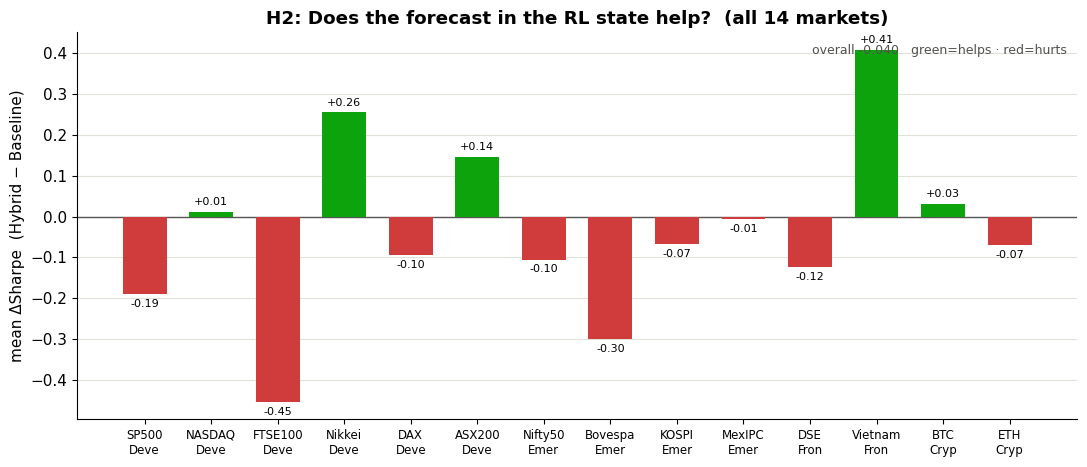

In [ ]:
plt.rcParams.update({"font.size":11,"axes.spines.top":False,"axes.spines.right":False})
vals = h2.set_index("Market")["mean_dSharpe"].reindex(ORDER)
colors = ["#0ca30c" if v>0 else "#d03b3b" for v in vals]
fig, ax = plt.subplots(figsize=(11,4.8))
ax.bar(range(len(vals)), vals.values, color=colors, width=0.66, zorder=3)
ax.axhline(0, color="#555", lw=1)
ax.set_xticks(range(len(vals)))
ax.set_xticklabels([f"{m}\n{GROUP[m][:4]}" for m in ORDER], fontsize=8.5)
ax.set_ylabel("mean ΔSharpe  (Hybrid − Baseline)")
ax.set_title("H2: Does the forecast in the RL state help?  (all 14 markets)", fontweight="bold")
ax.yaxis.set_major_locator(MultipleLocator(0.1)); ax.grid(axis="y", color="#e1e0d9", zorder=0)
for i,v in enumerate(vals.values):
    ax.text(i, v+(0.012 if v>=0 else -0.012), f"{v:+.2f}", ha="center",
            va="bottom" if v>=0 else "top", fontsize=8)
ax.text(0.99,0.97, f"overall {vals.mean():+.3f}   green=helps · red=hurts",
        transform=ax.transAxes, ha="right", va="top", fontsize=9, color="#52514e")
plt.tight_layout(); plt.show()


## 4. Chart — mean ΔSharpe by efficiency group

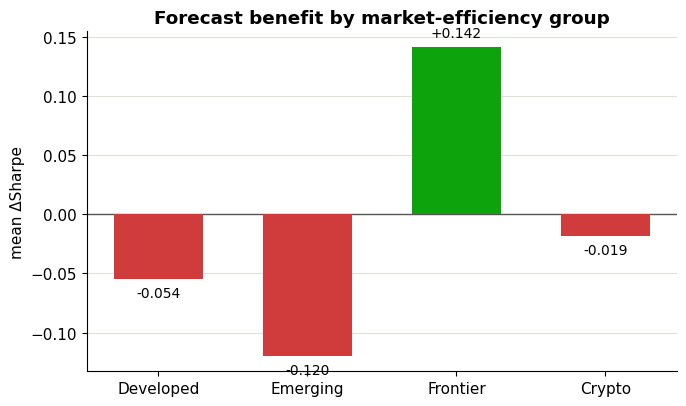

Counter-intuitive: the LESS-efficient groups (Emerging/Frontier) do NOT benefit more.


In [ ]:
g = h2.groupby("Group").mean_dSharpe.mean().reindex(["Developed","Emerging","Frontier","Crypto"])
colors = ["#0ca30c" if v>0 else "#d03b3b" for v in g.values]
fig, ax = plt.subplots(figsize=(7,4.2))
ax.bar(range(len(g)), g.values, color=colors, width=0.6, zorder=3)
ax.axhline(0, color="#555", lw=1); ax.set_xticks(range(len(g))); ax.set_xticklabels(g.index)
ax.set_ylabel("mean ΔSharpe"); ax.set_title("Forecast benefit by market-efficiency group", fontweight="bold")
ax.grid(axis="y", color="#e1e0d9", zorder=0)
for i,v in enumerate(g.values):
    ax.text(i, v+(0.006 if v>=0 else -0.006), f"{v:+.3f}", ha="center", va="bottom" if v>=0 else "top", fontsize=10)
plt.tight_layout(); plt.show()
print("Counter-intuitive: the LESS-efficient groups (Emerging/Frontier) do NOT benefit more.")


## 5. Chart — best RL agent vs Buy & Hold per market

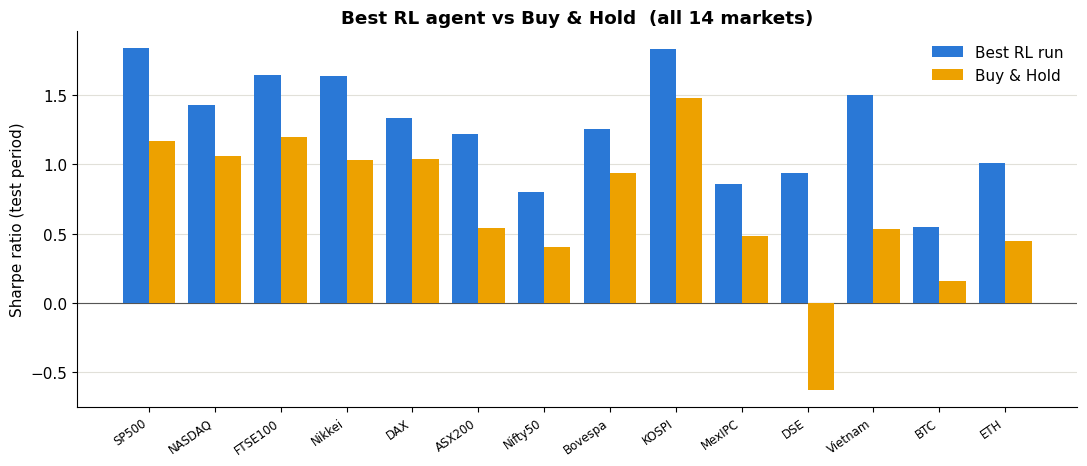

Best single RL run beats Buy & Hold in most markets, but on AVERAGE RL <= Buy & Hold (see H2 baselines).


In [ ]:
best_rl = [rl[(rl.market==mk)&(rl.agent!="BuyHold")].sharpe.max() for mk in ORDER]
bh = [rl[(rl.market==mk)&(rl.agent=="BuyHold")].sharpe.iloc[0] for mk in ORDER]
x = np.arange(len(ORDER)); w=0.4
fig, ax = plt.subplots(figsize=(11,4.8))
ax.bar(x-w/2, best_rl, w, label="Best RL run", color="#2a78d6", zorder=3)
ax.bar(x+w/2, bh,      w, label="Buy & Hold",  color="#eda100", zorder=3)
ax.set_xticks(x); ax.set_xticklabels(ORDER, rotation=35, ha="right", fontsize=8.5)
ax.set_ylabel("Sharpe ratio (test period)"); ax.axhline(0, color="#555", lw=0.8)
ax.set_title("Best RL agent vs Buy & Hold  (all 14 markets)", fontweight="bold")
ax.grid(axis="y", color="#e1e0d9", zorder=0); ax.legend(frameon=False)
plt.tight_layout(); plt.show()
print("Best single RL run beats Buy & Hold in most markets, but on AVERAGE RL <= Buy & Hold (see H2 baselines).")


## 6. Takeaways (all 14 markets)

1. **H1 (forecasting):** deep models call next-day **direction** ~50–58% but do **not** beat Naive on
   squared error in most markets (DM *p* > 0.05). Return forecasting is close to noise.
2. **H2 (hybrid RL):** overall ΔSharpe is **slightly negative** — adding the forecast to the RL state does
   **not** consistently help. It helps in a subset of markets and hurts in others.
3. **Counter-intuitive group pattern:** the benefit is **not** larger in less-efficient (Emerging/Frontier)
   markets — if anything it is larger in Developed/Crypto. This is opposite to the naive "inefficient markets
   are more predictable" expectation and is the paper's most interesting finding.
4. **Buy & Hold is a hard baseline:** the *best* RL run beats it in most markets, but on **average** RL ≈ Buy & Hold.
5. **Agent sensitivity:** tabular agents (Q-Learning/SARSA) tolerate the forecast; DQN/PPO are mixed, and PPO
   occasionally collapses to a no-trade policy (an `episodes=40` under-training artifact).

**Framing for the paper:** this is a *"when does a forecast help hybrid RL?"* cross-market study — a decision map,
not a "beat-the-market" claim. Main contribution: forecast-augmentation is **conditional** on market-efficiency
group and agent type, with a counter-intuitive efficiency pattern.

**Files (for NB3):** the three CSVs embedded above are also provided separately —
`forecast_results.csv`, `rl_results.csv`, `rl_window_panel.csv`.
